# Прогноз швидкості адопції тварин за фото та описом профілю

**Виконав:** Олександр Коновалюк

## Мета

За профілем тварини на PetFinder потрібно передбачити, наскільки швидко її усиновлять. На вході є фотографії (одна або кілька на тварину), текстовий опис і, якщо вони присутні в таблиці, структуровані ознаки на кшталт віку, породи чи стану здоров'я. На виході — категорія швидкості адопції.

## Метрика

Офіційна метрика змагання — **quadratic weighted kappa** (квадратично зважена каппа). Вона враховує порядок класів: помилка на сусідню категорію дешевша, ніж прогноз «дуже швидко» замість «дуже повільно». Для максимального балу змагання потрібен результат **не нижче 0.5**. Якщо результат нижчий, бал рахується пропорційно до цього порогу.

Файл відповіді — `submission.csv` з колонками `PetID`, `AdoptionSpeed` і з одним рядком на кожен `PetID` з `test.csv`. `sample_submission.csv` задає лише назви колонок. Якщо в ньому лише кілька прикладів, а тест довший, відповідь усе одно пишеться на весь тест: інакше перевірка відхиляє файл через нестачу рядків.

## Як влаштований експеримент

Моделі порівнюються на одному стратифікованому розбитті, щоб різниця в метриці належала архітектурі, а не іншій вибірці.

1. **Нижня межа на тексті.** Мішок слів часто вже містить прямі сигнали: вік, здоров'я, характер, прохання забрати тварину.
2. **Лише зображення.** Перенесені ознаки згорткової мережі, навченої на великому наборі фотографій. Власну мережу з нуля на кількох тисячах знімків легко перенавчити під шум фону.
3. **Злиття.** Рішення усиновити тварину залежить і від того, як вона виглядає, і від того, що про неї написано. Окремі модальності цього не покривають.

Кожен експеримент лишається в ноутбуці й дописує рядок у журнал. Наступна архітектура або інший набір гіперпараметрів додається **новими комірками нижче**, без заміни попередніх блоків. Висновки після цього прогону заповнюються за надрукованими числами, а не заздалегідь.

Пошук гіперпараметрів окремим перебором тут свідомо не запускається: спочатку потрібно побачити, яка модальність узагалі несе сигнал. Перебирати швидкість навчання на слабкій архітектурі означає підігнати один валідаційний спліт.


## 1. Середовище, шляхи та гіперпараметри

Ноутбук розрахований на Kaggle з увімкненим GPU і Internet: ваги ResNet18 завантажуються під час першого прогону. Ознаки зображень кешуються у робочій директорії, щоб повторний запуск і наступні експерименти не рахували згорткову мережу знову.

Гіперпараметри першого прогону фіксовані й записані нижче, щоб пізніше можна було змінити одну величину в новому блоці й порівняти її з цим рядком журналу.

| Параметр | Значення | Навіщо |
| --- | --- | --- |
| Частка валідації | 20%, стратифіковано | У кожному класі зберігається та сама частка, інакше QWK стрибає через рідкісний клас |
| Максимум епох | 8 | Верхня межа, а не ціль |
| Patience | 2 епохи | Зупинка, якщо val QWK не зріс |
| Мінімальний приріст QWK | 0.001 | Дрібніший зсув на цьому розмірі вибірки не відрізняється від шуму |
| Dropout | 0.3 | Випадково вимикає частини вектора перед класифікатором, щоб голова не запам'ятовувала навчальні профілі |
| AdamW, lr, weight decay | 1e-3, 1e-4 | Вагове загасання тримає ваги малими на невеликій вибірці |
| Ембединг слова / прихований стан LSTM | 128 / 128, 1 шар | Порядку слів достатньо одного двонаправленого шару: текстів кілька тисяч |
| Довжина тексту | 128 токенів | Опис профілю рідко несе рішення в самому кінці довгого тексту |
| Фото на тварину | до 3 | Перші за номером кадри: головне фото і кілька ракурсів, без хвоста з десятків майже однакових знімків |
| Розмір зображення | 224, нормалізація ImageNet | Масштаб, на якому навчені ваги ResNet |


In [1]:
import copy
import os
import random
import re
import time
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from IPython.display import display
from PIL import Image
from sklearn.exceptions import UndefinedMetricWarning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.nn.utils.rnn import pack_padded_sequence, pad_sequence
from torch.utils.data import DataLoader, Dataset
from torchvision.models import ResNet18_Weights, resnet18
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
sns.set_theme(style="whitegrid")

SEED = 42
VAL_SIZE = 0.2
MAX_EPOCHS = 8
PATIENCE = 2
MIN_DELTA = 0.001
DROPOUT = 0.3
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
EMBED_DIM = 128
LSTM_HIDDEN = 128
MAX_TEXT_LEN = 128
MIN_WORD_FREQ = 2
MAX_IMAGES = 3
BATCH_SIZE = 32
FEATURE_BATCH_SIZE = 64
TFIDF_MAX_FEATURES = 20000
TFIDF_MIN_DF = 2
GRAD_CLIP = 5.0
TABULAR_MAX_CARDINALITY = 400

DATA_ROOT = Path("/kaggle/input/competitions/deep-learning-for-computer-vision-and-nlp-2026-10")
TRAIN_CSV = DATA_ROOT / "train.csv"
TEST_CSV = DATA_ROOT / "test.csv"
SAMPLE_CSV = DATA_ROOT / "sample_submission.csv"
IMAGE_DIR = DATA_ROOT / "images"
WORKING = Path("/kaggle/working")
FEATURE_CACHE = WORKING / "resnet18_pet_features.npz"
LOG_PATH = WORKING / "experiment_log.csv"
SUBMISSION_PATH = WORKING / "submission.csv"

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
NUMERIC_NAME_HINTS = ("age", "fee", "quantity", "qty", "photoamt", "videoamt", "price", "amount")


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed(SEED)
WORKING.mkdir(parents=True, exist_ok=True)

for path in (TRAIN_CSV, TEST_CSV, SAMPLE_CSV, IMAGE_DIR):
    if not path.exists():
        raise FileNotFoundError(
            f"Не знайдено {path}. Ноутбук має запускатися в Kaggle з підключеним змаганням."
        )

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = 2 if os.name != "nt" else 0
print("torch", torch.__version__)
print("device", device)
if device.type == "cuda":
    print(torch.cuda.get_device_name(0))
else:
    print("GPU не видно. Витяг ознак ResNet на CPU буде повільним; для прогону змагання увімкніть GPU.")


torch 2.10.0+cu128
device cuda
Tesla T4


## 2. Метрика, журнал експериментів і рання зупинка

Журнал — список рядків, який кожен експеримент доповнює і зберігає в `experiment_log.csv`. Старі рядки не переписуються.

Рання зупинка дивиться на **val QWK**, а не на функцію втрат. Крос-ентропія карає впевненість у неправильному класі, але не знає, що клас 1 ближчий до 2, ніж до 4. Саме QWK є тим, що піде в залік.

На кожній епосі порівнюються два способи перетворити ймовірності на мітку:

- **argmax** — клас із найбільшою ймовірністю;
- **expectation** — округлене математичне сподівання індексу класу. Якщо модель сумнівається між сусідніми категоріями, очікування рідше стрибає через одну категорію, а QWK такий стрибок карає квадратом відстані.

Кращий із двох на епосі визначає, чи є покращення. Поріг покращення — 0.001. Якщо дві епохи поспіль приросту немає, цикл зупиняється. У ваги повертається найкраща епоха, навіть якщо після неї loss ще падав: падіння loss без росту QWK тут не є успіхом.

Коли обрану модель навчаємо на всіх розмічених рядках, валідації вже немає. Тому число епох дорівнює номеру найкращої епохи, а не верхній межі 8.


In [17]:
EXPERIMENT_ROWS = []
RUNS = {}


def quadratic_weighted_kappa(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    if len(y_true) == 0:
        return 0.0
    score = cohen_kappa_score(y_true, y_pred, weights="quadratic")
    if score != score:
        return 0.0
    return float(score)


def decode_probabilities(probs, n_classes):
    class_index = np.arange(n_classes, dtype=np.float64)
    expectation = np.rint(probs @ class_index)
    expectation = np.clip(expectation, 0, n_classes - 1).astype(int)
    return {
        "argmax": probs.argmax(axis=1).astype(int),
        "expectation": expectation,
    }


def log_experiment(name, val_qwk, decoder, epochs_ran, best_epoch, notes=""):
    row = {
        "Експеримент": name,
        "Val QWK": round(float(val_qwk), 4),
        "Декодер": decoder,
        "Епох навчено": int(epochs_ran) if epochs_ran == epochs_ran else 0,
        "Найкраща епоха": int(best_epoch) if best_epoch == best_epoch else 0,
        "Нотатки": notes,
    }
    EXPERIMENT_ROWS.append(row)
    frame = pd.DataFrame(EXPERIMENT_ROWS)
    frame.to_csv(LOG_PATH, index=False)
    display(frame)
    return row


def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


def class_weights_from_labels(labels, n_classes):
    counts = np.bincount(np.asarray(labels).astype(int), minlength=n_classes).astype(np.float32)
    weights = counts.sum() / (n_classes * np.maximum(counts, 1.0))
    return torch.tensor(weights, dtype=torch.float32, device=device)


def batch_move(batch):
    if torch.is_tensor(batch):
        return batch.to(device)
    if isinstance(batch, (tuple, list)):
        return type(batch)(batch_move(item) for item in batch)
    if isinstance(batch, dict):
        return {key: batch_move(value) for key, value in batch.items()}
    return batch


@torch.no_grad()
def collect_probabilities(model, loader, logits_from_batch):
    model.eval()
    total_loss = 0.0
    seen = 0
    prob_chunks = []
    label_chunks = []
    for batch in loader:
        logits, targets, loss = logits_from_batch(model, batch, compute_loss=True)
        batch_size = targets.size(0)
        total_loss += loss.item() * batch_size
        seen += batch_size
        prob_chunks.append(torch.softmax(logits, dim=1).cpu().numpy())
        label_chunks.append(targets.detach().cpu().numpy())
    avg_loss = total_loss / max(seen, 1)
    return avg_loss, np.concatenate(prob_chunks), np.concatenate(label_chunks)


def train_until_plateau(model, train_loader, val_loader, optimizer, logits_from_batch, n_classes):
    history = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        "qwk_argmax": [],
        "qwk_expectation": [],
    }
    best_qwk = -1.0
    best_epoch = 0
    best_decoder = "argmax"
    best_state = copy.deepcopy(model.state_dict())
    wait = 0
    epochs_ran = 0

    for epoch in range(1, MAX_EPOCHS + 1):
        epochs_ran = epoch
        model.train()
        total_loss = 0.0
        seen = 0
        for batch in train_loader:
            optimizer.zero_grad(set_to_none=True)
            logits, targets, loss = logits_from_batch(model, batch, compute_loss=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
            batch_size = targets.size(0)
            total_loss += loss.item() * batch_size
            seen += batch_size
        train_loss = total_loss / max(seen, 1)

        val_loss, probs, y_true = collect_probabilities(model, val_loader, logits_from_batch)
        decoded = decode_probabilities(probs, n_classes)
        qwk_argmax = quadratic_weighted_kappa(y_true, decoded["argmax"])
        qwk_expectation = quadratic_weighted_kappa(y_true, decoded["expectation"])
        if qwk_expectation > qwk_argmax:
            epoch_decoder = "expectation"
            epoch_qwk = qwk_expectation
        else:
            epoch_decoder = "argmax"
            epoch_qwk = qwk_argmax

        history["epoch"].append(epoch)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["qwk_argmax"].append(qwk_argmax)
        history["qwk_expectation"].append(qwk_expectation)
        print(
            f"Епоха {epoch:02d}/{MAX_EPOCHS} | train loss {train_loss:.4f} | "
            f"val loss {val_loss:.4f} | QWK argmax {qwk_argmax:.4f} | "
            f"QWK expectation {qwk_expectation:.4f}"
        )

        if epoch_qwk > best_qwk + MIN_DELTA:
            best_qwk = epoch_qwk
            best_epoch = epoch
            best_decoder = epoch_decoder
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= PATIENCE:
                print(
                    f"Рання зупинка на епосі {epoch}: val QWK не зріс на {MIN_DELTA} "
                    f"протягом {PATIENCE} епох. Найкраща епоха {best_epoch}, "
                    f"QWK {best_qwk:.4f} ({best_decoder})."
                )
                break
    else:
        print(
            f"Досягнуто межу {MAX_EPOCHS} епох. Найкраща епоха {best_epoch}, "
            f"QWK {best_qwk:.4f} ({best_decoder})."
        )

    model.load_state_dict(best_state)
    return {
        "history": history,
        "best_qwk": best_qwk,
        "best_epoch": best_epoch,
        "best_decoder": best_decoder,
        "epochs_ran": epochs_ran,
    }


def train_fixed_epochs(model, train_loader, optimizer, logits_from_batch, epochs):
    epochs = max(int(epochs), 1)
    model.train()
    for epoch in range(1, epochs + 1):
        total_loss = 0.0
        seen = 0
        for batch in train_loader:
            optimizer.zero_grad(set_to_none=True)
            logits, targets, loss = logits_from_batch(model, batch, compute_loss=True)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
            batch_size = targets.size(0)
            total_loss += loss.item() * batch_size
            seen += batch_size
        print(
            f"Повне навчання, епоха {epoch}/{epochs}, "
            f"train loss {total_loss / max(seen, 1):.4f}"
        )


def plot_confusion(y_true, y_pred, title):
    labels = list(range(N_CLASSES))
    matrix = confusion_matrix(y_true, y_pred, labels=labels)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[str(IDX_TO_LABEL[i]) for i in labels],
        yticklabels=[str(IDX_TO_LABEL[i]) for i in labels],
        ax=ax,
    )
    ax.set_xlabel("Прогноз")
    ax.set_ylabel("Факт")
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history["epoch"], history["train_loss"], marker="o", label="train")
    axes[0].plot(history["epoch"], history["val_loss"], marker="o", label="val")
    axes[0].set_title("Функція втрат")
    axes[0].set_xlabel("Епоха")
    axes[0].legend()
    axes[1].plot(history["epoch"], history["qwk_argmax"], marker="o", label="argmax")
    axes[1].plot(history["epoch"], history["qwk_expectation"], marker="o", label="expectation")
    axes[1].set_title("Val QWK")
    axes[1].set_xlabel("Епоха")
    axes[1].legend()
    plt.tight_layout()
    plt.show()


demo_true = np.array([0, 0, 1, 1, 2, 2, 3, 3])
demo_near = np.array([0, 1, 1, 2, 2, 3, 3, 3])
demo_far = np.array([3, 3, 3, 3, 0, 0, 0, 0])
print("Перевірка метрики на штучному прикладі, не на даних змагання.")
print("Повний збіг:", round(quadratic_weighted_kappa(demo_true, demo_true), 4))
print("Сусідні класи:", round(quadratic_weighted_kappa(demo_true, demo_near), 4))
print("Далекі класи:", round(quadratic_weighted_kappa(demo_true, demo_far), 4))


Перевірка метрики на штучному прикладі, не на даних змагання.
Повний збіг: 1.0
Сусідні класи: 0.85
Далекі класи: -0.8571


## 3. Завантаження таблиць

Схему файлів заздалегідь не фіксуємо в коді назвами всіх колонок. Ноутбук знаходить ідентифікатор, ціль і текстовий опис за назвами, а решту колонок розбирає пізніше: частину як числа, частину як категорії, ідентифікатори з дуже великою кількістю значень відкидає. Якщо текстової колонки немає, опис вважається порожнім, і це буде видно в журналі як слабкий текстовий експеримент, а не як прихована помилка.

Мітки переводяться в індекси `0 ... K-1` у порядку зростання початкових значень. У файл відповіді повертається початкова шкала. Очікування класу рахується в просторі цих індексів, тому порядок міток має збігатися з порядком швидкості адопції.


In [18]:
def find_column(columns, options):
    lookup = {str(column).lower(): column for column in columns}
    for option in options:
        if option.lower() in lookup:
            return lookup[option.lower()]
    return None


def normalize_id(value):
    if pd.isna(value):
        return ""
    text = str(value).strip()
    if text.endswith(".0"):
        text = text[:-2]
    return text


def read_table(path):
    frame = pd.read_csv(path)
    frame.columns = [str(column).strip() for column in frame.columns]
    return frame


train_df = read_table(TRAIN_CSV)
test_df = read_table(TEST_CSV)
sample_df = read_table(SAMPLE_CSV)

id_col = find_column(train_df.columns, ["PetID", "pet_id", "id"])
target_col = find_column(train_df.columns, ["AdoptionSpeed", "adoption_speed", "label", "target"])
text_col = find_column(train_df.columns, ["Description", "description", "desc", "text", "comments"])
if id_col is None or target_col is None:
    raise RuntimeError(
        f"Не вдалося знайти колонки ідентифікатора і цілі. Колонки train: {list(train_df.columns)}"
    )

test_id_col = find_column(test_df.columns, ["PetID", "pet_id", "id"]) or id_col
if test_id_col not in test_df.columns:
    raise RuntimeError(f"У test.csv немає колонки ідентифікатора. Колонки: {list(test_df.columns)}")

train_df[id_col] = train_df[id_col].map(normalize_id)
test_df[test_id_col] = test_df[test_id_col].map(normalize_id)
duplicate_count = int(train_df[id_col].duplicated().sum())
if duplicate_count:
    print(f"Дублікати {id_col} у train: {duplicate_count}. Залишаю перший рядок, щоб один профіль не потрапив і в навчання, і у валідацію.")
    train_df = train_df.drop_duplicates(id_col, keep="first")

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

if target_col in test_df.columns:
    print(f"У test.csv є колонка {target_col}. Для навчання і сабміту вона не використовується.")
    test_df = test_df.drop(columns=[target_col])

test_text_col = find_column(test_df.columns, ["Description", "description", "desc", "text", "comments"])
if text_col is None:
    print("Текстової колонки в train не знайдено. Описи будуть порожніми.")
    text_col = "text_clean"
    train_df[text_col] = ""
    test_df[text_col] = ""
elif test_text_col is None:
    print("Текстової колонки в test не знайдено. Описи тесту будуть порожніми.")
    test_df[text_col] = ""
elif test_text_col != text_col:
    test_df[text_col] = test_df[test_text_col]

raw_target = train_df[target_col]
if pd.api.types.is_numeric_dtype(raw_target):
    numeric_target = raw_target.astype(float)
    if np.allclose(numeric_target.to_numpy(), np.rint(numeric_target.to_numpy())):
        train_df[target_col] = numeric_target.round().astype(int)

classes = sorted(train_df[target_col].dropna().unique().tolist())
LABEL_TO_IDX = {label: index for index, label in enumerate(classes)}
IDX_TO_LABEL = {index: label for label, index in LABEL_TO_IDX.items()}
N_CLASSES = len(classes)
train_df = train_df.dropna(subset=[target_col]).reset_index(drop=True)
y_all = train_df[target_col].map(LABEL_TO_IDX).to_numpy(dtype=int)

label_gaps = np.diff(np.asarray(classes, dtype=float))
print("Колонка id:", id_col)
print("Колонка цілі:", target_col)
print("Колонка тексту:", text_col)
print("Відповідність міток індексам:", LABEL_TO_IDX)
if len(label_gaps) and not np.allclose(label_gaps, 1.0):
    print("Крок між мітками не дорівнює 1. Очікування рахується за рангом класу, у файл повертається початкова мітка.")

print("train", train_df.shape, "test", test_df.shape)
print(train_df.dtypes)
display(train_df.head(3))
display(sample_df.head(3))


Колонка id: PetID
Колонка цілі: AdoptionSpeed
Колонка тексту: Description
Відповідність міток індексам: {1: 0, 2: 1, 3: 2, 4: 3}
train (6431, 3) test (1891, 2)
PetID            object
Description      object
AdoptionSpeed     int64
dtype: object


,PetID,Description,AdoptionSpeed
0,d3b4f29f8,Mayleen and Flo are two lovely adorable sister...,2
1,e9dc82251,A total of 5 beautiful Tabbys available for ad...,2
2,8111f6d4a,Two-and-a-half month old girl. Very manja and ...,2


,PetID,AdoptionSpeed
0,6697a7f62,1
1,23b64fe21,2
2,41e824cbe,3


## 4. Прив'язка фотографій

Імена файлів у каталозі знімків можуть бути `{PetID}.jpg` або `{PetID}-1.jpg` / `{PetID}_1.jpg`. Спочатку перевіряється точний збіг імені без розширення з ідентифікатором. Якщо його немає, від імені відрізається останній числовий суфікс після `-` або `_`.

Для моделі беруться не більше ніж три перші кадри за цим номером: зазвичай це головне фото профілю і кілька додаткових ракурсів. Решта кадрів лишається в статистиці розвідки, але не в ознаках, інакше тварини з десятками майже однакових фото домінують у середньому векторі й у часі прогону.


In [19]:
def list_image_files(image_dir):
    files = []
    for path in Path(image_dir).rglob("*"):
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
            files.append(path)
    return files


def link_images(pet_ids, files):
    pet_set = set(pet_ids)
    grouped = {pet_id: [] for pet_id in pet_set}
    for path in files:
        stem = path.stem
        pet_id = None
        order = 0
        if stem in pet_set:
            pet_id = stem
        else:
            for separator in ("-", "_"):
                if separator not in stem:
                    continue
                base, rest = stem.rsplit(separator, 1)
                if base in pet_set:
                    pet_id = base
                    order = int(rest) if rest.isdigit() else 10**6
                    break
        if pet_id is not None:
            grouped[pet_id].append((order, path))
    linked = {}
    for pet_id, items in grouped.items():
        items.sort(key=lambda item: (item[0], item[1].name))
        linked[pet_id] = [path for _, path in items]
    return linked


image_files = list_image_files(IMAGE_DIR)
extension_counts = Counter(path.suffix.lower() for path in image_files)
print("Файлів зображень:", len(image_files))
print("Розширення:", dict(extension_counts))
print("Приклади імен:", [path.name for path in image_files[:12]])

all_pet_ids = list(dict.fromkeys(list(train_df[id_col]) + list(test_df[test_id_col])))
full_image_paths = link_images(all_pet_ids, image_files)
model_image_paths = {
    pet_id: paths[:MAX_IMAGES] for pet_id, paths in full_image_paths.items()
}

train_ids = train_df[id_col].tolist()
test_ids = test_df[test_id_col].tolist()
train_photo_counts = np.array([len(full_image_paths[pet_id]) for pet_id in train_ids])
train_with_photo = int((train_photo_counts > 0).sum())
test_photo_counts = np.array([len(full_image_paths[pet_id]) for pet_id in test_ids])
print(
    f"Train із хоча б одним фото: {train_with_photo}/{len(train_ids)} "
    f"({train_with_photo / max(len(train_ids), 1):.1%})"
)
print(
    f"Test із хоча б одним фото: {int((test_photo_counts > 0).sum())}/{len(test_ids)} "
    f"({(test_photo_counts > 0).mean():.1%})"
)
print("Фото на тварину в train: min", int(train_photo_counts.min()),
      "median", float(np.median(train_photo_counts)),
      "max", int(train_photo_counts.max()))


Файлів зображень: 37920
Розширення: {'.jpg': 37920}
Приклади імен: ['cf8d949f9-2.jpg', '41e824cbe-3.jpg', '687be6419-4.jpg', '081199ea2-12.jpg', '924cc5438-4.jpg', 'b1ed265ef-11.jpg', '9daaa4e8f-1.jpg', '062de1f53-4.jpg', '0ce5d0b5f-3.jpg', 'd4bb8cf0a-4.jpg', '66cff2ed9-7.jpg', '3f9f466d1-6.jpg']
Train із хоча б одним фото: 6431/6431 (100.0%)
Test із хоча б одним фото: 1887/1891 (99.8%)
Фото на тварину в train: min 1 median 4.0 max 30


## 5. Розвідувальний аналіз

Перед моделями потрібно побачити три речі, від яких залежить архітектура.

- Чи збалансовані класи. Якщо один домінує, класифікатор без ваг класів зсувається до нього, а QWK за такий зсув майже не платить, бо далекі рідкісні класи все одно промахуються.
- Чи є порожні описи і якою мовою вони написані. Очищення нижче розраховане на англійський текст: скорочення, латиниця, англійські стоп-слова.
- Скільки тварин узагалі мають фото. Якщо частка без знімків велика, зображення не може бути єдиним джерелом прогнозу, і в ознаку додається прапорець відсутності фото.


Розподіл цілі:
AdoptionSpeed
1    1197
2    1773
3    1328
4    2133
Name: count, dtype: int64
Частка найчастішого класу: 0.3317


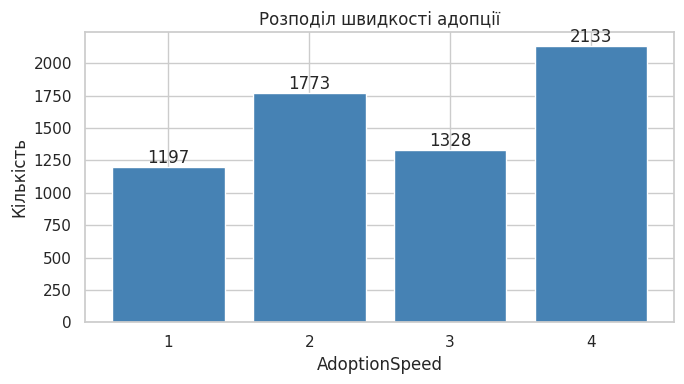

Частка пропусків у train (лише колонки, де вони є):


,missing_rate
Description,0.000777


Порожніх описів: 0.1%
Середня частка латинських літер серед непробільних символів непорожніх описів: 94.6%
count    6431.000000
mean       67.442233
std        76.088326
min         0.000000
25%        22.000000
50%        46.000000
75%        85.000000
max      1153.000000
Name: Description, dtype: float64


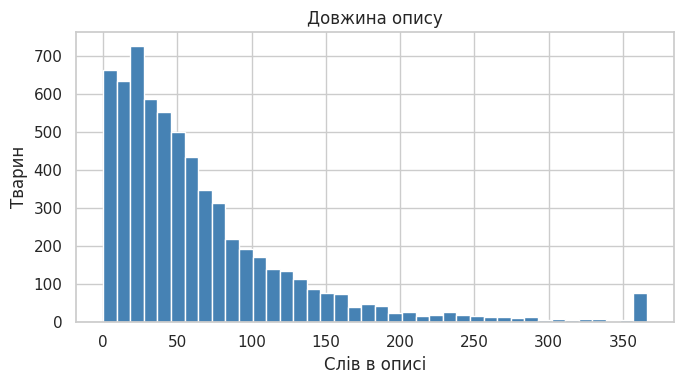

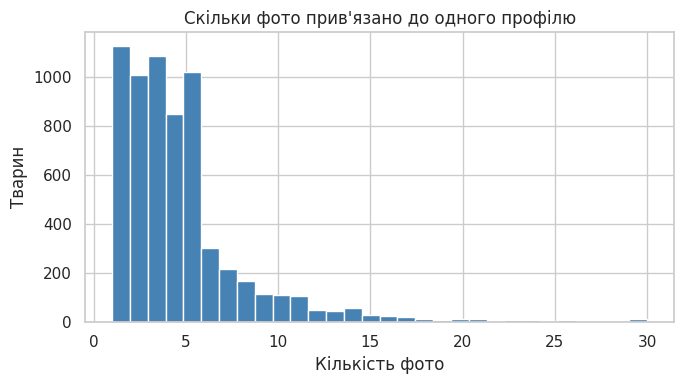

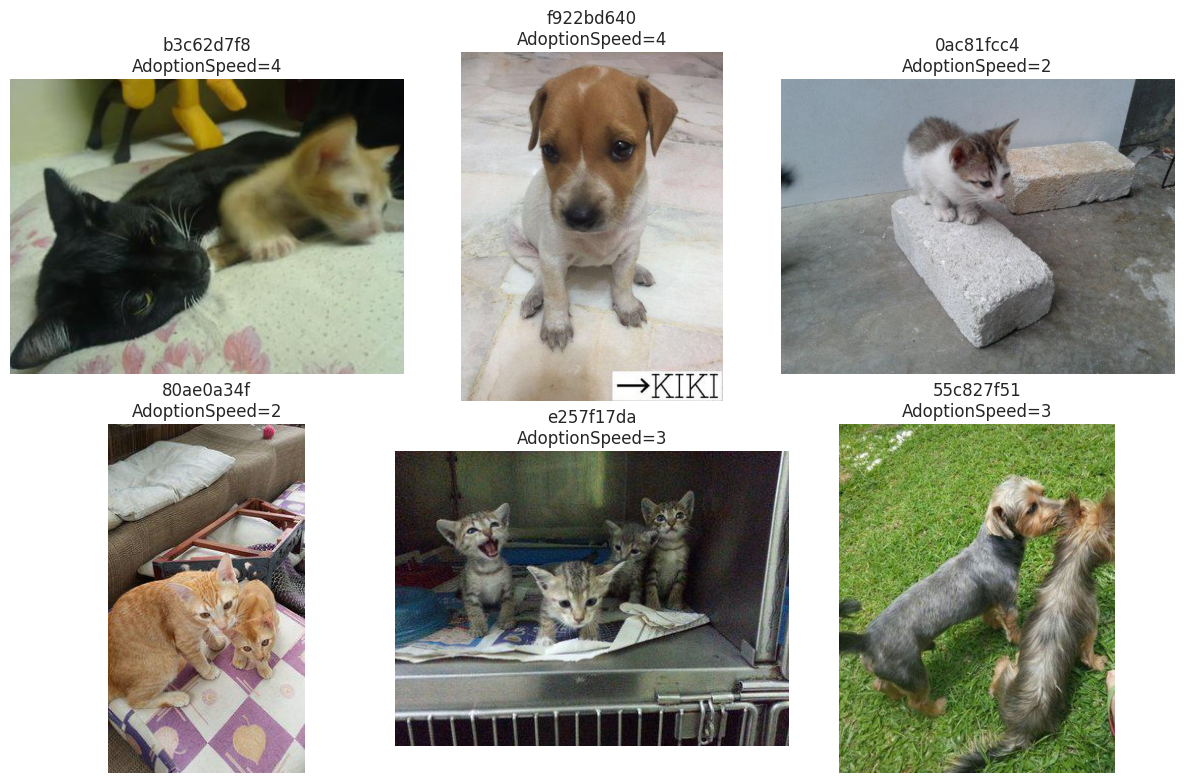

In [20]:
class_counts = train_df[target_col].value_counts().sort_index()
print("Розподіл цілі:")
print(class_counts)
print("Частка найчастішого класу:", round(float(class_counts.max() / class_counts.sum()), 4))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(class_counts.index.astype(str), class_counts.values, color="steelblue")
ax.set_xlabel(target_col)
ax.set_ylabel("Кількість")
ax.set_title("Розподіл швидкості адопції")
for index, value in enumerate(class_counts.values):
    ax.text(index, value, str(int(value)), ha="center", va="bottom")
plt.tight_layout()
plt.show()

missing_rate = train_df.isna().mean().sort_values(ascending=False)
missing_rate = missing_rate[missing_rate > 0]
print("Частка пропусків у train (лише колонки, де вони є):")
display(missing_rate.to_frame("missing_rate"))

if text_col in train_df.columns:
    raw_text = train_df[text_col].fillna("").astype(str)
    empty_text = raw_text.str.strip().eq("").mean()
    word_counts = raw_text.map(lambda text: len(text.split()))
    latin_chars = raw_text.map(lambda text: len(re.findall(r"[A-Za-z]", text)))
    all_chars = raw_text.map(lambda text: max(len(re.findall(r"[^\s]", text)), 1))
    nonempty = raw_text.str.strip().ne("")
    if nonempty.any():
        latin_share = float((latin_chars[nonempty] / all_chars[nonempty]).mean())
    else:
        latin_share = 0.0
    print(f"Порожніх описів: {empty_text:.1%}")
    print(f"Середня частка латинських літер серед непробільних символів непорожніх описів: {latin_share:.1%}")
    print(word_counts.describe())
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(word_counts.clip(upper=word_counts.quantile(0.99)), bins=40, color="steelblue")
    ax.set_xlabel("Слів в описі")
    ax.set_ylabel("Тварин")
    ax.set_title("Довжина опису")
    plt.tight_layout()
    plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(train_photo_counts, bins=min(30, int(train_photo_counts.max()) + 1), color="steelblue")
ax.set_xlabel("Кількість фото")
ax.set_ylabel("Тварин")
ax.set_title("Скільки фото прив'язано до одного профілю")
plt.tight_layout()
plt.show()

type_col = find_column(train_df.columns, ["Type", "type", "Animal", "Species"])
if type_col is not None:
    share = pd.crosstab(train_df[type_col], train_df[target_col], normalize="index")
    print(f"Частка класів швидкості всередині колонки {type_col}:")
    display(share.round(3))

preview_ids = [pet_id for pet_id in train_ids if full_image_paths[pet_id]]
if preview_ids:
    generator = np.random.default_rng(SEED)
    chosen = generator.choice(preview_ids, size=min(6, len(preview_ids)), replace=False)
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    id_to_label = dict(zip(train_ids, train_df[target_col].tolist()))
    for ax, pet_id in zip(axes.ravel(), list(chosen) + [None] * 6):
        ax.axis("off")
        if pet_id is None:
            continue
        try:
            with Image.open(full_image_paths[pet_id][0]) as image:
                ax.imshow(image.convert("RGB"))
            ax.set_title(f"{pet_id}\n{target_col}={id_to_label[pet_id]}")
        except Exception as exc:
            ax.set_title(f"Не вдалося відкрити {pet_id}: {exc}")
    plt.tight_layout()
    plt.show()
else:
    print("Жодному train PetID не знайдено файлу зображення. Перевірте шаблон імен вище.")


### Висновки за розвідувальним аналізом

*Заповнити після прогону. Зафіксувати частку тварин без фото, частку порожніх описів, чи описи переважно латиницею, наскільки домінує найчастіший клас і скільки фото типово припадає на профіль. Від цього залежить, чи можна покладатися на зображення і чи потрібні ваги класів у наступних експериментах.*


## 6. Очищення тексту і розбиття

Опис профілю чистять так:

- розкриваються англійські скорочення, щоб `don't` і `do not` не стали різними ознаками;
- лишається латиниця в нижньому регістрі;
- прибираються стоп-слова, але **не** заперечення (`not`, `no`, `never`, `without`). Фраза «not vaccinated» без `not` змінює зміст на протилежний;
- короткі уламки з однієї літери відкидаються.

Словник для нейромережі і TF-IDF будуються лише на навчальній частині розбиття. Валідаційні слова, яких не було в навчанні, стають невідомими токенами. Інакше оцінка QWK завищена словами, яких модель у чесному прогнозі ще не бачила.

Розбиття 80/20 стратифіковане за ціллю і зафіксоване зерном 42. Те саме розбиття використовують усі три експерименти.


In [21]:
NEGATION_TOKENS = {
    "no", "not", "nor", "never", "none", "nobody", "nothing",
    "neither", "nowhere", "without", "cannot",
}
CONTRACTIONS = {
    "ain't": "is not",
    "aren't": "are not",
    "can't": "cannot",
    "couldn't": "could not",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "hadn't": "had not",
    "hasn't": "has not",
    "haven't": "have not",
    "he's": "he is",
    "here's": "here is",
    "how's": "how is",
    "i'm": "i am",
    "i've": "i have",
    "isn't": "is not",
    "it's": "it is",
    "let's": "let us",
    "mustn't": "must not",
    "she's": "she is",
    "that's": "that is",
    "there's": "there is",
    "they're": "they are",
    "they've": "they have",
    "we're": "we are",
    "we've": "we have",
    "weren't": "were not",
    "what's": "what is",
    "where's": "where is",
    "who's": "who is",
    "won't": "will not",
    "wouldn't": "would not",
    "you're": "you are",
    "you've": "you have",
}
CONTRACTION_RE = re.compile(
    r"\b(" + "|".join(sorted(map(re.escape, CONTRACTIONS), key=len, reverse=True)) + r")\b"
)
FALLBACK_STOPWORDS = set(
    "a about above after again against all am an and any are as at be because been "
    "before being below between both but by can did do does doing down during each "
    "few for from further had has have having he her here hers herself him himself "
    "his how i if in into is it its itself just me more most my myself of off on "
    "once only or other our ours ourselves out over own same she should so some "
    "such than that the their theirs them themselves then there these they this "
    "those through to too under until up very was we were what when where which "
    "while who whom why will with you your yours yourself yourselves".split()
)


def load_stopwords():
    try:
        import nltk
        from nltk.corpus import stopwords

        nltk.download("stopwords", quiet=True)
        words = set(stopwords.words("english"))
        print("Стоп-слова: NLTK, english")
    except Exception as exc:
        print(f"Стоп-слова NLTK недоступні ({type(exc).__name__}: {exc}). Використовую вбудований список.")
        words = set(FALLBACK_STOPWORDS)
    return words - NEGATION_TOKENS


STOPWORDS = load_stopwords()


def clean_text(value):
    if not isinstance(value, str):
        return ""
    text = value.lower().replace("’", "'").replace("`", "'")
    text = CONTRACTION_RE.sub(lambda match: CONTRACTIONS[match.group(0)], text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = [token for token in text.split() if len(token) > 1 and token not in STOPWORDS]
    return " ".join(tokens)


class TextVocabulary:
    def __init__(self, min_freq=MIN_WORD_FREQ, max_len=MAX_TEXT_LEN):
        self.min_freq = min_freq
        self.max_len = max_len
        self.word2idx = {"<pad>": 0, "<unk>": 1}

    def fit(self, texts):
        counter = Counter()
        for text in texts:
            counter.update(str(text).split())
        for word, count in counter.items():
            if count >= self.min_freq and word not in self.word2idx:
                self.word2idx[word] = len(self.word2idx)
        return self

    def encode(self, text):
        indexes = [self.word2idx.get(word, 1) for word in str(text).split()[: self.max_len]]
        if not indexes:
            indexes = [1]
        return torch.tensor(indexes, dtype=torch.long)

    def __len__(self):
        return len(self.word2idx)


class TabularPreprocessor:
    # Категорії з помірною кількістю значень ідуть в ембединги, величини — у стандартизацію.
    # Ідентифікатор рятівника і кличка мають тисячі значень і не узагальнюються на нових
    # тварин, тому в модель не потрапляють. Вік, внесок і кількість фото лишаються числами.

    def __init__(self, id_column, target_column, text_column):
        self.id_column = id_column
        self.target_column = target_column
        self.text_column = text_column
        self.cat_cols = []
        self.num_cols = []
        self.cat_maps = {}
        self.num_median = {}
        self.num_mean = {}
        self.num_std = {}

    def _drop_column(self, column, nunique):
        key = column.lower().replace("_", "")
        if key in {"name", "rescuerid", "petname", "url", "peturl"}:
            return True
        if key.endswith("id") and key not in {"breed1", "breed2"} and nunique > 50:
            return True
        if nunique > TABULAR_MAX_CARDINALITY and not self._forced_numeric(column):
            return True
        return False

    def _forced_numeric(self, column):
        key = column.lower().replace("_", "")
        return any(hint in key for hint in NUMERIC_NAME_HINTS)

    def fit(self, frame):
        self.cat_cols = []
        self.num_cols = []
        self.cat_maps = {}
        self.num_median = {}
        self.num_mean = {}
        self.num_std = {}
        skip = {self.id_column, self.target_column, self.text_column, "text_clean"}
        for column in frame.columns:
            if column in skip:
                continue
            series = frame[column]
            nunique = int(series.nunique(dropna=True))
            if nunique <= 1 or self._drop_column(column, nunique):
                continue
            if pd.api.types.is_float_dtype(series) or self._forced_numeric(column):
                self.num_cols.append(column)
            else:
                self.cat_cols.append(column)
        for column in self.cat_cols:
            values = [value for value in frame[column].dropna().unique().tolist()]
            self.cat_maps[column] = {value: index + 1 for index, value in enumerate(values)}
        for column in self.num_cols:
            numeric = pd.to_numeric(frame[column], errors="coerce")
            median = float(numeric.median()) if numeric.notna().any() else 0.0
            filled = numeric.fillna(median)
            std = float(filled.std(ddof=0))
            self.num_median[column] = median
            self.num_mean[column] = float(filled.mean())
            self.num_std[column] = std if std >= 1e-6 else 1.0
        return self

    def transform(self, frame):
        categorical = np.zeros((len(frame), len(self.cat_cols)), dtype=np.int64)
        for column_index, column in enumerate(self.cat_cols):
            mapping = self.cat_maps[column]
            categorical[:, column_index] = [
                mapping.get(value, 0) if pd.notna(value) else 0
                for value in frame[column].tolist()
            ]
        numeric = np.zeros((len(frame), len(self.num_cols)), dtype=np.float32)
        for column_index, column in enumerate(self.num_cols):
            values = pd.to_numeric(frame[column], errors="coerce").fillna(self.num_median[column])
            numeric[:, column_index] = (
                (values - self.num_mean[column]) / self.num_std[column]
            ).to_numpy(dtype=np.float32)
        return categorical, numeric

    @property
    def cat_cardinalities(self):
        return [len(self.cat_maps[column]) + 1 for column in self.cat_cols]


source_text = train_df[text_col].fillna("").astype(str) if text_col in train_df.columns else pd.Series([""] * len(train_df))
test_source = test_df[text_col].fillna("").astype(str) if text_col in test_df.columns else pd.Series([""] * len(test_df))
train_df["text_clean"] = source_text.map(clean_text)
test_df["text_clean"] = test_source.map(clean_text)
print("Порожніх описів після очищення:", float(train_df["text_clean"].eq("").mean()))
shown = 0
for row_index, raw in source_text.items():
    if not str(raw).strip():
        continue
    print("---")
    print("Було:", str(raw)[:400])
    print("Стало:", train_df.at[row_index, "text_clean"][:400])
    shown += 1
    if shown == 3:
        break

idx_all = np.arange(len(train_df))
try:
    idx_tr, idx_va = train_test_split(
        idx_all,
        test_size=VAL_SIZE,
        random_state=SEED,
        stratify=y_all,
    )
except ValueError as exc:
    print(f"Стратифікація неможлива ({exc}). Ділю без неї, із тим самим зерном.")
    idx_tr, idx_va = train_test_split(
        idx_all,
        test_size=VAL_SIZE,
        random_state=SEED,
        stratify=None,
    )
y_tr = y_all[idx_tr]
y_va = y_all[idx_va]
print("Навчання", len(idx_tr), "валідація", len(idx_va))
print("Класи у валідації:", dict(zip(*np.unique(y_va, return_counts=True))))


Стоп-слова: NLTK, english
Порожніх описів після очищення: 0.002643445809360908
---
Було: Mayleen and Flo are two lovely adorable sisters. They are very friendly and affectionate, but wary of strangers and make good watchdogs. Mayleen has golden hues on her face, making her a husky look-alike. Flo has a darker face with brown feet, and is the more outgoing and dominat of the two. Looking for good homes. Adopters must vaccinate and spay them.
Стало: mayleen flo two lovely adorable sisters friendly affectionate wary strangers make good watchdogs mayleen golden hues face making husky look alike flo darker face brown feet outgoing dominat two looking good homes adopters must vaccinate spay
---
Було: A total of 5 beautiful Tabbys available for adoption. Orange Tabbys and Grey Tabbys. They are all approx 6 weeks old and without any injuries, healthy and playful. Free spaying and neutering can be arrange for owners who adopts them. For more info, please contact Ms  as the kitties are all with 

## 7. Експеримент 1. Текст: TF-IDF і логістична регресія

Опис часто прямо називає те, що впливає на швидкість усиновлення: вік, стерилізацію, характер, терміновість. Мішок уніграм і біграм це ловить без навчання нейромережі і дає нижню межу, з якою далі порівнюються фото і злиття.

`class_weight="balanced"` збільшує внесок рідкісних класів у функцію втрат. Без цього регресія майже завжди обирає найчастішу швидкість, а для QWK такий константний прогноз близький до нуля.

Поруч записується ще простіший орієнтир: завжди передбачати найчастіший клас навчальної частини. Якщо TF-IDF не обганяє його, текст у такому поданні сигналу не несе.


Найчастіший клас індексу 3 (мітка 4), val QWK 0.0000, accuracy 0.3318


,Експеримент,Val QWK,Декодер,Епох навчено,Найкраща епоха,Нотатки
0,Exp0. Найчастіший клас,0.0,константа,0,0,орієнтир без ознак


TF-IDF ознак: 20000. QWK argmax 0.2730, expectation 0.2277. Обрано argmax. Accuracy 0.4235. Час 5.1 с.


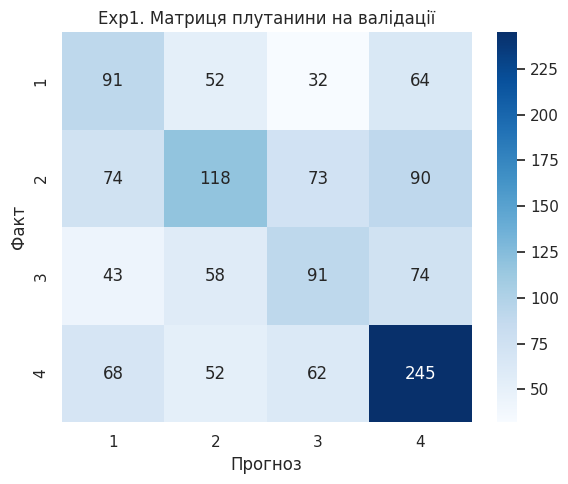

,Експеримент,Val QWK,Декодер,Епох навчено,Найкраща епоха,Нотатки
0,Exp0. Найчастіший клас,0.000,константа,0,0,орієнтир без ознак
1,Exp1. TF-IDF + логістична регресія,0.273,argmax,0,0,argmax 0.2730; expectation 0.2277; 5 с


In [22]:
majority_class = int(np.bincount(y_tr).argmax())
majority_pred = np.full_like(y_va, majority_class)
majority_qwk = quadratic_weighted_kappa(y_va, majority_pred)
print(
    f"Найчастіший клас індексу {majority_class} "
    f"(мітка {IDX_TO_LABEL[majority_class]}), val QWK {majority_qwk:.4f}, "
    f"accuracy {accuracy_score(y_va, majority_pred):.4f}"
)
log_experiment(
    "Exp0. Найчастіший клас",
    majority_qwk,
    "константа",
    0,
    0,
    "орієнтир без ознак",
)
RUNS["exp0"] = {"decoder": "константа", "val_qwk": majority_qwk, "best_epoch": 0}

started = time.perf_counter()
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=TFIDF_MIN_DF,
    max_features=TFIDF_MAX_FEATURES,
)
x_text_tr = tfidf.fit_transform(train_df.iloc[idx_tr]["text_clean"])
x_text_va = tfidf.transform(train_df.iloc[idx_va]["text_clean"])
text_clf = LogisticRegression(
    max_iter=500,
    class_weight="balanced",
    random_state=SEED,
)
text_clf.fit(x_text_tr, y_tr)
text_proba_raw = text_clf.predict_proba(x_text_va)
text_proba = np.zeros((len(y_va), N_CLASSES), dtype=np.float64)
for column, class_index in enumerate(text_clf.classes_):
    text_proba[:, int(class_index)] = text_proba_raw[:, column]
text_decoded = decode_probabilities(text_proba, N_CLASSES)
text_scores = {
    name: quadratic_weighted_kappa(y_va, prediction)
    for name, prediction in text_decoded.items()
}
text_decoder = "expectation" if text_scores["expectation"] > text_scores["argmax"] else "argmax"
text_qwk = text_scores[text_decoder]
text_pred = text_decoded[text_decoder]
elapsed = time.perf_counter() - started
print(
    f"TF-IDF ознак: {x_text_tr.shape[1]}. "
    f"QWK argmax {text_scores['argmax']:.4f}, expectation {text_scores['expectation']:.4f}. "
    f"Обрано {text_decoder}. Accuracy {accuracy_score(y_va, text_pred):.4f}. Час {elapsed:.1f} с."
)
plot_confusion(y_va, text_pred, "Exp1. Матриця плутанини на валідації")
log_experiment(
    "Exp1. TF-IDF + логістична регресія",
    text_qwk,
    text_decoder,
    0,
    0,
    f"argmax {text_scores['argmax']:.4f}; expectation {text_scores['expectation']:.4f}; {elapsed:.0f} с",
)
RUNS["exp1"] = {"decoder": text_decoder, "val_qwk": text_qwk, "best_epoch": 0}


### Висновки експерименту 1

*Заповнити після прогону. Порівняти QWK TF-IDF із найчастішим класом. Записати, який декодер виграв, argmax чи очікування, і які класи плутаються в матриці: сусідні чи далекі. Якщо приріст над константою малий, опис у поданні мішка слів майже не пояснює швидкість адопції.*


## 8. Експеримент 2. Зображення: заморожений ResNet18

На кількох тисячах фото мережа, навчена з нуля, легко запам'ятовує фон притулку і поставу конкретного кадру. ResNet18, уже навчений розрізняти об'єкти на ImageNet, дає вектор сцени: тварина, поза, крупність плану. Ці ваги заморожені. Навчається лише лінійна голова від 512 ознак і прапорця «фото не було».

До трьох кадрів усереднюються. Нульовий вектор без прапорця не відрізнити від дивного, але справжнього фото, тому відсутність знімка кодується окремою одиницею.

Голова теж зупиняється за val QWK. Ваги класів зворотні до частоти: інакше лінійний шар зсувається до найчастішої швидкості, і внесок фото неможливо побачити.


Ознаки ResNet завантажено з кешу: /kaggle/working/resnet18_pet_features.npz
Матриця ознак зображень train: (6431, 513) частка без фото 0.0
Параметрів голови зображень: 2056
Епоха 01/8 | train loss 1.4038 | val loss 1.3030 | QWK argmax 0.3844 | QWK expectation 0.2654
Епоха 02/8 | train loss 1.3024 | val loss 1.2712 | QWK argmax 0.3695 | QWK expectation 0.2975
Епоха 03/8 | train loss 1.2827 | val loss 1.2599 | QWK argmax 0.4247 | QWK expectation 0.3211
Епоха 04/8 | train loss 1.2679 | val loss 1.3028 | QWK argmax 0.4205 | QWK expectation 0.3292
Епоха 05/8 | train loss 1.2597 | val loss 1.2701 | QWK argmax 0.4076 | QWK expectation 0.3275
Рання зупинка на епосі 5: val QWK не зріс на 0.001 протягом 2 епох. Найкраща епоха 3, QWK 0.4247 (argmax).
Exp2 обраний декодер argmax, QWK 0.4247, accuracy 0.4421, епох 5, найкраща 3, час 1.5 с.


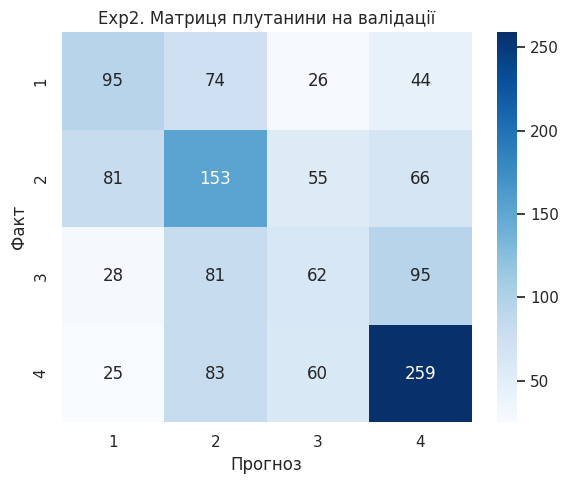

,Експеримент,Val QWK,Декодер,Епох навчено,Найкраща епоха,Нотатки
0,Exp0. Найчастіший клас,0.0000,константа,0,0,орієнтир без ознак
1,Exp1. TF-IDF + логістична регресія,0.2730,argmax,0,0,argmax 0.2730; expectation 0.2277; 5 с
2,Exp2. ResNet18 заморожений + лінійна голова,0.4247,argmax,5,3,argmax 0.4247; expectation 0.3211; 1 с


In [23]:
class PetImageDataset(Dataset):
    def __init__(self, records, transform):
        self.records = records
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, index):
        pet_id, path = self.records[index]
        try:
            with Image.open(path) as image:
                tensor = self.transform(image.convert("RGB"))
            ok = 1
        except Exception:
            tensor = torch.zeros(3, 224, 224)
            ok = 0
        return tensor, ok, pet_id


def extract_resnet_features(paths_by_pet, backbone, transform):
    records = [
        (pet_id, path)
        for pet_id, paths in paths_by_pet.items()
        for path in paths
    ]
    sums = {pet_id: np.zeros(512, dtype=np.float32) for pet_id in paths_by_pet}
    counts = {pet_id: 0 for pet_id in paths_by_pet}
    if not records:
        return {pet_id: (sums[pet_id], 0) for pet_id in paths_by_pet}

    loader = DataLoader(
        PetImageDataset(records, transform),
        batch_size=FEATURE_BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
    )
    backbone.eval()
    for tensors, oks, pet_ids_batch in tqdm(loader, desc="ResNet18"):
        features = backbone(tensors.to(device)).detach().cpu().numpy()
        oks = oks.numpy()
        for index, pet_id in enumerate(pet_ids_batch):
            if int(oks[index]) == 1:
                sums[pet_id] += features[index]
                counts[pet_id] += 1
    extracted = {}
    for pet_id in paths_by_pet:
        if counts[pet_id] > 0:
            extracted[pet_id] = (sums[pet_id] / counts[pet_id], counts[pet_id])
        else:
            extracted[pet_id] = (np.zeros(512, dtype=np.float32), 0)
    return extracted


def stack_image_features(pet_ids, feature_map):
    vectors = np.zeros((len(pet_ids), 512), dtype=np.float32)
    missing = np.ones((len(pet_ids), 1), dtype=np.float32)
    for index, pet_id in enumerate(pet_ids):
        vector, count = feature_map[pet_id]
        if count > 0:
            vectors[index] = vector
            missing[index, 0] = 0.0
    combined = np.concatenate([vectors, missing], axis=1)
    return vectors, missing, combined


def load_or_extract_features():
    needed = set(train_ids) | set(test_ids)
    if FEATURE_CACHE.exists():
        cached = np.load(FEATURE_CACHE, allow_pickle=False)
        cached_ids = [normalize_id(pet_id) for pet_id in cached["ids"].tolist()]
        if set(cached_ids) >= needed:
            feature_map = {}
            counts = np.array(cached["counts"], copy=True)
            matrix = np.array(cached["features"], dtype=np.float32, copy=True)
            for index, pet_id in enumerate(cached_ids):
                feature_map[pet_id] = (matrix[index].copy(), int(counts[index]))
            cached.close()
            print(f"Ознаки ResNet завантажено з кешу: {FEATURE_CACHE}")
            return feature_map
        cached.close()
        print("Кеш ознак не покриває поточні ідентифікатори, рахую заново.")

    try:
        weights = ResNet18_Weights.IMAGENET1K_V1
        backbone = resnet18(weights=weights)
        transform = weights.transforms()
    except Exception as exc:
        raise RuntimeError(
            "Не вдалося завантажити ваги ResNet18. Увімкніть Internet у налаштуваннях ноутбука."
        ) from exc
    backbone.fc = nn.Identity()
    backbone.to(device)
    backbone.eval()
    for parameter in backbone.parameters():
        parameter.requires_grad = False

    feature_map = extract_resnet_features(model_image_paths, backbone, transform)
    ids_array = np.array(list(feature_map.keys()))
    np.savez_compressed(
        FEATURE_CACHE,
        ids=ids_array,
        features=np.stack([feature_map[pet_id][0] for pet_id in ids_array]),
        counts=np.array([feature_map[pet_id][1] for pet_id in ids_array], dtype=np.int32),
    )
    print(f"Ознаки збережено: {FEATURE_CACHE}")
    del backbone
    if device.type == "cuda":
        torch.cuda.empty_cache()
    return feature_map


class FeatureDataset(Dataset):
    def __init__(self, features, labels=None):
        self.features = torch.tensor(np.asarray(features), dtype=torch.float32)
        self.labels = None if labels is None else torch.tensor(np.asarray(labels), dtype=torch.long)

    def __len__(self):
        return self.features.size(0)

    def __getitem__(self, index):
        if self.labels is None:
            return self.features[index]
        return self.features[index], self.labels[index]


class ImageHead(nn.Module):
    def __init__(self, in_dim, n_classes, dropout=DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_dim, n_classes),
        )

    def forward(self, features):
        return self.net(features)


def image_logits(model, batch, compute_loss):
    features, targets = batch
    features = features.to(device)
    targets = targets.to(device)
    logits = model(features)
    loss = image_criterion(logits, targets) if compute_loss else None
    return logits, targets, loss


@torch.no_grad()
def predict_feature_model(model, features):
    model.eval()
    loader = DataLoader(FeatureDataset(features), batch_size=256, shuffle=False)
    chunks = []
    for batch_features in loader:
        logits = model(batch_features.to(device))
        chunks.append(torch.softmax(logits, dim=1).cpu().numpy())
    return np.concatenate(chunks)


feature_map = load_or_extract_features()
_, _, image_combined = stack_image_features(train_ids, feature_map)
_, _, image_combined_test = stack_image_features(test_ids, feature_map)
print("Матриця ознак зображень train:", image_combined.shape, "частка без фото", round(float(image_combined[:, -1].mean()), 4))

set_seed(SEED)
image_criterion = nn.CrossEntropyLoss(weight=class_weights_from_labels(y_tr, N_CLASSES))
image_model = ImageHead(image_combined.shape[1], N_CLASSES).to(device)
image_optimizer = torch.optim.AdamW(image_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
print("Параметрів голови зображень:", count_parameters(image_model))
train_loader_img = DataLoader(
    FeatureDataset(image_combined[idx_tr], y_tr),
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=torch.Generator().manual_seed(SEED),
)
val_loader_img = DataLoader(
    FeatureDataset(image_combined[idx_va], y_va),
    batch_size=BATCH_SIZE,
    shuffle=False,
)
started = time.perf_counter()
image_fit = train_until_plateau(
    image_model, train_loader_img, val_loader_img, image_optimizer, image_logits, N_CLASSES
)
_, image_probs, image_true = collect_probabilities(image_model, val_loader_img, image_logits)
image_decoded = decode_probabilities(image_probs, N_CLASSES)
image_scores = {
    name: quadratic_weighted_kappa(image_true, prediction)
    for name, prediction in image_decoded.items()
}
image_decoder = image_fit["best_decoder"]
image_qwk = image_scores[image_decoder]
image_pred = image_decoded[image_decoder]
elapsed = time.perf_counter() - started
print(
    f"Exp2 обраний декодер {image_decoder}, QWK {image_qwk:.4f}, "
    f"accuracy {accuracy_score(image_true, image_pred):.4f}, "
    f"епох {image_fit['epochs_ran']}, найкраща {image_fit['best_epoch']}, час {elapsed:.1f} с."
)
plot_confusion(image_true, image_pred, "Exp2. Матриця плутанини на валідації")
log_experiment(
    "Exp2. ResNet18 заморожений + лінійна голова",
    image_qwk,
    image_decoder,
    image_fit["epochs_ran"],
    image_fit["best_epoch"],
    f"argmax {image_scores['argmax']:.4f}; expectation {image_scores['expectation']:.4f}; {elapsed:.0f} с",
)
RUNS["exp2"] = {
    "decoder": image_decoder,
    "val_qwk": image_qwk,
    "best_epoch": image_fit["best_epoch"],
}


### Висновки експерименту 2

*Заповнити після прогону. Порівняти val QWK фото з текстом і з найчастішим класом. Записати частку профілів без фото і чи рання зупинка спрацювала раніше за 8 епох. Якщо фото слабше за текст, заморожені ознаки сцени не відрізняють швидке усиновлення від повільного, і ускладнювати згорткову мережу має сенс лише після злиття.*


## 9. Експеримент 3. Злиття ResNet18 і BiLSTM

Вектор фото вже пораховано і в цей експеримент входить як готовий масив. Текст кодується двонаправленим LSTM: прямий прохід читає опис від початку історії до висновку, зворотний — навпаки, і для рішення важливі обидва кінці фрази. Береться один шар і розмірність 128, бо текстів кілька тисяч: глибша рекурентна мережа запам'ятає навчальні формулювання.

Один шар LSTM не має проміжного dropout між шарами, тому dropout стоїть на ембедингу слова і перед фінальним лінійним шаром.

Якщо в таблиці є придатні колонки, вони входять третьою гілкою. Категорії з числом значень до 400 отримують власний ембединг: порода чи колір — це код, а не величина. Вік, внесок, кількість фото стандартизуються. Кличка і ідентифікатор рятівника відкидаються: на новій тварині такого значення ще не було, і ембединг його не узагальнить.

Голова — конкатенація гілок, dropout і лінійний шар на число класів. Функція втрат — крос-ентропія з вагами, зворотними до частоти класу. Рання зупинка та сама, що для голови зображень. Графік втрат і QWK будується для цього експерименту, бо тут уперше одночасно навчаються текстові ваги і голова злиття.


Категоріальні колонки: []
Числові колонки: []
Розмір словника: 6740
Вхід голови злиття: 769
Параметрів, що навчаються: 1129992
Епоха 01/8 | train loss 1.3505 | val loss 1.2746 | QWK argmax 0.3786 | QWK expectation 0.2860
Епоха 02/8 | train loss 1.2194 | val loss 1.2474 | QWK argmax 0.4225 | QWK expectation 0.3615
Епоха 03/8 | train loss 1.1317 | val loss 1.2805 | QWK argmax 0.3877 | QWK expectation 0.3674
Епоха 04/8 | train loss 1.0480 | val loss 1.3685 | QWK argmax 0.3984 | QWK expectation 0.3948
Рання зупинка на епосі 4: val QWK не зріс на 0.001 протягом 2 епох. Найкраща епоха 2, QWK 0.4225 (argmax).
Exp3 обраний декодер argmax, QWK 0.4225, accuracy 0.4538, епох 4, найкраща 2, час 10.2 с.


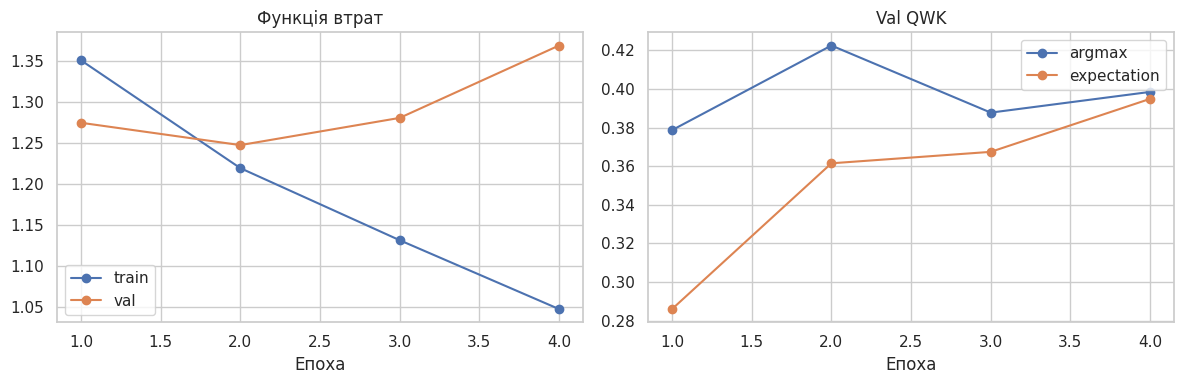

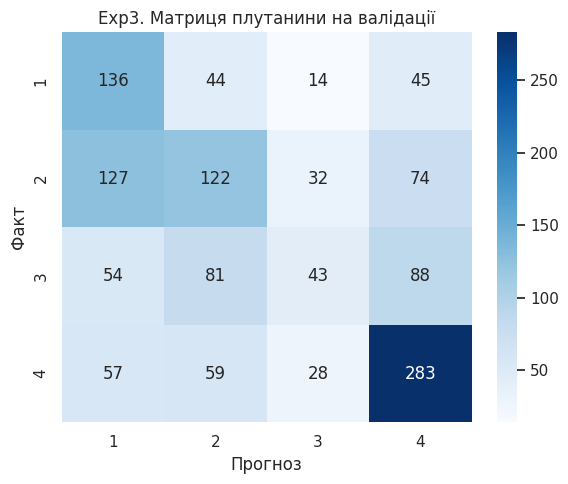

,Експеримент,Val QWK,Декодер,Епох навчено,Найкраща епоха,Нотатки
0,Exp0. Найчастіший клас,0.0000,константа,0,0,орієнтир без ознак
1,Exp1. TF-IDF + логістична регресія,0.2730,argmax,0,0,argmax 0.2730; expectation 0.2277; 5 с
2,Exp2. ResNet18 заморожений + лінійна голова,0.4247,argmax,5,3,argmax 0.4247; expectation 0.3211; 1 с
3,Exp3. ResNet18 + BiLSTM,0.4225,argmax,4,2,argmax 0.4225; expectation 0.3615; 10 с


In [24]:
class FusionDataset(Dataset):
    def __init__(self, texts, image_vectors, missing_flags, labels, vocabulary, categorical=None, numeric=None):
        self.texts = list(texts)
        self.image_vectors = np.asarray(image_vectors, dtype=np.float32)
        self.missing_flags = np.asarray(missing_flags, dtype=np.float32)
        self.labels = np.asarray(labels, dtype=np.int64)
        self.vocabulary = vocabulary
        self.categorical = None if categorical is None else np.asarray(categorical)
        self.numeric = None if numeric is None else np.asarray(numeric, dtype=np.float32)

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        item = {
            "text": self.vocabulary.encode(self.texts[index]),
            "image": torch.tensor(self.image_vectors[index]),
            "missing": torch.tensor(self.missing_flags[index]),
            "label": torch.tensor(self.labels[index]),
        }
        if self.categorical is not None:
            item["cat"] = torch.tensor(self.categorical[index], dtype=torch.long)
            item["num"] = torch.tensor(self.numeric[index], dtype=torch.float32)
        return item


def collate_fusion(batch):
    collated = {
        "text": pad_sequence([item["text"] for item in batch], batch_first=True, padding_value=0),
        "image": torch.stack([item["image"] for item in batch]),
        "missing": torch.stack([item["missing"] for item in batch]),
        "label": torch.stack([item["label"] for item in batch]),
    }
    if "cat" in batch[0]:
        collated["cat"] = torch.stack([item["cat"] for item in batch])
        collated["num"] = torch.stack([item["num"] for item in batch])
    return collated


class FusionNet(nn.Module):
    def __init__(self, vocab_size, n_classes, cat_cardinalities, n_numeric):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, EMBED_DIM, padding_idx=0)
        self.emb_dropout = nn.Dropout(DROPOUT)
        self.lstm = nn.LSTM(
            EMBED_DIM,
            LSTM_HIDDEN,
            num_layers=1,
            batch_first=True,
            bidirectional=True,
        )
        self.cat_embs = nn.ModuleList()
        cat_dim = 0
        for cardinality in cat_cardinalities:
            emb_dim = min(16, max(2, int(round(cardinality ** 0.5))))
            self.cat_embs.append(nn.Embedding(cardinality, emb_dim))
            cat_dim += emb_dim
        self.n_numeric = n_numeric
        self.fusion_dim = 512 + 1 + LSTM_HIDDEN * 2 + cat_dim + n_numeric
        self.head = nn.Sequential(
            nn.Dropout(DROPOUT),
            nn.Linear(self.fusion_dim, n_classes),
        )

    def encode_text(self, text):
        lengths = (text != 0).sum(dim=1).clamp(min=1)
        embedded = self.emb_dropout(self.embedding(text))
        packed = pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, (hidden, _) = self.lstm(packed)
        return torch.cat([hidden[0], hidden[1]], dim=1)

    def forward(self, text, image, missing, cat=None, num=None):
        parts = [image, missing, self.encode_text(text)]
        if len(self.cat_embs) and cat is not None:
            embedded_cats = [embedding(cat[:, index]) for index, embedding in enumerate(self.cat_embs)]
            parts.append(torch.cat(embedded_cats, dim=1))
        if self.n_numeric and num is not None:
            parts.append(num)
        return self.head(torch.cat(parts, dim=1))


def fusion_logits(model, batch, compute_loss):
    batch = batch_move(batch)
    logits = model(
        batch["text"],
        batch["image"],
        batch["missing"],
        batch.get("cat"),
        batch.get("num"),
    )
    targets = batch["label"]
    loss = fusion_criterion(logits, targets) if compute_loss else None
    return logits, targets, loss


def make_fusion_loader(texts, image_vectors, missing_flags, labels, vocabulary, categorical, numeric, shuffle):
    dataset = FusionDataset(
        texts, image_vectors, missing_flags, labels, vocabulary, categorical, numeric
    )
    generator = torch.Generator().manual_seed(SEED) if shuffle else None
    return DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        generator=generator,
        collate_fn=collate_fusion,
    )


@torch.no_grad()
def predict_fusion(model, loader):
    model.eval()
    chunks = []
    for batch in loader:
        logits, _, _ = fusion_logits(model, batch, compute_loss=False)
        chunks.append(torch.softmax(logits, dim=1).cpu().numpy())
    return np.concatenate(chunks)


tabular = TabularPreprocessor(id_col, target_col, text_col).fit(train_df.iloc[idx_tr])
print("Категоріальні колонки:", tabular.cat_cols)
print("Числові колонки:", tabular.num_cols)
cat_all, num_all = tabular.transform(train_df)
cat_test, num_test = tabular.transform(test_df)
use_tabular = bool(tabular.cat_cols or tabular.num_cols)
cat_tr = cat_all[idx_tr] if use_tabular else None
cat_va = cat_all[idx_va] if use_tabular else None
num_tr = num_all[idx_tr] if use_tabular else None
num_va = num_all[idx_va] if use_tabular else None

image_vectors_all = image_combined[:, :512]
missing_all = image_combined[:, 512:]
image_vectors_test = image_combined_test[:, :512]
missing_test = image_combined_test[:, 512:]

vocabulary = TextVocabulary().fit(train_df.iloc[idx_tr]["text_clean"])
print("Розмір словника:", len(vocabulary))

set_seed(SEED)
fusion_criterion = nn.CrossEntropyLoss(weight=class_weights_from_labels(y_tr, N_CLASSES))
fusion_model = FusionNet(
    len(vocabulary),
    N_CLASSES,
    tabular.cat_cardinalities if use_tabular else [],
    len(tabular.num_cols) if use_tabular else 0,
).to(device)
fusion_optimizer = torch.optim.AdamW(
    fusion_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
)
print("Вхід голови злиття:", fusion_model.fusion_dim)
print("Параметрів, що навчаються:", count_parameters(fusion_model))

train_loader_fusion = make_fusion_loader(
    train_df.iloc[idx_tr]["text_clean"],
    image_vectors_all[idx_tr],
    missing_all[idx_tr],
    y_tr,
    vocabulary,
    cat_tr,
    num_tr,
    shuffle=True,
)
val_loader_fusion = make_fusion_loader(
    train_df.iloc[idx_va]["text_clean"],
    image_vectors_all[idx_va],
    missing_all[idx_va],
    y_va,
    vocabulary,
    cat_va,
    num_va,
    shuffle=False,
)
started = time.perf_counter()
fusion_fit = train_until_plateau(
    fusion_model,
    train_loader_fusion,
    val_loader_fusion,
    fusion_optimizer,
    fusion_logits,
    N_CLASSES,
)
_, fusion_probs, fusion_true = collect_probabilities(fusion_model, val_loader_fusion, fusion_logits)
fusion_decoded = decode_probabilities(fusion_probs, N_CLASSES)
fusion_scores = {
    name: quadratic_weighted_kappa(fusion_true, prediction)
    for name, prediction in fusion_decoded.items()
}
fusion_decoder = fusion_fit["best_decoder"]
fusion_qwk = fusion_scores[fusion_decoder]
fusion_pred = fusion_decoded[fusion_decoder]
elapsed = time.perf_counter() - started
print(
    f"Exp3 обраний декодер {fusion_decoder}, QWK {fusion_qwk:.4f}, "
    f"accuracy {accuracy_score(fusion_true, fusion_pred):.4f}, "
    f"епох {fusion_fit['epochs_ran']}, найкраща {fusion_fit['best_epoch']}, час {elapsed:.1f} с."
)
plot_training_history(fusion_fit["history"])
plot_confusion(fusion_true, fusion_pred, "Exp3. Матриця плутанини на валідації")
exp3_name = "Exp3. ResNet18 + BiLSTM"
if use_tabular:
    exp3_name += " + табличні ознаки"
log_experiment(
    exp3_name,
    fusion_qwk,
    fusion_decoder,
    fusion_fit["epochs_ran"],
    fusion_fit["best_epoch"],
    f"argmax {fusion_scores['argmax']:.4f}; expectation {fusion_scores['expectation']:.4f}; {elapsed:.0f} с",
)
RUNS["exp3"] = {
    "name": exp3_name,
    "decoder": fusion_decoder,
    "val_qwk": fusion_qwk,
    "best_epoch": fusion_fit["best_epoch"],
    "use_tabular": use_tabular,
}


### Висновки експерименту 3

*Заповнити після прогону. За графіком втрат і QWK написати, чи зростала метрика разом із падінням loss, чи loss падав при плато QWK. Порівняти злиття з Exp1 і Exp2: чи обидві модальності потрібні, чи одна з них не додає нічого. Записати номер найкращої епохи і який декодер обрано.*


## 10. Порівняння і файл відповіді

Обирається найраніший експеримент, який пізніші не обганяють більше ніж на 0.001 val QWK. Такий приріст уже вважався шумом під час ранньої зупинки, і ускладнювати сабміт без нього немає підстави.

Обрана модель навчається заново на **усьому** розміченому train. Тестові мітки, навіть якщо вони раптом є у файлі, у це навчання не входять. Для нейромереж число епох дорівнює найкращій епосі валідаційного прогону. Декодер (argmax або очікування) теж фіксується за валідацією і на тесті не перебирається.

TF-IDF, словник і табличні перетворення для фінального навчання будуються вже на повному train, бо приховувати від фінальної моделі частину розмічених описів немає причини. Ознаки ResNet від міток не залежать і беруться з кешу.


In [25]:
comparison = pd.DataFrame(EXPERIMENT_ROWS)
print("Журнал експериментів, відсортований за val QWK:")
display(comparison.sort_values(["Val QWK", "Експеримент"], ascending=[False, True]).reset_index(drop=True))

best_index = 0
best_score = -1.0
for row_index, row in enumerate(EXPERIMENT_ROWS):
    score = row["Val QWK"]
    if score != score:
        score = -1.0
    if row_index == 0 or score > best_score + MIN_DELTA:
        best_index = row_index
        best_score = score
best_row = EXPERIMENT_ROWS[best_index]
best_name = best_row["Експеримент"]
print(
    f"Для сабміту обрано: {best_name}. "
    f"Val QWK {best_row['Val QWK']}. Декодер: {best_row['Декодер']}. "
    f"Найкраща епоха: {best_row['Найкраща епоха']}."
)


def probabilities_to_labels(probs, decoder):
    decoded = decode_probabilities(probs, N_CLASSES)
    if decoder not in decoded:
        decoder = "argmax"
    indexes = decoded[decoder]
    return [IDX_TO_LABEL[int(index)] for index in indexes]


def align_proba(proba, class_indexes):
    full = np.zeros((proba.shape[0], N_CLASSES), dtype=np.float64)
    for column, class_index in enumerate(class_indexes):
        full[:, int(class_index)] = proba[:, column]
    return full


if best_name.startswith("Exp0"):
    mode_label = IDX_TO_LABEL[int(np.bincount(y_all).argmax())]
    pred_labels = [mode_label] * len(test_df)
    print("Фінальний прогноз — найчастіший клас повного train:", mode_label)

elif best_name.startswith("Exp1"):
    final_tfidf = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=TFIDF_MIN_DF,
        max_features=TFIDF_MAX_FEATURES,
    )
    final_clf = LogisticRegression(max_iter=500, class_weight="balanced", random_state=SEED)
    final_clf.fit(final_tfidf.fit_transform(train_df["text_clean"]), y_all)
    test_proba = align_proba(
        final_clf.predict_proba(final_tfidf.transform(test_df["text_clean"])),
        final_clf.classes_,
    )
    pred_labels = probabilities_to_labels(test_proba, RUNS["exp1"]["decoder"])
    print("Фінальну логістичну регресію навчено на всіх розмічених описах.")

elif best_name.startswith("Exp2"):
    set_seed(SEED)
    final_epochs = max(int(RUNS["exp2"]["best_epoch"]), 1)
    final_image_criterion = nn.CrossEntropyLoss(weight=class_weights_from_labels(y_all, N_CLASSES))

    def final_image_logits(model, batch, compute_loss):
        features, targets = batch
        features = features.to(device)
        targets = targets.to(device)
        logits = model(features)
        loss = final_image_criterion(logits, targets) if compute_loss else None
        return logits, targets, loss

    final_image_model = ImageHead(image_combined.shape[1], N_CLASSES).to(device)
    final_image_optimizer = torch.optim.AdamW(
        final_image_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
    )
    final_loader = DataLoader(
        FeatureDataset(image_combined, y_all),
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )
    print(f"Повне навчання голови зображень: {final_epochs} епох.")
    train_fixed_epochs(final_image_model, final_loader, final_image_optimizer, final_image_logits, final_epochs)
    test_proba = predict_feature_model(final_image_model, image_combined_test)
    pred_labels = probabilities_to_labels(test_proba, RUNS["exp2"]["decoder"])

elif best_name.startswith("Exp3"):
    set_seed(SEED)
    final_epochs = max(int(RUNS["exp3"]["best_epoch"]), 1)
    final_tabular = TabularPreprocessor(id_col, target_col, text_col).fit(train_df)
    final_cat, final_num = final_tabular.transform(train_df)
    final_cat_test, final_num_test = final_tabular.transform(test_df)
    final_vocab = TextVocabulary().fit(train_df["text_clean"])
    final_use_tabular = bool(final_tabular.cat_cols or final_tabular.num_cols)
    final_fusion_criterion = nn.CrossEntropyLoss(weight=class_weights_from_labels(y_all, N_CLASSES))

    def final_fusion_logits(model, batch, compute_loss):
        batch = batch_move(batch)
        logits = model(
            batch["text"],
            batch["image"],
            batch["missing"],
            batch.get("cat"),
            batch.get("num"),
        )
        targets = batch["label"]
        loss = final_fusion_criterion(logits, targets) if compute_loss else None
        return logits, targets, loss

    final_fusion = FusionNet(
        len(final_vocab),
        N_CLASSES,
        final_tabular.cat_cardinalities if final_use_tabular else [],
        len(final_tabular.num_cols) if final_use_tabular else 0,
    ).to(device)
    final_optimizer = torch.optim.AdamW(
        final_fusion.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY
    )
    final_loader = make_fusion_loader(
        train_df["text_clean"],
        image_vectors_all,
        missing_all,
        y_all,
        final_vocab,
        final_cat if final_use_tabular else None,
        final_num if final_use_tabular else None,
        shuffle=True,
    )
    print(f"Повне навчання злиття: {final_epochs} епох, словник {len(final_vocab)}.")
    # Локальні logits цієї комірки не підміняють функцію валідаційного експерименту.
    saved_fusion_logits = fusion_logits
    fusion_logits = final_fusion_logits
    try:
        train_fixed_epochs(final_fusion, final_loader, final_optimizer, fusion_logits, final_epochs)
        test_loader = make_fusion_loader(
            test_df["text_clean"],
            image_vectors_test,
            missing_test,
            np.zeros(len(test_df), dtype=int),
            final_vocab,
            final_cat_test if final_use_tabular else None,
            final_num_test if final_use_tabular else None,
            shuffle=False,
        )
        test_proba = predict_fusion(final_fusion, test_loader)
    finally:
        fusion_logits = saved_fusion_logits
    pred_labels = probabilities_to_labels(test_proba, RUNS["exp3"]["decoder"])

else:
    raise RuntimeError(f"Невідомий експеримент у журналі: {best_name}")

sample_id_col = find_column(sample_df.columns, ["PetID", "pet_id", "id"])
sample_target_col = find_column(sample_df.columns, ["AdoptionSpeed", "adoption_speed", "label", "target"])
if sample_id_col is None or sample_target_col is None:
    raise RuntimeError(f"sample_submission має несподівані колонки: {list(sample_df.columns)}")
if len(pred_labels) != len(test_ids):
    raise RuntimeError(f"Прогнозів {len(pred_labels)}, а рядків у test.csv — {len(test_ids)}.")

submission = pd.DataFrame({
    "PetID": [normalize_id(pet_id) for pet_id in test_ids],
    "AdoptionSpeed": pred_labels,
})
duplicate_ids = int(submission["PetID"].duplicated().sum())
if duplicate_ids:
    print(f"Повторні PetID у test: {duplicate_ids}. У файл іде перший прогноз.")
    submission = submission.drop_duplicates("PetID", keep="first")

sample_ids = sample_df[sample_id_col].map(normalize_id)
same_ids = set(sample_ids) == set(submission["PetID"]) and len(sample_ids) == len(submission)
if same_ids:
    submission = submission.set_index("PetID").loc[sample_ids.tolist()].reset_index()
else:
    print(
        f"sample_submission має {len(sample_ids)} рядків, test.csv — {len(test_ids)}. "
        "У відповідь записано кожен PetID з test.csv: короткий зразок не замінює тестовий набір."
    )

allowed_labels = set(IDX_TO_LABEL.values())
unknown_labels = sorted(set(submission["AdoptionSpeed"]) - allowed_labels)
if unknown_labels:
    raise RuntimeError(f"У відповіді є мітки поза шкалою train: {unknown_labels}")
submission["AdoptionSpeed"] = submission["AdoptionSpeed"].astype(int)
submission = submission[["PetID", "AdoptionSpeed"]]
if submission["PetID"].eq("").any() or submission["AdoptionSpeed"].isna().any():
    raise RuntimeError("У відповіді є порожній PetID або пропущена мітка.")

submission.to_csv(SUBMISSION_PATH, index=False)
print("Збережено", SUBMISSION_PATH)
print(f"Рядків: {len(submission)}. Колонки: {list(submission.columns)}.")
print(submission["AdoptionSpeed"].value_counts().sort_index())
display(submission.head(3))
display(submission.tail(3))


Журнал експериментів, відсортований за val QWK:


,Експеримент,Val QWK,Декодер,Епох навчено,Найкраща епоха,Нотатки
0,Exp2. ResNet18 заморожений + лінійна голова,0.4247,argmax,5,3,argmax 0.4247; expectation 0.3211; 1 с
1,Exp3. ResNet18 + BiLSTM,0.4225,argmax,4,2,argmax 0.4225; expectation 0.3615; 10 с
2,Exp1. TF-IDF + логістична регресія,0.2730,argmax,0,0,argmax 0.2730; expectation 0.2277; 5 с
3,Exp0. Найчастіший клас,0.0000,константа,0,0,орієнтир без ознак


Для сабміту обрано: Exp2. ResNet18 заморожений + лінійна голова. Val QWK 0.4247. Декодер: argmax. Найкраща епоха: 3.
Повне навчання голови зображень: 3 епох.
Повне навчання, епоха 1/3, train loss 1.3761
Повне навчання, епоха 2/3, train loss 1.3010
Повне навчання, епоха 3/3, train loss 1.2955
sample_submission має 4 рядків, test.csv — 1891. У відповідь записано кожен PetID з test.csv: короткий зразок не замінює тестовий набір.
Збережено /kaggle/working/submission.csv
Рядків: 1891. Колонки: ['PetID', 'AdoptionSpeed'].
AdoptionSpeed
1    715
2    167
3    395
4    614
Name: count, dtype: int64


,PetID,AdoptionSpeed
0,6697a7f62,4
1,23b64fe21,3
2,41e824cbe,4


,PetID,AdoptionSpeed
1888,c60193e34,1
1889,4f7a70728,3
1890,9e758c0b0,1


## Загальні висновки

*Заповнити після прогону. Порівняти val QWK орієнтира, тексту, фото і злиття. Назвати модель і декодер, які пішли в `submission.csv`, і написати, на якій епосі спрацювала рання зупинка. Окремо відповісти на чотири питання цього прогону:*

- *чи текст сам по собі кращий за найчастіший клас;*
- *чи додають фото щось понад текст;*
- *чи злиття краще за кожну модальність окремо;*
- *чи округлення очікування класу краще за argmax.*

*Public score змагання після сабміту: ____.*


## Наступні експерименти

Нижче додаються нові блоки після аналізу цього прогону. Попередні комірки не замінюються: журнал має показувати весь хід, включно з невдалими варіантами.

Що має сенс додати, залежить від чисел вище.

- Якщо заморожені ознаки фото майже не відстають від злиття, але плато настає рано — донавчити останній блок ResNet, лишивши решту ваг замороженими.
- Якщо потрібно показати ціну навчання з нуля — невелика згорткова мережа на тих самих фото, як порівняння з перенесеними вагами.
- Якщо опис дає більший внесок, ніж фото — сильніший текстовий енкодер замість одного шару LSTM.
- Якщо помилки в матриці переважно сусідні, а QWK все одно низький — ординальна або регресійна голова: класи швидкості впорядковані, а крос-ентропія трактує їх як незалежні.
- Якщо архітектура злиття вже краща за окремі модальності — пошук гіперпараметрів голови (dropout, розмір прихованого стану, швидкість навчання, увімкнення ваг класів) на вже порахованих ембедингах зображень. Перебирати всю мережу з нуля на кожному тріалі не варто: один валідаційний спліт на кількох тисячах рядків легко підігнати, а час сесії піде на повторення одного й того самого витягу ознак.


## Розділ 11

In [2]:
# Стан для нового експерименту. Якщо комірки вище вже виконані в цьому ядрі, таблиці не перечитуються.
needs_tables = "train_df" not in globals() or "idx_tr" not in globals() or "y_all" not in globals()
if not needs_tables:
    print(f"Таблиці вже в пам'яті: train {len(train_df)}, val {len(idx_va)}. Повторно не читаю.")
else:
    import random
    from pathlib import Path
    import numpy as np
    import pandas as pd
    import torch
    from sklearn.metrics import cohen_kappa_score
    from sklearn.model_selection import train_test_split

    SEED = 42
    VAL_SIZE = 0.2
    DATA_ROOT = Path("/kaggle/input/competitions/deep-learning-for-computer-vision-and-nlp-2026-10")
    TRAIN_CSV = DATA_ROOT / "train.csv"
    TEST_CSV = DATA_ROOT / "test.csv"
    SAMPLE_CSV = DATA_ROOT / "sample_submission.csv"
    WORKING = Path("/kaggle/working")
    WORKING.mkdir(parents=True, exist_ok=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    def find_column(columns, options):
        lookup = {str(column).lower(): column for column in columns}
        for option in options:
            if option.lower() in lookup:
                return lookup[option.lower()]
        return None

    def normalize_id(value):
        if pd.isna(value):
            return ""
        text = str(value).strip()
        if text.endswith(".0"):
            text = text[:-2]
        return text

    def read_table(path):
        frame = pd.read_csv(path)
        frame.columns = [str(column).strip() for column in frame.columns]
        return frame

    def quadratic_weighted_kappa(y_true, y_pred):
        y_true = np.asarray(y_true).astype(int)
        y_pred = np.asarray(y_pred).astype(int)
        if len(y_true) == 0:
            return 0.0
        score = cohen_kappa_score(y_true, y_pred, weights="quadratic")
        if score != score:
            return 0.0
        return float(score)

    train_df = read_table(TRAIN_CSV)
    test_df = read_table(TEST_CSV)
    sample_df = read_table(SAMPLE_CSV)
    id_col = find_column(train_df.columns, ["PetID", "pet_id", "id"])
    target_col = find_column(train_df.columns, ["AdoptionSpeed", "adoption_speed", "label", "target"])
    text_col = find_column(train_df.columns, ["Description", "description", "desc", "text", "comments"])
    test_id_col = find_column(test_df.columns, ["PetID", "pet_id", "id"]) or id_col
    train_df[id_col] = train_df[id_col].map(normalize_id)
    test_df[test_id_col] = test_df[test_id_col].map(normalize_id)
    if int(train_df[id_col].duplicated().sum()):
        train_df = train_df.drop_duplicates(id_col, keep="first")
    train_df = train_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)
    if target_col in test_df.columns:
        test_df = test_df.drop(columns=[target_col])
    test_text_col = find_column(test_df.columns, ["Description", "description", "desc", "text", "comments"])
    if text_col is None:
        text_col = "Description"
        train_df[text_col] = ""
        test_df[text_col] = ""
    elif test_text_col is None:
        test_df[text_col] = ""
    elif test_text_col != text_col:
        test_df[text_col] = test_df[test_text_col]
    raw_target = train_df[target_col]
    if pd.api.types.is_numeric_dtype(raw_target):
        numeric_target = raw_target.astype(float)
        if np.allclose(numeric_target.to_numpy(), np.rint(numeric_target.to_numpy())):
            train_df[target_col] = numeric_target.round().astype(int)
    classes = sorted(train_df[target_col].dropna().unique().tolist())
    LABEL_TO_IDX = {label: index for index, label in enumerate(classes)}
    IDX_TO_LABEL = {index: label for label, index in LABEL_TO_IDX.items()}
    N_CLASSES = len(classes)
    train_df = train_df.dropna(subset=[target_col]).reset_index(drop=True)
    y_all = train_df[target_col].map(LABEL_TO_IDX).to_numpy(dtype=int)
    idx_tr, idx_va = train_test_split(
        np.arange(len(train_df)), test_size=VAL_SIZE, random_state=SEED, stratify=y_all
    )
    y_tr = y_all[idx_tr]
    y_va = y_all[idx_va]
    test_ids = test_df[test_id_col].tolist()
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    print(f"Таблиці прочитано заново: train {len(train_df)}, val {len(idx_va)}, test {len(test_df)}.")

if len(idx_va) != 1287:
    print(f"Увага: у валідації {len(idx_va)} рядків, у минулому прогоні було 1287. QWK буде не на тому самому розбитті.")
else:
    print("Розбиття збігається з минулим прогоном: 1287 валідаційних рядків.")

train_raw_text = train_df[text_col].fillna("").astype(str).tolist()
test_raw_text = test_df[text_col].fillna("").astype(str).tolist()
print("Сирих описів train/test:", len(train_raw_text), len(test_raw_text))
print("Пристрій:", device)


Таблиці прочитано заново: train 6431, val 1287, test 1891.
Розбиття збігається з минулим прогоном: 1287 валідаційних рядків.
Сирих описів train/test: 6431 1891
Пристрій: cuda


In [3]:
import numpy as np
import torch
from tqdm.auto import tqdm
from transformers import AutoModel, AutoTokenizer

TEXT_ENCODER_NAME = "distilbert-base-uncased"
MAX_TEXT_MODEL_LEN = 256
TEXT_EMBED_BATCH = 32
TEXT_EMBED_CACHE = WORKING / "distilbert_description_embeddings.npz"


def embed_texts(texts, tokenizer, encoder):
    vectors = None
    truncated = 0
    encoder.eval()
    for start in tqdm(range(0, len(texts), TEXT_EMBED_BATCH), desc="DistilBERT"):
        chunk = [text if isinstance(text, str) else "" for text in texts[start:start + TEXT_EMBED_BATCH]]
        uncut = tokenizer(chunk, add_special_tokens=True, truncation=False, padding=False)
        truncated += sum(len(token_ids) > MAX_TEXT_MODEL_LEN for token_ids in uncut["input_ids"])
        encoded = tokenizer(
            chunk,
            padding=True,
            truncation=True,
            max_length=MAX_TEXT_MODEL_LEN,
            return_tensors="pt",
        )
        encoded = {key: value.to(device) for key, value in encoded.items() if key in {"input_ids", "attention_mask"}}
        hidden = encoder(**encoded).last_hidden_state
        mask = encoded["attention_mask"].unsqueeze(-1).float()
        pooled = (hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1.0)
        pooled = pooled.detach().cpu().numpy().astype(np.float32)
        if vectors is None:
            vectors = np.zeros((len(texts), pooled.shape[1]), dtype=np.float32)
        vectors[start:start + len(chunk)] = pooled
    return vectors, truncated


cache_ok = False
if TEXT_EMBED_CACHE.exists():
    cached = np.load(TEXT_EMBED_CACHE, allow_pickle=False)
    same_shape = cached["train"].shape[0] == len(train_raw_text) and cached["test"].shape[0] == len(test_raw_text)
    same_model = str(cached["model_name"].item()) == TEXT_ENCODER_NAME if cached["model_name"].shape == () else False
    if same_shape and same_model and int(cached["max_len"]) == MAX_TEXT_MODEL_LEN:
        text_train_emb = np.array(cached["train"], dtype=np.float32, copy=True)
        text_test_emb = np.array(cached["test"], dtype=np.float32, copy=True)
        cache_ok = True
        print(f"Текстові ембединги взято з кешу {TEXT_EMBED_CACHE}, розмір {text_train_emb.shape}.")
    cached.close()

if not cache_ok:
    tokenizer = AutoTokenizer.from_pretrained(TEXT_ENCODER_NAME)
    encoder = AutoModel.from_pretrained(TEXT_ENCODER_NAME).to(device)
    encoder.eval()
    for parameter in encoder.parameters():
        parameter.requires_grad = False
    text_train_emb, train_truncated = embed_texts(train_raw_text, tokenizer, encoder)
    text_test_emb, test_truncated = embed_texts(test_raw_text, tokenizer, encoder)
    print(
        f"Обрізано описів до {MAX_TEXT_MODEL_LEN} токенів: "
        f"train {train_truncated}/{len(train_raw_text)} ({train_truncated / max(len(train_raw_text), 1):.1%}), "
        f"test {test_truncated}/{len(test_raw_text)} ({test_truncated / max(len(test_raw_text), 1):.1%})."
    )
    np.savez_compressed(
        TEXT_EMBED_CACHE,
        train=text_train_emb,
        test=text_test_emb,
        model_name=np.array(TEXT_ENCODER_NAME),
        max_len=np.int32(MAX_TEXT_MODEL_LEN),
    )
    print("Збережено", TEXT_EMBED_CACHE, text_train_emb.shape)
    del encoder, tokenizer
    if device.type == "cuda":
        torch.cuda.empty_cache()


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

...

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


DistilBERT:   0%|          | 0/201 [00:00<?, ?it/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (1106 > 512). Running this sequence through the model will result in indexing errors


DistilBERT:   0%|          | 0/60 [00:00<?, ?it/s]

Обрізано описів до 256 токенів: train 364/6431 (5.7%), test 111/1891 (5.9%).
Збережено /kaggle/working/distilbert_description_embeddings.npz (6431, 768)


In [4]:
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader, Dataset

HEAD_DROPOUT = 0.3
HEAD_LR = 1e-3
HEAD_WEIGHT_DECAY = 1e-4
HEAD_MAX_EPOCHS = 8
HEAD_PATIENCE = 2
HEAD_MIN_DELTA = 0.001
IMAGE_VAL_QWK = 0.4247
TFIDF_VAL_QWK = 0.2730


class EmbeddingDataset(Dataset):
    def __init__(self, features, labels=None):
        self.features = torch.tensor(np.asarray(features), dtype=torch.float32)
        self.labels = None if labels is None else torch.tensor(np.asarray(labels), dtype=torch.long)

    def __len__(self):
        return self.features.size(0)

    def __getitem__(self, index):
        if self.labels is None:
            return self.features[index]
        return self.features[index], self.labels[index]


class TextEmbeddingHead(nn.Module):
    def __init__(self, in_dim, n_classes, dropout=HEAD_DROPOUT):
        super().__init__()
        self.net = nn.Sequential(nn.Dropout(dropout), nn.Linear(in_dim, n_classes))

    def forward(self, features):
        return self.net(features)


def decode_probabilities(probs, n_classes):
    class_index = np.arange(n_classes, dtype=np.float64)
    expectation = np.clip(np.rint(probs @ class_index), 0, n_classes - 1).astype(int)
    return {"argmax": probs.argmax(axis=1).astype(int), "expectation": expectation}


def fit_embedding_head(features_train, labels_train, features_val, labels_val):
    torch.manual_seed(SEED)
    model = TextEmbeddingHead(features_train.shape[1], N_CLASSES).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=HEAD_LR, weight_decay=HEAD_WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss()
    train_loader = DataLoader(
        EmbeddingDataset(features_train, labels_train),
        batch_size=64,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )
    val_loader = DataLoader(EmbeddingDataset(features_val, labels_val), batch_size=256, shuffle=False)
    best_qwk = -1.0
    best_epoch = 1
    best_decoder = "argmax"
    best_state = copy.deepcopy(model.state_dict())
    wait = 0
    epochs_ran = 0
    for epoch in range(1, HEAD_MAX_EPOCHS + 1):
        epochs_ran = epoch
        model.train()
        total_loss, seen = 0.0, 0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            total_loss += loss.item() * batch_y.size(0)
            seen += batch_y.size(0)
        model.eval()
        prob_chunks, true_chunks = [], []
        val_loss, val_seen = 0.0, 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                logits = model(batch_x)
                val_loss += criterion(logits, batch_y).item() * batch_y.size(0)
                val_seen += batch_y.size(0)
                prob_chunks.append(torch.softmax(logits, dim=1).cpu().numpy())
                true_chunks.append(batch_y.cpu().numpy())
        probs = np.concatenate(prob_chunks)
        y_true = np.concatenate(true_chunks)
        decoded = decode_probabilities(probs, N_CLASSES)
        qwk_argmax = quadratic_weighted_kappa(y_true, decoded["argmax"])
        qwk_expectation = quadratic_weighted_kappa(y_true, decoded["expectation"])
        epoch_decoder = "expectation" if qwk_expectation > qwk_argmax else "argmax"
        epoch_qwk = qwk_expectation if epoch_decoder == "expectation" else qwk_argmax
        print(
            f"Епоха {epoch:02d}/{HEAD_MAX_EPOCHS} | train loss {total_loss / max(seen, 1):.4f} | "
            f"val loss {val_loss / max(val_seen, 1):.4f} | "
            f"QWK argmax {qwk_argmax:.4f} | QWK expectation {qwk_expectation:.4f}"
        )
        if epoch_qwk > best_qwk + HEAD_MIN_DELTA:
            best_qwk = epoch_qwk
            best_epoch = epoch
            best_decoder = epoch_decoder
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= HEAD_PATIENCE:
                print(f"Рання зупинка на епосі {epoch}. Найкраща епоха {best_epoch}, QWK {best_qwk:.4f} ({best_decoder}).")
                break
    model.load_state_dict(best_state)
    return model, best_qwk, best_epoch, best_decoder, epochs_ran


def predict_head(model, features):
    model.eval()
    loader = DataLoader(EmbeddingDataset(features), batch_size=256, shuffle=False)
    chunks = []
    with torch.no_grad():
        for batch_x in loader:
            logits = model(batch_x.to(device))
            chunks.append(torch.softmax(logits, dim=1).cpu().numpy())
    return np.concatenate(chunks)


print("Параметрів голови:", int(text_train_emb.shape[1] * N_CLASSES + N_CLASSES))
text_model, text_bert_qwk, text_best_epoch, text_decoder, text_epochs = fit_embedding_head(
    text_train_emb[idx_tr], y_tr, text_train_emb[idx_va], y_va
)
val_probs = predict_head(text_model, text_train_emb[idx_va])
val_decoded = decode_probabilities(val_probs, N_CLASSES)
val_scores = {name: quadratic_weighted_kappa(y_va, pred) for name, pred in val_decoded.items()}
chosen_pred = val_decoded[text_decoder]
print(
    f"Exp4 QWK argmax {val_scores['argmax']:.4f}, expectation {val_scores['expectation']:.4f}. "
    f"Обрано {text_decoder}, accuracy {accuracy_score(y_va, chosen_pred):.4f}."
)
print("Прогнози на валідації:")
print(pd.Series(chosen_pred).map(IDX_TO_LABEL).value_counts().sort_index())
print(f"Порівняння: TF-IDF {TFIDF_VAL_QWK:.4f}, фото {IMAGE_VAL_QWK:.4f}, DistilBERT {val_scores[text_decoder]:.4f}.")

exp4_name = "Exp4. DistilBERT заморожений + лінійна голова"
exp4_notes = (
    f"без ваг класів; argmax {val_scores['argmax']:.4f}; "
    f"expectation {val_scores['expectation']:.4f}; max_len {MAX_TEXT_MODEL_LEN}"
)
if "log_experiment" in globals():
    log_experiment(exp4_name, val_scores[text_decoder], text_decoder, text_epochs, text_best_epoch, exp4_notes)
else:
    print(exp4_name, round(val_scores[text_decoder], 4), text_decoder, "епох", text_epochs, "найкраща", text_best_epoch)

if val_scores[text_decoder] > IMAGE_VAL_QWK + HEAD_MIN_DELTA:
    print("Текст обігнав фото на валідації. Навчаю голову на повному train і пишу submission.csv.")
    torch.manual_seed(SEED)
    final_text_model = TextEmbeddingHead(text_train_emb.shape[1], N_CLASSES).to(device)
    final_optimizer = torch.optim.AdamW(final_text_model.parameters(), lr=HEAD_LR, weight_decay=HEAD_WEIGHT_DECAY)
    final_criterion = nn.CrossEntropyLoss()
    final_loader = DataLoader(
        EmbeddingDataset(text_train_emb, y_all),
        batch_size=64,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )
    final_epochs = max(int(text_best_epoch), 1)
    final_text_model.train()
    for epoch in range(1, final_epochs + 1):
        total_loss, seen = 0.0, 0
        for batch_x, batch_y in final_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            final_optimizer.zero_grad(set_to_none=True)
            logits = final_text_model(batch_x)
            loss = final_criterion(logits, batch_y)
            loss.backward()
            nn.utils.clip_grad_norm_(final_text_model.parameters(), 5.0)
            final_optimizer.step()
            total_loss += loss.item() * batch_y.size(0)
            seen += batch_y.size(0)
        print(f"Повне навчання тексту, епоха {epoch}/{final_epochs}, train loss {total_loss / max(seen, 1):.4f}")
    test_probs = predict_head(final_text_model, text_test_emb)
    test_idx = decode_probabilities(test_probs, N_CLASSES)[text_decoder]
    submission = pd.DataFrame({
        "PetID": [normalize_id(pet_id) for pet_id in test_ids],
        "AdoptionSpeed": [IDX_TO_LABEL[int(index)] for index in test_idx],
    })
    submission = submission.drop_duplicates("PetID", keep="first")
    submission["AdoptionSpeed"] = submission["AdoptionSpeed"].astype(int)
    submission = submission[["PetID", "AdoptionSpeed"]]
    submission.to_csv(WORKING / "submission.csv", index=False)
    print(f"Збережено submission.csv, рядків {len(submission)}.")
    print(submission["AdoptionSpeed"].value_counts().sort_index())
else:
    print(
        "Новий submission.csv не записано: val QWK не вищий за фото більше ніж на 0.001. "
        "Публічний файл із ResNet лишається чинним."
    )


Параметрів голови: 3076
Епоха 01/8 | train loss 1.3518 | val loss 1.3341 | QWK argmax 0.0183 | QWK expectation 0.0049
Епоха 02/8 | train loss 1.3222 | val loss 1.3338 | QWK argmax 0.0705 | QWK expectation 0.0584
Епоха 03/8 | train loss 1.3178 | val loss 1.3172 | QWK argmax 0.0900 | QWK expectation 0.0550
Епоха 04/8 | train loss 1.2999 | val loss 1.3184 | QWK argmax 0.1629 | QWK expectation 0.1216
Епоха 05/8 | train loss 1.2960 | val loss 1.3106 | QWK argmax 0.1418 | QWK expectation 0.1034
Епоха 06/8 | train loss 1.2923 | val loss 1.3095 | QWK argmax 0.1454 | QWK expectation 0.1099
Рання зупинка на епосі 6. Найкраща епоха 4, QWK 0.1629 (argmax).
Exp4 QWK argmax 0.1629, expectation 0.1216. Обрано argmax, accuracy 0.3792.
Прогнози на валідації:
1    121
2    465
3     30
4    671
Name: count, dtype: int64
Порівняння: TF-IDF 0.2730, фото 0.4247, DistilBERT 0.1629.
Exp4. DistilBERT заморожений + лінійна голова 0.1629 argmax епох 6 найкраща 4
Новий submission.csv не записано: val QWK не вищи

## Розділ 12

In [1]:
import os
import random
import re
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import cohen_kappa_score
from sklearn.model_selection import train_test_split

SEED = 42
VAL_SIZE = 0.2
MAX_IMAGES = 3
FEATURE_BATCH_SIZE = 64
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
DATA_ROOT = Path("/kaggle/input/competitions/deep-learning-for-computer-vision-and-nlp-2026-10")
IMAGE_DIR = DATA_ROOT / "images"
WORKING = Path("/kaggle/working")
WORKING.mkdir(parents=True, exist_ok=True)
NUM_WORKERS = 2 if os.name != "nt" else 0
if "device" not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

needs_tables = "train_df" not in globals() or "idx_tr" not in globals() or "y_all" not in globals()
if not needs_tables:
    print(f"Таблиці вже в пам'яті: train {len(train_df)}, val {len(idx_va)}. Повторно не читаю.")
else:
    TRAIN_CSV = DATA_ROOT / "train.csv"
    TEST_CSV = DATA_ROOT / "test.csv"
    SAMPLE_CSV = DATA_ROOT / "sample_submission.csv"

    def find_column(columns, options):
        lookup = {str(column).lower(): column for column in columns}
        for option in options:
            if option.lower() in lookup:
                return lookup[option.lower()]
        return None

    def normalize_id(value):
        if pd.isna(value):
            return ""
        text = str(value).strip()
        if text.endswith(".0"):
            text = text[:-2]
        return text

    def read_table(path):
        frame = pd.read_csv(path)
        frame.columns = [str(column).strip() for column in frame.columns]
        return frame

    def quadratic_weighted_kappa(y_true, y_pred):
        y_true = np.asarray(y_true).astype(int)
        y_pred = np.asarray(y_pred).astype(int)
        if len(y_true) == 0:
            return 0.0
        score = cohen_kappa_score(y_true, y_pred, weights="quadratic")
        if score != score:
            return 0.0
        return float(score)

    train_df = read_table(TRAIN_CSV)
    test_df = read_table(TEST_CSV)
    sample_df = read_table(SAMPLE_CSV)
    id_col = find_column(train_df.columns, ["PetID", "pet_id", "id"])
    target_col = find_column(train_df.columns, ["AdoptionSpeed", "adoption_speed", "label", "target"])
    text_col = find_column(train_df.columns, ["Description", "description", "desc", "text", "comments"])
    test_id_col = find_column(test_df.columns, ["PetID", "pet_id", "id"]) or id_col
    train_df[id_col] = train_df[id_col].map(normalize_id)
    test_df[test_id_col] = test_df[test_id_col].map(normalize_id)
    if int(train_df[id_col].duplicated().sum()):
        train_df = train_df.drop_duplicates(id_col, keep="first")
    train_df = train_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)
    if target_col in test_df.columns:
        test_df = test_df.drop(columns=[target_col])
    test_text_col = find_column(test_df.columns, ["Description", "description", "desc", "text", "comments"])
    if text_col is None:
        text_col = "Description"
        train_df[text_col] = ""
        test_df[text_col] = ""
    elif test_text_col is None:
        test_df[text_col] = ""
    elif test_text_col != text_col:
        test_df[text_col] = test_df[test_text_col]
    raw_target = train_df[target_col]
    if pd.api.types.is_numeric_dtype(raw_target):
        numeric_target = raw_target.astype(float)
        if np.allclose(numeric_target.to_numpy(), np.rint(numeric_target.to_numpy())):
            train_df[target_col] = numeric_target.round().astype(int)
    classes = sorted(train_df[target_col].dropna().unique().tolist())
    LABEL_TO_IDX = {label: index for index, label in enumerate(classes)}
    IDX_TO_LABEL = {index: label for label, index in LABEL_TO_IDX.items()}
    N_CLASSES = len(classes)
    train_df = train_df.dropna(subset=[target_col]).reset_index(drop=True)
    y_all = train_df[target_col].map(LABEL_TO_IDX).to_numpy(dtype=int)
    idx_tr, idx_va = train_test_split(
        np.arange(len(train_df)), test_size=VAL_SIZE, random_state=SEED, stratify=y_all
    )
    y_tr = y_all[idx_tr]
    y_va = y_all[idx_va]
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    print(f"Таблиці прочитано заново: train {len(train_df)}, val {len(idx_va)}, test {len(test_df)}.")

if "train_ids" not in globals():
    train_ids = train_df[id_col].tolist()
if "test_ids" not in globals():
    test_ids = test_df[test_id_col].tolist()

if len(idx_va) != 1287:
    print(f"Увага: у валідації {len(idx_va)} рядків, у минулому прогоні було 1287.")
else:
    print("Розбиття збігається з минулим прогоном: 1287 валідаційних рядків.")

if "text_clean" in train_df.columns and "text_clean" in test_df.columns:
    print("Очищений опис уже є, повторно не чищу.")
else:
    NEGATION_TOKENS = {
        "no", "not", "nor", "never", "none", "nobody", "nothing",
        "neither", "nowhere", "without", "cannot",
    }
    CONTRACTIONS = {
        "ain't": "is not",
        "aren't": "are not",
        "can't": "cannot",
        "couldn't": "could not",
        "didn't": "did not",
        "doesn't": "does not",
        "don't": "do not",
        "hadn't": "had not",
        "hasn't": "has not",
        "haven't": "have not",
        "he's": "he is",
        "here's": "here is",
        "how's": "how is",
        "i'm": "i am",
        "i've": "i have",
        "isn't": "is not",
        "it's": "it is",
        "let's": "let us",
        "mustn't": "must not",
        "she's": "she is",
        "that's": "that is",
        "there's": "there is",
        "they're": "they are",
        "they've": "they have",
        "we're": "we are",
        "we've": "we have",
        "weren't": "were not",
        "what's": "what is",
        "where's": "where is",
        "who's": "who is",
        "won't": "will not",
        "wouldn't": "would not",
        "you're": "you are",
        "you've": "you have",
    }
    CONTRACTION_RE = re.compile(
        r"\b(" + "|".join(sorted(map(re.escape, CONTRACTIONS), key=len, reverse=True)) + r")\b"
    )
    FALLBACK_STOPWORDS = set(
        "a about above after again against all am an and any are as at be because been "
        "before being below between both but by can did do does doing down during each "
        "few for from further had has have having he her here hers herself him himself "
        "his how i if in into is it its itself just me more most my myself of off on "
        "once only or other our ours ourselves out over own same she should so some "
        "such than that the their theirs them themselves then there these they this "
        "those through to too under until up very was we were what when where which "
        "while who whom why will with you your yours yourself yourselves".split()
    )

    def load_stopwords():
        try:
            import nltk
            from nltk.corpus import stopwords

            nltk.download("stopwords", quiet=True)
            words = set(stopwords.words("english"))
            print("Стоп-слова: NLTK, english")
        except Exception as exc:
            print(f"Стоп-слова NLTK недоступні ({type(exc).__name__}: {exc}). Використовую вбудований список.")
            words = set(FALLBACK_STOPWORDS)
        return words - NEGATION_TOKENS

    STOPWORDS = load_stopwords()

    def clean_text(value):
        if not isinstance(value, str):
            return ""
        text = value.lower().replace("’", "'").replace("`", "'")
        text = CONTRACTION_RE.sub(lambda match: CONTRACTIONS[match.group(0)], text)
        text = re.sub(r"https?://\S+|www\.\S+", " ", text)
        text = re.sub(r"[^a-z\s]", " ", text)
        tokens = [token for token in text.split() if len(token) > 1 and token not in STOPWORDS]
        return " ".join(tokens)

    train_df["text_clean"] = train_df[text_col].fillna("").astype(str).map(clean_text)
    test_df["text_clean"] = test_df[text_col].fillna("").astype(str).map(clean_text)
    print("Порожніх описів після очищення:", float(train_df["text_clean"].eq("").mean()))

print("Пристрій:", device)


Таблиці прочитано заново: train 6431, val 1287, test 1891.
Розбиття збігається з минулим прогоном: 1287 валідаційних рядків.
Стоп-слова: NLTK, english
Порожніх описів після очищення: 0.002643445809360908
Пристрій: cuda


In [2]:
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision.models import ResNet18_Weights, resnet18
from tqdm.auto import tqdm

reuse_images = (
    "image_combined" in globals()
    and "image_combined_test" in globals()
    and len(image_combined) == len(train_df)
    and len(image_combined_test) == len(test_ids)
)
if reuse_images:
    print(
        "Вектори ResNet уже в пам'яті:",
        tuple(image_combined.shape),
        tuple(image_combined_test.shape),
        ". Заново не рахую.",
    )
else:
    def list_image_files(image_dir):
        files = []
        for path in Path(image_dir).rglob("*"):
            if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
                files.append(path)
        return files

    def link_images(pet_ids, files):
        pet_set = set(pet_ids)
        grouped = {pet_id: [] for pet_id in pet_set}
        for path in files:
            stem = path.stem
            pet_id = None
            order = 0
            if stem in pet_set:
                pet_id = stem
            else:
                for separator in ("-", "_"):
                    if separator not in stem:
                        continue
                    base, rest = stem.rsplit(separator, 1)
                    if base in pet_set:
                        pet_id = base
                        order = int(rest) if rest.isdigit() else 10**6
                        break
            if pet_id is not None:
                grouped[pet_id].append((order, path))
        linked = {}
        for pet_id, items in grouped.items():
            items.sort(key=lambda item: (item[0], item[1].name))
            linked[pet_id] = [path for _, path in items]
        return linked

    class PetImageDataset(Dataset):
        def __init__(self, records, transform):
            self.records = records
            self.transform = transform

        def __len__(self):
            return len(self.records)

        def __getitem__(self, index):
            pet_id, path = self.records[index]
            try:
                with Image.open(path) as image:
                    tensor = self.transform(image.convert("RGB"))
                ok = 1
            except Exception:
                tensor = torch.zeros(3, 224, 224)
                ok = 0
            return tensor, ok, pet_id

    def extract_resnet_features(paths_by_pet, backbone, transform):
        records = [(pet_id, path) for pet_id, paths in paths_by_pet.items() for path in paths]
        sums = {pet_id: np.zeros(512, dtype=np.float32) for pet_id in paths_by_pet}
        counts = {pet_id: 0 for pet_id in paths_by_pet}
        if not records:
            return {pet_id: (sums[pet_id], 0) for pet_id in paths_by_pet}
        loader = DataLoader(
            PetImageDataset(records, transform),
            batch_size=FEATURE_BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS,
        )
        backbone.eval()
        for tensors, oks, pet_ids_batch in tqdm(loader, desc="ResNet18"):
            features = backbone(tensors.to(device)).detach().cpu().numpy()
            oks = oks.numpy()
            for index, pet_id in enumerate(pet_ids_batch):
                if int(oks[index]) == 1:
                    sums[pet_id] += features[index]
                    counts[pet_id] += 1
        extracted = {}
        for pet_id in paths_by_pet:
            if counts[pet_id] > 0:
                extracted[pet_id] = (sums[pet_id] / counts[pet_id], counts[pet_id])
            else:
                extracted[pet_id] = (np.zeros(512, dtype=np.float32), 0)
        return extracted

    def stack_image_features(pet_ids, feature_map):
        vectors = np.zeros((len(pet_ids), 512), dtype=np.float32)
        missing = np.ones((len(pet_ids), 1), dtype=np.float32)
        for index, pet_id in enumerate(pet_ids):
            vector, count = feature_map[pet_id]
            if count > 0:
                vectors[index] = vector
                missing[index, 0] = 0.0
        return np.concatenate([vectors, missing], axis=1)

    def locate_resnet_cache():
        direct = WORKING / "resnet18_pet_features.npz"
        if direct.exists():
            return direct
        root = Path("/kaggle/input")
        if root.exists():
            found = sorted(root.rglob("resnet18_pet_features.npz"))
            if found:
                print(f"Кеш знайдено серед вхідних даних: {found[0]}")
                return found[0]
        return None

    def load_feature_map(cache_path):
        cached = np.load(cache_path, allow_pickle=False)
        cached_ids = [normalize_id(pet_id) for pet_id in cached["ids"].tolist()]
        counts = np.array(cached["counts"], copy=True)
        matrix = np.array(cached["features"], dtype=np.float32, copy=True)
        cached.close()
        feature_map = {}
        for index, pet_id in enumerate(cached_ids):
            feature_map[pet_id] = (matrix[index].copy(), int(counts[index]))
        return feature_map

    needed = set(train_ids) | set(test_ids)
    cache_path = locate_resnet_cache()
    feature_map = None
    if cache_path is not None:
        loaded = load_feature_map(cache_path)
        if set(loaded) >= needed:
            feature_map = loaded
            print(f"Ознаки ResNet завантажено з кешу: {cache_path}")
        else:
            print("Кеш ознак не покриває поточні ідентифікатори, рахую заново.")
    if feature_map is None:
        print("Кешу ResNet немає. Рахую заморожені ознаки, голову Exp2 не навчаю.")
        if "model_image_paths" not in globals():
            image_files = list_image_files(IMAGE_DIR)
            all_pet_ids = list(dict.fromkeys(list(train_ids) + list(test_ids)))
            full_image_paths = link_images(all_pet_ids, image_files)
            model_image_paths = {pet_id: paths[:MAX_IMAGES] for pet_id, paths in full_image_paths.items()}
            print("Файлів зображень:", len(image_files))
        try:
            weights = ResNet18_Weights.IMAGENET1K_V1
            backbone = resnet18(weights=weights)
            transform = weights.transforms()
        except Exception as exc:
            raise RuntimeError(
                "Не вдалося завантажити ваги ResNet18. Увімкніть Internet у налаштуваннях ноутбука."
            ) from exc
        backbone.fc = nn.Identity()
        backbone.to(device)
        backbone.eval()
        for parameter in backbone.parameters():
            parameter.requires_grad = False
        feature_map = extract_resnet_features(model_image_paths, backbone, transform)
        ids_array = np.array(list(feature_map.keys()))
        cache_out = WORKING / "resnet18_pet_features.npz"
        np.savez_compressed(
            cache_out,
            ids=ids_array,
            features=np.stack([feature_map[pet_id][0] for pet_id in ids_array]),
            counts=np.array([feature_map[pet_id][1] for pet_id in ids_array], dtype=np.int32),
        )
        print(f"Ознаки збережено: {cache_out}")
        del backbone
        if device.type == "cuda":
            torch.cuda.empty_cache()

    image_combined = stack_image_features(train_ids, feature_map)
    image_combined_test = stack_image_features(test_ids, feature_map)

print("Матриця фото train/test:", tuple(image_combined.shape), tuple(image_combined_test.shape))


Кешу ResNet немає. Рахую заморожені ознаки, голову Exp2 не навчаю.
Файлів зображень: 37920
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 204MB/s]


ResNet18:   0%|          | 0/329 [00:00<?, ?it/s]

Ознаки збережено: /kaggle/working/resnet18_pet_features.npz
Матриця фото train/test: (6431, 513) (1891, 513)


In [3]:
import copy

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset

SVD_DIM = 128
JOINT_HIDDEN = 128
JOINT_DROPOUT = 0.3
JOINT_LR = 1e-3
JOINT_WEIGHT_DECAY = 1e-4
JOINT_MAX_EPOCHS = 8
JOINT_PATIENCE = 2
JOINT_MIN_DELTA = 0.001
JOINT_BATCH = 64
IMAGE_VAL_QWK = 0.4247
TFIDF_VAL_QWK = 0.2730
DISTILBERT_VAL_QWK = 0.1629
TFIDF_MAX_FEATURES = 20000
TFIDF_MIN_DF = 2


class JointDataset(Dataset):
    def __init__(self, features, labels=None):
        self.features = torch.tensor(np.asarray(features), dtype=torch.float32)
        self.labels = None if labels is None else torch.tensor(np.asarray(labels), dtype=torch.long)

    def __len__(self):
        return self.features.size(0)

    def __getitem__(self, index):
        if self.labels is None:
            return self.features[index]
        return self.features[index], self.labels[index]


class JointHead(nn.Module):
    def __init__(self, in_dim, hidden, n_classes, dropout=JOINT_DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, n_classes),
        )

    def forward(self, features):
        return self.net(features)


def decode_probabilities(probs, n_classes):
    class_index = np.arange(n_classes, dtype=np.float64)
    expectation = np.clip(np.rint(probs @ class_index), 0, n_classes - 1).astype(int)
    return {"argmax": probs.argmax(axis=1).astype(int), "expectation": expectation}


def fit_joint_head(features_train, labels_train, features_val, labels_val):
    torch.manual_seed(SEED)
    model = JointHead(features_train.shape[1], JOINT_HIDDEN, N_CLASSES).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=JOINT_LR, weight_decay=JOINT_WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss()
    train_loader = DataLoader(
        JointDataset(features_train, labels_train),
        batch_size=JOINT_BATCH,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )
    val_loader = DataLoader(JointDataset(features_val, labels_val), batch_size=256, shuffle=False)
    best_qwk = -1.0
    best_epoch = 1
    best_decoder = "argmax"
    best_state = copy.deepcopy(model.state_dict())
    wait = 0
    epochs_ran = 0
    for epoch in range(1, JOINT_MAX_EPOCHS + 1):
        epochs_ran = epoch
        model.train()
        total_loss, seen = 0.0, 0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            total_loss += loss.item() * batch_y.size(0)
            seen += batch_y.size(0)
        model.eval()
        prob_chunks, true_chunks = [], []
        val_loss, val_seen = 0.0, 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                logits = model(batch_x)
                val_loss += criterion(logits, batch_y).item() * batch_y.size(0)
                val_seen += batch_y.size(0)
                prob_chunks.append(torch.softmax(logits, dim=1).cpu().numpy())
                true_chunks.append(batch_y.cpu().numpy())
        probs = np.concatenate(prob_chunks)
        y_true = np.concatenate(true_chunks)
        decoded = decode_probabilities(probs, N_CLASSES)
        qwk_argmax = quadratic_weighted_kappa(y_true, decoded["argmax"])
        qwk_expectation = quadratic_weighted_kappa(y_true, decoded["expectation"])
        epoch_decoder = "expectation" if qwk_expectation > qwk_argmax else "argmax"
        epoch_qwk = qwk_expectation if epoch_decoder == "expectation" else qwk_argmax
        print(
            f"Епоха {epoch:02d}/{JOINT_MAX_EPOCHS} | train loss {total_loss / max(seen, 1):.4f} | "
            f"val loss {val_loss / max(val_seen, 1):.4f} | "
            f"QWK argmax {qwk_argmax:.4f} | QWK expectation {qwk_expectation:.4f}"
        )
        if epoch_qwk > best_qwk + JOINT_MIN_DELTA:
            best_qwk = epoch_qwk
            best_epoch = epoch
            best_decoder = epoch_decoder
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= JOINT_PATIENCE:
                break
    model.load_state_dict(best_state)
    print(f"Зупинка після епохи {epochs_ran}. Найкраща епоха {best_epoch}, QWK {best_qwk:.4f} ({best_decoder}).")
    return model, best_qwk, best_epoch, best_decoder, epochs_ran


def predict_joint(model, features):
    model.eval()
    loader = DataLoader(JointDataset(features), batch_size=256, shuffle=False)
    chunks = []
    with torch.no_grad():
        for batch_x in loader:
            logits = model(batch_x.to(device))
            chunks.append(torch.softmax(logits, dim=1).cpu().numpy())
    return np.concatenate(chunks)


def text_svd(frame_fit, frames_transform):
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=TFIDF_MIN_DF, max_features=TFIDF_MAX_FEATURES)
    sparse_fit = vectorizer.fit_transform(frame_fit)
    svd_dim = min(SVD_DIM, sparse_fit.shape[1] - 1, sparse_fit.shape[0] - 1)
    svd = TruncatedSVD(n_components=svd_dim, random_state=SEED)
    dense_fit = svd.fit_transform(sparse_fit)
    transformed = [svd.transform(vectorizer.transform(frame)) for frame in frames_transform]
    explained = float(svd.explained_variance_ratio_.sum())
    return dense_fit, transformed, explained, sparse_fit.shape[1], svd_dim


text_tr, (text_va,), explained, n_tfidf, svd_dim = text_svd(
    train_df.iloc[idx_tr]["text_clean"],
    [train_df.iloc[idx_va]["text_clean"]],
)
print(
    f"TF-IDF ознак {n_tfidf}, компонент SVD {svd_dim}, "
    f"пояснена дисперсія {explained:.3f}. Ваг класів немає."
)
scaler = StandardScaler()
fused_tr = scaler.fit_transform(np.concatenate([image_combined[idx_tr], text_tr], axis=1)).astype(np.float32)
fused_va = scaler.transform(np.concatenate([image_combined[idx_va], text_va], axis=1)).astype(np.float32)
print("Спільна матриця train/val:", fused_tr.shape, fused_va.shape)

joint_model, joint_qwk, joint_best_epoch, joint_decoder, joint_epochs = fit_joint_head(fused_tr, y_tr, fused_va, y_va)
val_probs = predict_joint(joint_model, fused_va)
val_decoded = decode_probabilities(val_probs, N_CLASSES)
val_scores = {name: quadratic_weighted_kappa(y_va, pred) for name, pred in val_decoded.items()}
chosen_pred = val_decoded[joint_decoder]
print(
    f"Exp5 QWK argmax {val_scores['argmax']:.4f}, expectation {val_scores['expectation']:.4f}. "
    f"Обрано {joint_decoder}, accuracy {accuracy_score(y_va, chosen_pred):.4f}."
)
print("Прогнози на валідації:")
print(pd.Series(chosen_pred).map(IDX_TO_LABEL).value_counts().sort_index())
print(
    f"Порівняння: TF-IDF {TFIDF_VAL_QWK:.4f}, фото {IMAGE_VAL_QWK:.4f}, "
    f"DistilBERT {DISTILBERT_VAL_QWK:.4f}, спільна голова {val_scores[joint_decoder]:.4f}."
)

exp5_name = "Exp5. ResNet + SVD(TF-IDF), прихований шар"
exp5_notes = (
    f"без ваг класів; svd {svd_dim}; пояснена дисперсія {explained:.3f}; "
    f"argmax {val_scores['argmax']:.4f}; expectation {val_scores['expectation']:.4f}"
)
if "log_experiment" in globals():
    log_experiment(exp5_name, val_scores[joint_decoder], joint_decoder, joint_epochs, joint_best_epoch, exp5_notes)
else:
    print(exp5_name, round(val_scores[joint_decoder], 4), joint_decoder, "епох", joint_epochs, "найкраща", joint_best_epoch)

if val_scores[joint_decoder] > IMAGE_VAL_QWK + JOINT_MIN_DELTA:
    print("Спільна голова обігнала фото на валідації. Навчаю її на повному train і пишу submission.csv.")
    text_all, (text_test,), _, _, _ = text_svd(
        train_df["text_clean"],
        [test_df["text_clean"]],
    )
    final_scaler = StandardScaler()
    fused_all = final_scaler.fit_transform(np.concatenate([image_combined, text_all], axis=1)).astype(np.float32)
    fused_test = final_scaler.transform(np.concatenate([image_combined_test, text_test], axis=1)).astype(np.float32)
    torch.manual_seed(SEED)
    final_joint = JointHead(fused_all.shape[1], JOINT_HIDDEN, N_CLASSES).to(device)
    final_optimizer = torch.optim.AdamW(final_joint.parameters(), lr=JOINT_LR, weight_decay=JOINT_WEIGHT_DECAY)
    final_criterion = nn.CrossEntropyLoss()
    final_loader = DataLoader(
        JointDataset(fused_all, y_all),
        batch_size=JOINT_BATCH,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )
    final_epochs = max(int(joint_best_epoch), 1)
    final_joint.train()
    for epoch in range(1, final_epochs + 1):
        total_loss, seen = 0.0, 0
        for batch_x, batch_y in final_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            final_optimizer.zero_grad(set_to_none=True)
            logits = final_joint(batch_x)
            loss = final_criterion(logits, batch_y)
            loss.backward()
            nn.utils.clip_grad_norm_(final_joint.parameters(), 5.0)
            final_optimizer.step()
            total_loss += loss.item() * batch_y.size(0)
            seen += batch_y.size(0)
        print(f"Повне навчання спільної голови, епоха {epoch}/{final_epochs}, train loss {total_loss / max(seen, 1):.4f}")
    test_probs = predict_joint(final_joint, fused_test)
    test_idx = decode_probabilities(test_probs, N_CLASSES)[joint_decoder]
    submission = pd.DataFrame({
        "PetID": [normalize_id(pet_id) for pet_id in test_ids],
        "AdoptionSpeed": [IDX_TO_LABEL[int(index)] for index in test_idx],
    })
    submission = submission.drop_duplicates("PetID", keep="first")
    submission["AdoptionSpeed"] = submission["AdoptionSpeed"].astype(int)
    submission = submission[["PetID", "AdoptionSpeed"]]
    submission.to_csv(WORKING / "submission.csv", index=False)
    print(f"Збережено submission.csv, рядків {len(submission)}.")
    print(submission["AdoptionSpeed"].value_counts().sort_index())
else:
    print(
        "Новий submission.csv не записано: val QWK не вищий за фото більше ніж на 0.001. "
        "Публічний файл із ResNet лишається чинним."
    )


TF-IDF ознак 20000, компонент SVD 128, пояснена дисперсія 0.227. Ваг класів немає.
Спільна матриця train/val: (5144, 641) (1287, 641)
Епоха 01/8 | train loss 1.2568 | val loss 1.2029 | QWK argmax 0.4356 | QWK expectation 0.3665
Епоха 02/8 | train loss 1.1397 | val loss 1.1821 | QWK argmax 0.4639 | QWK expectation 0.3935
Епоха 03/8 | train loss 1.0963 | val loss 1.1765 | QWK argmax 0.4604 | QWK expectation 0.3958
Епоха 04/8 | train loss 1.0528 | val loss 1.1881 | QWK argmax 0.4550 | QWK expectation 0.4097
Зупинка після епохи 4. Найкраща епоха 2, QWK 0.4639 (argmax).
Exp5 QWK argmax 0.4639, expectation 0.3935. Обрано argmax, accuracy 0.4949.
Прогнози на валідації:
1    263
2    324
3    159
4    541
Name: count, dtype: int64
Порівняння: TF-IDF 0.2730, фото 0.4247, DistilBERT 0.1629, спільна голова 0.4639.
Exp5. ResNet + SVD(TF-IDF), прихований шар 0.4639 argmax епох 4 найкраща 2
Спільна голова обігнала фото на валідації. Навчаю її на повному train і пишу submission.csv.
Повне навчання сп

## Розділ 13

In [4]:
import os
import random
import re
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import cohen_kappa_score
from sklearn.model_selection import train_test_split

SEED = 42
VAL_SIZE = 0.2
MAX_IMAGES = 3
FEATURE_BATCH_SIZE = 64
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
DATA_ROOT = Path("/kaggle/input/competitions/deep-learning-for-computer-vision-and-nlp-2026-10")
IMAGE_DIR = DATA_ROOT / "images"
WORKING = Path("/kaggle/working")
WORKING.mkdir(parents=True, exist_ok=True)
NUM_WORKERS = 2 if os.name != "nt" else 0
if "device" not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

needs_tables = "train_df" not in globals() or "idx_tr" not in globals() or "y_all" not in globals()
if not needs_tables:
    print(f"Таблиці вже в пам'яті: train {len(train_df)}, val {len(idx_va)}. Повторно не читаю.")
else:
    TRAIN_CSV = DATA_ROOT / "train.csv"
    TEST_CSV = DATA_ROOT / "test.csv"
    SAMPLE_CSV = DATA_ROOT / "sample_submission.csv"

    def find_column(columns, options):
        lookup = {str(column).lower(): column for column in columns}
        for option in options:
            if option.lower() in lookup:
                return lookup[option.lower()]
        return None

    def normalize_id(value):
        if pd.isna(value):
            return ""
        text = str(value).strip()
        if text.endswith(".0"):
            text = text[:-2]
        return text

    def read_table(path):
        frame = pd.read_csv(path)
        frame.columns = [str(column).strip() for column in frame.columns]
        return frame

    def quadratic_weighted_kappa(y_true, y_pred):
        y_true = np.asarray(y_true).astype(int)
        y_pred = np.asarray(y_pred).astype(int)
        if len(y_true) == 0:
            return 0.0
        score = cohen_kappa_score(y_true, y_pred, weights="quadratic")
        if score != score:
            return 0.0
        return float(score)

    train_df = read_table(TRAIN_CSV)
    test_df = read_table(TEST_CSV)
    sample_df = read_table(SAMPLE_CSV)
    id_col = find_column(train_df.columns, ["PetID", "pet_id", "id"])
    target_col = find_column(train_df.columns, ["AdoptionSpeed", "adoption_speed", "label", "target"])
    text_col = find_column(train_df.columns, ["Description", "description", "desc", "text", "comments"])
    test_id_col = find_column(test_df.columns, ["PetID", "pet_id", "id"]) or id_col
    train_df[id_col] = train_df[id_col].map(normalize_id)
    test_df[test_id_col] = test_df[test_id_col].map(normalize_id)
    if int(train_df[id_col].duplicated().sum()):
        train_df = train_df.drop_duplicates(id_col, keep="first")
    train_df = train_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)
    if target_col in test_df.columns:
        test_df = test_df.drop(columns=[target_col])
    test_text_col = find_column(test_df.columns, ["Description", "description", "desc", "text", "comments"])
    if text_col is None:
        text_col = "Description"
        train_df[text_col] = ""
        test_df[text_col] = ""
    elif test_text_col is None:
        test_df[text_col] = ""
    elif test_text_col != text_col:
        test_df[text_col] = test_df[test_text_col]
    raw_target = train_df[target_col]
    if pd.api.types.is_numeric_dtype(raw_target):
        numeric_target = raw_target.astype(float)
        if np.allclose(numeric_target.to_numpy(), np.rint(numeric_target.to_numpy())):
            train_df[target_col] = numeric_target.round().astype(int)
    classes = sorted(train_df[target_col].dropna().unique().tolist())
    LABEL_TO_IDX = {label: index for index, label in enumerate(classes)}
    IDX_TO_LABEL = {index: label for label, index in LABEL_TO_IDX.items()}
    N_CLASSES = len(classes)
    train_df = train_df.dropna(subset=[target_col]).reset_index(drop=True)
    y_all = train_df[target_col].map(LABEL_TO_IDX).to_numpy(dtype=int)
    idx_tr, idx_va = train_test_split(
        np.arange(len(train_df)), test_size=VAL_SIZE, random_state=SEED, stratify=y_all
    )
    y_tr = y_all[idx_tr]
    y_va = y_all[idx_va]
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    print(f"Таблиці прочитано заново: train {len(train_df)}, val {len(idx_va)}, test {len(test_df)}.")

if "train_ids" not in globals():
    train_ids = train_df[id_col].tolist()
if "test_ids" not in globals():
    test_ids = test_df[test_id_col].tolist()

if len(idx_va) != 1287:
    print(f"Увага: у валідації {len(idx_va)} рядків, у минулому прогоні було 1287.")
else:
    print("Розбиття збігається з минулим прогоном: 1287 валідаційних рядків.")

if "text_clean" in train_df.columns and "text_clean" in test_df.columns:
    print("Очищений опис уже є, повторно не чищу.")
else:
    NEGATION_TOKENS = {
        "no", "not", "nor", "never", "none", "nobody", "nothing",
        "neither", "nowhere", "without", "cannot",
    }
    CONTRACTIONS = {
        "ain't": "is not",
        "aren't": "are not",
        "can't": "cannot",
        "couldn't": "could not",
        "didn't": "did not",
        "doesn't": "does not",
        "don't": "do not",
        "hadn't": "had not",
        "hasn't": "has not",
        "haven't": "have not",
        "he's": "he is",
        "here's": "here is",
        "how's": "how is",
        "i'm": "i am",
        "i've": "i have",
        "isn't": "is not",
        "it's": "it is",
        "let's": "let us",
        "mustn't": "must not",
        "she's": "she is",
        "that's": "that is",
        "there's": "there is",
        "they're": "they are",
        "they've": "they have",
        "we're": "we are",
        "we've": "we have",
        "weren't": "were not",
        "what's": "what is",
        "where's": "where is",
        "who's": "who is",
        "won't": "will not",
        "wouldn't": "would not",
        "you're": "you are",
        "you've": "you have",
    }
    CONTRACTION_RE = re.compile(
        r"\b(" + "|".join(sorted(map(re.escape, CONTRACTIONS), key=len, reverse=True)) + r")\b"
    )
    FALLBACK_STOPWORDS = set(
        "a about above after again against all am an and any are as at be because been "
        "before being below between both but by can did do does doing down during each "
        "few for from further had has have having he her here hers herself him himself "
        "his how i if in into is it its itself just me more most my myself of off on "
        "once only or other our ours ourselves out over own same she should so some "
        "such than that the their theirs them themselves then there these they this "
        "those through to too under until up very was we were what when where which "
        "while who whom why will with you your yours yourself yourselves".split()
    )

    def load_stopwords():
        try:
            import nltk
            from nltk.corpus import stopwords

            nltk.download("stopwords", quiet=True)
            words = set(stopwords.words("english"))
            print("Стоп-слова: NLTK, english")
        except Exception as exc:
            print(f"Стоп-слова NLTK недоступні ({type(exc).__name__}: {exc}). Використовую вбудований список.")
            words = set(FALLBACK_STOPWORDS)
        return words - NEGATION_TOKENS

    STOPWORDS = load_stopwords()

    def clean_text(value):
        if not isinstance(value, str):
            return ""
        text = value.lower().replace("’", "'").replace("`", "'")
        text = CONTRACTION_RE.sub(lambda match: CONTRACTIONS[match.group(0)], text)
        text = re.sub(r"https?://\S+|www\.\S+", " ", text)
        text = re.sub(r"[^a-z\s]", " ", text)
        tokens = [token for token in text.split() if len(token) > 1 and token not in STOPWORDS]
        return " ".join(tokens)

    train_df["text_clean"] = train_df[text_col].fillna("").astype(str).map(clean_text)
    test_df["text_clean"] = test_df[text_col].fillna("").astype(str).map(clean_text)
    print("Порожніх описів після очищення:", float(train_df["text_clean"].eq("").mean()))

print("Пристрій:", device)


Таблиці вже в пам'яті: train 6431, val 1287. Повторно не читаю.
Розбиття збігається з минулим прогоном: 1287 валідаційних рядків.
Очищений опис уже є, повторно не чищу.
Пристрій: cuda


In [5]:
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision.models import ResNet18_Weights, resnet18
from tqdm.auto import tqdm

reuse_images = (
    "image_combined" in globals()
    and "image_combined_test" in globals()
    and len(image_combined) == len(train_df)
    and len(image_combined_test) == len(test_ids)
)
if reuse_images:
    print(
        "Вектори ResNet уже в пам'яті:",
        tuple(image_combined.shape),
        tuple(image_combined_test.shape),
        ". Заново не рахую.",
    )
else:
    def list_image_files(image_dir):
        files = []
        for path in Path(image_dir).rglob("*"):
            if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
                files.append(path)
        return files

    def link_images(pet_ids, files):
        pet_set = set(pet_ids)
        grouped = {pet_id: [] for pet_id in pet_set}
        for path in files:
            stem = path.stem
            pet_id = None
            order = 0
            if stem in pet_set:
                pet_id = stem
            else:
                for separator in ("-", "_"):
                    if separator not in stem:
                        continue
                    base, rest = stem.rsplit(separator, 1)
                    if base in pet_set:
                        pet_id = base
                        order = int(rest) if rest.isdigit() else 10**6
                        break
            if pet_id is not None:
                grouped[pet_id].append((order, path))
        linked = {}
        for pet_id, items in grouped.items():
            items.sort(key=lambda item: (item[0], item[1].name))
            linked[pet_id] = [path for _, path in items]
        return linked

    class PetImageDataset(Dataset):
        def __init__(self, records, transform):
            self.records = records
            self.transform = transform

        def __len__(self):
            return len(self.records)

        def __getitem__(self, index):
            pet_id, path = self.records[index]
            try:
                with Image.open(path) as image:
                    tensor = self.transform(image.convert("RGB"))
                ok = 1
            except Exception:
                tensor = torch.zeros(3, 224, 224)
                ok = 0
            return tensor, ok, pet_id

    def extract_resnet_features(paths_by_pet, backbone, transform):
        records = [(pet_id, path) for pet_id, paths in paths_by_pet.items() for path in paths]
        sums = {pet_id: np.zeros(512, dtype=np.float32) for pet_id in paths_by_pet}
        counts = {pet_id: 0 for pet_id in paths_by_pet}
        if not records:
            return {pet_id: (sums[pet_id], 0) for pet_id in paths_by_pet}
        loader = DataLoader(
            PetImageDataset(records, transform),
            batch_size=FEATURE_BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS,
        )
        backbone.eval()
        for tensors, oks, pet_ids_batch in tqdm(loader, desc="ResNet18"):
            features = backbone(tensors.to(device)).detach().cpu().numpy()
            oks = oks.numpy()
            for index, pet_id in enumerate(pet_ids_batch):
                if int(oks[index]) == 1:
                    sums[pet_id] += features[index]
                    counts[pet_id] += 1
        extracted = {}
        for pet_id in paths_by_pet:
            if counts[pet_id] > 0:
                extracted[pet_id] = (sums[pet_id] / counts[pet_id], counts[pet_id])
            else:
                extracted[pet_id] = (np.zeros(512, dtype=np.float32), 0)
        return extracted

    def stack_image_features(pet_ids, feature_map):
        vectors = np.zeros((len(pet_ids), 512), dtype=np.float32)
        missing = np.ones((len(pet_ids), 1), dtype=np.float32)
        for index, pet_id in enumerate(pet_ids):
            vector, count = feature_map[pet_id]
            if count > 0:
                vectors[index] = vector
                missing[index, 0] = 0.0
        return np.concatenate([vectors, missing], axis=1)

    def locate_resnet_cache():
        direct = WORKING / "resnet18_pet_features.npz"
        if direct.exists():
            return direct
        root = Path("/kaggle/input")
        if root.exists():
            found = sorted(root.rglob("resnet18_pet_features.npz"))
            if found:
                print(f"Кеш знайдено серед вхідних даних: {found[0]}")
                return found[0]
        return None

    def load_feature_map(cache_path):
        cached = np.load(cache_path, allow_pickle=False)
        cached_ids = [normalize_id(pet_id) for pet_id in cached["ids"].tolist()]
        counts = np.array(cached["counts"], copy=True)
        matrix = np.array(cached["features"], dtype=np.float32, copy=True)
        cached.close()
        feature_map = {}
        for index, pet_id in enumerate(cached_ids):
            feature_map[pet_id] = (matrix[index].copy(), int(counts[index]))
        return feature_map

    needed = set(train_ids) | set(test_ids)
    cache_path = locate_resnet_cache()
    feature_map = None
    if cache_path is not None:
        loaded = load_feature_map(cache_path)
        if set(loaded) >= needed:
            feature_map = loaded
            print(f"Ознаки ResNet завантажено з кешу: {cache_path}")
        else:
            print("Кеш ознак не покриває поточні ідентифікатори, рахую заново.")
    if feature_map is None:
        print("Кешу ResNet немає. Рахую заморожені ознаки, голову Exp2 не навчаю.")
        if "model_image_paths" not in globals():
            image_files = list_image_files(IMAGE_DIR)
            all_pet_ids = list(dict.fromkeys(list(train_ids) + list(test_ids)))
            full_image_paths = link_images(all_pet_ids, image_files)
            model_image_paths = {pet_id: paths[:MAX_IMAGES] for pet_id, paths in full_image_paths.items()}
            print("Файлів зображень:", len(image_files))
        try:
            weights = ResNet18_Weights.IMAGENET1K_V1
            backbone = resnet18(weights=weights)
            transform = weights.transforms()
        except Exception as exc:
            raise RuntimeError(
                "Не вдалося завантажити ваги ResNet18. Увімкніть Internet у налаштуваннях ноутбука."
            ) from exc
        backbone.fc = nn.Identity()
        backbone.to(device)
        backbone.eval()
        for parameter in backbone.parameters():
            parameter.requires_grad = False
        feature_map = extract_resnet_features(model_image_paths, backbone, transform)
        ids_array = np.array(list(feature_map.keys()))
        cache_out = WORKING / "resnet18_pet_features.npz"
        np.savez_compressed(
            cache_out,
            ids=ids_array,
            features=np.stack([feature_map[pet_id][0] for pet_id in ids_array]),
            counts=np.array([feature_map[pet_id][1] for pet_id in ids_array], dtype=np.int32),
        )
        print(f"Ознаки збережено: {cache_out}")
        del backbone
        if device.type == "cuda":
            torch.cuda.empty_cache()

    image_combined = stack_image_features(train_ids, feature_map)
    image_combined_test = stack_image_features(test_ids, feature_map)

print("Матриця фото train/test:", tuple(image_combined.shape), tuple(image_combined_test.shape))


Вектори ResNet уже в пам'яті: (6431, 513) (1891, 513) . Заново не рахую.
Матриця фото train/test: (6431, 513) (1891, 513)


In [6]:
import copy

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset

SVD_DIM = 512
JOINT_HIDDEN = 128
JOINT_DROPOUT = 0.3
JOINT_LR = 1e-3
JOINT_WEIGHT_DECAY = 1e-4
JOINT_MAX_EPOCHS = 8
JOINT_PATIENCE = 2
JOINT_MIN_DELTA = 0.001
JOINT_BATCH = 64
IMAGE_VAL_QWK = 0.4247
TFIDF_VAL_QWK = 0.2730
DISTILBERT_VAL_QWK = 0.1629
EXP5_VAL_QWK = 0.4639
TFIDF_MAX_FEATURES = 20000
TFIDF_MIN_DF = 2


class JointDataset(Dataset):
    def __init__(self, features, labels=None):
        self.features = torch.tensor(np.asarray(features), dtype=torch.float32)
        self.labels = None if labels is None else torch.tensor(np.asarray(labels), dtype=torch.long)

    def __len__(self):
        return self.features.size(0)

    def __getitem__(self, index):
        if self.labels is None:
            return self.features[index]
        return self.features[index], self.labels[index]


class JointHead(nn.Module):
    def __init__(self, in_dim, hidden, n_classes, dropout=JOINT_DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, n_classes),
        )

    def forward(self, features):
        return self.net(features)


def decode_probabilities(probs, n_classes):
    class_index = np.arange(n_classes, dtype=np.float64)
    expectation = np.clip(np.rint(probs @ class_index), 0, n_classes - 1).astype(int)
    return {"argmax": probs.argmax(axis=1).astype(int), "expectation": expectation}


def fit_joint_head(features_train, labels_train, features_val, labels_val):
    torch.manual_seed(SEED)
    model = JointHead(features_train.shape[1], JOINT_HIDDEN, N_CLASSES).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=JOINT_LR, weight_decay=JOINT_WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss()
    train_loader = DataLoader(
        JointDataset(features_train, labels_train),
        batch_size=JOINT_BATCH,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )
    val_loader = DataLoader(JointDataset(features_val, labels_val), batch_size=256, shuffle=False)
    best_qwk = -1.0
    best_epoch = 1
    best_decoder = "argmax"
    best_state = copy.deepcopy(model.state_dict())
    wait = 0
    epochs_ran = 0
    for epoch in range(1, JOINT_MAX_EPOCHS + 1):
        epochs_ran = epoch
        model.train()
        total_loss, seen = 0.0, 0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            total_loss += loss.item() * batch_y.size(0)
            seen += batch_y.size(0)
        model.eval()
        prob_chunks, true_chunks = [], []
        val_loss, val_seen = 0.0, 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                logits = model(batch_x)
                val_loss += criterion(logits, batch_y).item() * batch_y.size(0)
                val_seen += batch_y.size(0)
                prob_chunks.append(torch.softmax(logits, dim=1).cpu().numpy())
                true_chunks.append(batch_y.cpu().numpy())
        probs = np.concatenate(prob_chunks)
        y_true = np.concatenate(true_chunks)
        decoded = decode_probabilities(probs, N_CLASSES)
        qwk_argmax = quadratic_weighted_kappa(y_true, decoded["argmax"])
        qwk_expectation = quadratic_weighted_kappa(y_true, decoded["expectation"])
        epoch_decoder = "expectation" if qwk_expectation > qwk_argmax else "argmax"
        epoch_qwk = qwk_expectation if epoch_decoder == "expectation" else qwk_argmax
        print(
            f"Епоха {epoch:02d}/{JOINT_MAX_EPOCHS} | train loss {total_loss / max(seen, 1):.4f} | "
            f"val loss {val_loss / max(val_seen, 1):.4f} | "
            f"QWK argmax {qwk_argmax:.4f} | QWK expectation {qwk_expectation:.4f}"
        )
        if epoch_qwk > best_qwk + JOINT_MIN_DELTA:
            best_qwk = epoch_qwk
            best_epoch = epoch
            best_decoder = epoch_decoder
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= JOINT_PATIENCE:
                break
    model.load_state_dict(best_state)
    print(f"Зупинка після епохи {epochs_ran}. Найкраща епоха {best_epoch}, QWK {best_qwk:.4f} ({best_decoder}).")
    return model, best_qwk, best_epoch, best_decoder, epochs_ran


def predict_joint(model, features):
    model.eval()
    loader = DataLoader(JointDataset(features), batch_size=256, shuffle=False)
    chunks = []
    with torch.no_grad():
        for batch_x in loader:
            logits = model(batch_x.to(device))
            chunks.append(torch.softmax(logits, dim=1).cpu().numpy())
    return np.concatenate(chunks)


def text_svd(frame_fit, frames_transform):
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=TFIDF_MIN_DF, max_features=TFIDF_MAX_FEATURES)
    sparse_fit = vectorizer.fit_transform(frame_fit)
    svd_dim = min(SVD_DIM, sparse_fit.shape[1] - 1, sparse_fit.shape[0] - 1)
    svd = TruncatedSVD(n_components=svd_dim, random_state=SEED)
    dense_fit = svd.fit_transform(sparse_fit)
    transformed = [svd.transform(vectorizer.transform(frame)) for frame in frames_transform]
    explained = float(svd.explained_variance_ratio_.sum())
    return dense_fit, transformed, explained, sparse_fit.shape[1], svd_dim


text_tr, (text_va,), explained, n_tfidf, svd_dim = text_svd(
    train_df.iloc[idx_tr]["text_clean"],
    [train_df.iloc[idx_va]["text_clean"]],
)
print(
    f"TF-IDF ознак {n_tfidf}, компонент SVD {svd_dim}, "
    f"пояснена дисперсія {explained:.3f}. У Exp5 при 128 компонентах було 0.227. Ваг класів немає."
)
scaler = StandardScaler()
fused_tr = scaler.fit_transform(np.concatenate([image_combined[idx_tr], text_tr], axis=1)).astype(np.float32)
fused_va = scaler.transform(np.concatenate([image_combined[idx_va], text_va], axis=1)).astype(np.float32)
print("Спільна матриця train/val:", fused_tr.shape, fused_va.shape)

joint_model, joint_qwk, joint_best_epoch, joint_decoder, joint_epochs = fit_joint_head(fused_tr, y_tr, fused_va, y_va)
val_probs = predict_joint(joint_model, fused_va)
val_decoded = decode_probabilities(val_probs, N_CLASSES)
val_scores = {name: quadratic_weighted_kappa(y_va, pred) for name, pred in val_decoded.items()}
chosen_pred = val_decoded[joint_decoder]
print(
    f"Exp6 QWK argmax {val_scores['argmax']:.4f}, expectation {val_scores['expectation']:.4f}. "
    f"Обрано {joint_decoder}, accuracy {accuracy_score(y_va, chosen_pred):.4f}."
)
print("Прогнози на валідації:")
print(pd.Series(chosen_pred).map(IDX_TO_LABEL).value_counts().sort_index())
print(
    f"Порівняння: TF-IDF {TFIDF_VAL_QWK:.4f}, фото {IMAGE_VAL_QWK:.4f}, "
    f"DistilBERT {DISTILBERT_VAL_QWK:.4f}, Exp5 {EXP5_VAL_QWK:.4f}, "
f"SVD-512 {val_scores[joint_decoder]:.4f}."
)

exp6_name = "Exp6. ResNet + SVD 512(TF-IDF), прихований шар"
exp6_notes = (
    f"без ваг класів; svd {svd_dim}; пояснена дисперсія {explained:.3f}; "
    f"argmax {val_scores['argmax']:.4f}; expectation {val_scores['expectation']:.4f}"
)
if "log_experiment" in globals():
    log_experiment(exp6_name, val_scores[joint_decoder], joint_decoder, joint_epochs, joint_best_epoch, exp6_notes)
else:
    print(exp6_name, round(val_scores[joint_decoder], 4), joint_decoder, "епох", joint_epochs, "найкраща", joint_best_epoch)

if val_scores[joint_decoder] > EXP5_VAL_QWK + JOINT_MIN_DELTA:
    print("SVD-512 обігнав Exp5 на валідації. Навчаю голову на повному train і пишу submission.csv.")
    text_all, (text_test,), _, _, _ = text_svd(
        train_df["text_clean"],
        [test_df["text_clean"]],
    )
    final_scaler = StandardScaler()
    fused_all = final_scaler.fit_transform(np.concatenate([image_combined, text_all], axis=1)).astype(np.float32)
    fused_test = final_scaler.transform(np.concatenate([image_combined_test, text_test], axis=1)).astype(np.float32)
    torch.manual_seed(SEED)
    final_joint = JointHead(fused_all.shape[1], JOINT_HIDDEN, N_CLASSES).to(device)
    final_optimizer = torch.optim.AdamW(final_joint.parameters(), lr=JOINT_LR, weight_decay=JOINT_WEIGHT_DECAY)
    final_criterion = nn.CrossEntropyLoss()
    final_loader = DataLoader(
        JointDataset(fused_all, y_all),
        batch_size=JOINT_BATCH,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )
    final_epochs = max(int(joint_best_epoch), 1)
    final_joint.train()
    for epoch in range(1, final_epochs + 1):
        total_loss, seen = 0.0, 0
        for batch_x, batch_y in final_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            final_optimizer.zero_grad(set_to_none=True)
            logits = final_joint(batch_x)
            loss = final_criterion(logits, batch_y)
            loss.backward()
            nn.utils.clip_grad_norm_(final_joint.parameters(), 5.0)
            final_optimizer.step()
            total_loss += loss.item() * batch_y.size(0)
            seen += batch_y.size(0)
        print(f"Повне навчання спільної голови, епоха {epoch}/{final_epochs}, train loss {total_loss / max(seen, 1):.4f}")
    test_probs = predict_joint(final_joint, fused_test)
    test_idx = decode_probabilities(test_probs, N_CLASSES)[joint_decoder]
    submission = pd.DataFrame({
        "PetID": [normalize_id(pet_id) for pet_id in test_ids],
        "AdoptionSpeed": [IDX_TO_LABEL[int(index)] for index in test_idx],
    })
    submission = submission.drop_duplicates("PetID", keep="first")
    submission["AdoptionSpeed"] = submission["AdoptionSpeed"].astype(int)
    submission = submission[["PetID", "AdoptionSpeed"]]
    submission.to_csv(WORKING / "submission.csv", index=False)
    print(f"Збережено submission.csv, рядків {len(submission)}.")
    print(submission["AdoptionSpeed"].value_counts().sort_index())
else:
    print(
        "Новий submission.csv не записано: val QWK не вищий за Exp5 більше ніж на 0.001. "
        "Публічний файл зі score 0.6676 лишається чинним."
    )


TF-IDF ознак 20000, компонент SVD 512, пояснена дисперсія 0.449. У Exp5 при 128 компонентах було 0.227. Ваг класів немає.
Спільна матриця train/val: (5144, 1025) (1287, 1025)
Епоха 01/8 | train loss 1.2585 | val loss 1.2021 | QWK argmax 0.4214 | QWK expectation 0.3677
Епоха 02/8 | train loss 1.0868 | val loss 1.1836 | QWK argmax 0.4434 | QWK expectation 0.4352
Епоха 03/8 | train loss 1.0083 | val loss 1.1835 | QWK argmax 0.4298 | QWK expectation 0.4433
Епоха 04/8 | train loss 0.9383 | val loss 1.2001 | QWK argmax 0.4521 | QWK expectation 0.4666
Епоха 05/8 | train loss 0.8961 | val loss 1.2141 | QWK argmax 0.4727 | QWK expectation 0.4235
Епоха 06/8 | train loss 0.8501 | val loss 1.2434 | QWK argmax 0.4631 | QWK expectation 0.4725
Епоха 07/8 | train loss 0.8153 | val loss 1.2601 | QWK argmax 0.4463 | QWK expectation 0.4464
Зупинка після епохи 7. Найкраща епоха 5, QWK 0.4727 (argmax).
Exp6 QWK argmax 0.4727, expectation 0.4235. Обрано argmax, accuracy 0.4701.
Прогнози на валідації:
1    1

## Розділ 14

In [7]:
import os
import random
import re
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import cohen_kappa_score
from sklearn.model_selection import train_test_split

SEED = 42
VAL_SIZE = 0.2
MAX_IMAGES = 3
FEATURE_BATCH_SIZE = 64
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
DATA_ROOT = Path("/kaggle/input/competitions/deep-learning-for-computer-vision-and-nlp-2026-10")
IMAGE_DIR = DATA_ROOT / "images"
WORKING = Path("/kaggle/working")
WORKING.mkdir(parents=True, exist_ok=True)
NUM_WORKERS = 2 if os.name != "nt" else 0
if "device" not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

needs_tables = "train_df" not in globals() or "idx_tr" not in globals() or "y_all" not in globals()
if not needs_tables:
    print(f"Таблиці вже в пам'яті: train {len(train_df)}, val {len(idx_va)}. Повторно не читаю.")
else:
    TRAIN_CSV = DATA_ROOT / "train.csv"
    TEST_CSV = DATA_ROOT / "test.csv"
    SAMPLE_CSV = DATA_ROOT / "sample_submission.csv"

    def find_column(columns, options):
        lookup = {str(column).lower(): column for column in columns}
        for option in options:
            if option.lower() in lookup:
                return lookup[option.lower()]
        return None

    def normalize_id(value):
        if pd.isna(value):
            return ""
        text = str(value).strip()
        if text.endswith(".0"):
            text = text[:-2]
        return text

    def read_table(path):
        frame = pd.read_csv(path)
        frame.columns = [str(column).strip() for column in frame.columns]
        return frame

    def quadratic_weighted_kappa(y_true, y_pred):
        y_true = np.asarray(y_true).astype(int)
        y_pred = np.asarray(y_pred).astype(int)
        if len(y_true) == 0:
            return 0.0
        score = cohen_kappa_score(y_true, y_pred, weights="quadratic")
        if score != score:
            return 0.0
        return float(score)

    train_df = read_table(TRAIN_CSV)
    test_df = read_table(TEST_CSV)
    sample_df = read_table(SAMPLE_CSV)
    id_col = find_column(train_df.columns, ["PetID", "pet_id", "id"])
    target_col = find_column(train_df.columns, ["AdoptionSpeed", "adoption_speed", "label", "target"])
    text_col = find_column(train_df.columns, ["Description", "description", "desc", "text", "comments"])
    test_id_col = find_column(test_df.columns, ["PetID", "pet_id", "id"]) or id_col
    train_df[id_col] = train_df[id_col].map(normalize_id)
    test_df[test_id_col] = test_df[test_id_col].map(normalize_id)
    if int(train_df[id_col].duplicated().sum()):
        train_df = train_df.drop_duplicates(id_col, keep="first")
    train_df = train_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)
    if target_col in test_df.columns:
        test_df = test_df.drop(columns=[target_col])
    test_text_col = find_column(test_df.columns, ["Description", "description", "desc", "text", "comments"])
    if text_col is None:
        text_col = "Description"
        train_df[text_col] = ""
        test_df[text_col] = ""
    elif test_text_col is None:
        test_df[text_col] = ""
    elif test_text_col != text_col:
        test_df[text_col] = test_df[test_text_col]
    raw_target = train_df[target_col]
    if pd.api.types.is_numeric_dtype(raw_target):
        numeric_target = raw_target.astype(float)
        if np.allclose(numeric_target.to_numpy(), np.rint(numeric_target.to_numpy())):
            train_df[target_col] = numeric_target.round().astype(int)
    classes = sorted(train_df[target_col].dropna().unique().tolist())
    LABEL_TO_IDX = {label: index for index, label in enumerate(classes)}
    IDX_TO_LABEL = {index: label for label, index in LABEL_TO_IDX.items()}
    N_CLASSES = len(classes)
    train_df = train_df.dropna(subset=[target_col]).reset_index(drop=True)
    y_all = train_df[target_col].map(LABEL_TO_IDX).to_numpy(dtype=int)
    idx_tr, idx_va = train_test_split(
        np.arange(len(train_df)), test_size=VAL_SIZE, random_state=SEED, stratify=y_all
    )
    y_tr = y_all[idx_tr]
    y_va = y_all[idx_va]
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    print(f"Таблиці прочитано заново: train {len(train_df)}, val {len(idx_va)}, test {len(test_df)}.")

if "train_ids" not in globals():
    train_ids = train_df[id_col].tolist()
if "test_ids" not in globals():
    test_ids = test_df[test_id_col].tolist()

if len(idx_va) != 1287:
    print(f"Увага: у валідації {len(idx_va)} рядків, у минулому прогоні було 1287.")
else:
    print("Розбиття збігається з минулим прогоном: 1287 валідаційних рядків.")

if "text_clean" in train_df.columns and "text_clean" in test_df.columns:
    print("Очищений опис уже є, повторно не чищу.")
else:
    NEGATION_TOKENS = {
        "no", "not", "nor", "never", "none", "nobody", "nothing",
        "neither", "nowhere", "without", "cannot",
    }
    CONTRACTIONS = {
        "ain't": "is not",
        "aren't": "are not",
        "can't": "cannot",
        "couldn't": "could not",
        "didn't": "did not",
        "doesn't": "does not",
        "don't": "do not",
        "hadn't": "had not",
        "hasn't": "has not",
        "haven't": "have not",
        "he's": "he is",
        "here's": "here is",
        "how's": "how is",
        "i'm": "i am",
        "i've": "i have",
        "isn't": "is not",
        "it's": "it is",
        "let's": "let us",
        "mustn't": "must not",
        "she's": "she is",
        "that's": "that is",
        "there's": "there is",
        "they're": "they are",
        "they've": "they have",
        "we're": "we are",
        "we've": "we have",
        "weren't": "were not",
        "what's": "what is",
        "where's": "where is",
        "who's": "who is",
        "won't": "will not",
        "wouldn't": "would not",
        "you're": "you are",
        "you've": "you have",
    }
    CONTRACTION_RE = re.compile(
        r"\b(" + "|".join(sorted(map(re.escape, CONTRACTIONS), key=len, reverse=True)) + r")\b"
    )
    FALLBACK_STOPWORDS = set(
        "a about above after again against all am an and any are as at be because been "
        "before being below between both but by can did do does doing down during each "
        "few for from further had has have having he her here hers herself him himself "
        "his how i if in into is it its itself just me more most my myself of off on "
        "once only or other our ours ourselves out over own same she should so some "
        "such than that the their theirs them themselves then there these they this "
        "those through to too under until up very was we were what when where which "
        "while who whom why will with you your yours yourself yourselves".split()
    )

    def load_stopwords():
        try:
            import nltk
            from nltk.corpus import stopwords

            nltk.download("stopwords", quiet=True)
            words = set(stopwords.words("english"))
            print("Стоп-слова: NLTK, english")
        except Exception as exc:
            print(f"Стоп-слова NLTK недоступні ({type(exc).__name__}: {exc}). Використовую вбудований список.")
            words = set(FALLBACK_STOPWORDS)
        return words - NEGATION_TOKENS

    STOPWORDS = load_stopwords()

    def clean_text(value):
        if not isinstance(value, str):
            return ""
        text = value.lower().replace("’", "'").replace("`", "'")
        text = CONTRACTION_RE.sub(lambda match: CONTRACTIONS[match.group(0)], text)
        text = re.sub(r"https?://\S+|www\.\S+", " ", text)
        text = re.sub(r"[^a-z\s]", " ", text)
        tokens = [token for token in text.split() if len(token) > 1 and token not in STOPWORDS]
        return " ".join(tokens)

    train_df["text_clean"] = train_df[text_col].fillna("").astype(str).map(clean_text)
    test_df["text_clean"] = test_df[text_col].fillna("").astype(str).map(clean_text)
    print("Порожніх описів після очищення:", float(train_df["text_clean"].eq("").mean()))

print("Пристрій:", device)


Таблиці вже в пам'яті: train 6431, val 1287. Повторно не читаю.
Розбиття збігається з минулим прогоном: 1287 валідаційних рядків.
Очищений опис уже є, повторно не чищу.
Пристрій: cuda


In [8]:
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision.models import ResNet18_Weights, resnet18
from tqdm.auto import tqdm

PHOTO_LIMIT = 8
reuse_images = (
    globals().get("IMAGE_FEATURE_LIMIT") == PHOTO_LIMIT
    and "image_combined" in globals()
    and "image_combined_test" in globals()
    and len(image_combined) == len(train_df)
    and len(image_combined_test) == len(test_ids)
)
if reuse_images:
    print(
        "Вектори ResNet по 8 фото вже в пам'яті:",
        tuple(image_combined.shape),
        tuple(image_combined_test.shape),
        ". Заново не рахую.",
    )
else:
    def list_image_files(image_dir):
        files = []
        for path in Path(image_dir).rglob("*"):
            if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
                files.append(path)
        return files

    def link_images(pet_ids, files):
        pet_set = set(pet_ids)
        grouped = {pet_id: [] for pet_id in pet_set}
        for path in files:
            stem = path.stem
            pet_id = None
            order = 0
            if stem in pet_set:
                pet_id = stem
            else:
                for separator in ("-", "_"):
                    if separator not in stem:
                        continue
                    base, rest = stem.rsplit(separator, 1)
                    if base in pet_set:
                        pet_id = base
                        order = int(rest) if rest.isdigit() else 10**6
                        break
            if pet_id is not None:
                grouped[pet_id].append((order, path))
        linked = {}
        for pet_id, items in grouped.items():
            items.sort(key=lambda item: (item[0], item[1].name))
            linked[pet_id] = [path for _, path in items]
        return linked

    class PetImageDataset(Dataset):
        def __init__(self, records, transform):
            self.records = records
            self.transform = transform

        def __len__(self):
            return len(self.records)

        def __getitem__(self, index):
            pet_id, path = self.records[index]
            try:
                with Image.open(path) as image:
                    tensor = self.transform(image.convert("RGB"))
                ok = 1
            except Exception:
                tensor = torch.zeros(3, 224, 224)
                ok = 0
            return tensor, ok, pet_id

    def extract_resnet_features(paths_by_pet, backbone, transform):
        records = [(pet_id, path) for pet_id, paths in paths_by_pet.items() for path in paths]
        sums = {pet_id: np.zeros(512, dtype=np.float32) for pet_id in paths_by_pet}
        counts = {pet_id: 0 for pet_id in paths_by_pet}
        if not records:
            return {pet_id: (sums[pet_id], 0) for pet_id in paths_by_pet}
        loader = DataLoader(
            PetImageDataset(records, transform),
            batch_size=FEATURE_BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS,
        )
        backbone.eval()
        for tensors, oks, pet_ids_batch in tqdm(loader, desc="ResNet18"):
            features = backbone(tensors.to(device)).detach().cpu().numpy()
            oks = oks.numpy()
            for index, pet_id in enumerate(pet_ids_batch):
                if int(oks[index]) == 1:
                    sums[pet_id] += features[index]
                    counts[pet_id] += 1
        extracted = {}
        for pet_id in paths_by_pet:
            if counts[pet_id] > 0:
                extracted[pet_id] = (sums[pet_id] / counts[pet_id], counts[pet_id])
            else:
                extracted[pet_id] = (np.zeros(512, dtype=np.float32), 0)
        return extracted

    def stack_image_features(pet_ids, feature_map):
        vectors = np.zeros((len(pet_ids), 512), dtype=np.float32)
        missing = np.ones((len(pet_ids), 1), dtype=np.float32)
        for index, pet_id in enumerate(pet_ids):
            vector, count = feature_map[pet_id]
            if count > 0:
                vectors[index] = vector
                missing[index, 0] = 0.0
        return np.concatenate([vectors, missing], axis=1)

    def locate_resnet_cache():
        direct = WORKING / "resnet18_pet_features_8.npz"
        if direct.exists():
            return direct
        root = Path("/kaggle/input")
        if root.exists():
            found = sorted(root.rglob("resnet18_pet_features_8.npz"))
            if found:
                print(f"Кеш знайдено серед вхідних даних: {found[0]}")
                return found[0]
        return None

    def load_feature_map(cache_path):
        cached = np.load(cache_path, allow_pickle=False)
        cached_ids = [normalize_id(pet_id) for pet_id in cached["ids"].tolist()]
        counts = np.array(cached["counts"], copy=True)
        matrix = np.array(cached["features"], dtype=np.float32, copy=True)
        cached.close()
        feature_map = {}
        for index, pet_id in enumerate(cached_ids):
            feature_map[pet_id] = (matrix[index].copy(), int(counts[index]))
        return feature_map

    needed = set(train_ids) | set(test_ids)
    cache_path = locate_resnet_cache()
    feature_map = None
    if cache_path is not None:
        loaded = load_feature_map(cache_path)
        if set(loaded) >= needed:
            feature_map = loaded
            print(f"Ознаки ResNet завантажено з кешу: {cache_path}")
        else:
            print("Кеш ознак не покриває поточні ідентифікатори, рахую заново.")
    if feature_map is None:
        print("Кешу на 8 фото немає. Рахую заморожені ознаки, попередні голови не навчаю.")
        image_files = list_image_files(IMAGE_DIR)
        all_pet_ids = list(dict.fromkeys(list(train_ids) + list(test_ids)))
        full_image_paths = link_images(all_pet_ids, image_files)
        model_image_paths = {pet_id: paths[:PHOTO_LIMIT] for pet_id, paths in full_image_paths.items()}
        photo_counts = np.array([len(full_image_paths[pet_id]) for pet_id in train_ids])
        used_counts = np.array([len(model_image_paths[pet_id]) for pet_id in train_ids])
        print("Файлів зображень:", len(image_files))
        print(
            f"Фото на тварину в train: median {float(np.median(photo_counts)):.0f}, "
            f"max {int(photo_counts.max())}. У середнє входить до {PHOTO_LIMIT}: "
            f"median {float(np.median(used_counts)):.0f}, max {int(used_counts.max())}."
        )
        try:
            weights = ResNet18_Weights.IMAGENET1K_V1
            backbone = resnet18(weights=weights)
            transform = weights.transforms()
        except Exception as exc:
            raise RuntimeError(
                "Не вдалося завантажити ваги ResNet18. Увімкніть Internet у налаштуваннях ноутбука."
            ) from exc
        backbone.fc = nn.Identity()
        backbone.to(device)
        backbone.eval()
        for parameter in backbone.parameters():
            parameter.requires_grad = False
        feature_map = extract_resnet_features(model_image_paths, backbone, transform)
        ids_array = np.array(list(feature_map.keys()))
        cache_out = WORKING / "resnet18_pet_features_8.npz"
        np.savez_compressed(
            cache_out,
            ids=ids_array,
            features=np.stack([feature_map[pet_id][0] for pet_id in ids_array]),
            counts=np.array([feature_map[pet_id][1] for pet_id in ids_array], dtype=np.int32),
        )
        print(f"Ознаки збережено: {cache_out}")
        del backbone
        if device.type == "cuda":
            torch.cuda.empty_cache()

    image_combined = stack_image_features(train_ids, feature_map)
    image_combined_test = stack_image_features(test_ids, feature_map)

IMAGE_FEATURE_LIMIT = PHOTO_LIMIT
print("Матриця фото train/test:", tuple(image_combined.shape), tuple(image_combined_test.shape), f"стеля {PHOTO_LIMIT}")


Кешу на 8 фото немає. Рахую заморожені ознаки, попередні голови не навчаю.
Файлів зображень: 37920
Фото на тварину в train: median 4, max 30. У середнє входить до 8: median 4, max 8.


ResNet18:   0%|          | 0/515 [00:00<?, ?it/s]

Ознаки збережено: /kaggle/working/resnet18_pet_features_8.npz
Матриця фото train/test: (6431, 513) (1891, 513) стеля 8


In [9]:
import copy

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset

SVD_DIM = 128
JOINT_HIDDEN = 128
JOINT_DROPOUT = 0.3
JOINT_LR = 1e-3
JOINT_WEIGHT_DECAY = 1e-4
JOINT_MAX_EPOCHS = 8
JOINT_PATIENCE = 2
JOINT_MIN_DELTA = 0.001
JOINT_BATCH = 64
IMAGE_VAL_QWK = 0.4247
TFIDF_VAL_QWK = 0.2730
DISTILBERT_VAL_QWK = 0.1629
EXP5_VAL_QWK = 0.4639
EXP6_VAL_QWK = 0.4727
SUBMISSION_MARGIN = 0.02
TFIDF_MAX_FEATURES = 20000
TFIDF_MIN_DF = 2


class JointDataset(Dataset):
    def __init__(self, features, labels=None):
        self.features = torch.tensor(np.asarray(features), dtype=torch.float32)
        self.labels = None if labels is None else torch.tensor(np.asarray(labels), dtype=torch.long)

    def __len__(self):
        return self.features.size(0)

    def __getitem__(self, index):
        if self.labels is None:
            return self.features[index]
        return self.features[index], self.labels[index]


class JointHead(nn.Module):
    def __init__(self, in_dim, hidden, n_classes, dropout=JOINT_DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, n_classes),
        )

    def forward(self, features):
        return self.net(features)


def decode_probabilities(probs, n_classes):
    class_index = np.arange(n_classes, dtype=np.float64)
    expectation = np.clip(np.rint(probs @ class_index), 0, n_classes - 1).astype(int)
    return {"argmax": probs.argmax(axis=1).astype(int), "expectation": expectation}


def fit_joint_head(features_train, labels_train, features_val, labels_val):
    torch.manual_seed(SEED)
    model = JointHead(features_train.shape[1], JOINT_HIDDEN, N_CLASSES).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=JOINT_LR, weight_decay=JOINT_WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss()
    train_loader = DataLoader(
        JointDataset(features_train, labels_train),
        batch_size=JOINT_BATCH,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )
    val_loader = DataLoader(JointDataset(features_val, labels_val), batch_size=256, shuffle=False)
    best_qwk = -1.0
    best_epoch = 1
    best_decoder = "argmax"
    best_state = copy.deepcopy(model.state_dict())
    wait = 0
    epochs_ran = 0
    for epoch in range(1, JOINT_MAX_EPOCHS + 1):
        epochs_ran = epoch
        model.train()
        total_loss, seen = 0.0, 0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            total_loss += loss.item() * batch_y.size(0)
            seen += batch_y.size(0)
        model.eval()
        prob_chunks, true_chunks = [], []
        val_loss, val_seen = 0.0, 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                logits = model(batch_x)
                val_loss += criterion(logits, batch_y).item() * batch_y.size(0)
                val_seen += batch_y.size(0)
                prob_chunks.append(torch.softmax(logits, dim=1).cpu().numpy())
                true_chunks.append(batch_y.cpu().numpy())
        probs = np.concatenate(prob_chunks)
        y_true = np.concatenate(true_chunks)
        decoded = decode_probabilities(probs, N_CLASSES)
        qwk_argmax = quadratic_weighted_kappa(y_true, decoded["argmax"])
        qwk_expectation = quadratic_weighted_kappa(y_true, decoded["expectation"])
        epoch_decoder = "expectation" if qwk_expectation > qwk_argmax else "argmax"
        epoch_qwk = qwk_expectation if epoch_decoder == "expectation" else qwk_argmax
        print(
            f"Епоха {epoch:02d}/{JOINT_MAX_EPOCHS} | train loss {total_loss / max(seen, 1):.4f} | "
            f"val loss {val_loss / max(val_seen, 1):.4f} | "
            f"QWK argmax {qwk_argmax:.4f} | QWK expectation {qwk_expectation:.4f}"
        )
        if epoch_qwk > best_qwk + JOINT_MIN_DELTA:
            best_qwk = epoch_qwk
            best_epoch = epoch
            best_decoder = epoch_decoder
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= JOINT_PATIENCE:
                break
    model.load_state_dict(best_state)
    print(f"Зупинка після епохи {epochs_ran}. Найкраща епоха {best_epoch}, QWK {best_qwk:.4f} ({best_decoder}).")
    return model, best_qwk, best_epoch, best_decoder, epochs_ran


def predict_joint(model, features):
    model.eval()
    loader = DataLoader(JointDataset(features), batch_size=256, shuffle=False)
    chunks = []
    with torch.no_grad():
        for batch_x in loader:
            logits = model(batch_x.to(device))
            chunks.append(torch.softmax(logits, dim=1).cpu().numpy())
    return np.concatenate(chunks)


def text_svd(frame_fit, frames_transform):
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=TFIDF_MIN_DF, max_features=TFIDF_MAX_FEATURES)
    sparse_fit = vectorizer.fit_transform(frame_fit)
    svd_dim = min(SVD_DIM, sparse_fit.shape[1] - 1, sparse_fit.shape[0] - 1)
    svd = TruncatedSVD(n_components=svd_dim, random_state=SEED)
    dense_fit = svd.fit_transform(sparse_fit)
    transformed = [svd.transform(vectorizer.transform(frame)) for frame in frames_transform]
    explained = float(svd.explained_variance_ratio_.sum())
    return dense_fit, transformed, explained, sparse_fit.shape[1], svd_dim


text_tr, (text_va,), explained, n_tfidf, svd_dim = text_svd(
    train_df.iloc[idx_tr]["text_clean"],
    [train_df.iloc[idx_va]["text_clean"]],
)
print(
    f"TF-IDF ознак {n_tfidf}, компонент SVD {svd_dim}, "
    f"пояснена дисперсія {explained:.3f}. Ваг класів немає."
)
scaler = StandardScaler()
fused_tr = scaler.fit_transform(np.concatenate([image_combined[idx_tr], text_tr], axis=1)).astype(np.float32)
fused_va = scaler.transform(np.concatenate([image_combined[idx_va], text_va], axis=1)).astype(np.float32)
print("Спільна матриця train/val:", fused_tr.shape, fused_va.shape)

joint_model, joint_qwk, joint_best_epoch, joint_decoder, joint_epochs = fit_joint_head(fused_tr, y_tr, fused_va, y_va)
val_probs = predict_joint(joint_model, fused_va)
val_decoded = decode_probabilities(val_probs, N_CLASSES)
val_scores = {name: quadratic_weighted_kappa(y_va, pred) for name, pred in val_decoded.items()}
chosen_pred = val_decoded[joint_decoder]
print(
    f"Exp7 QWK argmax {val_scores['argmax']:.4f}, expectation {val_scores['expectation']:.4f}. "
    f"Обрано {joint_decoder}, accuracy {accuracy_score(y_va, chosen_pred):.4f}."
)
print("Прогнози на валідації:")
print(pd.Series(chosen_pred).map(IDX_TO_LABEL).value_counts().sort_index())
print(
    f"Порівняння: TF-IDF {TFIDF_VAL_QWK:.4f}, фото {IMAGE_VAL_QWK:.4f}, "
    f"DistilBERT {DISTILBERT_VAL_QWK:.4f}, Exp5 {EXP5_VAL_QWK:.4f}, Exp6 {EXP6_VAL_QWK:.4f}, "
f"до 8 фото {val_scores[joint_decoder]:.4f}."
)

exp7_name = "Exp7. ResNet до 8 фото + SVD 128, прихований шар"
exp7_notes = (
    f"без ваг класів; svd {svd_dim}; пояснена дисперсія {explained:.3f}; "
    f"argmax {val_scores['argmax']:.4f}; expectation {val_scores['expectation']:.4f}"
)
if "log_experiment" in globals():
    log_experiment(exp7_name, val_scores[joint_decoder], joint_decoder, joint_epochs, joint_best_epoch, exp7_notes)
else:
    print(exp7_name, round(val_scores[joint_decoder], 4), joint_decoder, "епох", joint_epochs, "найкраща", joint_best_epoch)

if val_scores[joint_decoder] > EXP5_VAL_QWK + SUBMISSION_MARGIN:
    print("Вісім фото обігнали Exp5 на валідації більше ніж на 0.02. Навчаю голову на повному train і пишу submission.csv.")
    text_all, (text_test,), _, _, _ = text_svd(
        train_df["text_clean"],
        [test_df["text_clean"]],
    )
    final_scaler = StandardScaler()
    fused_all = final_scaler.fit_transform(np.concatenate([image_combined, text_all], axis=1)).astype(np.float32)
    fused_test = final_scaler.transform(np.concatenate([image_combined_test, text_test], axis=1)).astype(np.float32)
    torch.manual_seed(SEED)
    final_joint = JointHead(fused_all.shape[1], JOINT_HIDDEN, N_CLASSES).to(device)
    final_optimizer = torch.optim.AdamW(final_joint.parameters(), lr=JOINT_LR, weight_decay=JOINT_WEIGHT_DECAY)
    final_criterion = nn.CrossEntropyLoss()
    final_loader = DataLoader(
        JointDataset(fused_all, y_all),
        batch_size=JOINT_BATCH,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )
    final_epochs = max(int(joint_best_epoch), 1)
    final_joint.train()
    for epoch in range(1, final_epochs + 1):
        total_loss, seen = 0.0, 0
        for batch_x, batch_y in final_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            final_optimizer.zero_grad(set_to_none=True)
            logits = final_joint(batch_x)
            loss = final_criterion(logits, batch_y)
            loss.backward()
            nn.utils.clip_grad_norm_(final_joint.parameters(), 5.0)
            final_optimizer.step()
            total_loss += loss.item() * batch_y.size(0)
            seen += batch_y.size(0)
        print(f"Повне навчання спільної голови, епоха {epoch}/{final_epochs}, train loss {total_loss / max(seen, 1):.4f}")
    test_probs = predict_joint(final_joint, fused_test)
    test_idx = decode_probabilities(test_probs, N_CLASSES)[joint_decoder]
    submission = pd.DataFrame({
        "PetID": [normalize_id(pet_id) for pet_id in test_ids],
        "AdoptionSpeed": [IDX_TO_LABEL[int(index)] for index in test_idx],
    })
    submission = submission.drop_duplicates("PetID", keep="first")
    submission["AdoptionSpeed"] = submission["AdoptionSpeed"].astype(int)
    submission = submission[["PetID", "AdoptionSpeed"]]
    submission.to_csv(WORKING / "submission.csv", index=False)
    print(f"Збережено submission.csv, рядків {len(submission)}.")
    print(submission["AdoptionSpeed"].value_counts().sort_index())
else:
    print(
        "Новий submission.csv не записано: val QWK не вищий за Exp5 більше ніж на 0.02. "
        "Публічний файл зі score 0.6676 лишається чинним."
    )


TF-IDF ознак 20000, компонент SVD 128, пояснена дисперсія 0.227. Ваг класів немає.
Спільна матриця train/val: (5144, 641) (1287, 641)
Епоха 01/8 | train loss 1.2509 | val loss 1.1983 | QWK argmax 0.4259 | QWK expectation 0.3742
Епоха 02/8 | train loss 1.1327 | val loss 1.1764 | QWK argmax 0.4633 | QWK expectation 0.4062
Епоха 03/8 | train loss 1.0904 | val loss 1.1714 | QWK argmax 0.4414 | QWK expectation 0.4102
Епоха 04/8 | train loss 1.0470 | val loss 1.1838 | QWK argmax 0.4709 | QWK expectation 0.4407
Епоха 05/8 | train loss 1.0162 | val loss 1.1831 | QWK argmax 0.4618 | QWK expectation 0.4229
Епоха 06/8 | train loss 1.0044 | val loss 1.1970 | QWK argmax 0.4673 | QWK expectation 0.4400
Зупинка після епохи 6. Найкраща епоха 4, QWK 0.4709 (argmax).
Exp7 QWK argmax 0.4709, expectation 0.4407. Обрано argmax, accuracy 0.4786.
Прогнози на валідації:
1    274
2    330
3    181
4    502
Name: count, dtype: int64
Порівняння: TF-IDF 0.2730, фото 0.4247, DistilBERT 0.1629, Exp5 0.4639, Exp6 0.

## Розділ 15

In [10]:
import os
import random
import re
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import cohen_kappa_score
from sklearn.model_selection import train_test_split

SEED = 42
VAL_SIZE = 0.2
MAX_IMAGES = 3
FEATURE_BATCH_SIZE = 64
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
DATA_ROOT = Path("/kaggle/input/competitions/deep-learning-for-computer-vision-and-nlp-2026-10")
IMAGE_DIR = DATA_ROOT / "images"
WORKING = Path("/kaggle/working")
WORKING.mkdir(parents=True, exist_ok=True)
NUM_WORKERS = 2 if os.name != "nt" else 0
if "device" not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

needs_tables = "train_df" not in globals() or "idx_tr" not in globals() or "y_all" not in globals()
if not needs_tables:
    print(f"Таблиці вже в пам'яті: train {len(train_df)}, val {len(idx_va)}. Повторно не читаю.")
else:
    TRAIN_CSV = DATA_ROOT / "train.csv"
    TEST_CSV = DATA_ROOT / "test.csv"
    SAMPLE_CSV = DATA_ROOT / "sample_submission.csv"

    def find_column(columns, options):
        lookup = {str(column).lower(): column for column in columns}
        for option in options:
            if option.lower() in lookup:
                return lookup[option.lower()]
        return None

    def normalize_id(value):
        if pd.isna(value):
            return ""
        text = str(value).strip()
        if text.endswith(".0"):
            text = text[:-2]
        return text

    def read_table(path):
        frame = pd.read_csv(path)
        frame.columns = [str(column).strip() for column in frame.columns]
        return frame

    def quadratic_weighted_kappa(y_true, y_pred):
        y_true = np.asarray(y_true).astype(int)
        y_pred = np.asarray(y_pred).astype(int)
        if len(y_true) == 0:
            return 0.0
        score = cohen_kappa_score(y_true, y_pred, weights="quadratic")
        if score != score:
            return 0.0
        return float(score)

    train_df = read_table(TRAIN_CSV)
    test_df = read_table(TEST_CSV)
    sample_df = read_table(SAMPLE_CSV)
    id_col = find_column(train_df.columns, ["PetID", "pet_id", "id"])
    target_col = find_column(train_df.columns, ["AdoptionSpeed", "adoption_speed", "label", "target"])
    text_col = find_column(train_df.columns, ["Description", "description", "desc", "text", "comments"])
    test_id_col = find_column(test_df.columns, ["PetID", "pet_id", "id"]) or id_col
    train_df[id_col] = train_df[id_col].map(normalize_id)
    test_df[test_id_col] = test_df[test_id_col].map(normalize_id)
    if int(train_df[id_col].duplicated().sum()):
        train_df = train_df.drop_duplicates(id_col, keep="first")
    train_df = train_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)
    if target_col in test_df.columns:
        test_df = test_df.drop(columns=[target_col])
    test_text_col = find_column(test_df.columns, ["Description", "description", "desc", "text", "comments"])
    if text_col is None:
        text_col = "Description"
        train_df[text_col] = ""
        test_df[text_col] = ""
    elif test_text_col is None:
        test_df[text_col] = ""
    elif test_text_col != text_col:
        test_df[text_col] = test_df[test_text_col]
    raw_target = train_df[target_col]
    if pd.api.types.is_numeric_dtype(raw_target):
        numeric_target = raw_target.astype(float)
        if np.allclose(numeric_target.to_numpy(), np.rint(numeric_target.to_numpy())):
            train_df[target_col] = numeric_target.round().astype(int)
    classes = sorted(train_df[target_col].dropna().unique().tolist())
    LABEL_TO_IDX = {label: index for index, label in enumerate(classes)}
    IDX_TO_LABEL = {index: label for label, index in LABEL_TO_IDX.items()}
    N_CLASSES = len(classes)
    train_df = train_df.dropna(subset=[target_col]).reset_index(drop=True)
    y_all = train_df[target_col].map(LABEL_TO_IDX).to_numpy(dtype=int)
    idx_tr, idx_va = train_test_split(
        np.arange(len(train_df)), test_size=VAL_SIZE, random_state=SEED, stratify=y_all
    )
    y_tr = y_all[idx_tr]
    y_va = y_all[idx_va]
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    print(f"Таблиці прочитано заново: train {len(train_df)}, val {len(idx_va)}, test {len(test_df)}.")

if "train_ids" not in globals():
    train_ids = train_df[id_col].tolist()
if "test_ids" not in globals():
    test_ids = test_df[test_id_col].tolist()

if len(idx_va) != 1287:
    print(f"Увага: у валідації {len(idx_va)} рядків, у минулому прогоні було 1287.")
else:
    print("Розбиття збігається з минулим прогоном: 1287 валідаційних рядків.")

if "text_clean" in train_df.columns and "text_clean" in test_df.columns:
    print("Очищений опис уже є, повторно не чищу.")
else:
    NEGATION_TOKENS = {
        "no", "not", "nor", "never", "none", "nobody", "nothing",
        "neither", "nowhere", "without", "cannot",
    }
    CONTRACTIONS = {
        "ain't": "is not",
        "aren't": "are not",
        "can't": "cannot",
        "couldn't": "could not",
        "didn't": "did not",
        "doesn't": "does not",
        "don't": "do not",
        "hadn't": "had not",
        "hasn't": "has not",
        "haven't": "have not",
        "he's": "he is",
        "here's": "here is",
        "how's": "how is",
        "i'm": "i am",
        "i've": "i have",
        "isn't": "is not",
        "it's": "it is",
        "let's": "let us",
        "mustn't": "must not",
        "she's": "she is",
        "that's": "that is",
        "there's": "there is",
        "they're": "they are",
        "they've": "they have",
        "we're": "we are",
        "we've": "we have",
        "weren't": "were not",
        "what's": "what is",
        "where's": "where is",
        "who's": "who is",
        "won't": "will not",
        "wouldn't": "would not",
        "you're": "you are",
        "you've": "you have",
    }
    CONTRACTION_RE = re.compile(
        r"\b(" + "|".join(sorted(map(re.escape, CONTRACTIONS), key=len, reverse=True)) + r")\b"
    )
    FALLBACK_STOPWORDS = set(
        "a about above after again against all am an and any are as at be because been "
        "before being below between both but by can did do does doing down during each "
        "few for from further had has have having he her here hers herself him himself "
        "his how i if in into is it its itself just me more most my myself of off on "
        "once only or other our ours ourselves out over own same she should so some "
        "such than that the their theirs them themselves then there these they this "
        "those through to too under until up very was we were what when where which "
        "while who whom why will with you your yours yourself yourselves".split()
    )

    def load_stopwords():
        try:
            import nltk
            from nltk.corpus import stopwords

            nltk.download("stopwords", quiet=True)
            words = set(stopwords.words("english"))
            print("Стоп-слова: NLTK, english")
        except Exception as exc:
            print(f"Стоп-слова NLTK недоступні ({type(exc).__name__}: {exc}). Використовую вбудований список.")
            words = set(FALLBACK_STOPWORDS)
        return words - NEGATION_TOKENS

    STOPWORDS = load_stopwords()

    def clean_text(value):
        if not isinstance(value, str):
            return ""
        text = value.lower().replace("’", "'").replace("`", "'")
        text = CONTRACTION_RE.sub(lambda match: CONTRACTIONS[match.group(0)], text)
        text = re.sub(r"https?://\S+|www\.\S+", " ", text)
        text = re.sub(r"[^a-z\s]", " ", text)
        tokens = [token for token in text.split() if len(token) > 1 and token not in STOPWORDS]
        return " ".join(tokens)

    train_df["text_clean"] = train_df[text_col].fillna("").astype(str).map(clean_text)
    test_df["text_clean"] = test_df[text_col].fillna("").astype(str).map(clean_text)
    print("Порожніх описів після очищення:", float(train_df["text_clean"].eq("").mean()))

print("Пристрій:", device)


Таблиці вже в пам'яті: train 6431, val 1287. Повторно не читаю.
Розбиття збігається з минулим прогоном: 1287 валідаційних рядків.
Очищений опис уже є, повторно не чищу.
Пристрій: cuda


In [11]:
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision.models import ResNet18_Weights, resnet18
from tqdm.auto import tqdm

reuse_images = (
    globals().get("IMAGE_FEATURE_LIMIT") == 3
    and "image_combined" in globals()
    and "image_combined_test" in globals()
    and len(image_combined) == len(train_df)
    and len(image_combined_test) == len(test_ids)
)
if reuse_images:
    print(
        "Вектори ResNet по 3 фото вже в пам'яті:",
        tuple(image_combined.shape),
        tuple(image_combined_test.shape),
        ". Заново не рахую.",
    )
else:
    def list_image_files(image_dir):
        files = []
        for path in Path(image_dir).rglob("*"):
            if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
                files.append(path)
        return files

    def link_images(pet_ids, files):
        pet_set = set(pet_ids)
        grouped = {pet_id: [] for pet_id in pet_set}
        for path in files:
            stem = path.stem
            pet_id = None
            order = 0
            if stem in pet_set:
                pet_id = stem
            else:
                for separator in ("-", "_"):
                    if separator not in stem:
                        continue
                    base, rest = stem.rsplit(separator, 1)
                    if base in pet_set:
                        pet_id = base
                        order = int(rest) if rest.isdigit() else 10**6
                        break
            if pet_id is not None:
                grouped[pet_id].append((order, path))
        linked = {}
        for pet_id, items in grouped.items():
            items.sort(key=lambda item: (item[0], item[1].name))
            linked[pet_id] = [path for _, path in items]
        return linked

    class PetImageDataset(Dataset):
        def __init__(self, records, transform):
            self.records = records
            self.transform = transform

        def __len__(self):
            return len(self.records)

        def __getitem__(self, index):
            pet_id, path = self.records[index]
            try:
                with Image.open(path) as image:
                    tensor = self.transform(image.convert("RGB"))
                ok = 1
            except Exception:
                tensor = torch.zeros(3, 224, 224)
                ok = 0
            return tensor, ok, pet_id

    def extract_resnet_features(paths_by_pet, backbone, transform):
        records = [(pet_id, path) for pet_id, paths in paths_by_pet.items() for path in paths]
        sums = {pet_id: np.zeros(512, dtype=np.float32) for pet_id in paths_by_pet}
        counts = {pet_id: 0 for pet_id in paths_by_pet}
        if not records:
            return {pet_id: (sums[pet_id], 0) for pet_id in paths_by_pet}
        loader = DataLoader(
            PetImageDataset(records, transform),
            batch_size=FEATURE_BATCH_SIZE,
            shuffle=False,
            num_workers=NUM_WORKERS,
        )
        backbone.eval()
        for tensors, oks, pet_ids_batch in tqdm(loader, desc="ResNet18"):
            features = backbone(tensors.to(device)).detach().cpu().numpy()
            oks = oks.numpy()
            for index, pet_id in enumerate(pet_ids_batch):
                if int(oks[index]) == 1:
                    sums[pet_id] += features[index]
                    counts[pet_id] += 1
        extracted = {}
        for pet_id in paths_by_pet:
            if counts[pet_id] > 0:
                extracted[pet_id] = (sums[pet_id] / counts[pet_id], counts[pet_id])
            else:
                extracted[pet_id] = (np.zeros(512, dtype=np.float32), 0)
        return extracted

    def stack_image_features(pet_ids, feature_map):
        vectors = np.zeros((len(pet_ids), 512), dtype=np.float32)
        missing = np.ones((len(pet_ids), 1), dtype=np.float32)
        for index, pet_id in enumerate(pet_ids):
            vector, count = feature_map[pet_id]
            if count > 0:
                vectors[index] = vector
                missing[index, 0] = 0.0
        return np.concatenate([vectors, missing], axis=1)

    def locate_resnet_cache():
        direct = WORKING / "resnet18_pet_features.npz"
        if direct.exists():
            return direct
        root = Path("/kaggle/input")
        if root.exists():
            found = sorted(root.rglob("resnet18_pet_features.npz"))
            if found:
                print(f"Кеш знайдено серед вхідних даних: {found[0]}")
                return found[0]
        return None

    def load_feature_map(cache_path):
        cached = np.load(cache_path, allow_pickle=False)
        cached_ids = [normalize_id(pet_id) for pet_id in cached["ids"].tolist()]
        counts = np.array(cached["counts"], copy=True)
        matrix = np.array(cached["features"], dtype=np.float32, copy=True)
        cached.close()
        feature_map = {}
        for index, pet_id in enumerate(cached_ids):
            feature_map[pet_id] = (matrix[index].copy(), int(counts[index]))
        return feature_map

    needed = set(train_ids) | set(test_ids)
    cache_path = locate_resnet_cache()
    feature_map = None
    if cache_path is not None:
        loaded = load_feature_map(cache_path)
        if set(loaded) >= needed:
            feature_map = loaded
            print(f"Ознаки ResNet завантажено з кешу: {cache_path}")
        else:
            print("Кеш ознак не покриває поточні ідентифікатори, рахую заново.")
    if feature_map is None:
        print("Кешу ResNet немає. Рахую заморожені ознаки, голову Exp2 не навчаю.")
        image_files = list_image_files(IMAGE_DIR)
        all_pet_ids = list(dict.fromkeys(list(train_ids) + list(test_ids)))
        full_image_paths = link_images(all_pet_ids, image_files)
        model_image_paths = {pet_id: paths[:MAX_IMAGES] for pet_id, paths in full_image_paths.items()}
        print("Файлів зображень:", len(image_files), f", у вектор до {MAX_IMAGES} фото.")
        try:
            weights = ResNet18_Weights.IMAGENET1K_V1
            backbone = resnet18(weights=weights)
            transform = weights.transforms()
        except Exception as exc:
            raise RuntimeError(
                "Не вдалося завантажити ваги ResNet18. Увімкніть Internet у налаштуваннях ноутбука."
            ) from exc
        backbone.fc = nn.Identity()
        backbone.to(device)
        backbone.eval()
        for parameter in backbone.parameters():
            parameter.requires_grad = False
        feature_map = extract_resnet_features(model_image_paths, backbone, transform)
        ids_array = np.array(list(feature_map.keys()))
        cache_out = WORKING / "resnet18_pet_features.npz"
        np.savez_compressed(
            cache_out,
            ids=ids_array,
            features=np.stack([feature_map[pet_id][0] for pet_id in ids_array]),
            counts=np.array([feature_map[pet_id][1] for pet_id in ids_array], dtype=np.int32),
        )
        print(f"Ознаки збережено: {cache_out}")
        del backbone
        if device.type == "cuda":
            torch.cuda.empty_cache()

    image_combined = stack_image_features(train_ids, feature_map)
    image_combined_test = stack_image_features(test_ids, feature_map)

IMAGE_FEATURE_LIMIT = 3
print("Матриця фото train/test:", tuple(image_combined.shape), tuple(image_combined_test.shape), "стеля 3")


Ознаки ResNet завантажено з кешу: /kaggle/working/resnet18_pet_features.npz
Матриця фото train/test: (6431, 513) (1891, 513) стеля 3


In [12]:
from pathlib import Path

import numpy as np

def list_image_files(image_dir):
    files = []
    for path in Path(image_dir).rglob("*"):
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
            files.append(path)
    return files


def link_all_images(pet_ids, files):
    pet_set = set(pet_ids)
    grouped = {pet_id: [] for pet_id in pet_set}
    for path in files:
        stem = path.stem
        pet_id = None
        order = 0
        if stem in pet_set:
            pet_id = stem
        else:
            for separator in ("-", "_"):
                if separator not in stem:
                    continue
                base, rest = stem.rsplit(separator, 1)
                if base in pet_set:
                    pet_id = base
                    order = int(rest) if rest.isdigit() else 10**6
                    break
        if pet_id is not None:
            grouped[pet_id].append((order, path))
    linked = {}
    for pet_id, items in grouped.items():
        items.sort(key=lambda item: (item[0], item[1].name))
        linked[pet_id] = [path for _, path in items]
    return linked


counted_files = list_image_files(IMAGE_DIR)
counted_ids = list(dict.fromkeys(list(train_ids) + list(test_ids)))
all_photo_paths = link_all_images(counted_ids, counted_files)
photo_count_train = np.array([len(all_photo_paths[pet_id]) for pet_id in train_ids], dtype=np.float32)
photo_count_test = np.array([len(all_photo_paths[pet_id]) for pet_id in test_ids], dtype=np.float32)
photo_count_log_train = np.log1p(photo_count_train).reshape(-1, 1)
photo_count_log_test = np.log1p(photo_count_test).reshape(-1, 1)
print(
    f"Усіх фото на тварину в train: median {float(np.median(photo_count_train)):.0f}, "
    f"max {int(photo_count_train.max())}, "
    f"більше 3: {float((photo_count_train > 3).mean()):.1%}, "
    f"більше 8: {float((photo_count_train > 8).mean()):.1%}."
)
print(
    f"Усіх фото на тварину в test: median {float(np.median(photo_count_test)):.0f}, "
    f"max {int(photo_count_test.max())}."
)


Усіх фото на тварину в train: median 4, max 30, більше 3: 50.0%, більше 8: 10.3%.
Усіх фото на тварину в test: median 4, max 30.


In [13]:
import copy

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset

SVD_DIM = 128
JOINT_HIDDEN = 128
JOINT_DROPOUT = 0.3
JOINT_LR = 1e-3
JOINT_WEIGHT_DECAY = 1e-4
JOINT_MAX_EPOCHS = 8
JOINT_PATIENCE = 2
JOINT_MIN_DELTA = 0.001
JOINT_BATCH = 64
IMAGE_VAL_QWK = 0.4247
TFIDF_VAL_QWK = 0.2730
DISTILBERT_VAL_QWK = 0.1629
EXP5_VAL_QWK = 0.4639
EXP6_VAL_QWK = 0.4727
EXP7_VAL_QWK = 0.4709
SUBMISSION_MARGIN = 0.02
TFIDF_MAX_FEATURES = 20000
TFIDF_MIN_DF = 2


class JointDataset(Dataset):
    def __init__(self, features, labels=None):
        self.features = torch.tensor(np.asarray(features), dtype=torch.float32)
        self.labels = None if labels is None else torch.tensor(np.asarray(labels), dtype=torch.long)

    def __len__(self):
        return self.features.size(0)

    def __getitem__(self, index):
        if self.labels is None:
            return self.features[index]
        return self.features[index], self.labels[index]


class JointHead(nn.Module):
    def __init__(self, in_dim, hidden, n_classes, dropout=JOINT_DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, n_classes),
        )

    def forward(self, features):
        return self.net(features)


def decode_probabilities(probs, n_classes):
    class_index = np.arange(n_classes, dtype=np.float64)
    expectation = np.clip(np.rint(probs @ class_index), 0, n_classes - 1).astype(int)
    return {"argmax": probs.argmax(axis=1).astype(int), "expectation": expectation}


def fit_joint_head(features_train, labels_train, features_val, labels_val):
    torch.manual_seed(SEED)
    model = JointHead(features_train.shape[1], JOINT_HIDDEN, N_CLASSES).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=JOINT_LR, weight_decay=JOINT_WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss()
    train_loader = DataLoader(
        JointDataset(features_train, labels_train),
        batch_size=JOINT_BATCH,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )
    val_loader = DataLoader(JointDataset(features_val, labels_val), batch_size=256, shuffle=False)
    best_qwk = -1.0
    best_epoch = 1
    best_decoder = "argmax"
    best_state = copy.deepcopy(model.state_dict())
    wait = 0
    epochs_ran = 0
    for epoch in range(1, JOINT_MAX_EPOCHS + 1):
        epochs_ran = epoch
        model.train()
        total_loss, seen = 0.0, 0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            total_loss += loss.item() * batch_y.size(0)
            seen += batch_y.size(0)
        model.eval()
        prob_chunks, true_chunks = [], []
        val_loss, val_seen = 0.0, 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                logits = model(batch_x)
                val_loss += criterion(logits, batch_y).item() * batch_y.size(0)
                val_seen += batch_y.size(0)
                prob_chunks.append(torch.softmax(logits, dim=1).cpu().numpy())
                true_chunks.append(batch_y.cpu().numpy())
        probs = np.concatenate(prob_chunks)
        y_true = np.concatenate(true_chunks)
        decoded = decode_probabilities(probs, N_CLASSES)
        qwk_argmax = quadratic_weighted_kappa(y_true, decoded["argmax"])
        qwk_expectation = quadratic_weighted_kappa(y_true, decoded["expectation"])
        epoch_decoder = "expectation" if qwk_expectation > qwk_argmax else "argmax"
        epoch_qwk = qwk_expectation if epoch_decoder == "expectation" else qwk_argmax
        print(
            f"Епоха {epoch:02d}/{JOINT_MAX_EPOCHS} | train loss {total_loss / max(seen, 1):.4f} | "
            f"val loss {val_loss / max(val_seen, 1):.4f} | "
            f"QWK argmax {qwk_argmax:.4f} | QWK expectation {qwk_expectation:.4f}"
        )
        if epoch_qwk > best_qwk + JOINT_MIN_DELTA:
            best_qwk = epoch_qwk
            best_epoch = epoch
            best_decoder = epoch_decoder
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= JOINT_PATIENCE:
                break
    model.load_state_dict(best_state)
    print(f"Зупинка після епохи {epochs_ran}. Найкраща епоха {best_epoch}, QWK {best_qwk:.4f} ({best_decoder}).")
    return model, best_qwk, best_epoch, best_decoder, epochs_ran


def predict_joint(model, features):
    model.eval()
    loader = DataLoader(JointDataset(features), batch_size=256, shuffle=False)
    chunks = []
    with torch.no_grad():
        for batch_x in loader:
            logits = model(batch_x.to(device))
            chunks.append(torch.softmax(logits, dim=1).cpu().numpy())
    return np.concatenate(chunks)


def text_svd(frame_fit, frames_transform):
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=TFIDF_MIN_DF, max_features=TFIDF_MAX_FEATURES)
    sparse_fit = vectorizer.fit_transform(frame_fit)
    svd_dim = min(SVD_DIM, sparse_fit.shape[1] - 1, sparse_fit.shape[0] - 1)
    svd = TruncatedSVD(n_components=svd_dim, random_state=SEED)
    dense_fit = svd.fit_transform(sparse_fit)
    transformed = [svd.transform(vectorizer.transform(frame)) for frame in frames_transform]
    explained = float(svd.explained_variance_ratio_.sum())
    return dense_fit, transformed, explained, sparse_fit.shape[1], svd_dim


text_tr, (text_va,), explained, n_tfidf, svd_dim = text_svd(
    train_df.iloc[idx_tr]["text_clean"],
    [train_df.iloc[idx_va]["text_clean"]],
)
print(
    f"TF-IDF ознак {n_tfidf}, компонент SVD {svd_dim}, "
    f"пояснена дисперсія {explained:.3f}. Ваг класів немає."
)
scaler = StandardScaler()
fused_tr = scaler.fit_transform(np.concatenate([image_combined[idx_tr], text_tr, photo_count_log_train[idx_tr]], axis=1)).astype(np.float32)
fused_va = scaler.transform(np.concatenate([image_combined[idx_va], text_va, photo_count_log_train[idx_va]], axis=1)).astype(np.float32)
print("Спільна матриця train/val:", fused_tr.shape, fused_va.shape)

joint_model, joint_qwk, joint_best_epoch, joint_decoder, joint_epochs = fit_joint_head(fused_tr, y_tr, fused_va, y_va)
val_probs = predict_joint(joint_model, fused_va)
val_decoded = decode_probabilities(val_probs, N_CLASSES)
val_scores = {name: quadratic_weighted_kappa(y_va, pred) for name, pred in val_decoded.items()}
chosen_pred = val_decoded[joint_decoder]
print(
    f"Exp8 QWK argmax {val_scores['argmax']:.4f}, expectation {val_scores['expectation']:.4f}. "
    f"Обрано {joint_decoder}, accuracy {accuracy_score(y_va, chosen_pred):.4f}."
)
print("Прогнози на валідації:")
print(pd.Series(chosen_pred).map(IDX_TO_LABEL).value_counts().sort_index())
print(
    f"Порівняння: TF-IDF {TFIDF_VAL_QWK:.4f}, фото {IMAGE_VAL_QWK:.4f}, "
    f"DistilBERT {DISTILBERT_VAL_QWK:.4f}, Exp5 {EXP5_VAL_QWK:.4f}, Exp6 {EXP6_VAL_QWK:.4f}, "
f"Exp7 {EXP7_VAL_QWK:.4f}, кількість фото {val_scores[joint_decoder]:.4f}."
)

exp8_name = "Exp8. ResNet 3 фото + кількість фото + SVD 128"
exp8_notes = (
    f"без ваг класів; log1p кількості фото; svd {svd_dim}; пояснена дисперсія {explained:.3f}; "
    f"argmax {val_scores['argmax']:.4f}; expectation {val_scores['expectation']:.4f}"
)
if "log_experiment" in globals():
    log_experiment(exp8_name, val_scores[joint_decoder], joint_decoder, joint_epochs, joint_best_epoch, exp8_notes)
else:
    print(exp8_name, round(val_scores[joint_decoder], 4), joint_decoder, "епох", joint_epochs, "найкраща", joint_best_epoch)

if val_scores[joint_decoder] > EXP5_VAL_QWK + SUBMISSION_MARGIN:
    print("Кількість фото підняла val QWK вище за Exp5 більше ніж на 0.02. Навчаю голову на повному train і пишу submission.csv.")
    text_all, (text_test,), _, _, _ = text_svd(
        train_df["text_clean"],
        [test_df["text_clean"]],
    )
    final_scaler = StandardScaler()
    fused_all = final_scaler.fit_transform(np.concatenate([image_combined, text_all, photo_count_log_train], axis=1)).astype(np.float32)
    fused_test = final_scaler.transform(np.concatenate([image_combined_test, text_test, photo_count_log_test], axis=1)).astype(np.float32)
    torch.manual_seed(SEED)
    final_joint = JointHead(fused_all.shape[1], JOINT_HIDDEN, N_CLASSES).to(device)
    final_optimizer = torch.optim.AdamW(final_joint.parameters(), lr=JOINT_LR, weight_decay=JOINT_WEIGHT_DECAY)
    final_criterion = nn.CrossEntropyLoss()
    final_loader = DataLoader(
        JointDataset(fused_all, y_all),
        batch_size=JOINT_BATCH,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )
    final_epochs = max(int(joint_best_epoch), 1)
    final_joint.train()
    for epoch in range(1, final_epochs + 1):
        total_loss, seen = 0.0, 0
        for batch_x, batch_y in final_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            final_optimizer.zero_grad(set_to_none=True)
            logits = final_joint(batch_x)
            loss = final_criterion(logits, batch_y)
            loss.backward()
            nn.utils.clip_grad_norm_(final_joint.parameters(), 5.0)
            final_optimizer.step()
            total_loss += loss.item() * batch_y.size(0)
            seen += batch_y.size(0)
        print(f"Повне навчання спільної голови, епоха {epoch}/{final_epochs}, train loss {total_loss / max(seen, 1):.4f}")
    test_probs = predict_joint(final_joint, fused_test)
    test_idx = decode_probabilities(test_probs, N_CLASSES)[joint_decoder]
    submission = pd.DataFrame({
        "PetID": [normalize_id(pet_id) for pet_id in test_ids],
        "AdoptionSpeed": [IDX_TO_LABEL[int(index)] for index in test_idx],
    })
    submission = submission.drop_duplicates("PetID", keep="first")
    submission["AdoptionSpeed"] = submission["AdoptionSpeed"].astype(int)
    submission = submission[["PetID", "AdoptionSpeed"]]
    submission.to_csv(WORKING / "submission.csv", index=False)
    print(f"Збережено submission.csv, рядків {len(submission)}.")
    print(submission["AdoptionSpeed"].value_counts().sort_index())
else:
    print(
        "Новий submission.csv не записано: val QWK не вищий за Exp5 більше ніж на 0.02. "
        "Публічний файл зі score 0.6676 лишається чинним."
    )


TF-IDF ознак 20000, компонент SVD 128, пояснена дисперсія 0.227. Ваг класів немає.
Спільна матриця train/val: (5144, 642) (1287, 642)
Епоха 01/8 | train loss 1.2587 | val loss 1.2018 | QWK argmax 0.4125 | QWK expectation 0.3423
Епоха 02/8 | train loss 1.1315 | val loss 1.1794 | QWK argmax 0.4457 | QWK expectation 0.3908
Епоха 03/8 | train loss 1.0990 | val loss 1.1813 | QWK argmax 0.4400 | QWK expectation 0.4000
Епоха 04/8 | train loss 1.0505 | val loss 1.1867 | QWK argmax 0.4358 | QWK expectation 0.3936
Зупинка після епохи 4. Найкраща епоха 2, QWK 0.4457 (argmax).
Exp8 QWK argmax 0.4457, expectation 0.3908. Обрано argmax, accuracy 0.4732.
Прогнози на валідації:
1    248
2    376
3    156
4    507
Name: count, dtype: int64
Порівняння: TF-IDF 0.2730, фото 0.4247, DistilBERT 0.1629, Exp5 0.4639, Exp6 0.4727, Exp7 0.4709, кількість фото 0.4457.
Exp8. ResNet 3 фото + кількість фото + SVD 128 0.4457 argmax епох 4 найкраща 2
Новий submission.csv не записано: val QWK не вищий за Exp5 більше н

## Розділ 16

In [14]:
import os
import random
import re
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import cohen_kappa_score
from sklearn.model_selection import train_test_split

SEED = 42
VAL_SIZE = 0.2
MAX_IMAGES = 3
FEATURE_BATCH_SIZE = 64
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
DATA_ROOT = Path("/kaggle/input/competitions/deep-learning-for-computer-vision-and-nlp-2026-10")
IMAGE_DIR = DATA_ROOT / "images"
WORKING = Path("/kaggle/working")
WORKING.mkdir(parents=True, exist_ok=True)
NUM_WORKERS = 2 if os.name != "nt" else 0
if "device" not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

needs_tables = "train_df" not in globals() or "idx_tr" not in globals() or "y_all" not in globals()
if not needs_tables:
    print(f"Таблиці вже в пам'яті: train {len(train_df)}, val {len(idx_va)}. Повторно не читаю.")
else:
    TRAIN_CSV = DATA_ROOT / "train.csv"
    TEST_CSV = DATA_ROOT / "test.csv"
    SAMPLE_CSV = DATA_ROOT / "sample_submission.csv"

    def find_column(columns, options):
        lookup = {str(column).lower(): column for column in columns}
        for option in options:
            if option.lower() in lookup:
                return lookup[option.lower()]
        return None

    def normalize_id(value):
        if pd.isna(value):
            return ""
        text = str(value).strip()
        if text.endswith(".0"):
            text = text[:-2]
        return text

    def read_table(path):
        frame = pd.read_csv(path)
        frame.columns = [str(column).strip() for column in frame.columns]
        return frame

    def quadratic_weighted_kappa(y_true, y_pred):
        y_true = np.asarray(y_true).astype(int)
        y_pred = np.asarray(y_pred).astype(int)
        if len(y_true) == 0:
            return 0.0
        score = cohen_kappa_score(y_true, y_pred, weights="quadratic")
        if score != score:
            return 0.0
        return float(score)

    train_df = read_table(TRAIN_CSV)
    test_df = read_table(TEST_CSV)
    sample_df = read_table(SAMPLE_CSV)
    id_col = find_column(train_df.columns, ["PetID", "pet_id", "id"])
    target_col = find_column(train_df.columns, ["AdoptionSpeed", "adoption_speed", "label", "target"])
    text_col = find_column(train_df.columns, ["Description", "description", "desc", "text", "comments"])
    test_id_col = find_column(test_df.columns, ["PetID", "pet_id", "id"]) or id_col
    train_df[id_col] = train_df[id_col].map(normalize_id)
    test_df[test_id_col] = test_df[test_id_col].map(normalize_id)
    if int(train_df[id_col].duplicated().sum()):
        train_df = train_df.drop_duplicates(id_col, keep="first")
    train_df = train_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)
    if target_col in test_df.columns:
        test_df = test_df.drop(columns=[target_col])
    test_text_col = find_column(test_df.columns, ["Description", "description", "desc", "text", "comments"])
    if text_col is None:
        text_col = "Description"
        train_df[text_col] = ""
        test_df[text_col] = ""
    elif test_text_col is None:
        test_df[text_col] = ""
    elif test_text_col != text_col:
        test_df[text_col] = test_df[test_text_col]
    raw_target = train_df[target_col]
    if pd.api.types.is_numeric_dtype(raw_target):
        numeric_target = raw_target.astype(float)
        if np.allclose(numeric_target.to_numpy(), np.rint(numeric_target.to_numpy())):
            train_df[target_col] = numeric_target.round().astype(int)
    classes = sorted(train_df[target_col].dropna().unique().tolist())
    LABEL_TO_IDX = {label: index for index, label in enumerate(classes)}
    IDX_TO_LABEL = {index: label for label, index in LABEL_TO_IDX.items()}
    N_CLASSES = len(classes)
    train_df = train_df.dropna(subset=[target_col]).reset_index(drop=True)
    y_all = train_df[target_col].map(LABEL_TO_IDX).to_numpy(dtype=int)
    idx_tr, idx_va = train_test_split(
        np.arange(len(train_df)), test_size=VAL_SIZE, random_state=SEED, stratify=y_all
    )
    y_tr = y_all[idx_tr]
    y_va = y_all[idx_va]
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    print(f"Таблиці прочитано заново: train {len(train_df)}, val {len(idx_va)}, test {len(test_df)}.")

if "train_ids" not in globals():
    train_ids = train_df[id_col].tolist()
if "test_ids" not in globals():
    test_ids = test_df[test_id_col].tolist()

if len(idx_va) != 1287:
    print(f"Увага: у валідації {len(idx_va)} рядків, у минулому прогоні було 1287.")
else:
    print("Розбиття збігається з минулим прогоном: 1287 валідаційних рядків.")

if "text_clean" in train_df.columns and "text_clean" in test_df.columns:
    print("Очищений опис уже є, повторно не чищу.")
else:
    NEGATION_TOKENS = {
        "no", "not", "nor", "never", "none", "nobody", "nothing",
        "neither", "nowhere", "without", "cannot",
    }
    CONTRACTIONS = {
        "ain't": "is not",
        "aren't": "are not",
        "can't": "cannot",
        "couldn't": "could not",
        "didn't": "did not",
        "doesn't": "does not",
        "don't": "do not",
        "hadn't": "had not",
        "hasn't": "has not",
        "haven't": "have not",
        "he's": "he is",
        "here's": "here is",
        "how's": "how is",
        "i'm": "i am",
        "i've": "i have",
        "isn't": "is not",
        "it's": "it is",
        "let's": "let us",
        "mustn't": "must not",
        "she's": "she is",
        "that's": "that is",
        "there's": "there is",
        "they're": "they are",
        "they've": "they have",
        "we're": "we are",
        "we've": "we have",
        "weren't": "were not",
        "what's": "what is",
        "where's": "where is",
        "who's": "who is",
        "won't": "will not",
        "wouldn't": "would not",
        "you're": "you are",
        "you've": "you have",
    }
    CONTRACTION_RE = re.compile(
        r"\b(" + "|".join(sorted(map(re.escape, CONTRACTIONS), key=len, reverse=True)) + r")\b"
    )
    FALLBACK_STOPWORDS = set(
        "a about above after again against all am an and any are as at be because been "
        "before being below between both but by can did do does doing down during each "
        "few for from further had has have having he her here hers herself him himself "
        "his how i if in into is it its itself just me more most my myself of off on "
        "once only or other our ours ourselves out over own same she should so some "
        "such than that the their theirs them themselves then there these they this "
        "those through to too under until up very was we were what when where which "
        "while who whom why will with you your yours yourself yourselves".split()
    )

    def load_stopwords():
        try:
            import nltk
            from nltk.corpus import stopwords

            nltk.download("stopwords", quiet=True)
            words = set(stopwords.words("english"))
            print("Стоп-слова: NLTK, english")
        except Exception as exc:
            print(f"Стоп-слова NLTK недоступні ({type(exc).__name__}: {exc}). Використовую вбудований список.")
            words = set(FALLBACK_STOPWORDS)
        return words - NEGATION_TOKENS

    STOPWORDS = load_stopwords()

    def clean_text(value):
        if not isinstance(value, str):
            return ""
        text = value.lower().replace("’", "'").replace("`", "'")
        text = CONTRACTION_RE.sub(lambda match: CONTRACTIONS[match.group(0)], text)
        text = re.sub(r"https?://\S+|www\.\S+", " ", text)
        text = re.sub(r"[^a-z\s]", " ", text)
        tokens = [token for token in text.split() if len(token) > 1 and token not in STOPWORDS]
        return " ".join(tokens)

    train_df["text_clean"] = train_df[text_col].fillna("").astype(str).map(clean_text)
    test_df["text_clean"] = test_df[text_col].fillna("").astype(str).map(clean_text)
    print("Порожніх описів після очищення:", float(train_df["text_clean"].eq("").mean()))

print("Пристрій:", device)


Таблиці вже в пам'яті: train 6431, val 1287. Повторно не читаю.
Розбиття збігається з минулим прогоном: 1287 валідаційних рядків.
Очищений опис уже є, повторно не чищу.
Пристрій: cuda


In [15]:
import copy
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader, Dataset
from torchvision.models import ResNet18_Weights, resnet18
PHOTO_CAP = 3
SVD_DIM = 128
TUNE_HIDDEN = 128
TUNE_DROPOUT = 0.3
HEAD_LR = 1e-3
BLOCK_LR = 1e-4
TUNE_WEIGHT_DECAY = 1e-4
TUNE_MAX_EPOCHS = 8
TUNE_PATIENCE = 2
TUNE_MIN_DELTA = 0.001
TUNE_BATCH = 16
EXP5_VAL_QWK = 0.4639
EXP8_VAL_QWK = 0.4457
SUBMISSION_MARGIN = 0.02
TFIDF_MAX_FEATURES = 20000
TFIDF_MIN_DF = 2

if device.type == "cuda":
    torch.cuda.empty_cache()


def list_image_files(image_dir):
    files = []
    for path in Path(image_dir).rglob("*"):
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
            files.append(path)
    return files


def link_all_images(pet_ids, files):
    pet_set = set(pet_ids)
    grouped = {pet_id: [] for pet_id in pet_set}
    for path in files:
        stem = path.stem
        pet_id = None
        order = 0
        if stem in pet_set:
            pet_id = stem
        else:
            for separator in ("-", "_"):
                if separator not in stem:
                    continue
                base, rest = stem.rsplit(separator, 1)
                if base in pet_set:
                    pet_id = base
                    order = int(rest) if rest.isdigit() else 10**6
                    break
        if pet_id is not None:
            grouped[pet_id].append((order, path))
    linked = {}
    for pet_id, items in grouped.items():
        items.sort(key=lambda item: (item[0], item[1].name))
        linked[pet_id] = [path for _, path in items]
    return linked


def capped_paths(pet_ids):
    files = list_image_files(IMAGE_DIR)
    linked = link_all_images(pet_ids, files)
    rows = [linked[pet_id][:PHOTO_CAP] for pet_id in pet_ids]
    print(f"Файлів зображень: {len(files)}. У мережу входить до {PHOTO_CAP} фото на тварину.")
    return rows


class PetFusionDataset(Dataset):
    def __init__(self, row_index, text_matrix, path_rows, transform, labels=None):
        self.row_index = np.asarray(row_index, dtype=int)
        self.text_matrix = np.asarray(text_matrix, dtype=np.float32)
        self.path_rows = path_rows
        self.transform = transform
        self.labels = None if labels is None else np.asarray(labels, dtype=np.int64)

    def __len__(self):
        return len(self.row_index)

    def __getitem__(self, index):
        row = int(self.row_index[index])
        frames = []
        for path in self.path_rows[row]:
            try:
                with Image.open(path) as image:
                    frames.append(self.transform(image.convert("RGB")))
            except Exception:
                continue
        valid = len(frames)
        while len(frames) < PHOTO_CAP:
            frames.append(torch.zeros(3, 224, 224))
        item = {
            "images": torch.stack(frames[:PHOTO_CAP]),
            "valid": valid,
            "text": torch.tensor(self.text_matrix[row]),
        }
        if self.labels is not None:
            item["label"] = int(self.labels[row])
        return item


def make_backbone():
    try:
        weights = ResNet18_Weights.IMAGENET1K_V1
        backbone = resnet18(weights=weights)
        transform = weights.transforms()
    except Exception as exc:
        raise RuntimeError(
            "Не вдалося завантажити ваги ResNet18. Увімкніть Internet у налаштуваннях ноутбука."
        ) from exc
    backbone.fc = nn.Identity()
    for parameter in backbone.parameters():
        parameter.requires_grad = False
    for parameter in backbone.layer4[-1].parameters():
        parameter.requires_grad = True
    return backbone.to(device), transform


def trainable_count(module):
    return sum(parameter.numel() for parameter in module.parameters() if parameter.requires_grad)


class TuneHead(nn.Module):
    def __init__(self, in_dim, hidden, n_classes, dropout=TUNE_DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.LayerNorm(in_dim),
            nn.Dropout(dropout),
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, n_classes),
        )

    def forward(self, features):
        return self.net(features)


def pool_images(backbone, images, valid):
    batch, slots, channels, height, width = images.shape
    flat = images.reshape(batch * slots, channels, height, width)
    features = backbone(flat).reshape(batch, slots, -1)
    positions = torch.arange(slots, device=images.device).view(1, slots)
    mask = positions < valid.view(batch, 1)
    features = features * mask.unsqueeze(-1)
    pooled = features.sum(dim=1) / valid.clamp(min=1).view(batch, 1).float()
    missing = (valid == 0).float().unsqueeze(1)
    pooled = pooled * (1.0 - missing)
    return torch.cat([pooled, missing], dim=1)


def text_matrices(fit_text, groups):
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=TFIDF_MIN_DF, max_features=TFIDF_MAX_FEATURES)
    sparse_fit = vectorizer.fit_transform(fit_text)
    svd_dim = min(SVD_DIM, sparse_fit.shape[1] - 1, sparse_fit.shape[0] - 1)
    svd = TruncatedSVD(n_components=svd_dim, random_state=SEED)
    svd.fit(sparse_fit)
    matrices = [svd.transform(vectorizer.transform(rows)).astype(np.float32) for rows in groups]
    explained = float(svd.explained_variance_ratio_.sum())
    return matrices, explained, sparse_fit.shape[1], svd_dim


def decode_probabilities(probs, n_classes):
    class_index = np.arange(n_classes, dtype=np.float64)
    expectation = np.clip(np.rint(probs @ class_index), 0, n_classes - 1).astype(int)
    return {"argmax": probs.argmax(axis=1).astype(int), "expectation": expectation}


def set_train_mode(backbone, head):
    backbone.eval()
    backbone.layer4[-1].train()
    head.train()


def batch_logits(backbone, head, batch):
    images = batch["images"].to(device)
    valid = batch["valid"].to(device)
    text = batch["text"].to(device)
    visual = pool_images(backbone, images, valid)
    return head(torch.cat([visual, text], dim=1))


def fit_tuned(backbone, head, train_loader, val_loader):
    optimizer = torch.optim.AdamW(
        [
            {"params": backbone.layer4[-1].parameters(), "lr": BLOCK_LR},
            {"params": head.parameters(), "lr": HEAD_LR},
        ],
        weight_decay=TUNE_WEIGHT_DECAY,
    )
    criterion = nn.CrossEntropyLoss()
    best_qwk = -1.0
    best_epoch = 1
    best_decoder = "argmax"
    best_state = {
        "block": copy.deepcopy(backbone.layer4[-1].state_dict()),
        "head": copy.deepcopy(head.state_dict()),
    }
    wait = 0
    epochs_ran = 0
    for epoch in range(1, TUNE_MAX_EPOCHS + 1):
        epochs_ran = epoch
        set_train_mode(backbone, head)
        total_loss, seen = 0.0, 0
        for batch in train_loader:
            labels = batch["label"].to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = batch_logits(backbone, head, batch)
            loss = criterion(logits, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(
                [parameter for parameter in list(backbone.layer4[-1].parameters()) + list(head.parameters()) if parameter.requires_grad],
                5.0,
            )
            optimizer.step()
            total_loss += loss.item() * labels.size(0)
            seen += labels.size(0)
        qwk_argmax, qwk_expectation, val_loss = evaluate_qwk(backbone, head, val_loader, criterion)
        epoch_decoder = "expectation" if qwk_expectation > qwk_argmax else "argmax"
        epoch_qwk = qwk_expectation if epoch_decoder == "expectation" else qwk_argmax
        print(
            f"Епоха {epoch:02d}/{TUNE_MAX_EPOCHS} | train loss {total_loss / max(seen, 1):.4f} | "
            f"val loss {val_loss:.4f} | QWK argmax {qwk_argmax:.4f} | QWK expectation {qwk_expectation:.4f}"
        )
        if epoch_qwk > best_qwk + TUNE_MIN_DELTA:
            best_qwk = epoch_qwk
            best_epoch = epoch
            best_decoder = epoch_decoder
            best_state = {
                "block": copy.deepcopy(backbone.layer4[-1].state_dict()),
                "head": copy.deepcopy(head.state_dict()),
            }
            wait = 0
        else:
            wait += 1
            if wait >= TUNE_PATIENCE:
                break
    backbone.layer4[-1].load_state_dict(best_state["block"])
    head.load_state_dict(best_state["head"])
    print(f"Зупинка після епохи {epochs_ran}. Найкраща епоха {best_epoch}, QWK {best_qwk:.4f} ({best_decoder}).")
    return best_qwk, best_epoch, best_decoder, epochs_ran


def evaluate_qwk(backbone, head, loader, criterion):
    backbone.eval()
    head.eval()
    prob_chunks, true_chunks = [], []
    total_loss, seen = 0.0, 0
    with torch.no_grad():
        for batch in loader:
            labels = batch["label"].to(device)
            logits = batch_logits(backbone, head, batch)
            total_loss += criterion(logits, labels).item() * labels.size(0)
            seen += labels.size(0)
            prob_chunks.append(torch.softmax(logits, dim=1).cpu().numpy())
            true_chunks.append(labels.cpu().numpy())
    probs = np.concatenate(prob_chunks)
    y_true = np.concatenate(true_chunks)
    decoded = decode_probabilities(probs, N_CLASSES)
    return (
        quadratic_weighted_kappa(y_true, decoded["argmax"]),
        quadratic_weighted_kappa(y_true, decoded["expectation"]),
        total_loss / max(seen, 1),
    )


def predict_probs(backbone, head, loader):
    backbone.eval()
    head.eval()
    chunks = []
    with torch.no_grad():
        for batch in loader:
            logits = batch_logits(backbone, head, batch)
            chunks.append(torch.softmax(logits, dim=1).cpu().numpy())
    return np.concatenate(chunks)


def make_loader(row_index, text_matrix, path_rows, transform, labels, shuffle):
    dataset = PetFusionDataset(row_index, text_matrix, path_rows, transform, labels)
    return DataLoader(
        dataset,
        batch_size=TUNE_BATCH,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        generator=torch.Generator().manual_seed(SEED) if shuffle else None,
    )


train_photo_rows = capped_paths(train_ids)
test_photo_rows = capped_paths(test_ids)
(text_train_matrix,), explained, n_tfidf, svd_dim = text_matrices(
    train_df.iloc[idx_tr]["text_clean"],
    [train_df["text_clean"]],
)
print(
    f"TF-IDF ознак {n_tfidf}, компонент SVD {svd_dim}, пояснена дисперсія {explained:.3f}. "
    "Ваг класів немає. Кількість фото в модель не входить."
)

torch.manual_seed(SEED)
backbone, image_transform = make_backbone()
head = TuneHead(513 + svd_dim, TUNE_HIDDEN, N_CLASSES).to(device)
print(
    "Параметрів блока, що навчається:",
    trainable_count(backbone),
    ". Параметрів голови:",
    trainable_count(head),
)
train_loader = make_loader(idx_tr, text_train_matrix, train_photo_rows, image_transform, y_all, True)
val_loader = make_loader(idx_va, text_train_matrix, train_photo_rows, image_transform, y_all, False)
_, tune_best_epoch, tune_decoder, tune_epochs = fit_tuned(backbone, head, train_loader, val_loader)
val_probs = predict_probs(backbone, head, val_loader)
val_decoded = decode_probabilities(val_probs, N_CLASSES)
val_scores = {name: quadratic_weighted_kappa(y_va, pred) for name, pred in val_decoded.items()}
chosen_pred = val_decoded[tune_decoder]
print(
    f"Exp9 QWK argmax {val_scores['argmax']:.4f}, expectation {val_scores['expectation']:.4f}. "
    f"Обрано {tune_decoder}, accuracy {accuracy_score(y_va, chosen_pred):.4f}."
)
print("Прогнози на валідації:")
print(pd.Series(chosen_pred).map(IDX_TO_LABEL).value_counts().sort_index())
print(
    f"Порівняння: Exp5 {EXP5_VAL_QWK:.4f}, Exp8 {EXP8_VAL_QWK:.4f}, "
    f"останній блок {val_scores[tune_decoder]:.4f}."
)

exp9_name = "Exp9. Останній блок ResNet + SVD 128"
exp9_notes = (
    f"layer4[-1]; lr блока {BLOCK_LR}; без ваг класів; без кількості фото; svd {svd_dim}; "
    f"argmax {val_scores['argmax']:.4f}; expectation {val_scores['expectation']:.4f}"
)
if "log_experiment" in globals():
    log_experiment(exp9_name, val_scores[tune_decoder], tune_decoder, tune_epochs, tune_best_epoch, exp9_notes)
else:
    print(exp9_name, round(val_scores[tune_decoder], 4), tune_decoder, "епох", tune_epochs, "найкраща", tune_best_epoch)

if val_scores[tune_decoder] > EXP5_VAL_QWK + SUBMISSION_MARGIN:
    print("Останній блок обігнав Exp5 на валідації більше ніж на 0.02. Навчаю на повному train і пишу submission.csv.")
    (text_full, text_test), _, _, _ = text_matrices(
        train_df["text_clean"],
        [train_df["text_clean"], test_df["text_clean"]],
    )
    torch.manual_seed(SEED)
    final_backbone, final_transform = make_backbone()
    final_head = TuneHead(513 + text_full.shape[1], TUNE_HIDDEN, N_CLASSES).to(device)
    final_optimizer = torch.optim.AdamW(
        [
            {"params": final_backbone.layer4[-1].parameters(), "lr": BLOCK_LR},
            {"params": final_head.parameters(), "lr": HEAD_LR},
        ],
        weight_decay=TUNE_WEIGHT_DECAY,
    )
    final_criterion = nn.CrossEntropyLoss()
    final_loader = make_loader(np.arange(len(train_df)), text_full, train_photo_rows, final_transform, y_all, True)
    final_epochs = max(int(tune_best_epoch), 1)
    for epoch in range(1, final_epochs + 1):
        set_train_mode(final_backbone, final_head)
        total_loss, seen = 0.0, 0
        for batch in final_loader:
            labels = batch["label"].to(device)
            final_optimizer.zero_grad(set_to_none=True)
            logits = batch_logits(final_backbone, final_head, batch)
            loss = final_criterion(logits, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(
                [parameter for parameter in list(final_backbone.layer4[-1].parameters()) + list(final_head.parameters()) if parameter.requires_grad],
                5.0,
            )
            final_optimizer.step()
            total_loss += loss.item() * labels.size(0)
            seen += labels.size(0)
        print(f"Повне навчання, епоха {epoch}/{final_epochs}, train loss {total_loss / max(seen, 1):.4f}")
    test_loader = make_loader(np.arange(len(test_ids)), text_test, test_photo_rows, final_transform, None, False)
    test_probs = predict_probs(final_backbone, final_head, test_loader)
    test_idx = decode_probabilities(test_probs, N_CLASSES)[tune_decoder]
    submission = pd.DataFrame({
        "PetID": [normalize_id(pet_id) for pet_id in test_ids],
        "AdoptionSpeed": [IDX_TO_LABEL[int(index)] for index in test_idx],
    })
    submission = submission.drop_duplicates("PetID", keep="first")
    submission["AdoptionSpeed"] = submission["AdoptionSpeed"].astype(int)
    submission = submission[["PetID", "AdoptionSpeed"]]
    submission.to_csv(WORKING / "submission.csv", index=False)
    print(f"Збережено submission.csv, рядків {len(submission)}.")
    print(submission["AdoptionSpeed"].value_counts().sort_index())
else:
    print(
        "Новий submission.csv не записано: val QWK не вищий за Exp5 більше ніж на 0.02. "
        "Публічний файл зі score 0.6676 лишається чинним."
    )


Файлів зображень: 37920. У мережу входить до 3 фото на тварину.
Файлів зображень: 37920. У мережу входить до 3 фото на тварину.
TF-IDF ознак 20000, компонент SVD 128, пояснена дисперсія 0.227. Ваг класів немає. Кількість фото в модель не входить.
Параметрів блока, що навчається: 4720640 . Параметрів голови: 83974
Епоха 01/8 | train loss 1.2605 | val loss 1.2396 | QWK argmax 0.4017 | QWK expectation 0.3769
Епоха 02/8 | train loss 1.1562 | val loss 1.2271 | QWK argmax 0.3964 | QWK expectation 0.3628
Епоха 03/8 | train loss 1.0469 | val loss 1.2587 | QWK argmax 0.3920 | QWK expectation 0.4021
Зупинка після епохи 3. Найкраща епоха 1, QWK 0.4017 (argmax).
Exp9 QWK argmax 0.4017, expectation 0.3769. Обрано argmax, accuracy 0.4421.
Прогнози на валідації:
1    300
2    335
3     68
4    584
Name: count, dtype: int64
Порівняння: Exp5 0.4639, Exp8 0.4457, останній блок 0.4017.
Exp9. Останній блок ResNet + SVD 128 0.4017 argmax епох 3 найкраща 1
Новий submission.csv не записано: val QWK не вищий 

## Розділ 17

In [16]:
import os
import random
import re
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import cohen_kappa_score
from sklearn.model_selection import train_test_split

SEED = 42
VAL_SIZE = 0.2
MAX_IMAGES = 3
FEATURE_BATCH_SIZE = 64
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
DATA_ROOT = Path("/kaggle/input/competitions/deep-learning-for-computer-vision-and-nlp-2026-10")
IMAGE_DIR = DATA_ROOT / "images"
WORKING = Path("/kaggle/working")
WORKING.mkdir(parents=True, exist_ok=True)
NUM_WORKERS = 2 if os.name != "nt" else 0
if "device" not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

needs_tables = "train_df" not in globals() or "idx_tr" not in globals() or "y_all" not in globals()
if not needs_tables:
    print(f"Таблиці вже в пам'яті: train {len(train_df)}, val {len(idx_va)}. Повторно не читаю.")
else:
    TRAIN_CSV = DATA_ROOT / "train.csv"
    TEST_CSV = DATA_ROOT / "test.csv"
    SAMPLE_CSV = DATA_ROOT / "sample_submission.csv"

    def find_column(columns, options):
        lookup = {str(column).lower(): column for column in columns}
        for option in options:
            if option.lower() in lookup:
                return lookup[option.lower()]
        return None

    def normalize_id(value):
        if pd.isna(value):
            return ""
        text = str(value).strip()
        if text.endswith(".0"):
            text = text[:-2]
        return text

    def read_table(path):
        frame = pd.read_csv(path)
        frame.columns = [str(column).strip() for column in frame.columns]
        return frame

    def quadratic_weighted_kappa(y_true, y_pred):
        y_true = np.asarray(y_true).astype(int)
        y_pred = np.asarray(y_pred).astype(int)
        if len(y_true) == 0:
            return 0.0
        score = cohen_kappa_score(y_true, y_pred, weights="quadratic")
        if score != score:
            return 0.0
        return float(score)

    train_df = read_table(TRAIN_CSV)
    test_df = read_table(TEST_CSV)
    sample_df = read_table(SAMPLE_CSV)
    id_col = find_column(train_df.columns, ["PetID", "pet_id", "id"])
    target_col = find_column(train_df.columns, ["AdoptionSpeed", "adoption_speed", "label", "target"])
    text_col = find_column(train_df.columns, ["Description", "description", "desc", "text", "comments"])
    test_id_col = find_column(test_df.columns, ["PetID", "pet_id", "id"]) or id_col
    train_df[id_col] = train_df[id_col].map(normalize_id)
    test_df[test_id_col] = test_df[test_id_col].map(normalize_id)
    if int(train_df[id_col].duplicated().sum()):
        train_df = train_df.drop_duplicates(id_col, keep="first")
    train_df = train_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)
    if target_col in test_df.columns:
        test_df = test_df.drop(columns=[target_col])
    test_text_col = find_column(test_df.columns, ["Description", "description", "desc", "text", "comments"])
    if text_col is None:
        text_col = "Description"
        train_df[text_col] = ""
        test_df[text_col] = ""
    elif test_text_col is None:
        test_df[text_col] = ""
    elif test_text_col != text_col:
        test_df[text_col] = test_df[test_text_col]
    raw_target = train_df[target_col]
    if pd.api.types.is_numeric_dtype(raw_target):
        numeric_target = raw_target.astype(float)
        if np.allclose(numeric_target.to_numpy(), np.rint(numeric_target.to_numpy())):
            train_df[target_col] = numeric_target.round().astype(int)
    classes = sorted(train_df[target_col].dropna().unique().tolist())
    LABEL_TO_IDX = {label: index for index, label in enumerate(classes)}
    IDX_TO_LABEL = {index: label for label, index in LABEL_TO_IDX.items()}
    N_CLASSES = len(classes)
    train_df = train_df.dropna(subset=[target_col]).reset_index(drop=True)
    y_all = train_df[target_col].map(LABEL_TO_IDX).to_numpy(dtype=int)
    idx_tr, idx_va = train_test_split(
        np.arange(len(train_df)), test_size=VAL_SIZE, random_state=SEED, stratify=y_all
    )
    y_tr = y_all[idx_tr]
    y_va = y_all[idx_va]
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    print(f"Таблиці прочитано заново: train {len(train_df)}, val {len(idx_va)}, test {len(test_df)}.")

if "train_ids" not in globals():
    train_ids = train_df[id_col].tolist()
if "test_ids" not in globals():
    test_ids = test_df[test_id_col].tolist()

if len(idx_va) != 1287:
    print(f"Увага: у валідації {len(idx_va)} рядків, у минулому прогоні було 1287.")
else:
    print("Розбиття збігається з минулим прогоном: 1287 валідаційних рядків.")

if "text_clean" in train_df.columns and "text_clean" in test_df.columns:
    print("Очищений опис уже є, повторно не чищу.")
else:
    NEGATION_TOKENS = {
        "no", "not", "nor", "never", "none", "nobody", "nothing",
        "neither", "nowhere", "without", "cannot",
    }
    CONTRACTIONS = {
        "ain't": "is not",
        "aren't": "are not",
        "can't": "cannot",
        "couldn't": "could not",
        "didn't": "did not",
        "doesn't": "does not",
        "don't": "do not",
        "hadn't": "had not",
        "hasn't": "has not",
        "haven't": "have not",
        "he's": "he is",
        "here's": "here is",
        "how's": "how is",
        "i'm": "i am",
        "i've": "i have",
        "isn't": "is not",
        "it's": "it is",
        "let's": "let us",
        "mustn't": "must not",
        "she's": "she is",
        "that's": "that is",
        "there's": "there is",
        "they're": "they are",
        "they've": "they have",
        "we're": "we are",
        "we've": "we have",
        "weren't": "were not",
        "what's": "what is",
        "where's": "where is",
        "who's": "who is",
        "won't": "will not",
        "wouldn't": "would not",
        "you're": "you are",
        "you've": "you have",
    }
    CONTRACTION_RE = re.compile(
        r"\b(" + "|".join(sorted(map(re.escape, CONTRACTIONS), key=len, reverse=True)) + r")\b"
    )
    FALLBACK_STOPWORDS = set(
        "a about above after again against all am an and any are as at be because been "
        "before being below between both but by can did do does doing down during each "
        "few for from further had has have having he her here hers herself him himself "
        "his how i if in into is it its itself just me more most my myself of off on "
        "once only or other our ours ourselves out over own same she should so some "
        "such than that the their theirs them themselves then there these they this "
        "those through to too under until up very was we were what when where which "
        "while who whom why will with you your yours yourself yourselves".split()
    )

    def load_stopwords():
        try:
            import nltk
            from nltk.corpus import stopwords

            nltk.download("stopwords", quiet=True)
            words = set(stopwords.words("english"))
            print("Стоп-слова: NLTK, english")
        except Exception as exc:
            print(f"Стоп-слова NLTK недоступні ({type(exc).__name__}: {exc}). Використовую вбудований список.")
            words = set(FALLBACK_STOPWORDS)
        return words - NEGATION_TOKENS

    STOPWORDS = load_stopwords()

    def clean_text(value):
        if not isinstance(value, str):
            return ""
        text = value.lower().replace("’", "'").replace("`", "'")
        text = CONTRACTION_RE.sub(lambda match: CONTRACTIONS[match.group(0)], text)
        text = re.sub(r"https?://\S+|www\.\S+", " ", text)
        text = re.sub(r"[^a-z\s]", " ", text)
        tokens = [token for token in text.split() if len(token) > 1 and token not in STOPWORDS]
        return " ".join(tokens)

    train_df["text_clean"] = train_df[text_col].fillna("").astype(str).map(clean_text)
    test_df["text_clean"] = test_df[text_col].fillna("").astype(str).map(clean_text)
    print("Порожніх описів після очищення:", float(train_df["text_clean"].eq("").mean()))

print("Пристрій:", device)


Таблиці вже в пам'яті: train 6431, val 1287. Повторно не читаю.
Розбиття збігається з минулим прогоном: 1287 валідаційних рядків.
Очищений опис уже є, повторно не чищу.
Пристрій: cuda


In [17]:
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision.models import EfficientNet_B0_Weights, efficientnet_b0
from tqdm.auto import tqdm

PHOTO_CAP = 3
FEATURE_BATCH_SIZE = 64
CACHE_NAME = "efficientnet_b0_pet_features.npz"

reuse_backbone = (
    globals().get("IMAGE_BACKBONE") == "efficientnet_b0"
    and "image_combined" in globals()
    and "image_combined_test" in globals()
    and len(image_combined) == len(train_df)
    and len(image_combined_test) == len(test_ids)
)
if reuse_backbone:
    print(
        "Вектори EfficientNet-B0 уже в пам'яті:",
        tuple(image_combined.shape),
        tuple(image_combined_test.shape),
    )
else:
    def list_image_files(image_dir):
        files = []
        for path in Path(image_dir).rglob("*"):
            if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
                files.append(path)
        return files

    def link_all_images(pet_ids, files):
        pet_set = set(pet_ids)
        grouped = {pet_id: [] for pet_id in pet_set}
        for path in files:
            stem = path.stem
            pet_id = None
            order = 0
            if stem in pet_set:
                pet_id = stem
            else:
                for separator in ("-", "_"):
                    if separator not in stem:
                        continue
                    base, rest = stem.rsplit(separator, 1)
                    if base in pet_set:
                        pet_id = base
                        order = int(rest) if rest.isdigit() else 10**6
                        break
            if pet_id is not None:
                grouped[pet_id].append((order, path))
        linked = {}
        for pet_id, items in grouped.items():
            items.sort(key=lambda item: (item[0], item[1].name))
            linked[pet_id] = [item_path for _, item_path in items]
        return linked

    class PetImageDataset(Dataset):
        def __init__(self, records, transform):
            self.records = records
            self.transform = transform

        def __len__(self):
            return len(self.records)

        def __getitem__(self, index):
            pet_id, path = self.records[index]
            try:
                with Image.open(path) as image:
                    tensor = self.transform(image.convert("RGB"))
                ok = 1
            except Exception:
                tensor = torch.zeros(3, 224, 224)
                ok = 0
            return tensor, ok, pet_id

    def extract_features(paths_by_pet, backbone, transform, dim):
        records = [(pet_id, path) for pet_id, paths in paths_by_pet.items() for path in paths[:PHOTO_CAP]]
        sums = {pet_id: np.zeros(dim, dtype=np.float32) for pet_id in paths_by_pet}
        counts = {pet_id: 0 for pet_id in paths_by_pet}
        if records:
            loader = DataLoader(
                PetImageDataset(records, transform),
                batch_size=FEATURE_BATCH_SIZE,
                shuffle=False,
                num_workers=NUM_WORKERS,
            )
            backbone.eval()
            for tensors, oks, pet_ids_batch in tqdm(loader, desc="EfficientNet-B0"):
                features = backbone(tensors.to(device)).detach().cpu().numpy()
                oks = oks.numpy()
                for index, pet_id in enumerate(pet_ids_batch):
                    if int(oks[index]) == 1:
                        sums[pet_id] += features[index]
                        counts[pet_id] += 1
        extracted = {}
        for pet_id in paths_by_pet:
            if counts[pet_id] > 0:
                extracted[pet_id] = (sums[pet_id] / counts[pet_id], counts[pet_id])
            else:
                extracted[pet_id] = (np.zeros(dim, dtype=np.float32), 0)
        return extracted

    def stack_features(pet_ids, feature_map, dim):
        vectors = np.zeros((len(pet_ids), dim), dtype=np.float32)
        missing = np.ones((len(pet_ids), 1), dtype=np.float32)
        for index, pet_id in enumerate(pet_ids):
            vector, count = feature_map[pet_id]
            if count > 0:
                vectors[index] = vector
                missing[index, 0] = 0.0
        return np.concatenate([vectors, missing], axis=1)

    def locate_cache():
        direct = WORKING / CACHE_NAME
        if direct.exists():
            return direct
        root = Path("/kaggle/input")
        if root.exists():
            found = sorted(root.rglob(CACHE_NAME))
            if found:
                print(f"Кеш знайдено серед вхідних даних: {found[0]}")
                return found[0]
        return None

    def load_feature_map(cache_path):
        cached = np.load(cache_path, allow_pickle=False)
        cached_ids = [normalize_id(pet_id) for pet_id in cached["ids"].tolist()]
        counts = np.array(cached["counts"], copy=True)
        matrix = np.array(cached["features"], dtype=np.float32, copy=True)
        cached.close()
        feature_map = {}
        for index, pet_id in enumerate(cached_ids):
            feature_map[pet_id] = (matrix[index].copy(), int(counts[index]))
        return feature_map, int(matrix.shape[1])

    needed = set(train_ids) | set(test_ids)
    cache_path = locate_cache()
    feature_map = None
    feat_dim = None
    if cache_path is not None:
        loaded, feat_dim = load_feature_map(cache_path)
        if set(loaded) >= needed:
            feature_map = loaded
            print(f"Ознаки EfficientNet-B0 завантажено з кешу: {cache_path}, розмір вектора {feat_dim}")
        else:
            print("Кеш EfficientNet-B0 не покриває ідентифікатори, рахую заново.")
    if feature_map is None:
        print("Кешу EfficientNet-B0 немає. Рахую заморожені ознаки, голову не навчаю.")
        try:
            weights = EfficientNet_B0_Weights.IMAGENET1K_V1
            backbone = efficientnet_b0(weights=weights)
            transform = weights.transforms()
        except Exception as exc:
            raise RuntimeError(
                "Не вдалося завантажити ваги EfficientNet-B0. Увімкніть Internet у налаштуваннях ноутбука."
            ) from exc
        backbone.classifier = nn.Identity()
        backbone.to(device)
        backbone.eval()
        for parameter in backbone.parameters():
            parameter.requires_grad = False
        with torch.no_grad():
            feat_dim = int(backbone(torch.zeros(1, 3, 224, 224, device=device)).shape[1])
        image_files = list_image_files(IMAGE_DIR)
        all_ids = list(dict.fromkeys(list(train_ids) + list(test_ids)))
        linked = link_all_images(all_ids, image_files)
        paths_by_pet = {pet_id: linked[pet_id][:PHOTO_CAP] for pet_id in all_ids}
        print(f"Файлів зображень: {len(image_files)}. У середнє входить до {PHOTO_CAP} фото.")
        feature_map = extract_features(paths_by_pet, backbone, transform, feat_dim)
        ids_array = np.array(list(feature_map.keys()))
        cache_out = WORKING / CACHE_NAME
        np.savez_compressed(
            cache_out,
            ids=ids_array,
            features=np.stack([feature_map[pet_id][0] for pet_id in ids_array]),
            counts=np.array([feature_map[pet_id][1] for pet_id in ids_array], dtype=np.int32),
        )
        print(f"Ознаки збережено: {cache_out}")
        del backbone
        if device.type == "cuda":
            torch.cuda.empty_cache()

    image_combined = stack_features(train_ids, feature_map, feat_dim)
    image_combined_test = stack_features(test_ids, feature_map, feat_dim)
    IMAGE_BACKBONE = "efficientnet_b0"

print("Матриця EfficientNet train/test:", tuple(image_combined.shape), tuple(image_combined_test.shape))


Кешу EfficientNet-B0 немає. Рахую заморожені ознаки, голову не навчаю.
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 87.2MB/s]


Файлів зображень: 37920. У середнє входить до 3 фото.


EfficientNet-B0:   0%|          | 0/329 [00:00<?, ?it/s]

Ознаки збережено: /kaggle/working/efficientnet_b0_pet_features.npz
Матриця EfficientNet train/test: (6431, 1281) (1891, 1281)


In [18]:
import copy

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset

if globals().get("IMAGE_BACKBONE") != "efficientnet_b0":
    raise RuntimeError("Спочатку виконайте комірку ознак EfficientNet-B0. Вектори ResNet для цього кроку не годяться.")

SVD_DIM = 128
JOINT_HIDDEN = 128
JOINT_DROPOUT = 0.3
JOINT_LR = 1e-3
JOINT_WEIGHT_DECAY = 1e-4
JOINT_MAX_EPOCHS = 8
JOINT_PATIENCE = 2
JOINT_MIN_DELTA = 0.001
JOINT_BATCH = 64
EXP5_VAL_QWK = 0.4639
EXP9_VAL_QWK = 0.4017
SUBMISSION_MARGIN = 0.02
TFIDF_MAX_FEATURES = 20000
TFIDF_MIN_DF = 2


class JointDataset(Dataset):
    def __init__(self, features, labels=None):
        self.features = torch.tensor(np.asarray(features), dtype=torch.float32)
        self.labels = None if labels is None else torch.tensor(np.asarray(labels), dtype=torch.long)

    def __len__(self):
        return self.features.size(0)

    def __getitem__(self, index):
        if self.labels is None:
            return self.features[index]
        return self.features[index], self.labels[index]


class JointHead(nn.Module):
    def __init__(self, in_dim, hidden, n_classes, dropout=JOINT_DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, n_classes),
        )

    def forward(self, features):
        return self.net(features)


def text_matrices(fit_text, groups):
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=TFIDF_MIN_DF, max_features=TFIDF_MAX_FEATURES)
    sparse_fit = vectorizer.fit_transform(fit_text)
    svd_dim = min(SVD_DIM, sparse_fit.shape[1] - 1, sparse_fit.shape[0] - 1)
    svd = TruncatedSVD(n_components=svd_dim, random_state=SEED)
    svd.fit(sparse_fit)
    matrices = [svd.transform(vectorizer.transform(rows)).astype(np.float32) for rows in groups]
    explained = float(svd.explained_variance_ratio_.sum())
    return matrices, explained, sparse_fit.shape[1], svd_dim


def decode_probabilities(probs, n_classes):
    class_index = np.arange(n_classes, dtype=np.float64)
    expectation = np.clip(np.rint(probs @ class_index), 0, n_classes - 1).astype(int)
    return {"argmax": probs.argmax(axis=1).astype(int), "expectation": expectation}


def fit_joint_head(features_train, labels_train, features_val, labels_val):
    torch.manual_seed(SEED)
    model = JointHead(features_train.shape[1], JOINT_HIDDEN, N_CLASSES).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=JOINT_LR, weight_decay=JOINT_WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss()
    train_loader = DataLoader(
        JointDataset(features_train, labels_train),
        batch_size=JOINT_BATCH,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )
    val_loader = DataLoader(JointDataset(features_val, labels_val), batch_size=256, shuffle=False)
    best_qwk = -1.0
    best_epoch = 1
    best_decoder = "argmax"
    best_state = copy.deepcopy(model.state_dict())
    wait = 0
    epochs_ran = 0
    for epoch in range(1, JOINT_MAX_EPOCHS + 1):
        epochs_ran = epoch
        model.train()
        total_loss, seen = 0.0, 0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            total_loss += loss.item() * batch_y.size(0)
            seen += batch_y.size(0)
        model.eval()
        prob_chunks, true_chunks = [], []
        val_loss, val_seen = 0.0, 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                logits = model(batch_x)
                val_loss += criterion(logits, batch_y).item() * batch_y.size(0)
                val_seen += batch_y.size(0)
                prob_chunks.append(torch.softmax(logits, dim=1).cpu().numpy())
                true_chunks.append(batch_y.cpu().numpy())
        probs = np.concatenate(prob_chunks)
        y_true = np.concatenate(true_chunks)
        decoded = decode_probabilities(probs, N_CLASSES)
        qwk_argmax = quadratic_weighted_kappa(y_true, decoded["argmax"])
        qwk_expectation = quadratic_weighted_kappa(y_true, decoded["expectation"])
        epoch_decoder = "expectation" if qwk_expectation > qwk_argmax else "argmax"
        epoch_qwk = qwk_expectation if epoch_decoder == "expectation" else qwk_argmax
        print(
            f"Епоха {epoch:02d}/{JOINT_MAX_EPOCHS} | train loss {total_loss / max(seen, 1):.4f} | "
            f"val loss {val_loss / max(val_seen, 1):.4f} | "
            f"QWK argmax {qwk_argmax:.4f} | QWK expectation {qwk_expectation:.4f}"
        )
        if epoch_qwk > best_qwk + JOINT_MIN_DELTA:
            best_qwk = epoch_qwk
            best_epoch = epoch
            best_decoder = epoch_decoder
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= JOINT_PATIENCE:
                break
    model.load_state_dict(best_state)
    print(f"Зупинка після епохи {epochs_ran}. Найкраща епоха {best_epoch}, QWK {best_qwk:.4f} ({best_decoder}).")
    return model, best_epoch, best_decoder, epochs_ran


def predict_joint(model, features):
    model.eval()
    loader = DataLoader(JointDataset(features), batch_size=256, shuffle=False)
    chunks = []
    with torch.no_grad():
        for batch_x in loader:
            logits = model(batch_x.to(device))
            chunks.append(torch.softmax(logits, dim=1).cpu().numpy())
    return np.concatenate(chunks)


(text_train_matrix,), explained, n_tfidf, svd_dim = text_matrices(
    train_df.iloc[idx_tr]["text_clean"],
    [train_df["text_clean"]],
)
print(
    f"TF-IDF ознак {n_tfidf}, компонент SVD {svd_dim}, пояснена дисперсія {explained:.3f}. "
    "Ваг класів немає. Кількість фото в модель не входить."
)
scaler = StandardScaler()
fused_tr = scaler.fit_transform(
    np.concatenate([image_combined[idx_tr], text_train_matrix[idx_tr]], axis=1)
).astype(np.float32)
fused_va = scaler.transform(
    np.concatenate([image_combined[idx_va], text_train_matrix[idx_va]], axis=1)
).astype(np.float32)
print("Спільна матриця train/val:", fused_tr.shape, fused_va.shape)
print("Параметрів голови:", int(fused_tr.shape[1] * JOINT_HIDDEN + JOINT_HIDDEN + JOINT_HIDDEN * N_CLASSES + N_CLASSES))

joint_model, joint_best_epoch, joint_decoder, joint_epochs = fit_joint_head(fused_tr, y_tr, fused_va, y_va)
val_probs = predict_joint(joint_model, fused_va)
val_decoded = decode_probabilities(val_probs, N_CLASSES)
val_scores = {name: quadratic_weighted_kappa(y_va, pred) for name, pred in val_decoded.items()}
chosen_pred = val_decoded[joint_decoder]
print(
    f"Exp10 QWK argmax {val_scores['argmax']:.4f}, expectation {val_scores['expectation']:.4f}. "
    f"Обрано {joint_decoder}, accuracy {accuracy_score(y_va, chosen_pred):.4f}."
)
print("Прогнози на валідації:")
print(pd.Series(chosen_pred).map(IDX_TO_LABEL).value_counts().sort_index())
print(
    f"Порівняння: Exp5 {EXP5_VAL_QWK:.4f}, Exp9 {EXP9_VAL_QWK:.4f}, "
    f"EfficientNet-B0 {val_scores[joint_decoder]:.4f}."
)

exp10_name = "Exp10. EfficientNet-B0 заморожений + SVD 128"
exp10_notes = (
    f"без ваг класів; без кількості фото; svd {svd_dim}; пояснена дисперсія {explained:.3f}; "
    f"argmax {val_scores['argmax']:.4f}; expectation {val_scores['expectation']:.4f}"
)
if "log_experiment" in globals():
    log_experiment(exp10_name, val_scores[joint_decoder], joint_decoder, joint_epochs, joint_best_epoch, exp10_notes)
else:
    print(exp10_name, round(val_scores[joint_decoder], 4), joint_decoder, "епох", joint_epochs, "найкраща", joint_best_epoch)

if val_scores[joint_decoder] > EXP5_VAL_QWK + SUBMISSION_MARGIN:
    print("EfficientNet-B0 обігнав Exp5 на валідації більше ніж на 0.02. Навчаю голову на повному train і пишу submission.csv.")
    (text_full, text_test), _, _, _ = text_matrices(
        train_df["text_clean"],
        [train_df["text_clean"], test_df["text_clean"]],
    )
    final_scaler = StandardScaler()
    fused_all = final_scaler.fit_transform(np.concatenate([image_combined, text_full], axis=1)).astype(np.float32)
    fused_test = final_scaler.transform(np.concatenate([image_combined_test, text_test], axis=1)).astype(np.float32)
    torch.manual_seed(SEED)
    final_joint = JointHead(fused_all.shape[1], JOINT_HIDDEN, N_CLASSES).to(device)
    final_optimizer = torch.optim.AdamW(final_joint.parameters(), lr=JOINT_LR, weight_decay=JOINT_WEIGHT_DECAY)
    final_criterion = nn.CrossEntropyLoss()
    final_loader = DataLoader(
        JointDataset(fused_all, y_all),
        batch_size=JOINT_BATCH,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )
    final_epochs = max(int(joint_best_epoch), 1)
    final_joint.train()
    for epoch in range(1, final_epochs + 1):
        total_loss, seen = 0.0, 0
        for batch_x, batch_y in final_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            final_optimizer.zero_grad(set_to_none=True)
            logits = final_joint(batch_x)
            loss = final_criterion(logits, batch_y)
            loss.backward()
            nn.utils.clip_grad_norm_(final_joint.parameters(), 5.0)
            final_optimizer.step()
            total_loss += loss.item() * batch_y.size(0)
            seen += batch_y.size(0)
        print(f"Повне навчання голови, епоха {epoch}/{final_epochs}, train loss {total_loss / max(seen, 1):.4f}")
    test_probs = predict_joint(final_joint, fused_test)
    test_idx = decode_probabilities(test_probs, N_CLASSES)[joint_decoder]
    submission = pd.DataFrame({
        "PetID": [normalize_id(pet_id) for pet_id in test_ids],
        "AdoptionSpeed": [IDX_TO_LABEL[int(index)] for index in test_idx],
    })
    submission = submission.drop_duplicates("PetID", keep="first")
    submission["AdoptionSpeed"] = submission["AdoptionSpeed"].astype(int)
    submission = submission[["PetID", "AdoptionSpeed"]]
    submission.to_csv(WORKING / "submission.csv", index=False)
    print(f"Збережено submission.csv, рядків {len(submission)}.")
    print(submission["AdoptionSpeed"].value_counts().sort_index())
else:
    print(
        "Новий submission.csv не записано: val QWK не вищий за Exp5 більше ніж на 0.02. "
        "Публічний файл зі score 0.6676 лишається чинним."
    )


TF-IDF ознак 20000, компонент SVD 128, пояснена дисперсія 0.227. Ваг класів немає. Кількість фото в модель не входить.
Спільна матриця train/val: (5144, 1409) (1287, 1409)
Параметрів голови: 180996
Епоха 01/8 | train loss 1.2497 | val loss 1.1985 | QWK argmax 0.4510 | QWK expectation 0.4076
Епоха 02/8 | train loss 1.1037 | val loss 1.1891 | QWK argmax 0.4634 | QWK expectation 0.4507
Епоха 03/8 | train loss 1.0494 | val loss 1.1788 | QWK argmax 0.4539 | QWK expectation 0.4508
Епоха 04/8 | train loss 0.9928 | val loss 1.2104 | QWK argmax 0.4539 | QWK expectation 0.4737
Епоха 05/8 | train loss 0.9449 | val loss 1.2385 | QWK argmax 0.4484 | QWK expectation 0.4303
Епоха 06/8 | train loss 0.9119 | val loss 1.2491 | QWK argmax 0.4744 | QWK expectation 0.4668
Зупинка після епохи 6. Найкраща епоха 4, QWK 0.4737 (expectation).
Exp10 QWK argmax 0.4539, expectation 0.4737. Обрано expectation, accuracy 0.4141.
Прогнози на валідації:
1     86
2    494
3    519
4    188
Name: count, dtype: int64
Порі

## Розділ 18

In [19]:
import os
import random
import re
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import cohen_kappa_score
from sklearn.model_selection import train_test_split

SEED = 42
VAL_SIZE = 0.2
MAX_IMAGES = 3
FEATURE_BATCH_SIZE = 64
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
DATA_ROOT = Path("/kaggle/input/competitions/deep-learning-for-computer-vision-and-nlp-2026-10")
IMAGE_DIR = DATA_ROOT / "images"
WORKING = Path("/kaggle/working")
WORKING.mkdir(parents=True, exist_ok=True)
NUM_WORKERS = 2 if os.name != "nt" else 0
if "device" not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

needs_tables = "train_df" not in globals() or "idx_tr" not in globals() or "y_all" not in globals()
if not needs_tables:
    print(f"Таблиці вже в пам'яті: train {len(train_df)}, val {len(idx_va)}. Повторно не читаю.")
else:
    TRAIN_CSV = DATA_ROOT / "train.csv"
    TEST_CSV = DATA_ROOT / "test.csv"
    SAMPLE_CSV = DATA_ROOT / "sample_submission.csv"

    def find_column(columns, options):
        lookup = {str(column).lower(): column for column in columns}
        for option in options:
            if option.lower() in lookup:
                return lookup[option.lower()]
        return None

    def normalize_id(value):
        if pd.isna(value):
            return ""
        text = str(value).strip()
        if text.endswith(".0"):
            text = text[:-2]
        return text

    def read_table(path):
        frame = pd.read_csv(path)
        frame.columns = [str(column).strip() for column in frame.columns]
        return frame

    def quadratic_weighted_kappa(y_true, y_pred):
        y_true = np.asarray(y_true).astype(int)
        y_pred = np.asarray(y_pred).astype(int)
        if len(y_true) == 0:
            return 0.0
        score = cohen_kappa_score(y_true, y_pred, weights="quadratic")
        if score != score:
            return 0.0
        return float(score)

    train_df = read_table(TRAIN_CSV)
    test_df = read_table(TEST_CSV)
    sample_df = read_table(SAMPLE_CSV)
    id_col = find_column(train_df.columns, ["PetID", "pet_id", "id"])
    target_col = find_column(train_df.columns, ["AdoptionSpeed", "adoption_speed", "label", "target"])
    text_col = find_column(train_df.columns, ["Description", "description", "desc", "text", "comments"])
    test_id_col = find_column(test_df.columns, ["PetID", "pet_id", "id"]) or id_col
    train_df[id_col] = train_df[id_col].map(normalize_id)
    test_df[test_id_col] = test_df[test_id_col].map(normalize_id)
    if int(train_df[id_col].duplicated().sum()):
        train_df = train_df.drop_duplicates(id_col, keep="first")
    train_df = train_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)
    if target_col in test_df.columns:
        test_df = test_df.drop(columns=[target_col])
    test_text_col = find_column(test_df.columns, ["Description", "description", "desc", "text", "comments"])
    if text_col is None:
        text_col = "Description"
        train_df[text_col] = ""
        test_df[text_col] = ""
    elif test_text_col is None:
        test_df[text_col] = ""
    elif test_text_col != text_col:
        test_df[text_col] = test_df[test_text_col]
    raw_target = train_df[target_col]
    if pd.api.types.is_numeric_dtype(raw_target):
        numeric_target = raw_target.astype(float)
        if np.allclose(numeric_target.to_numpy(), np.rint(numeric_target.to_numpy())):
            train_df[target_col] = numeric_target.round().astype(int)
    classes = sorted(train_df[target_col].dropna().unique().tolist())
    LABEL_TO_IDX = {label: index for index, label in enumerate(classes)}
    IDX_TO_LABEL = {index: label for label, index in LABEL_TO_IDX.items()}
    N_CLASSES = len(classes)
    train_df = train_df.dropna(subset=[target_col]).reset_index(drop=True)
    y_all = train_df[target_col].map(LABEL_TO_IDX).to_numpy(dtype=int)
    idx_tr, idx_va = train_test_split(
        np.arange(len(train_df)), test_size=VAL_SIZE, random_state=SEED, stratify=y_all
    )
    y_tr = y_all[idx_tr]
    y_va = y_all[idx_va]
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    print(f"Таблиці прочитано заново: train {len(train_df)}, val {len(idx_va)}, test {len(test_df)}.")

if "train_ids" not in globals():
    train_ids = train_df[id_col].tolist()
if "test_ids" not in globals():
    test_ids = test_df[test_id_col].tolist()

if len(idx_va) != 1287:
    print(f"Увага: у валідації {len(idx_va)} рядків, у минулому прогоні було 1287.")
else:
    print("Розбиття збігається з минулим прогоном: 1287 валідаційних рядків.")

if "text_clean" in train_df.columns and "text_clean" in test_df.columns:
    print("Очищений опис уже є, повторно не чищу.")
else:
    NEGATION_TOKENS = {
        "no", "not", "nor", "never", "none", "nobody", "nothing",
        "neither", "nowhere", "without", "cannot",
    }
    CONTRACTIONS = {
        "ain't": "is not",
        "aren't": "are not",
        "can't": "cannot",
        "couldn't": "could not",
        "didn't": "did not",
        "doesn't": "does not",
        "don't": "do not",
        "hadn't": "had not",
        "hasn't": "has not",
        "haven't": "have not",
        "he's": "he is",
        "here's": "here is",
        "how's": "how is",
        "i'm": "i am",
        "i've": "i have",
        "isn't": "is not",
        "it's": "it is",
        "let's": "let us",
        "mustn't": "must not",
        "she's": "she is",
        "that's": "that is",
        "there's": "there is",
        "they're": "they are",
        "they've": "they have",
        "we're": "we are",
        "we've": "we have",
        "weren't": "were not",
        "what's": "what is",
        "where's": "where is",
        "who's": "who is",
        "won't": "will not",
        "wouldn't": "would not",
        "you're": "you are",
        "you've": "you have",
    }
    CONTRACTION_RE = re.compile(
        r"\b(" + "|".join(sorted(map(re.escape, CONTRACTIONS), key=len, reverse=True)) + r")\b"
    )
    FALLBACK_STOPWORDS = set(
        "a about above after again against all am an and any are as at be because been "
        "before being below between both but by can did do does doing down during each "
        "few for from further had has have having he her here hers herself him himself "
        "his how i if in into is it its itself just me more most my myself of off on "
        "once only or other our ours ourselves out over own same she should so some "
        "such than that the their theirs them themselves then there these they this "
        "those through to too under until up very was we were what when where which "
        "while who whom why will with you your yours yourself yourselves".split()
    )

    def load_stopwords():
        try:
            import nltk
            from nltk.corpus import stopwords

            nltk.download("stopwords", quiet=True)
            words = set(stopwords.words("english"))
            print("Стоп-слова: NLTK, english")
        except Exception as exc:
            print(f"Стоп-слова NLTK недоступні ({type(exc).__name__}: {exc}). Використовую вбудований список.")
            words = set(FALLBACK_STOPWORDS)
        return words - NEGATION_TOKENS

    STOPWORDS = load_stopwords()

    def clean_text(value):
        if not isinstance(value, str):
            return ""
        text = value.lower().replace("’", "'").replace("`", "'")
        text = CONTRACTION_RE.sub(lambda match: CONTRACTIONS[match.group(0)], text)
        text = re.sub(r"https?://\S+|www\.\S+", " ", text)
        text = re.sub(r"[^a-z\s]", " ", text)
        tokens = [token for token in text.split() if len(token) > 1 and token not in STOPWORDS]
        return " ".join(tokens)

    train_df["text_clean"] = train_df[text_col].fillna("").astype(str).map(clean_text)
    test_df["text_clean"] = test_df[text_col].fillna("").astype(str).map(clean_text)
    print("Порожніх описів після очищення:", float(train_df["text_clean"].eq("").mean()))

print("Пристрій:", device)


Таблиці вже в пам'яті: train 6431, val 1287. Повторно не читаю.
Розбиття збігається з минулим прогоном: 1287 валідаційних рядків.
Очищений опис уже є, повторно не чищу.
Пристрій: cuda


In [20]:
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision.models import ResNet18_Weights, resnet18
from tqdm.auto import tqdm

PHOTO_CAP = 3
FEATURE_BATCH_SIZE = 64
CACHE_NAME = "resnet18_pet_features.npz"


def list_image_files(image_dir):
    files = []
    for path in Path(image_dir).rglob("*"):
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
            files.append(path)
    return files


def link_all_images(pet_ids, files):
    pet_set = set(pet_ids)
    grouped = {pet_id: [] for pet_id in pet_set}
    for path in files:
        stem = path.stem
        pet_id = None
        order = 0
        if stem in pet_set:
            pet_id = stem
        else:
            for separator in ("-", "_"):
                if separator not in stem:
                    continue
                base, rest = stem.rsplit(separator, 1)
                if base in pet_set:
                    pet_id = base
                    order = int(rest) if rest.isdigit() else 10**6
                    break
        if pet_id is not None:
            grouped[pet_id].append((order, path))
    linked = {}
    for pet_id, items in grouped.items():
        items.sort(key=lambda item: (item[0], item[1].name))
        linked[pet_id] = [item_path for _, item_path in items]
    return linked


image_files = list_image_files(IMAGE_DIR)
all_ids = list(dict.fromkeys(list(train_ids) + list(test_ids)))
linked_photos = link_all_images(all_ids, image_files)
train_photo_rows = [linked_photos[pet_id][:PHOTO_CAP] for pet_id in train_ids]
test_photo_rows = [linked_photos[pet_id][:PHOTO_CAP] for pet_id in test_ids]
print(f"Файлів зображень: {len(image_files)}. У середнє і в донавчання входить до {PHOTO_CAP} фото.")

reuse_resnet = (
    "resnet_combined" in globals()
    and "resnet_combined_test" in globals()
    and getattr(resnet_combined, "shape", (0, 0))[1] == 513
    and len(resnet_combined) == len(train_df)
    and len(resnet_combined_test) == len(test_ids)
)
if reuse_resnet:
    print("Вектори ResNet18 на 3 фото вже в пам'яті:", tuple(resnet_combined.shape))
else:
    class PetImageDataset(Dataset):
        def __init__(self, records, transform):
            self.records = records
            self.transform = transform

        def __len__(self):
            return len(self.records)

        def __getitem__(self, index):
            pet_id, path = self.records[index]
            try:
                with Image.open(path) as image:
                    tensor = self.transform(image.convert("RGB"))
                ok = 1
            except Exception:
                tensor = torch.zeros(3, 224, 224)
                ok = 0
            return tensor, ok, pet_id

    def extract_features(paths_by_pet, backbone, transform, dim):
        records = [(pet_id, path) for pet_id, paths in paths_by_pet.items() for path in paths]
        sums = {pet_id: np.zeros(dim, dtype=np.float32) for pet_id in paths_by_pet}
        counts = {pet_id: 0 for pet_id in paths_by_pet}
        if records:
            loader = DataLoader(
                PetImageDataset(records, transform),
                batch_size=FEATURE_BATCH_SIZE,
                shuffle=False,
                num_workers=NUM_WORKERS,
            )
            backbone.eval()
            for tensors, oks, pet_ids_batch in tqdm(loader, desc="ResNet18"):
                features = backbone(tensors.to(device)).detach().cpu().numpy()
                oks = oks.numpy()
                for index, pet_id in enumerate(pet_ids_batch):
                    if int(oks[index]) == 1:
                        sums[pet_id] += features[index]
                        counts[pet_id] += 1
        extracted = {}
        for pet_id in paths_by_pet:
            if counts[pet_id] > 0:
                extracted[pet_id] = (sums[pet_id] / counts[pet_id], counts[pet_id])
            else:
                extracted[pet_id] = (np.zeros(dim, dtype=np.float32), 0)
        return extracted

    def stack_features(pet_ids, feature_map, dim):
        vectors = np.zeros((len(pet_ids), dim), dtype=np.float32)
        missing = np.ones((len(pet_ids), 1), dtype=np.float32)
        for index, pet_id in enumerate(pet_ids):
            vector, count = feature_map[pet_id]
            if count > 0:
                vectors[index] = vector
                missing[index, 0] = 0.0
        return np.concatenate([vectors, missing], axis=1)

    def locate_cache():
        direct = WORKING / CACHE_NAME
        if direct.exists():
            return direct
        root = Path("/kaggle/input")
        if root.exists():
            found = sorted(root.rglob(CACHE_NAME))
            if found:
                print(f"Кеш знайдено серед вхідних даних: {found[0]}")
                return found[0]
        return None

    def load_feature_map(cache_path):
        cached = np.load(cache_path, allow_pickle=False)
        cached_ids = [normalize_id(pet_id) for pet_id in cached["ids"].tolist()]
        counts = np.array(cached["counts"], copy=True)
        matrix = np.array(cached["features"], dtype=np.float32, copy=True)
        cached.close()
        feature_map = {}
        for index, pet_id in enumerate(cached_ids):
            feature_map[pet_id] = (matrix[index].copy(), int(counts[index]))
        return feature_map, int(matrix.shape[1])

    needed = set(train_ids) | set(test_ids)
    cache_path = locate_cache()
    feature_map = None
    feat_dim = None
    if cache_path is not None:
        loaded, feat_dim = load_feature_map(cache_path)
        if feat_dim == 512 and set(loaded) >= needed:
            feature_map = loaded
            print(f"Ознаки ResNet18 завантажено з кешу: {cache_path}")
        else:
            print("Кеш ResNet не підходить для цього кроку, рахую заново.")
    if feature_map is None:
        print("Кешу ResNet18 немає. Рахую заморожені ознаки трьох фото.")
        try:
            weights = ResNet18_Weights.IMAGENET1K_V1
            backbone = resnet18(weights=weights)
            transform = weights.transforms()
        except Exception as exc:
            raise RuntimeError(
                "Не вдалося завантажити ваги ResNet18. Увімкніть Internet у налаштуваннях ноутбука."
            ) from exc
        backbone.fc = nn.Identity()
        backbone.to(device)
        backbone.eval()
        for parameter in backbone.parameters():
            parameter.requires_grad = False
        with torch.no_grad():
            feat_dim = int(backbone(torch.zeros(1, 3, 224, 224, device=device)).shape[1])
        paths_by_pet = {pet_id: linked_photos[pet_id][:PHOTO_CAP] for pet_id in all_ids}
        feature_map = extract_features(paths_by_pet, backbone, transform, feat_dim)
        ids_array = np.array(list(feature_map.keys()))
        cache_out = WORKING / CACHE_NAME
        np.savez_compressed(
            cache_out,
            ids=ids_array,
            features=np.stack([feature_map[pet_id][0] for pet_id in ids_array]),
            counts=np.array([feature_map[pet_id][1] for pet_id in ids_array], dtype=np.int32),
        )
        print(f"Ознаки збережено: {cache_out}")
        del backbone
        if device.type == "cuda":
            torch.cuda.empty_cache()
    resnet_combined = stack_features(train_ids, feature_map, feat_dim)
    resnet_combined_test = stack_features(test_ids, feature_map, feat_dim)

print("Матриця ResNet train/test:", tuple(resnet_combined.shape), tuple(resnet_combined_test.shape))


Файлів зображень: 37920. У середнє і в донавчання входить до 3 фото.
Ознаки ResNet18 завантажено з кешу: /kaggle/working/resnet18_pet_features.npz
Матриця ResNet train/test: (6431, 513) (1891, 513)


In [21]:
import copy

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from PIL import Image
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset
from torchvision.models import ResNet18_Weights, resnet18

if "resnet_combined" not in globals() or "train_photo_rows" not in globals():
    raise RuntimeError("Спочатку виконайте комірку ознак ResNet цього розділу.")
if resnet_combined.shape[1] != 513:
    raise RuntimeError(f"Очікував вектор 513, отримав {resnet_combined.shape[1]}.")

SVD_DIM = 128
JOINT_HIDDEN = 128
JOINT_DROPOUT = 0.3
HEAD_LR = 1e-3
FINE_HEAD_LR = 1e-4
FINE_BLOCK_LR = 1e-5
WEIGHT_DECAY = 1e-4
HEAD_EPOCHS = 8
FINE_EPOCHS = 4
PATIENCE = 2
MIN_DELTA = 0.001
HEAD_BATCH = 64
FINE_BATCH = 16
PHOTO_CAP = 3
EXP5_VAL_QWK = 0.4639
SUBMISSION_MARGIN = 0.02
TFIDF_MAX_FEATURES = 20000
TFIDF_MIN_DF = 2


class VecDataset(Dataset):
    def __init__(self, features, labels=None):
        self.features = torch.tensor(np.asarray(features), dtype=torch.float32)
        self.labels = None if labels is None else torch.tensor(np.asarray(labels), dtype=torch.long)

    def __len__(self):
        return self.features.size(0)

    def __getitem__(self, index):
        if self.labels is None:
            return self.features[index]
        return self.features[index], self.labels[index]


class JointHead(nn.Module):
    def __init__(self, in_dim, hidden, n_classes, dropout=JOINT_DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, n_classes),
        )

    def forward(self, features):
        return self.net(features)


class PetTuneDataset(Dataset):
    def __init__(self, row_index, text_matrix, path_rows, transform, labels=None):
        self.row_index = np.asarray(row_index, dtype=int)
        self.text_matrix = np.asarray(text_matrix, dtype=np.float32)
        self.path_rows = path_rows
        self.transform = transform
        self.labels = None if labels is None else np.asarray(labels, dtype=np.int64)

    def __len__(self):
        return len(self.row_index)

    def __getitem__(self, index):
        row = int(self.row_index[index])
        frames = []
        for path in self.path_rows[row]:
            try:
                with Image.open(path) as image:
                    frames.append(self.transform(image.convert("RGB")))
            except Exception:
                continue
        valid = len(frames)
        while len(frames) < PHOTO_CAP:
            frames.append(torch.zeros(3, 224, 224))
        item = {
            "images": torch.stack(frames[:PHOTO_CAP]),
            "valid": valid,
            "text": torch.tensor(self.text_matrix[row]),
        }
        if self.labels is not None:
            item["label"] = int(self.labels[row])
        return item


def text_matrices(fit_text, groups):
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=TFIDF_MIN_DF, max_features=TFIDF_MAX_FEATURES)
    sparse_fit = vectorizer.fit_transform(fit_text)
    svd_dim = min(SVD_DIM, sparse_fit.shape[1] - 1, sparse_fit.shape[0] - 1)
    svd = TruncatedSVD(n_components=svd_dim, random_state=SEED)
    svd.fit(sparse_fit)
    matrices = [svd.transform(vectorizer.transform(rows)).astype(np.float32) for rows in groups]
    explained = float(svd.explained_variance_ratio_.sum())
    return matrices, explained, sparse_fit.shape[1], svd_dim


def decode_probabilities(probs, n_classes):
    class_index = np.arange(n_classes, dtype=np.float64)
    expectation = np.clip(np.rint(probs @ class_index), 0, n_classes - 1).astype(int)
    return {"argmax": probs.argmax(axis=1).astype(int), "expectation": expectation}


def fit_frozen_head(features_train, labels_train, features_val, labels_val):
    torch.manual_seed(SEED)
    model = JointHead(features_train.shape[1], JOINT_HIDDEN, N_CLASSES).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=HEAD_LR, weight_decay=WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss()
    train_loader = DataLoader(
        VecDataset(features_train, labels_train),
        batch_size=HEAD_BATCH,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )
    val_loader = DataLoader(VecDataset(features_val, labels_val), batch_size=256, shuffle=False)
    best_qwk = -1.0
    best_epoch = 1
    best_decoder = "argmax"
    best_state = copy.deepcopy(model.state_dict())
    wait = 0
    epochs_ran = 0
    for epoch in range(1, HEAD_EPOCHS + 1):
        epochs_ran = epoch
        model.train()
        total_loss, seen = 0.0, 0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            total_loss += loss.item() * batch_y.size(0)
            seen += batch_y.size(0)
        model.eval()
        prob_chunks, true_chunks = [], []
        val_loss, val_seen = 0.0, 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                logits = model(batch_x)
                val_loss += criterion(logits, batch_y).item() * batch_y.size(0)
                val_seen += batch_y.size(0)
                prob_chunks.append(torch.softmax(logits, dim=1).cpu().numpy())
                true_chunks.append(batch_y.cpu().numpy())
        probs = np.concatenate(prob_chunks)
        y_true = np.concatenate(true_chunks)
        decoded = decode_probabilities(probs, N_CLASSES)
        qwk_argmax = quadratic_weighted_kappa(y_true, decoded["argmax"])
        qwk_expectation = quadratic_weighted_kappa(y_true, decoded["expectation"])
        epoch_decoder = "expectation" if qwk_expectation > qwk_argmax else "argmax"
        epoch_qwk = qwk_expectation if epoch_decoder == "expectation" else qwk_argmax
        print(
            f"Голова {epoch:02d}/{HEAD_EPOCHS} | train loss {total_loss / max(seen, 1):.4f} | "
            f"val loss {val_loss / max(val_seen, 1):.4f} | "
            f"QWK argmax {qwk_argmax:.4f} | QWK expectation {qwk_expectation:.4f}"
        )
        if epoch_qwk > best_qwk + MIN_DELTA:
            best_qwk = epoch_qwk
            best_epoch = epoch
            best_decoder = epoch_decoder
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= PATIENCE:
                break
    model.load_state_dict(best_state)
    print(f"Заморожена голова: зупинка після {epochs_ran}, найкраща {best_epoch}, QWK {best_qwk:.4f} ({best_decoder}).")
    return model, best_qwk, best_epoch, best_decoder, epochs_ran


def predict_vectors(model, features):
    model.eval()
    loader = DataLoader(VecDataset(features), batch_size=256, shuffle=False)
    chunks = []
    with torch.no_grad():
        for batch_x in loader:
            logits = model(batch_x.to(device))
            chunks.append(torch.softmax(logits, dim=1).cpu().numpy())
    return np.concatenate(chunks)


def make_backbone():
    weights = ResNet18_Weights.IMAGENET1K_V1
    backbone = resnet18(weights=weights)
    transform = weights.transforms()
    backbone.fc = nn.Identity()
    for parameter in backbone.parameters():
        parameter.requires_grad = False
    for parameter in backbone.layer4[-1].parameters():
        parameter.requires_grad = True
    return backbone.to(device), transform


def pool_images(backbone, images, valid):
    batch, slots, channels, height, width = images.shape
    flat = images.reshape(batch * slots, channels, height, width)
    features = backbone(flat).reshape(batch, slots, -1)
    positions = torch.arange(slots, device=images.device).view(1, slots)
    mask = positions < valid.view(batch, 1)
    features = features * mask.unsqueeze(-1)
    pooled = features.sum(dim=1) / valid.clamp(min=1).view(batch, 1).float()
    missing = (valid == 0).float().unsqueeze(1)
    pooled = pooled * (1.0 - missing)
    return torch.cat([pooled, missing], dim=1)


def batch_logits(backbone, head, batch, scale_mean, scale_div):
    images = batch["images"].to(device)
    valid = batch["valid"].to(device)
    text = batch["text"].to(device)
    visual = pool_images(backbone, images, valid)
    raw = torch.cat([visual, text], dim=1)
    scaled = (raw - scale_mean) / scale_div
    return head(scaled)


def scores_from_loader(backbone, head, loader, scale_mean, scale_div):
    backbone.eval()
    head.eval()
    prob_chunks, true_chunks = [], []
    with torch.no_grad():
        for batch in loader:
            logits = batch_logits(backbone, head, batch, scale_mean, scale_div)
            prob_chunks.append(torch.softmax(logits, dim=1).cpu().numpy())
            true_chunks.append(batch["label"].numpy())
    probs = np.concatenate(prob_chunks)
    y_true = np.concatenate(true_chunks)
    decoded = decode_probabilities(probs, N_CLASSES)
    qwk_argmax = quadratic_weighted_kappa(y_true, decoded["argmax"])
    qwk_expectation = quadratic_weighted_kappa(y_true, decoded["expectation"])
    decoder = "expectation" if qwk_expectation > qwk_argmax else "argmax"
    qwk = qwk_expectation if decoder == "expectation" else qwk_argmax
    return qwk, decoder, qwk_argmax, qwk_expectation, probs


(text_train_matrix,), explained, n_tfidf, svd_dim = text_matrices(
    train_df.iloc[idx_tr]["text_clean"],
    [train_df["text_clean"]],
)
print(
    f"TF-IDF ознак {n_tfidf}, компонент SVD {svd_dim}, пояснена дисперсія {explained:.3f}. "
    "Ваг класів немає."
)
scaler = StandardScaler()
fused_tr = scaler.fit_transform(
    np.concatenate([resnet_combined[idx_tr], text_train_matrix[idx_tr]], axis=1)
).astype(np.float32)
fused_va = scaler.transform(
    np.concatenate([resnet_combined[idx_va], text_train_matrix[idx_va]], axis=1)
).astype(np.float32)
frozen_model, frozen_qwk, frozen_epoch, frozen_decoder, frozen_epochs = fit_frozen_head(
    fused_tr, y_tr, fused_va, y_va
)
frozen_probs = predict_vectors(frozen_model, fused_va)
frozen_decoded = decode_probabilities(frozen_probs, N_CLASSES)
print(
    "Заморожена голова, accuracy",
    f"{accuracy_score(y_va, frozen_decoded[frozen_decoder]):.4f}.",
)

scale_mean = torch.tensor(scaler.mean_, dtype=torch.float32, device=device)
scale_div = torch.tensor(np.clip(scaler.scale_, 1e-6, None), dtype=torch.float32, device=device)
backbone, image_transform = make_backbone()
tune_head = JointHead(fused_tr.shape[1], JOINT_HIDDEN, N_CLASSES).to(device)
tune_head.load_state_dict(frozen_model.state_dict())
block_params = sum(parameter.numel() for parameter in backbone.layer4[-1].parameters() if parameter.requires_grad)
print(f"Донавчаю останній блок, {block_params} параметрів, швидкість {FINE_BLOCK_LR}.")
tune_loader = DataLoader(
    PetTuneDataset(idx_tr, text_train_matrix, train_photo_rows, image_transform, y_all),
    batch_size=FINE_BATCH,
    shuffle=True,
    num_workers=NUM_WORKERS,
    generator=torch.Generator().manual_seed(SEED),
)
tune_val_loader = DataLoader(
    PetTuneDataset(idx_va, text_train_matrix, train_photo_rows, image_transform, y_all),
    batch_size=FINE_BATCH,
    shuffle=False,
    num_workers=NUM_WORKERS,
)
optimizer = torch.optim.AdamW(
    [
        {"params": backbone.layer4[-1].parameters(), "lr": FINE_BLOCK_LR},
        {"params": tune_head.parameters(), "lr": FINE_HEAD_LR},
    ],
    weight_decay=WEIGHT_DECAY,
)
criterion = nn.CrossEntropyLoss()
best_tune_qwk = frozen_qwk
best_tune_decoder = frozen_decoder
best_tune_epoch = 0
best_block = None
best_head = None
wait = 0
tune_epochs = 0
for epoch in range(1, FINE_EPOCHS + 1):
    tune_epochs = epoch
    backbone.eval()
    backbone.layer4[-1].train()
    tune_head.train()
    total_loss, seen = 0.0, 0
    for batch in tune_loader:
        labels = batch["label"].to(device)
        optimizer.zero_grad(set_to_none=True)
        logits = batch_logits(backbone, tune_head, batch, scale_mean, scale_div)
        loss = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(
            [parameter for parameter in list(backbone.layer4[-1].parameters()) + list(tune_head.parameters()) if parameter.requires_grad],
            5.0,
        )
        optimizer.step()
        total_loss += loss.item() * labels.size(0)
        seen += labels.size(0)
    epoch_qwk, epoch_decoder, qwk_argmax, qwk_expectation, _ = scores_from_loader(
        backbone, tune_head, tune_val_loader, scale_mean, scale_div
    )
    print(
        f"Блок {epoch:02d}/{FINE_EPOCHS} | train loss {total_loss / max(seen, 1):.4f} | "
        f"QWK argmax {qwk_argmax:.4f} | QWK expectation {qwk_expectation:.4f}"
    )
    if epoch_qwk > best_tune_qwk + MIN_DELTA:
        best_tune_qwk = epoch_qwk
        best_tune_decoder = epoch_decoder
        best_tune_epoch = epoch
        best_block = copy.deepcopy(backbone.layer4[-1].state_dict())
        best_head = copy.deepcopy(tune_head.state_dict())
        wait = 0
    else:
        wait += 1
        if wait >= PATIENCE:
            break

use_tuned = best_block is not None
if use_tuned:
    backbone.layer4[-1].load_state_dict(best_block)
    tune_head.load_state_dict(best_head)
    final_qwk = best_tune_qwk
    final_decoder = best_tune_decoder
    print(f"Блок обігнав заморожену голову: {frozen_qwk:.4f} -> {final_qwk:.4f}, епоха {best_tune_epoch}.")
else:
    final_qwk = frozen_qwk
    final_decoder = frozen_decoder
    print(f"Блок не обігнав заморожену голову {frozen_qwk:.4f}. У підсумок іде вона.")

print(f"Exp11 підсумок QWK {final_qwk:.4f}, декодер {final_decoder}.")
exp11_name = "Exp11. Голова на замороженому ResNet, потім останній блок"
exp11_notes = (
    f"заморожена {frozen_qwk:.4f}; блок {best_tune_qwk:.4f}; обрано "
    f"{'блок' if use_tuned else 'голова'}; декодер {final_decoder}"
)
if "log_experiment" in globals():
    log_experiment(
        exp11_name,
        final_qwk,
        final_decoder,
        tune_epochs if use_tuned else frozen_epochs,
        best_tune_epoch if use_tuned else frozen_epoch,
        exp11_notes,
    )
else:
    print(exp11_name, round(final_qwk, 4), final_decoder, exp11_notes)

if final_qwk > EXP5_VAL_QWK + SUBMISSION_MARGIN:
    print("Підсумок вищий за Exp5 більше ніж на 0.02. Навчаю на повному train і пишу submission.csv.")
    (text_full, text_test), _, _, _ = text_matrices(
        train_df["text_clean"],
        [train_df["text_clean"], test_df["text_clean"]],
    )
    final_scaler = StandardScaler()
    fused_all = final_scaler.fit_transform(np.concatenate([resnet_combined, text_full], axis=1)).astype(np.float32)
    fused_test = final_scaler.transform(np.concatenate([resnet_combined_test, text_test], axis=1)).astype(np.float32)
    torch.manual_seed(SEED)
    full_head = JointHead(fused_all.shape[1], JOINT_HIDDEN, N_CLASSES).to(device)
    full_optimizer = torch.optim.AdamW(full_head.parameters(), lr=HEAD_LR, weight_decay=WEIGHT_DECAY)
    full_criterion = nn.CrossEntropyLoss()
    full_loader = DataLoader(
        VecDataset(fused_all, y_all),
        batch_size=HEAD_BATCH,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )
    head_epochs = max(int(frozen_epoch), 1)
    full_head.train()
    for epoch in range(1, head_epochs + 1):
        total_loss, seen = 0.0, 0
        for batch_x, batch_y in full_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            full_optimizer.zero_grad(set_to_none=True)
            logits = full_head(batch_x)
            loss = full_criterion(logits, batch_y)
            loss.backward()
            nn.utils.clip_grad_norm_(full_head.parameters(), 5.0)
            full_optimizer.step()
            total_loss += loss.item() * batch_y.size(0)
            seen += batch_y.size(0)
        print(f"Повне навчання голови, епоха {epoch}/{head_epochs}, train loss {total_loss / max(seen, 1):.4f}")
    if use_tuned:
        full_backbone, full_transform = make_backbone()
        full_mean = torch.tensor(final_scaler.mean_, dtype=torch.float32, device=device)
        full_div = torch.tensor(np.clip(final_scaler.scale_, 1e-6, None), dtype=torch.float32, device=device)
        full_tune_optimizer = torch.optim.AdamW(
            [
                {"params": full_backbone.layer4[-1].parameters(), "lr": FINE_BLOCK_LR},
                {"params": full_head.parameters(), "lr": FINE_HEAD_LR},
            ],
            weight_decay=WEIGHT_DECAY,
        )
        full_tune_loader = DataLoader(
            PetTuneDataset(np.arange(len(train_df)), text_full, train_photo_rows, full_transform, y_all),
            batch_size=FINE_BATCH,
            shuffle=True,
            num_workers=NUM_WORKERS,
            generator=torch.Generator().manual_seed(SEED),
        )
        for epoch in range(1, max(int(best_tune_epoch), 1) + 1):
            full_backbone.eval()
            full_backbone.layer4[-1].train()
            full_head.train()
            total_loss, seen = 0.0, 0
            for batch in full_tune_loader:
                labels = batch["label"].to(device)
                full_tune_optimizer.zero_grad(set_to_none=True)
                logits = batch_logits(full_backbone, full_head, batch, full_mean, full_div)
                loss = full_criterion(logits, labels)
                loss.backward()
                nn.utils.clip_grad_norm_(
                    [parameter for parameter in list(full_backbone.layer4[-1].parameters()) + list(full_head.parameters()) if parameter.requires_grad],
                    5.0,
                )
                full_tune_optimizer.step()
                total_loss += loss.item() * labels.size(0)
                seen += labels.size(0)
            print(f"Повне донавчання блока, епоха {epoch}/{best_tune_epoch}, train loss {total_loss / max(seen, 1):.4f}")
        test_loader = DataLoader(
            PetTuneDataset(np.arange(len(test_ids)), text_test, test_photo_rows, full_transform, None),
            batch_size=FINE_BATCH,
            shuffle=False,
            num_workers=NUM_WORKERS,
        )
        full_backbone.eval()
        full_head.eval()
        test_chunks = []
        with torch.no_grad():
            for batch in test_loader:
                logits = batch_logits(full_backbone, full_head, batch, full_mean, full_div)
                test_chunks.append(torch.softmax(logits, dim=1).cpu().numpy())
        test_probs = np.concatenate(test_chunks)
    else:
        test_probs = predict_vectors(full_head, fused_test)
    test_idx = decode_probabilities(test_probs, N_CLASSES)[final_decoder]
    submission = pd.DataFrame({
        "PetID": [normalize_id(pet_id) for pet_id in test_ids],
        "AdoptionSpeed": [IDX_TO_LABEL[int(index)] for index in test_idx],
    })
    submission = submission.drop_duplicates("PetID", keep="first")
    submission["AdoptionSpeed"] = submission["AdoptionSpeed"].astype(int)
    submission = submission[["PetID", "AdoptionSpeed"]]
    submission.to_csv(WORKING / "submission.csv", index=False)
    print(f"Збережено submission.csv, рядків {len(submission)}.")
    print(submission["AdoptionSpeed"].value_counts().sort_index())
else:
    print(
        "Новий submission.csv не записано: підсумок не вищий за Exp5 більше ніж на 0.02. "
        "Публічний файл зі score 0.6676 лишається чинним."
    )


TF-IDF ознак 20000, компонент SVD 128, пояснена дисперсія 0.227. Ваг класів немає.
Голова 01/8 | train loss 1.2568 | val loss 1.2029 | QWK argmax 0.4356 | QWK expectation 0.3665
Голова 02/8 | train loss 1.1397 | val loss 1.1821 | QWK argmax 0.4639 | QWK expectation 0.3935
Голова 03/8 | train loss 1.0963 | val loss 1.1765 | QWK argmax 0.4604 | QWK expectation 0.3958
Голова 04/8 | train loss 1.0528 | val loss 1.1881 | QWK argmax 0.4550 | QWK expectation 0.4097
Заморожена голова: зупинка після 4, найкраща 2, QWK 0.4639 (argmax).
Заморожена голова, accuracy 0.4949.
Донавчаю останній блок, 4720640 параметрів, швидкість 1e-05.
Блок 01/4 | train loss 1.1067 | QWK argmax 0.4475 | QWK expectation 0.3997
Блок 02/4 | train loss 1.0583 | QWK argmax 0.4629 | QWK expectation 0.4287
Блок не обігнав заморожену голову 0.4639. У підсумок іде вона.
Exp11 підсумок QWK 0.4639, декодер argmax.
Exp11. Голова на замороженому ResNet, потім останній блок 0.4639 argmax заморожена 0.4639; блок 0.4639; обрано голо

## Розділ 19

In [22]:
import os
import random
import re
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import cohen_kappa_score
from sklearn.model_selection import train_test_split

SEED = 42
VAL_SIZE = 0.2
MAX_IMAGES = 3
FEATURE_BATCH_SIZE = 64
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
DATA_ROOT = Path("/kaggle/input/competitions/deep-learning-for-computer-vision-and-nlp-2026-10")
IMAGE_DIR = DATA_ROOT / "images"
WORKING = Path("/kaggle/working")
WORKING.mkdir(parents=True, exist_ok=True)
NUM_WORKERS = 2 if os.name != "nt" else 0
if "device" not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

needs_tables = "train_df" not in globals() or "idx_tr" not in globals() or "y_all" not in globals()
if not needs_tables:
    print(f"Таблиці вже в пам'яті: train {len(train_df)}, val {len(idx_va)}. Повторно не читаю.")
else:
    TRAIN_CSV = DATA_ROOT / "train.csv"
    TEST_CSV = DATA_ROOT / "test.csv"
    SAMPLE_CSV = DATA_ROOT / "sample_submission.csv"

    def find_column(columns, options):
        lookup = {str(column).lower(): column for column in columns}
        for option in options:
            if option.lower() in lookup:
                return lookup[option.lower()]
        return None

    def normalize_id(value):
        if pd.isna(value):
            return ""
        text = str(value).strip()
        if text.endswith(".0"):
            text = text[:-2]
        return text

    def read_table(path):
        frame = pd.read_csv(path)
        frame.columns = [str(column).strip() for column in frame.columns]
        return frame

    def quadratic_weighted_kappa(y_true, y_pred):
        y_true = np.asarray(y_true).astype(int)
        y_pred = np.asarray(y_pred).astype(int)
        if len(y_true) == 0:
            return 0.0
        score = cohen_kappa_score(y_true, y_pred, weights="quadratic")
        if score != score:
            return 0.0
        return float(score)

    train_df = read_table(TRAIN_CSV)
    test_df = read_table(TEST_CSV)
    sample_df = read_table(SAMPLE_CSV)
    id_col = find_column(train_df.columns, ["PetID", "pet_id", "id"])
    target_col = find_column(train_df.columns, ["AdoptionSpeed", "adoption_speed", "label", "target"])
    text_col = find_column(train_df.columns, ["Description", "description", "desc", "text", "comments"])
    test_id_col = find_column(test_df.columns, ["PetID", "pet_id", "id"]) or id_col
    train_df[id_col] = train_df[id_col].map(normalize_id)
    test_df[test_id_col] = test_df[test_id_col].map(normalize_id)
    if int(train_df[id_col].duplicated().sum()):
        train_df = train_df.drop_duplicates(id_col, keep="first")
    train_df = train_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)
    if target_col in test_df.columns:
        test_df = test_df.drop(columns=[target_col])
    test_text_col = find_column(test_df.columns, ["Description", "description", "desc", "text", "comments"])
    if text_col is None:
        text_col = "Description"
        train_df[text_col] = ""
        test_df[text_col] = ""
    elif test_text_col is None:
        test_df[text_col] = ""
    elif test_text_col != text_col:
        test_df[text_col] = test_df[test_text_col]
    raw_target = train_df[target_col]
    if pd.api.types.is_numeric_dtype(raw_target):
        numeric_target = raw_target.astype(float)
        if np.allclose(numeric_target.to_numpy(), np.rint(numeric_target.to_numpy())):
            train_df[target_col] = numeric_target.round().astype(int)
    classes = sorted(train_df[target_col].dropna().unique().tolist())
    LABEL_TO_IDX = {label: index for index, label in enumerate(classes)}
    IDX_TO_LABEL = {index: label for label, index in LABEL_TO_IDX.items()}
    N_CLASSES = len(classes)
    train_df = train_df.dropna(subset=[target_col]).reset_index(drop=True)
    y_all = train_df[target_col].map(LABEL_TO_IDX).to_numpy(dtype=int)
    idx_tr, idx_va = train_test_split(
        np.arange(len(train_df)), test_size=VAL_SIZE, random_state=SEED, stratify=y_all
    )
    y_tr = y_all[idx_tr]
    y_va = y_all[idx_va]
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    print(f"Таблиці прочитано заново: train {len(train_df)}, val {len(idx_va)}, test {len(test_df)}.")

if "train_ids" not in globals():
    train_ids = train_df[id_col].tolist()
if "test_ids" not in globals():
    test_ids = test_df[test_id_col].tolist()

if len(idx_va) != 1287:
    print(f"Увага: у валідації {len(idx_va)} рядків, у минулому прогоні було 1287.")
else:
    print("Розбиття збігається з минулим прогоном: 1287 валідаційних рядків.")

if "text_clean" in train_df.columns and "text_clean" in test_df.columns:
    print("Очищений опис уже є, повторно не чищу.")
else:
    NEGATION_TOKENS = {
        "no", "not", "nor", "never", "none", "nobody", "nothing",
        "neither", "nowhere", "without", "cannot",
    }
    CONTRACTIONS = {
        "ain't": "is not",
        "aren't": "are not",
        "can't": "cannot",
        "couldn't": "could not",
        "didn't": "did not",
        "doesn't": "does not",
        "don't": "do not",
        "hadn't": "had not",
        "hasn't": "has not",
        "haven't": "have not",
        "he's": "he is",
        "here's": "here is",
        "how's": "how is",
        "i'm": "i am",
        "i've": "i have",
        "isn't": "is not",
        "it's": "it is",
        "let's": "let us",
        "mustn't": "must not",
        "she's": "she is",
        "that's": "that is",
        "there's": "there is",
        "they're": "they are",
        "they've": "they have",
        "we're": "we are",
        "we've": "we have",
        "weren't": "were not",
        "what's": "what is",
        "where's": "where is",
        "who's": "who is",
        "won't": "will not",
        "wouldn't": "would not",
        "you're": "you are",
        "you've": "you have",
    }
    CONTRACTION_RE = re.compile(
        r"\b(" + "|".join(sorted(map(re.escape, CONTRACTIONS), key=len, reverse=True)) + r")\b"
    )
    FALLBACK_STOPWORDS = set(
        "a about above after again against all am an and any are as at be because been "
        "before being below between both but by can did do does doing down during each "
        "few for from further had has have having he her here hers herself him himself "
        "his how i if in into is it its itself just me more most my myself of off on "
        "once only or other our ours ourselves out over own same she should so some "
        "such than that the their theirs them themselves then there these they this "
        "those through to too under until up very was we were what when where which "
        "while who whom why will with you your yours yourself yourselves".split()
    )

    def load_stopwords():
        try:
            import nltk
            from nltk.corpus import stopwords

            nltk.download("stopwords", quiet=True)
            words = set(stopwords.words("english"))
            print("Стоп-слова: NLTK, english")
        except Exception as exc:
            print(f"Стоп-слова NLTK недоступні ({type(exc).__name__}: {exc}). Використовую вбудований список.")
            words = set(FALLBACK_STOPWORDS)
        return words - NEGATION_TOKENS

    STOPWORDS = load_stopwords()

    def clean_text(value):
        if not isinstance(value, str):
            return ""
        text = value.lower().replace("’", "'").replace("`", "'")
        text = CONTRACTION_RE.sub(lambda match: CONTRACTIONS[match.group(0)], text)
        text = re.sub(r"https?://\S+|www\.\S+", " ", text)
        text = re.sub(r"[^a-z\s]", " ", text)
        tokens = [token for token in text.split() if len(token) > 1 and token not in STOPWORDS]
        return " ".join(tokens)

    train_df["text_clean"] = train_df[text_col].fillna("").astype(str).map(clean_text)
    test_df["text_clean"] = test_df[text_col].fillna("").astype(str).map(clean_text)
    print("Порожніх описів після очищення:", float(train_df["text_clean"].eq("").mean()))

print("Пристрій:", device)


Таблиці вже в пам'яті: train 6431, val 1287. Повторно не читаю.
Розбиття збігається з минулим прогоном: 1287 валідаційних рядків.
Очищений опис уже є, повторно не чищу.
Пристрій: cuda


In [23]:
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision.models import ResNet18_Weights, resnet18
from tqdm.auto import tqdm

PHOTO_CAP = 3
FEATURE_BATCH_SIZE = 64
CACHE_NAME = "resnet18_pet_features.npz"


def list_image_files(image_dir):
    files = []
    for path in Path(image_dir).rglob("*"):
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
            files.append(path)
    return files


def link_all_images(pet_ids, files):
    pet_set = set(pet_ids)
    grouped = {pet_id: [] for pet_id in pet_set}
    for path in files:
        stem = path.stem
        pet_id = None
        order = 0
        if stem in pet_set:
            pet_id = stem
        else:
            for separator in ("-", "_"):
                if separator not in stem:
                    continue
                base, rest = stem.rsplit(separator, 1)
                if base in pet_set:
                    pet_id = base
                    order = int(rest) if rest.isdigit() else 10**6
                    break
        if pet_id is not None:
            grouped[pet_id].append((order, path))
    linked = {}
    for pet_id, items in grouped.items():
        items.sort(key=lambda item: (item[0], item[1].name))
        linked[pet_id] = [item_path for _, item_path in items]
    return linked


image_files = list_image_files(IMAGE_DIR)
all_ids = list(dict.fromkeys(list(train_ids) + list(test_ids)))
linked_photos = link_all_images(all_ids, image_files)
train_photo_rows = [linked_photos[pet_id][:PHOTO_CAP] for pet_id in train_ids]
test_photo_rows = [linked_photos[pet_id][:PHOTO_CAP] for pet_id in test_ids]
print(f"Файлів зображень: {len(image_files)}. У середнє і в донавчання входить до {PHOTO_CAP} фото.")

reuse_resnet = (
    "resnet_combined" in globals()
    and "resnet_combined_test" in globals()
    and getattr(resnet_combined, "shape", (0, 0))[1] == 513
    and len(resnet_combined) == len(train_df)
    and len(resnet_combined_test) == len(test_ids)
)
if reuse_resnet:
    print("Вектори ResNet18 на 3 фото вже в пам'яті:", tuple(resnet_combined.shape))
else:
    class PetImageDataset(Dataset):
        def __init__(self, records, transform):
            self.records = records
            self.transform = transform

        def __len__(self):
            return len(self.records)

        def __getitem__(self, index):
            pet_id, path = self.records[index]
            try:
                with Image.open(path) as image:
                    tensor = self.transform(image.convert("RGB"))
                ok = 1
            except Exception:
                tensor = torch.zeros(3, 224, 224)
                ok = 0
            return tensor, ok, pet_id

    def extract_features(paths_by_pet, backbone, transform, dim):
        records = [(pet_id, path) for pet_id, paths in paths_by_pet.items() for path in paths]
        sums = {pet_id: np.zeros(dim, dtype=np.float32) for pet_id in paths_by_pet}
        counts = {pet_id: 0 for pet_id in paths_by_pet}
        if records:
            loader = DataLoader(
                PetImageDataset(records, transform),
                batch_size=FEATURE_BATCH_SIZE,
                shuffle=False,
                num_workers=NUM_WORKERS,
            )
            backbone.eval()
            for tensors, oks, pet_ids_batch in tqdm(loader, desc="ResNet18"):
                features = backbone(tensors.to(device)).detach().cpu().numpy()
                oks = oks.numpy()
                for index, pet_id in enumerate(pet_ids_batch):
                    if int(oks[index]) == 1:
                        sums[pet_id] += features[index]
                        counts[pet_id] += 1
        extracted = {}
        for pet_id in paths_by_pet:
            if counts[pet_id] > 0:
                extracted[pet_id] = (sums[pet_id] / counts[pet_id], counts[pet_id])
            else:
                extracted[pet_id] = (np.zeros(dim, dtype=np.float32), 0)
        return extracted

    def stack_features(pet_ids, feature_map, dim):
        vectors = np.zeros((len(pet_ids), dim), dtype=np.float32)
        missing = np.ones((len(pet_ids), 1), dtype=np.float32)
        for index, pet_id in enumerate(pet_ids):
            vector, count = feature_map[pet_id]
            if count > 0:
                vectors[index] = vector
                missing[index, 0] = 0.0
        return np.concatenate([vectors, missing], axis=1)

    def locate_cache():
        direct = WORKING / CACHE_NAME
        if direct.exists():
            return direct
        root = Path("/kaggle/input")
        if root.exists():
            found = sorted(root.rglob(CACHE_NAME))
            if found:
                print(f"Кеш знайдено серед вхідних даних: {found[0]}")
                return found[0]
        return None

    def load_feature_map(cache_path):
        cached = np.load(cache_path, allow_pickle=False)
        cached_ids = [normalize_id(pet_id) for pet_id in cached["ids"].tolist()]
        counts = np.array(cached["counts"], copy=True)
        matrix = np.array(cached["features"], dtype=np.float32, copy=True)
        cached.close()
        feature_map = {}
        for index, pet_id in enumerate(cached_ids):
            feature_map[pet_id] = (matrix[index].copy(), int(counts[index]))
        return feature_map, int(matrix.shape[1])

    needed = set(train_ids) | set(test_ids)
    cache_path = locate_cache()
    feature_map = None
    feat_dim = None
    if cache_path is not None:
        loaded, feat_dim = load_feature_map(cache_path)
        if feat_dim == 512 and set(loaded) >= needed:
            feature_map = loaded
            print(f"Ознаки ResNet18 завантажено з кешу: {cache_path}")
        else:
            print("Кеш ResNet не підходить для цього кроку, рахую заново.")
    if feature_map is None:
        print("Кешу ResNet18 немає. Рахую заморожені ознаки трьох фото.")
        try:
            weights = ResNet18_Weights.IMAGENET1K_V1
            backbone = resnet18(weights=weights)
            transform = weights.transforms()
        except Exception as exc:
            raise RuntimeError(
                "Не вдалося завантажити ваги ResNet18. Увімкніть Internet у налаштуваннях ноутбука."
            ) from exc
        backbone.fc = nn.Identity()
        backbone.to(device)
        backbone.eval()
        for parameter in backbone.parameters():
            parameter.requires_grad = False
        with torch.no_grad():
            feat_dim = int(backbone(torch.zeros(1, 3, 224, 224, device=device)).shape[1])
        paths_by_pet = {pet_id: linked_photos[pet_id][:PHOTO_CAP] for pet_id in all_ids}
        feature_map = extract_features(paths_by_pet, backbone, transform, feat_dim)
        ids_array = np.array(list(feature_map.keys()))
        cache_out = WORKING / CACHE_NAME
        np.savez_compressed(
            cache_out,
            ids=ids_array,
            features=np.stack([feature_map[pet_id][0] for pet_id in ids_array]),
            counts=np.array([feature_map[pet_id][1] for pet_id in ids_array], dtype=np.int32),
        )
        print(f"Ознаки збережено: {cache_out}")
        del backbone
        if device.type == "cuda":
            torch.cuda.empty_cache()
    resnet_combined = stack_features(train_ids, feature_map, feat_dim)
    resnet_combined_test = stack_features(test_ids, feature_map, feat_dim)

print("Матриця ResNet train/test:", tuple(resnet_combined.shape), tuple(resnet_combined_test.shape))


Файлів зображень: 37920. У середнє і в донавчання входить до 3 фото.
Вектори ResNet18 на 3 фото вже в пам'яті: (6431, 513)
Матриця ResNet train/test: (6431, 513) (1891, 513)


In [24]:
import copy
import re

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset

SVD_DIM = 128
JOINT_HIDDEN = 128
JOINT_DROPOUT = 0.3
JOINT_LR = 1e-3
JOINT_WEIGHT_DECAY = 1e-4
JOINT_MAX_EPOCHS = 8
JOINT_PATIENCE = 2
JOINT_MIN_DELTA = 0.001
JOINT_BATCH = 64
EXP5_VAL_QWK = 0.4639
SUBMISSION_MARGIN = 0.02
TFIDF_MAX_FEATURES = 20000
TFIDF_MIN_DF = 2
TOKEN_PATTERN = r"(?u)\b\w+\b"
AGE_RE = re.compile(
    r"\b\d+\s*(?:month|months|week|weeks|year|years|day|days|yr|yrs|mth|mths)\b",
    re.IGNORECASE,
)

assert "resnet_combined" in globals() and resnet_combined.shape[1] == 513, (
    "Потрібна матриця ResNet18 на 3 фото. Спочатку виконайте попередню комірку цього розділу."
)
assert len(resnet_combined) == len(train_df)
assert len(resnet_combined_test) == len(test_ids)

if "STOPWORDS" not in globals():
    NEGATION_TOKENS = {"no", "not", "nor", "never", "none", "nobody", "nothing", "neither"}
    FALLBACK_STOPWORDS = set(
        "a about above after again against all am an and any are as at be because been "
        "before being below between both but by can did do does doing down during each "
        "few for from further had has have having he her here hers herself him himself "
        "his how i if in into is it its itself just me more most my myself of off on "
        "once only or other our ours ourselves out over own same she should so some "
        "such than that the their theirs them themselves then there these they this "
        "those through to too under until up very was we were what when where which "
        "while who whom why will with you your yours yourself yourselves".split()
    )

    def load_stopwords():
        try:
            import nltk
            from nltk.corpus import stopwords

            nltk.download("stopwords", quiet=True)
            words = set(stopwords.words("english"))
            print("Стоп-слова: NLTK, english")
        except Exception as exc:
            print(f"Стоп-слова NLTK недоступні ({type(exc).__name__}: {exc}). Використовую вбудований список.")
            words = set(FALLBACK_STOPWORDS)
        return words - NEGATION_TOKENS

    STOPWORDS = load_stopwords()


def clean_text_keep_digits(value):
    if not isinstance(value, str):
        return ""
    text = value.lower().replace("\u2019", "'").replace("`", "'")
    if "CONTRACTION_RE" in globals() and "CONTRACTIONS" in globals():
        text = CONTRACTION_RE.sub(lambda match: CONTRACTIONS[match.group(0)], text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    tokens = [
        token
        for token in text.split()
        if (len(token) > 1 or token.isdigit()) and token not in STOPWORDS
    ]
    return " ".join(tokens)


def normalize_raw_text(value):
    if not isinstance(value, str):
        return ""
    text = value.lower().replace("\u2019", "'").replace("`", "'")
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


class JointDataset(Dataset):
    def __init__(self, features, labels=None):
        self.features = torch.tensor(np.asarray(features), dtype=torch.float32)
        self.labels = None if labels is None else torch.tensor(np.asarray(labels), dtype=torch.long)

    def __len__(self):
        return self.features.size(0)

    def __getitem__(self, index):
        if self.labels is None:
            return self.features[index]
        return self.features[index], self.labels[index]


class JointHead(nn.Module):
    def __init__(self, in_dim, hidden, n_classes, dropout=JOINT_DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, n_classes),
        )

    def forward(self, features):
        return self.net(features)


def decode_probabilities(probs, n_classes):
    class_index = np.arange(n_classes, dtype=np.float64)
    expectation = np.clip(np.rint(probs @ class_index), 0, n_classes - 1).astype(int)
    return {"argmax": probs.argmax(axis=1).astype(int), "expectation": expectation}


def fit_joint_head(features_train, labels_train, features_val, labels_val, prefix):
    torch.manual_seed(SEED)
    model = JointHead(features_train.shape[1], JOINT_HIDDEN, N_CLASSES).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=JOINT_LR, weight_decay=JOINT_WEIGHT_DECAY)
    criterion = nn.CrossEntropyLoss()
    train_loader = DataLoader(
        JointDataset(features_train, labels_train),
        batch_size=JOINT_BATCH,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )
    val_loader = DataLoader(JointDataset(features_val, labels_val), batch_size=256, shuffle=False)
    best_qwk = -1.0
    best_epoch = 1
    best_decoder = "argmax"
    best_state = copy.deepcopy(model.state_dict())
    wait = 0
    epochs_ran = 0
    for epoch in range(1, JOINT_MAX_EPOCHS + 1):
        epochs_ran = epoch
        model.train()
        total_loss, seen = 0.0, 0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(batch_x)
            loss = criterion(logits, batch_y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            total_loss += loss.item() * batch_y.size(0)
            seen += batch_y.size(0)
        model.eval()
        prob_chunks, true_chunks = [], []
        val_loss, val_seen = 0.0, 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                logits = model(batch_x)
                val_loss += criterion(logits, batch_y).item() * batch_y.size(0)
                val_seen += batch_y.size(0)
                prob_chunks.append(torch.softmax(logits, dim=1).cpu().numpy())
                true_chunks.append(batch_y.cpu().numpy())
        probs = np.concatenate(prob_chunks)
        y_true = np.concatenate(true_chunks)
        decoded = decode_probabilities(probs, N_CLASSES)
        qwk_argmax = quadratic_weighted_kappa(y_true, decoded["argmax"])
        qwk_expectation = quadratic_weighted_kappa(y_true, decoded["expectation"])
        epoch_decoder = "expectation" if qwk_expectation > qwk_argmax else "argmax"
        epoch_qwk = qwk_expectation if epoch_decoder == "expectation" else qwk_argmax
        print(
            f"{prefix} {epoch:02d}/{JOINT_MAX_EPOCHS} | train loss {total_loss / max(seen, 1):.4f} | "
            f"val loss {val_loss / max(val_seen, 1):.4f} | "
            f"QWK argmax {qwk_argmax:.4f} | QWK expectation {qwk_expectation:.4f}"
        )
        if epoch_qwk > best_qwk + JOINT_MIN_DELTA:
            best_qwk = epoch_qwk
            best_epoch = epoch
            best_decoder = epoch_decoder
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= JOINT_PATIENCE:
                break
    model.load_state_dict(best_state)
    n_params = sum(parameter.numel() for parameter in model.parameters())
    print(
        f"{prefix}: зупинка після {epochs_ran}, найкраща {best_epoch}, "
        f"QWK {best_qwk:.4f} ({best_decoder}), параметрів {n_params}."
    )
    return model, best_qwk, best_epoch, best_decoder, epochs_ran


def predict_joint(model, features):
    model.eval()
    loader = DataLoader(JointDataset(features), batch_size=256, shuffle=False)
    chunks = []
    with torch.no_grad():
        for batch_x in loader:
            logits = model(batch_x.to(device))
            chunks.append(torch.softmax(logits, dim=1).cpu().numpy())
    return np.concatenate(chunks)


def text_svd(frame_fit, frames_transform):
    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=TFIDF_MIN_DF,
        max_features=TFIDF_MAX_FEATURES,
        token_pattern=TOKEN_PATTERN,
    )
    sparse_fit = vectorizer.fit_transform(frame_fit)
    svd_dim = min(SVD_DIM, sparse_fit.shape[1] - 1, sparse_fit.shape[0] - 1)
    svd = TruncatedSVD(n_components=svd_dim, random_state=SEED)
    dense_fit = svd.fit_transform(sparse_fit)
    transformed = [svd.transform(vectorizer.transform(frame)) for frame in frames_transform]
    explained = float(svd.explained_variance_ratio_.sum())
    names = vectorizer.get_feature_names_out()
    digit_names = [name for name in names if any(character.isdigit() for character in name)]
    return dense_fit, transformed, explained, sparse_fit.shape[1], svd_dim, digit_names


def run_variant(prefix, train_text, test_text):
    text_tr, (text_va,), explained, n_tfidf, svd_dim, digit_names = text_svd(
        train_text.iloc[idx_tr],
        [train_text.iloc[idx_va]],
    )
    print(
        f"{prefix} | TF-IDF ознак {n_tfidf}, компонент SVD {svd_dim}, "
        f"пояснена дисперсія {explained:.3f}. Ознак із цифрою {len(digit_names)}. Ваг класів немає."
    )
    print(f"{prefix} | приклади ознак із цифрою: {digit_names[:25]}")
    scaler = StandardScaler()
    fused_tr = scaler.fit_transform(np.concatenate([resnet_combined[idx_tr], text_tr], axis=1)).astype(np.float32)
    fused_va = scaler.transform(np.concatenate([resnet_combined[idx_va], text_va], axis=1)).astype(np.float32)
    print(f"{prefix} | спільна матриця train/val:", fused_tr.shape, fused_va.shape)
    model, best_qwk, best_epoch, decoder, epochs_ran = fit_joint_head(fused_tr, y_tr, fused_va, y_va, prefix)
    val_probs = predict_joint(model, fused_va)
    val_decoded = decode_probabilities(val_probs, N_CLASSES)
    val_scores = {name: quadratic_weighted_kappa(y_va, pred) for name, pred in val_decoded.items()}
    chosen_pred = val_decoded[decoder]
    print(
        f"{prefix} QWK argmax {val_scores['argmax']:.4f}, expectation {val_scores['expectation']:.4f}. "
        f"Обрано {decoder}, accuracy {accuracy_score(y_va, chosen_pred):.4f}."
    )
    print(f"{prefix} | прогнози на валідації:")
    print(pd.Series(chosen_pred).map(IDX_TO_LABEL).value_counts().sort_index())
    return {
        "prefix": prefix,
        "train_text": train_text,
        "test_text": test_text,
        "explained": explained,
        "n_tfidf": n_tfidf,
        "svd_dim": svd_dim,
        "n_digit_features": len(digit_names),
        "qwk": val_scores[decoder],
        "scores": val_scores,
        "decoder": decoder,
        "accuracy": float(accuracy_score(y_va, chosen_pred)),
        "best_epoch": best_epoch,
        "epochs_ran": epochs_ran,
        "best_qwk_seen": best_qwk,
    }


raw_train = train_df[text_col].fillna("").astype(str)
raw_test = test_df[text_col].fillna("").astype(str)
digits_train = raw_train.map(clean_text_keep_digits)
digits_test = raw_test.map(clean_text_keep_digits)
plain_train = raw_train.map(normalize_raw_text)
plain_test = raw_test.map(normalize_raw_text)

age_hits = int(raw_train.str.contains(AGE_RE).sum())
print(f"Описів train із фразою віку на кшталт «2 months»: {age_hits} з {len(raw_train)}.")
if "text_clean" in train_df.columns:
    changed = int((digits_train.to_numpy() != train_df["text_clean"].fillna("").astype(str).to_numpy()).sum())
    print(f"Рядків, де текст із цифрами відрізняється від очищеного Exp5: {changed} з {len(train_df)}.")
shown = 0
for raw_value, digit_value in zip(raw_train.tolist(), digits_train.tolist()):
    if AGE_RE.search(raw_value) is None:
        continue
    print("Сирий фрагмент:", " ".join(raw_value.split())[:180])
    print("Текст із цифрами:", digit_value[:180])
    shown += 1
    if shown >= 5:
        break

results = [
    run_variant("Цифри", digits_train, digits_test),
    run_variant("Сирий", plain_train, plain_test),
]
for row in results:
    notes = (
        f"svd {row['svd_dim']}; пояснена дисперсія {row['explained']:.3f}; "
        f"ознак із цифрою {row['n_digit_features']}; "
        f"argmax {row['scores']['argmax']:.4f}; expectation {row['scores']['expectation']:.4f}"
    )
    exp_name = f"Exp12. {row['prefix']} + ResNet, SVD 128, без ваг класів"
    if "log_experiment" in globals():
        log_experiment(exp_name, row["qwk"], row["decoder"], row["epochs_ran"], row["best_epoch"], notes)
    else:
        print(exp_name, round(row["qwk"], 4), row["decoder"], "епох", row["epochs_ran"], "найкраща", row["best_epoch"])

winner = max(results, key=lambda row: (row["qwk"], row["scores"]["argmax"]))
print(
    "Exp12 підсумок: "
    + "; ".join(
        f"{row['prefix']} {row['qwk']:.4f} {row['decoder']}"
        for row in results
    )
    + f". Обрано {winner['prefix']}."
)
print(
    f"Порівняння з Exp5 {EXP5_VAL_QWK:.4f}: кращий варіант {winner['prefix']} "
    f"{winner['qwk']:.4f} ({winner['decoder']})."
)

if winner["qwk"] > EXP5_VAL_QWK + SUBMISSION_MARGIN:
    print(f"Варіант «{winner['prefix']}» вищий за Exp5 більше ніж на 0.02. Навчаю на повному train.")
    text_all, (text_test,), _, _, _, _ = text_svd(
        winner["train_text"],
        [winner["test_text"]],
    )
    final_scaler = StandardScaler()
    fused_all = final_scaler.fit_transform(
        np.concatenate([resnet_combined, text_all], axis=1)
    ).astype(np.float32)
    fused_test = final_scaler.transform(
        np.concatenate([resnet_combined_test, text_test], axis=1)
    ).astype(np.float32)
    torch.manual_seed(SEED)
    final_joint = JointHead(fused_all.shape[1], JOINT_HIDDEN, N_CLASSES).to(device)
    final_optimizer = torch.optim.AdamW(final_joint.parameters(), lr=JOINT_LR, weight_decay=JOINT_WEIGHT_DECAY)
    final_criterion = nn.CrossEntropyLoss()
    final_loader = DataLoader(
        JointDataset(fused_all, y_all),
        batch_size=JOINT_BATCH,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )
    final_epochs = max(int(winner["best_epoch"]), 1)
    final_joint.train()
    for epoch in range(1, final_epochs + 1):
        total_loss, seen = 0.0, 0
        for batch_x, batch_y in final_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            final_optimizer.zero_grad(set_to_none=True)
            logits = final_joint(batch_x)
            loss = final_criterion(logits, batch_y)
            loss.backward()
            nn.utils.clip_grad_norm_(final_joint.parameters(), 5.0)
            final_optimizer.step()
            total_loss += loss.item() * batch_y.size(0)
            seen += batch_y.size(0)
        print(
            f"Повне навчання, {winner['prefix']}, епоха {epoch}/{final_epochs}, "
            f"train loss {total_loss / max(seen, 1):.4f}"
        )
    test_probs = predict_joint(final_joint, fused_test)
    test_idx = decode_probabilities(test_probs, N_CLASSES)[winner["decoder"]]
    submission = pd.DataFrame({
        "PetID": [normalize_id(pet_id) for pet_id in test_ids],
        "AdoptionSpeed": [IDX_TO_LABEL[int(index)] for index in test_idx],
    })
    submission = submission.drop_duplicates("PetID", keep="first")
    submission["AdoptionSpeed"] = submission["AdoptionSpeed"].astype(int)
    submission = submission[["PetID", "AdoptionSpeed"]]
    submission.to_csv(WORKING / "submission.csv", index=False)
    print(f"Збережено submission.csv, рядків {len(submission)}.")
    print(submission["AdoptionSpeed"].value_counts().sort_index())
else:
    print(
        "Новий submission.csv не записано: кращий варіант не вищий за Exp5 більше ніж на 0.02. "
        "Публічний файл зі score 0.6676 лишається чинним."
    )


Описів train із фразою віку на кшталт «2 months»: 1508 з 6431.
Рядків, де текст із цифрами відрізняється від очищеного Exp5: 2958 з 6431.
Сирий фрагмент: A total of 5 beautiful Tabbys available for adoption. Orange Tabbys and Grey Tabbys. They are all approx 6 weeks old and without any injuries, healthy and playful. Free spaying and
Текст із цифрами: total 5 beautiful tabbys available adoption orange tabbys grey tabbys approx 6 weeks old without injuries healthy playful free spaying neutering arrange owners adopts info please c
Сирий фрагмент: Profile Ringkas: Name: Mama Kin Age: Adult cat.Probably 1 year and half. Condition: Healthy and Pregnant (Probably will deliver in early May). Believed that this is not the first t
Текст із цифрами: profile ringkas name mama kin age adult cat probably 1 year half condition healthy pregnant probably deliver early may believed not first time pregnant characteristics adorable sof
Сирий фрагмент: Mochi, momo and Molly are siblings, about 3 months old

## Розділ 20

In [25]:
import os
import random
import re
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import cohen_kappa_score
from sklearn.model_selection import train_test_split

SEED = 42
VAL_SIZE = 0.2
MAX_IMAGES = 3
FEATURE_BATCH_SIZE = 64
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
DATA_ROOT = Path("/kaggle/input/competitions/deep-learning-for-computer-vision-and-nlp-2026-10")
IMAGE_DIR = DATA_ROOT / "images"
WORKING = Path("/kaggle/working")
WORKING.mkdir(parents=True, exist_ok=True)
NUM_WORKERS = 2 if os.name != "nt" else 0
if "device" not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

needs_tables = "train_df" not in globals() or "idx_tr" not in globals() or "y_all" not in globals()
if not needs_tables:
    print(f"Таблиці вже в пам'яті: train {len(train_df)}, val {len(idx_va)}. Повторно не читаю.")
else:
    TRAIN_CSV = DATA_ROOT / "train.csv"
    TEST_CSV = DATA_ROOT / "test.csv"
    SAMPLE_CSV = DATA_ROOT / "sample_submission.csv"

    def find_column(columns, options):
        lookup = {str(column).lower(): column for column in columns}
        for option in options:
            if option.lower() in lookup:
                return lookup[option.lower()]
        return None

    def normalize_id(value):
        if pd.isna(value):
            return ""
        text = str(value).strip()
        if text.endswith(".0"):
            text = text[:-2]
        return text

    def read_table(path):
        frame = pd.read_csv(path)
        frame.columns = [str(column).strip() for column in frame.columns]
        return frame

    def quadratic_weighted_kappa(y_true, y_pred):
        y_true = np.asarray(y_true).astype(int)
        y_pred = np.asarray(y_pred).astype(int)
        if len(y_true) == 0:
            return 0.0
        score = cohen_kappa_score(y_true, y_pred, weights="quadratic")
        if score != score:
            return 0.0
        return float(score)

    train_df = read_table(TRAIN_CSV)
    test_df = read_table(TEST_CSV)
    sample_df = read_table(SAMPLE_CSV)
    id_col = find_column(train_df.columns, ["PetID", "pet_id", "id"])
    target_col = find_column(train_df.columns, ["AdoptionSpeed", "adoption_speed", "label", "target"])
    text_col = find_column(train_df.columns, ["Description", "description", "desc", "text", "comments"])
    test_id_col = find_column(test_df.columns, ["PetID", "pet_id", "id"]) or id_col
    train_df[id_col] = train_df[id_col].map(normalize_id)
    test_df[test_id_col] = test_df[test_id_col].map(normalize_id)
    if int(train_df[id_col].duplicated().sum()):
        train_df = train_df.drop_duplicates(id_col, keep="first")
    train_df = train_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)
    if target_col in test_df.columns:
        test_df = test_df.drop(columns=[target_col])
    test_text_col = find_column(test_df.columns, ["Description", "description", "desc", "text", "comments"])
    if text_col is None:
        text_col = "Description"
        train_df[text_col] = ""
        test_df[text_col] = ""
    elif test_text_col is None:
        test_df[text_col] = ""
    elif test_text_col != text_col:
        test_df[text_col] = test_df[test_text_col]
    raw_target = train_df[target_col]
    if pd.api.types.is_numeric_dtype(raw_target):
        numeric_target = raw_target.astype(float)
        if np.allclose(numeric_target.to_numpy(), np.rint(numeric_target.to_numpy())):
            train_df[target_col] = numeric_target.round().astype(int)
    classes = sorted(train_df[target_col].dropna().unique().tolist())
    LABEL_TO_IDX = {label: index for index, label in enumerate(classes)}
    IDX_TO_LABEL = {index: label for label, index in LABEL_TO_IDX.items()}
    N_CLASSES = len(classes)
    train_df = train_df.dropna(subset=[target_col]).reset_index(drop=True)
    y_all = train_df[target_col].map(LABEL_TO_IDX).to_numpy(dtype=int)
    idx_tr, idx_va = train_test_split(
        np.arange(len(train_df)), test_size=VAL_SIZE, random_state=SEED, stratify=y_all
    )
    y_tr = y_all[idx_tr]
    y_va = y_all[idx_va]
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    print(f"Таблиці прочитано заново: train {len(train_df)}, val {len(idx_va)}, test {len(test_df)}.")

if "train_ids" not in globals():
    train_ids = train_df[id_col].tolist()
if "test_ids" not in globals():
    test_ids = test_df[test_id_col].tolist()

if len(idx_va) != 1287:
    print(f"Увага: у валідації {len(idx_va)} рядків, у минулому прогоні було 1287.")
else:
    print("Розбиття збігається з минулим прогоном: 1287 валідаційних рядків.")

if "text_clean" in train_df.columns and "text_clean" in test_df.columns:
    print("Очищений опис уже є, повторно не чищу.")
else:
    NEGATION_TOKENS = {
        "no", "not", "nor", "never", "none", "nobody", "nothing",
        "neither", "nowhere", "without", "cannot",
    }
    CONTRACTIONS = {
        "ain't": "is not",
        "aren't": "are not",
        "can't": "cannot",
        "couldn't": "could not",
        "didn't": "did not",
        "doesn't": "does not",
        "don't": "do not",
        "hadn't": "had not",
        "hasn't": "has not",
        "haven't": "have not",
        "he's": "he is",
        "here's": "here is",
        "how's": "how is",
        "i'm": "i am",
        "i've": "i have",
        "isn't": "is not",
        "it's": "it is",
        "let's": "let us",
        "mustn't": "must not",
        "she's": "she is",
        "that's": "that is",
        "there's": "there is",
        "they're": "they are",
        "they've": "they have",
        "we're": "we are",
        "we've": "we have",
        "weren't": "were not",
        "what's": "what is",
        "where's": "where is",
        "who's": "who is",
        "won't": "will not",
        "wouldn't": "would not",
        "you're": "you are",
        "you've": "you have",
    }
    CONTRACTION_RE = re.compile(
        r"\b(" + "|".join(sorted(map(re.escape, CONTRACTIONS), key=len, reverse=True)) + r")\b"
    )
    FALLBACK_STOPWORDS = set(
        "a about above after again against all am an and any are as at be because been "
        "before being below between both but by can did do does doing down during each "
        "few for from further had has have having he her here hers herself him himself "
        "his how i if in into is it its itself just me more most my myself of off on "
        "once only or other our ours ourselves out over own same she should so some "
        "such than that the their theirs them themselves then there these they this "
        "those through to too under until up very was we were what when where which "
        "while who whom why will with you your yours yourself yourselves".split()
    )

    def load_stopwords():
        try:
            import nltk
            from nltk.corpus import stopwords

            nltk.download("stopwords", quiet=True)
            words = set(stopwords.words("english"))
            print("Стоп-слова: NLTK, english")
        except Exception as exc:
            print(f"Стоп-слова NLTK недоступні ({type(exc).__name__}: {exc}). Використовую вбудований список.")
            words = set(FALLBACK_STOPWORDS)
        return words - NEGATION_TOKENS

    STOPWORDS = load_stopwords()

    def clean_text(value):
        if not isinstance(value, str):
            return ""
        text = value.lower().replace("’", "'").replace("`", "'")
        text = CONTRACTION_RE.sub(lambda match: CONTRACTIONS[match.group(0)], text)
        text = re.sub(r"https?://\S+|www\.\S+", " ", text)
        text = re.sub(r"[^a-z\s]", " ", text)
        tokens = [token for token in text.split() if len(token) > 1 and token not in STOPWORDS]
        return " ".join(tokens)

    train_df["text_clean"] = train_df[text_col].fillna("").astype(str).map(clean_text)
    test_df["text_clean"] = test_df[text_col].fillna("").astype(str).map(clean_text)
    print("Порожніх описів після очищення:", float(train_df["text_clean"].eq("").mean()))

print("Пристрій:", device)


Таблиці вже в пам'яті: train 6431, val 1287. Повторно не читаю.
Розбиття збігається з минулим прогоном: 1287 валідаційних рядків.
Очищений опис уже є, повторно не чищу.
Пристрій: cuda


In [26]:
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision.models import ResNet18_Weights, resnet18
from tqdm.auto import tqdm

PHOTO_CAP = 3
FEATURE_BATCH_SIZE = 64
CACHE_NAME = "resnet18_pet_features.npz"


def list_image_files(image_dir):
    files = []
    for path in Path(image_dir).rglob("*"):
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
            files.append(path)
    return files


def link_all_images(pet_ids, files):
    pet_set = set(pet_ids)
    grouped = {pet_id: [] for pet_id in pet_set}
    for path in files:
        stem = path.stem
        pet_id = None
        order = 0
        if stem in pet_set:
            pet_id = stem
        else:
            for separator in ("-", "_"):
                if separator not in stem:
                    continue
                base, rest = stem.rsplit(separator, 1)
                if base in pet_set:
                    pet_id = base
                    order = int(rest) if rest.isdigit() else 10**6
                    break
        if pet_id is not None:
            grouped[pet_id].append((order, path))
    linked = {}
    for pet_id, items in grouped.items():
        items.sort(key=lambda item: (item[0], item[1].name))
        linked[pet_id] = [item_path for _, item_path in items]
    return linked


image_files = list_image_files(IMAGE_DIR)
all_ids = list(dict.fromkeys(list(train_ids) + list(test_ids)))
linked_photos = link_all_images(all_ids, image_files)
train_photo_rows = [linked_photos[pet_id][:PHOTO_CAP] for pet_id in train_ids]
test_photo_rows = [linked_photos[pet_id][:PHOTO_CAP] for pet_id in test_ids]
print(f"Файлів зображень: {len(image_files)}. У середнє і в донавчання входить до {PHOTO_CAP} фото.")

reuse_resnet = (
    "resnet_combined" in globals()
    and "resnet_combined_test" in globals()
    and getattr(resnet_combined, "shape", (0, 0))[1] == 513
    and len(resnet_combined) == len(train_df)
    and len(resnet_combined_test) == len(test_ids)
)
if reuse_resnet:
    print("Вектори ResNet18 на 3 фото вже в пам'яті:", tuple(resnet_combined.shape))
else:
    class PetImageDataset(Dataset):
        def __init__(self, records, transform):
            self.records = records
            self.transform = transform

        def __len__(self):
            return len(self.records)

        def __getitem__(self, index):
            pet_id, path = self.records[index]
            try:
                with Image.open(path) as image:
                    tensor = self.transform(image.convert("RGB"))
                ok = 1
            except Exception:
                tensor = torch.zeros(3, 224, 224)
                ok = 0
            return tensor, ok, pet_id

    def extract_features(paths_by_pet, backbone, transform, dim):
        records = [(pet_id, path) for pet_id, paths in paths_by_pet.items() for path in paths]
        sums = {pet_id: np.zeros(dim, dtype=np.float32) for pet_id in paths_by_pet}
        counts = {pet_id: 0 for pet_id in paths_by_pet}
        if records:
            loader = DataLoader(
                PetImageDataset(records, transform),
                batch_size=FEATURE_BATCH_SIZE,
                shuffle=False,
                num_workers=NUM_WORKERS,
            )
            backbone.eval()
            for tensors, oks, pet_ids_batch in tqdm(loader, desc="ResNet18"):
                features = backbone(tensors.to(device)).detach().cpu().numpy()
                oks = oks.numpy()
                for index, pet_id in enumerate(pet_ids_batch):
                    if int(oks[index]) == 1:
                        sums[pet_id] += features[index]
                        counts[pet_id] += 1
        extracted = {}
        for pet_id in paths_by_pet:
            if counts[pet_id] > 0:
                extracted[pet_id] = (sums[pet_id] / counts[pet_id], counts[pet_id])
            else:
                extracted[pet_id] = (np.zeros(dim, dtype=np.float32), 0)
        return extracted

    def stack_features(pet_ids, feature_map, dim):
        vectors = np.zeros((len(pet_ids), dim), dtype=np.float32)
        missing = np.ones((len(pet_ids), 1), dtype=np.float32)
        for index, pet_id in enumerate(pet_ids):
            vector, count = feature_map[pet_id]
            if count > 0:
                vectors[index] = vector
                missing[index, 0] = 0.0
        return np.concatenate([vectors, missing], axis=1)

    def locate_cache():
        direct = WORKING / CACHE_NAME
        if direct.exists():
            return direct
        root = Path("/kaggle/input")
        if root.exists():
            found = sorted(root.rglob(CACHE_NAME))
            if found:
                print(f"Кеш знайдено серед вхідних даних: {found[0]}")
                return found[0]
        return None

    def load_feature_map(cache_path):
        cached = np.load(cache_path, allow_pickle=False)
        cached_ids = [normalize_id(pet_id) for pet_id in cached["ids"].tolist()]
        counts = np.array(cached["counts"], copy=True)
        matrix = np.array(cached["features"], dtype=np.float32, copy=True)
        cached.close()
        feature_map = {}
        for index, pet_id in enumerate(cached_ids):
            feature_map[pet_id] = (matrix[index].copy(), int(counts[index]))
        return feature_map, int(matrix.shape[1])

    needed = set(train_ids) | set(test_ids)
    cache_path = locate_cache()
    feature_map = None
    feat_dim = None
    if cache_path is not None:
        loaded, feat_dim = load_feature_map(cache_path)
        if feat_dim == 512 and set(loaded) >= needed:
            feature_map = loaded
            print(f"Ознаки ResNet18 завантажено з кешу: {cache_path}")
        else:
            print("Кеш ResNet не підходить для цього кроку, рахую заново.")
    if feature_map is None:
        print("Кешу ResNet18 немає. Рахую заморожені ознаки трьох фото.")
        try:
            weights = ResNet18_Weights.IMAGENET1K_V1
            backbone = resnet18(weights=weights)
            transform = weights.transforms()
        except Exception as exc:
            raise RuntimeError(
                "Не вдалося завантажити ваги ResNet18. Увімкніть Internet у налаштуваннях ноутбука."
            ) from exc
        backbone.fc = nn.Identity()
        backbone.to(device)
        backbone.eval()
        for parameter in backbone.parameters():
            parameter.requires_grad = False
        with torch.no_grad():
            feat_dim = int(backbone(torch.zeros(1, 3, 224, 224, device=device)).shape[1])
        paths_by_pet = {pet_id: linked_photos[pet_id][:PHOTO_CAP] for pet_id in all_ids}
        feature_map = extract_features(paths_by_pet, backbone, transform, feat_dim)
        ids_array = np.array(list(feature_map.keys()))
        cache_out = WORKING / CACHE_NAME
        np.savez_compressed(
            cache_out,
            ids=ids_array,
            features=np.stack([feature_map[pet_id][0] for pet_id in ids_array]),
            counts=np.array([feature_map[pet_id][1] for pet_id in ids_array], dtype=np.int32),
        )
        print(f"Ознаки збережено: {cache_out}")
        del backbone
        if device.type == "cuda":
            torch.cuda.empty_cache()
    resnet_combined = stack_features(train_ids, feature_map, feat_dim)
    resnet_combined_test = stack_features(test_ids, feature_map, feat_dim)

print("Матриця ResNet train/test:", tuple(resnet_combined.shape), tuple(resnet_combined_test.shape))


Файлів зображень: 37920. У середнє і в донавчання входить до 3 фото.
Вектори ResNet18 на 3 фото вже в пам'яті: (6431, 513)
Матриця ResNet train/test: (6431, 513) (1891, 513)


In [27]:
import copy

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset

SVD_DIM = 128
JOINT_HIDDEN = 128
JOINT_DROPOUT = 0.3
JOINT_LR = 1e-3
JOINT_WEIGHT_DECAY = 1e-4
JOINT_MAX_EPOCHS = 8
JOINT_PATIENCE = 2
JOINT_MIN_DELTA = 0.001
JOINT_BATCH = 64
EXP5_VAL_QWK = 0.4639
SUBMISSION_MARGIN = 0.02
TFIDF_MAX_FEATURES = 20000
TFIDF_MIN_DF = 2

assert "resnet_combined" in globals() and resnet_combined.shape[1] == 513, (
    "Потрібна матриця ResNet18 на 3 фото. Спочатку виконайте попередню комірку цього розділу."
)
assert len(resnet_combined) == len(train_df)
assert len(resnet_combined_test) == len(test_ids)
assert "text_clean" in train_df.columns and "text_clean" in test_df.columns
assert N_CLASSES == 4, "Кумулятивні питання розраховані на класи 1, 2, 3, 4."


class JointDataset(Dataset):
    def __init__(self, features, labels=None):
        self.features = torch.tensor(np.asarray(features), dtype=torch.float32)
        self.labels = None if labels is None else torch.tensor(np.asarray(labels), dtype=torch.long)

    def __len__(self):
        return self.features.size(0)

    def __getitem__(self, index):
        if self.labels is None:
            return self.features[index]
        return self.features[index], self.labels[index]


class OrdinalHead(nn.Module):
    def __init__(self, in_dim, hidden, n_classes, dropout=JOINT_DROPOUT):
        super().__init__()
        self.net = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, n_classes - 1),
        )

    def forward(self, features):
        return self.net(features)


def cumulative_targets(labels, n_classes):
    levels = torch.arange(n_classes - 1, device=labels.device)
    return (labels.unsqueeze(1) > levels).float()


def class_distribution(logits):
    cumulative = 1.0 / (1.0 + np.exp(-logits))
    cumulative = np.minimum.accumulate(cumulative, axis=1)
    n_classes = cumulative.shape[1] + 1
    probabilities = np.empty((len(cumulative), n_classes), dtype=np.float64)
    probabilities[:, 0] = 1.0 - cumulative[:, 0]
    for level in range(1, n_classes - 1):
        probabilities[:, level] = cumulative[:, level - 1] - cumulative[:, level]
    probabilities[:, -1] = cumulative[:, -1]
    return probabilities


def decode_ordinal(logits):
    cumulative = 1.0 / (1.0 + np.exp(-logits))
    threshold = (cumulative > 0.5).sum(axis=1).astype(int)
    probabilities = class_distribution(logits)
    class_index = np.arange(probabilities.shape[1], dtype=np.float64)
    expectation = np.clip(np.rint(probabilities @ class_index), 0, probabilities.shape[1] - 1).astype(int)
    nonmonotone = float((np.diff(cumulative, axis=1) > 1e-6).any(axis=1).mean()) if len(cumulative) else 0.0
    return {"поріг": threshold, "очікування": expectation}, nonmonotone


def fit_ordinal_head(features_train, labels_train, features_val, labels_val):
    torch.manual_seed(SEED)
    model = OrdinalHead(features_train.shape[1], JOINT_HIDDEN, N_CLASSES).to(device)
    n_params = sum(parameter.numel() for parameter in model.parameters())
    optimizer = torch.optim.AdamW(model.parameters(), lr=JOINT_LR, weight_decay=JOINT_WEIGHT_DECAY)
    criterion = nn.BCEWithLogitsLoss()
    train_loader = DataLoader(
        JointDataset(features_train, labels_train),
        batch_size=JOINT_BATCH,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )
    val_loader = DataLoader(JointDataset(features_val, labels_val), batch_size=256, shuffle=False)
    best_qwk = -1.0
    best_epoch = 1
    best_decoder = "поріг"
    best_state = copy.deepcopy(model.state_dict())
    wait = 0
    epochs_ran = 0
    for epoch in range(1, JOINT_MAX_EPOCHS + 1):
        epochs_ran = epoch
        model.train()
        total_loss, seen = 0.0, 0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(batch_x)
            loss = criterion(logits, cumulative_targets(batch_y, N_CLASSES))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            total_loss += loss.item() * batch_y.size(0)
            seen += batch_y.size(0)
        model.eval()
        logit_chunks, true_chunks = [], []
        val_loss, val_seen = 0.0, 0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                logits = model(batch_x)
                val_loss += criterion(logits, cumulative_targets(batch_y, N_CLASSES)).item() * batch_y.size(0)
                val_seen += batch_y.size(0)
                logit_chunks.append(logits.cpu().numpy())
                true_chunks.append(batch_y.cpu().numpy())
        decoded, _ = decode_ordinal(np.concatenate(logit_chunks))
        y_true = np.concatenate(true_chunks)
        qwk_threshold = quadratic_weighted_kappa(y_true, decoded["поріг"])
        qwk_expectation = quadratic_weighted_kappa(y_true, decoded["очікування"])
        epoch_decoder = "очікування" if qwk_expectation > qwk_threshold else "поріг"
        epoch_qwk = qwk_expectation if epoch_decoder == "очікування" else qwk_threshold
        print(
            f"Епоха {epoch:02d}/{JOINT_MAX_EPOCHS} | train loss {total_loss / max(seen, 1):.4f} | "
            f"val loss {val_loss / max(val_seen, 1):.4f} | "
            f"QWK поріг {qwk_threshold:.4f} | QWK очікування {qwk_expectation:.4f}"
        )
        if epoch_qwk > best_qwk + JOINT_MIN_DELTA:
            best_qwk = epoch_qwk
            best_epoch = epoch
            best_decoder = epoch_decoder
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= JOINT_PATIENCE:
                break
    model.load_state_dict(best_state)
    print(
        f"Зупинка після епохи {epochs_ran}. Найкраща епоха {best_epoch}, "
        f"QWK {best_qwk:.4f} ({best_decoder}). Параметрів {n_params}."
    )
    return model, best_qwk, best_epoch, best_decoder, epochs_ran, n_params


def predict_logits(model, features):
    model.eval()
    loader = DataLoader(JointDataset(features), batch_size=256, shuffle=False)
    chunks = []
    with torch.no_grad():
        for batch_x in loader:
            chunks.append(model(batch_x.to(device)).cpu().numpy())
    return np.concatenate(chunks)


def text_svd(frame_fit, frames_transform):
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=TFIDF_MIN_DF, max_features=TFIDF_MAX_FEATURES)
    sparse_fit = vectorizer.fit_transform(frame_fit)
    svd_dim = min(SVD_DIM, sparse_fit.shape[1] - 1, sparse_fit.shape[0] - 1)
    svd = TruncatedSVD(n_components=svd_dim, random_state=SEED)
    dense_fit = svd.fit_transform(sparse_fit)
    transformed = [svd.transform(vectorizer.transform(frame)) for frame in frames_transform]
    explained = float(svd.explained_variance_ratio_.sum())
    return dense_fit, transformed, explained, sparse_fit.shape[1], svd_dim


text_tr, (text_va,), explained, n_tfidf, svd_dim = text_svd(
    train_df.iloc[idx_tr]["text_clean"],
    [train_df.iloc[idx_va]["text_clean"]],
)
print(
    f"TF-IDF ознак {n_tfidf}, компонент SVD {svd_dim}, "
    f"пояснена дисперсія {explained:.3f}. Ваг класів немає. Втрата кумулятивна."
)
scaler = StandardScaler()
fused_tr = scaler.fit_transform(np.concatenate([resnet_combined[idx_tr], text_tr], axis=1)).astype(np.float32)
fused_va = scaler.transform(np.concatenate([resnet_combined[idx_va], text_va], axis=1)).astype(np.float32)
print("Спільна матриця train/val:", fused_tr.shape, fused_va.shape)

ordinal_model, ordinal_qwk, ordinal_best_epoch, ordinal_decoder, ordinal_epochs, ordinal_params = fit_ordinal_head(
    fused_tr, y_tr, fused_va, y_va
)
val_logits = predict_logits(ordinal_model, fused_va)
val_decoded, nonmonotone_share = decode_ordinal(val_logits)
val_scores = {name: quadratic_weighted_kappa(y_va, pred) for name, pred in val_decoded.items()}
chosen_pred = val_decoded[ordinal_decoder]
print(
    f"Exp13 QWK поріг {val_scores['поріг']:.4f}, очікування {val_scores['очікування']:.4f}. "
    f"Обрано {ordinal_decoder}, accuracy {accuracy_score(y_va, chosen_pred):.4f}."
)
print(f"Частка валідації, де P(клас > k) не спадає: {nonmonotone_share:.3f}.")
print("Прогнози на валідації:")
print(pd.Series(chosen_pred).map(IDX_TO_LABEL).value_counts().sort_index())
print(f"Порівняння: Exp5 {EXP5_VAL_QWK:.4f}, кумулятивна голова {val_scores[ordinal_decoder]:.4f}.")

exp13_name = "Exp13. Кумулятивна втрата + ResNet, SVD 128"
exp13_notes = (
    f"без ваг класів; svd {svd_dim}; пояснена дисперсія {explained:.3f}; "
    f"параметрів {ordinal_params}; поріг {val_scores['поріг']:.4f}; "
    f"очікування {val_scores['очікування']:.4f}"
)
if "log_experiment" in globals():
    log_experiment(
        exp13_name,
        val_scores[ordinal_decoder],
        ordinal_decoder,
        ordinal_epochs,
        ordinal_best_epoch,
        exp13_notes,
    )
else:
    print(
        exp13_name,
        round(val_scores[ordinal_decoder], 4),
        ordinal_decoder,
        "епох",
        ordinal_epochs,
        "найкраща",
        ordinal_best_epoch,
    )

if val_scores[ordinal_decoder] > EXP5_VAL_QWK + SUBMISSION_MARGIN:
    print("Кумулятивна голова вища за Exp5 більше ніж на 0.02. Навчаю її на повному train.")
    text_all, (text_test,), _, _, _ = text_svd(
        train_df["text_clean"],
        [test_df["text_clean"]],
    )
    final_scaler = StandardScaler()
    fused_all = final_scaler.fit_transform(np.concatenate([resnet_combined, text_all], axis=1)).astype(np.float32)
    fused_test = final_scaler.transform(np.concatenate([resnet_combined_test, text_test], axis=1)).astype(np.float32)
    torch.manual_seed(SEED)
    final_model = OrdinalHead(fused_all.shape[1], JOINT_HIDDEN, N_CLASSES).to(device)
    final_optimizer = torch.optim.AdamW(final_model.parameters(), lr=JOINT_LR, weight_decay=JOINT_WEIGHT_DECAY)
    final_criterion = nn.BCEWithLogitsLoss()
    final_loader = DataLoader(
        JointDataset(fused_all, y_all),
        batch_size=JOINT_BATCH,
        shuffle=True,
        generator=torch.Generator().manual_seed(SEED),
    )
    final_epochs = max(int(ordinal_best_epoch), 1)
    final_model.train()
    for epoch in range(1, final_epochs + 1):
        total_loss, seen = 0.0, 0
        for batch_x, batch_y in final_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            final_optimizer.zero_grad(set_to_none=True)
            logits = final_model(batch_x)
            loss = final_criterion(logits, cumulative_targets(batch_y, N_CLASSES))
            loss.backward()
            nn.utils.clip_grad_norm_(final_model.parameters(), 5.0)
            final_optimizer.step()
            total_loss += loss.item() * batch_y.size(0)
            seen += batch_y.size(0)
        print(f"Повне навчання, епоха {epoch}/{final_epochs}, train loss {total_loss / max(seen, 1):.4f}")
    test_logits = predict_logits(final_model, fused_test)
    test_idx = decode_ordinal(test_logits)[0][ordinal_decoder]
    submission = pd.DataFrame({
        "PetID": [normalize_id(pet_id) for pet_id in test_ids],
        "AdoptionSpeed": [IDX_TO_LABEL[int(index)] for index in test_idx],
    })
    submission = submission.drop_duplicates("PetID", keep="first")
    submission["AdoptionSpeed"] = submission["AdoptionSpeed"].astype(int)
    submission = submission[["PetID", "AdoptionSpeed"]]
    submission.to_csv(WORKING / "submission.csv", index=False)
    print(f"Збережено submission.csv, рядків {len(submission)}.")
    print(submission["AdoptionSpeed"].value_counts().sort_index())
else:
    print(
        "Новий submission.csv не записано: val QWK не вищий за Exp5 більше ніж на 0.02. "
        "Публічний файл зі score 0.6676 лишається чинним."
    )


TF-IDF ознак 20000, компонент SVD 128, пояснена дисперсія 0.227. Ваг класів немає. Втрата кумулятивна.
Спільна матриця train/val: (5144, 641) (1287, 641)
Епоха 01/8 | train loss 0.5508 | val loss 0.5164 | QWK поріг 0.4213 | QWK очікування 0.3250
Епоха 02/8 | train loss 0.4903 | val loss 0.5078 | QWK поріг 0.4391 | QWK очікування 0.3746
Епоха 03/8 | train loss 0.4721 | val loss 0.5052 | QWK поріг 0.4580 | QWK очікування 0.3964
Епоха 04/8 | train loss 0.4524 | val loss 0.5081 | QWK поріг 0.4775 | QWK очікування 0.4141
Епоха 05/8 | train loss 0.4448 | val loss 0.5059 | QWK поріг 0.4686 | QWK очікування 0.4065
Епоха 06/8 | train loss 0.4365 | val loss 0.5056 | QWK поріг 0.4651 | QWK очікування 0.4187
Зупинка після епохи 6. Найкраща епоха 4, QWK 0.4775 (поріг). Параметрів 82563.
Exp13 QWK поріг 0.4775, очікування 0.4141. Обрано поріг, accuracy 0.4476.
Частка валідації, де P(клас > k) не спадає: 0.012.
Прогнози на валідації:
1    150
2    430
3    398
4    309
Name: count, dtype: int64
Порів

## Розділ 21

In [1]:
import os
import random
import re
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from sklearn.metrics import cohen_kappa_score
from sklearn.model_selection import train_test_split

SEED = 42
VAL_SIZE = 0.2
MAX_IMAGES = 3
FEATURE_BATCH_SIZE = 64
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
DATA_ROOT = Path("/kaggle/input/competitions/deep-learning-for-computer-vision-and-nlp-2026-10")
IMAGE_DIR = DATA_ROOT / "images"
WORKING = Path("/kaggle/working")
WORKING.mkdir(parents=True, exist_ok=True)
NUM_WORKERS = 2 if os.name != "nt" else 0
if "device" not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

needs_tables = "train_df" not in globals() or "idx_tr" not in globals() or "y_all" not in globals()
if not needs_tables:
    print(f"Таблиці вже в пам'яті: train {len(train_df)}, val {len(idx_va)}. Повторно не читаю.")
else:
    TRAIN_CSV = DATA_ROOT / "train.csv"
    TEST_CSV = DATA_ROOT / "test.csv"
    SAMPLE_CSV = DATA_ROOT / "sample_submission.csv"

    def find_column(columns, options):
        lookup = {str(column).lower(): column for column in columns}
        for option in options:
            if option.lower() in lookup:
                return lookup[option.lower()]
        return None

    def normalize_id(value):
        if pd.isna(value):
            return ""
        text = str(value).strip()
        if text.endswith(".0"):
            text = text[:-2]
        return text

    def read_table(path):
        frame = pd.read_csv(path)
        frame.columns = [str(column).strip() for column in frame.columns]
        return frame

    def quadratic_weighted_kappa(y_true, y_pred):
        y_true = np.asarray(y_true).astype(int)
        y_pred = np.asarray(y_pred).astype(int)
        if len(y_true) == 0:
            return 0.0
        score = cohen_kappa_score(y_true, y_pred, weights="quadratic")
        if score != score:
            return 0.0
        return float(score)

    train_df = read_table(TRAIN_CSV)
    test_df = read_table(TEST_CSV)
    sample_df = read_table(SAMPLE_CSV)
    id_col = find_column(train_df.columns, ["PetID", "pet_id", "id"])
    target_col = find_column(train_df.columns, ["AdoptionSpeed", "adoption_speed", "label", "target"])
    text_col = find_column(train_df.columns, ["Description", "description", "desc", "text", "comments"])
    test_id_col = find_column(test_df.columns, ["PetID", "pet_id", "id"]) or id_col
    train_df[id_col] = train_df[id_col].map(normalize_id)
    test_df[test_id_col] = test_df[test_id_col].map(normalize_id)
    if int(train_df[id_col].duplicated().sum()):
        train_df = train_df.drop_duplicates(id_col, keep="first")
    train_df = train_df.reset_index(drop=True)
    test_df = test_df.reset_index(drop=True)
    if target_col in test_df.columns:
        test_df = test_df.drop(columns=[target_col])
    test_text_col = find_column(test_df.columns, ["Description", "description", "desc", "text", "comments"])
    if text_col is None:
        text_col = "Description"
        train_df[text_col] = ""
        test_df[text_col] = ""
    elif test_text_col is None:
        test_df[text_col] = ""
    elif test_text_col != text_col:
        test_df[text_col] = test_df[test_text_col]
    raw_target = train_df[target_col]
    if pd.api.types.is_numeric_dtype(raw_target):
        numeric_target = raw_target.astype(float)
        if np.allclose(numeric_target.to_numpy(), np.rint(numeric_target.to_numpy())):
            train_df[target_col] = numeric_target.round().astype(int)
    classes = sorted(train_df[target_col].dropna().unique().tolist())
    LABEL_TO_IDX = {label: index for index, label in enumerate(classes)}
    IDX_TO_LABEL = {index: label for label, index in LABEL_TO_IDX.items()}
    N_CLASSES = len(classes)
    train_df = train_df.dropna(subset=[target_col]).reset_index(drop=True)
    y_all = train_df[target_col].map(LABEL_TO_IDX).to_numpy(dtype=int)
    idx_tr, idx_va = train_test_split(
        np.arange(len(train_df)), test_size=VAL_SIZE, random_state=SEED, stratify=y_all
    )
    y_tr = y_all[idx_tr]
    y_va = y_all[idx_va]
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    print(f"Таблиці прочитано заново: train {len(train_df)}, val {len(idx_va)}, test {len(test_df)}.")

if "train_ids" not in globals():
    train_ids = train_df[id_col].tolist()
if "test_ids" not in globals():
    test_ids = test_df[test_id_col].tolist()

if len(idx_va) != 1287:
    print(f"Увага: у валідації {len(idx_va)} рядків, у минулому прогоні було 1287.")
else:
    print("Розбиття збігається з минулим прогоном: 1287 валідаційних рядків.")

if "text_clean" in train_df.columns and "text_clean" in test_df.columns:
    print("Очищений опис уже є, повторно не чищу.")
else:
    NEGATION_TOKENS = {
        "no", "not", "nor", "never", "none", "nobody", "nothing",
        "neither", "nowhere", "without", "cannot",
    }
    CONTRACTIONS = {
        "ain't": "is not",
        "aren't": "are not",
        "can't": "cannot",
        "couldn't": "could not",
        "didn't": "did not",
        "doesn't": "does not",
        "don't": "do not",
        "hadn't": "had not",
        "hasn't": "has not",
        "haven't": "have not",
        "he's": "he is",
        "here's": "here is",
        "how's": "how is",
        "i'm": "i am",
        "i've": "i have",
        "isn't": "is not",
        "it's": "it is",
        "let's": "let us",
        "mustn't": "must not",
        "she's": "she is",
        "that's": "that is",
        "there's": "there is",
        "they're": "they are",
        "they've": "they have",
        "we're": "we are",
        "we've": "we have",
        "weren't": "were not",
        "what's": "what is",
        "where's": "where is",
        "who's": "who is",
        "won't": "will not",
        "wouldn't": "would not",
        "you're": "you are",
        "you've": "you have",
    }
    CONTRACTION_RE = re.compile(
        r"\b(" + "|".join(sorted(map(re.escape, CONTRACTIONS), key=len, reverse=True)) + r")\b"
    )
    FALLBACK_STOPWORDS = set(
        "a about above after again against all am an and any are as at be because been "
        "before being below between both but by can did do does doing down during each "
        "few for from further had has have having he her here hers herself him himself "
        "his how i if in into is it its itself just me more most my myself of off on "
        "once only or other our ours ourselves out over own same she should so some "
        "such than that the their theirs them themselves then there these they this "
        "those through to too under until up very was we were what when where which "
        "while who whom why will with you your yours yourself yourselves".split()
    )

    def load_stopwords():
        try:
            import nltk
            from nltk.corpus import stopwords

            nltk.download("stopwords", quiet=True)
            words = set(stopwords.words("english"))
            print("Стоп-слова: NLTK, english")
        except Exception as exc:
            print(f"Стоп-слова NLTK недоступні ({type(exc).__name__}: {exc}). Використовую вбудований список.")
            words = set(FALLBACK_STOPWORDS)
        return words - NEGATION_TOKENS

    STOPWORDS = load_stopwords()

    def clean_text(value):
        if not isinstance(value, str):
            return ""
        text = value.lower().replace("’", "'").replace("`", "'")
        text = CONTRACTION_RE.sub(lambda match: CONTRACTIONS[match.group(0)], text)
        text = re.sub(r"https?://\S+|www\.\S+", " ", text)
        text = re.sub(r"[^a-z\s]", " ", text)
        tokens = [token for token in text.split() if len(token) > 1 and token not in STOPWORDS]
        return " ".join(tokens)

    train_df["text_clean"] = train_df[text_col].fillna("").astype(str).map(clean_text)
    test_df["text_clean"] = test_df[text_col].fillna("").astype(str).map(clean_text)
    print("Порожніх описів після очищення:", float(train_df["text_clean"].eq("").mean()))

print("Пристрій:", device)


Таблиці прочитано заново: train 6431, val 1287, test 1891.
Розбиття збігається з минулим прогоном: 1287 валідаційних рядків.
Стоп-слова: NLTK, english
Порожніх описів після очищення: 0.002643445809360908
Пристрій: cuda


In [2]:
import re

import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

TFIDF_MAX_FEATURES = 20000
TFIDF_MIN_DF = 2
TEXT_BASELINE_QWK = 0.2730
AGE_RE = re.compile(
    r"(\d+(?:\.\d+)?)\s*(months?|weeks?|years?|days?|yrs?|mths?)",
    re.IGNORECASE,
)
COUNT_RE = re.compile(
    r"\b(\d{1,2})\s+(?:\w+\s+){0,2}?(?:kittens?|puppies|puppys|cats?|dogs?|tabbys?|babies|pups?|pets?)\b",
    re.IGNORECASE,
)
TOTAL_RE = re.compile(r"\btotal of\s+(\d{1,2})\b", re.IGNORECASE)
FLAG_RES = {
    "vaccinated": re.compile(r"vaccinat", re.IGNORECASE),
    "sterilized": re.compile(r"steril|neuter|spay", re.IGNORECASE),
    "dewormed": re.compile(r"deworm", re.IGNORECASE),
    "urgent": re.compile(r"urgent", re.IGNORECASE),
    "young": re.compile(r"kitten|puppy", re.IGNORECASE),
    "pregnant": re.compile(r"pregnant", re.IGNORECASE),
}

assert "text_clean" in train_df.columns
assert N_CLASSES == 4


def decode_probabilities(probs, n_classes):
    class_index = np.arange(n_classes, dtype=np.float64)
    expectation = np.clip(np.rint(probs @ class_index), 0, n_classes - 1).astype(int)
    return {"argmax": probs.argmax(axis=1).astype(int), "expectation": expectation}


def clean_text_keep_digits(value):
    if not isinstance(value, str):
        return ""
    text = value.lower().replace("\u2019", "'").replace("`", "'")
    if "CONTRACTION_RE" in globals() and "CONTRACTIONS" in globals():
        text = CONTRACTION_RE.sub(lambda match: CONTRACTIONS[match.group(0)], text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    stopwords = STOPWORDS if "STOPWORDS" in globals() else set()
    tokens = [
        token
        for token in text.split()
        if (len(token) > 1 or token.isdigit()) and token not in stopwords
    ]
    return " ".join(tokens)


def normalize_raw_text(value):
    if not isinstance(value, str):
        return ""
    text = value.lower().replace("\u2019", "'").replace("`", "'")
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def parse_age_months(value):
    if not isinstance(value, str):
        return np.nan
    match = AGE_RE.search(value)
    if match is None:
        return np.nan
    number = float(match.group(1))
    unit = match.group(2).lower()
    if unit.startswith("week"):
        return number / 4.345
    if unit.startswith("year") or unit.startswith("yr"):
        return number * 12.0
    if unit.startswith("day"):
        return number / 30.0
    return number


def parse_pet_count(value):
    if not isinstance(value, str):
        return np.nan
    found = [int(item) for item in COUNT_RE.findall(value)]
    total = TOTAL_RE.search(value)
    if total is not None:
        found.append(int(total.group(1)))
    found = [item for item in found if 1 <= item <= 30]
    if not found:
        return np.nan
    return float(max(found))


def score_classifier(name, x_train, x_val):
    classifier = LogisticRegression(
        max_iter=500,
        class_weight="balanced",
        random_state=SEED,
    )
    classifier.fit(x_train, y_tr)
    raw_proba = classifier.predict_proba(x_val)
    probabilities = np.zeros((len(y_va), N_CLASSES), dtype=np.float64)
    for column, class_index in enumerate(classifier.classes_):
        probabilities[:, int(class_index)] = raw_proba[:, column]
    decoded = decode_probabilities(probabilities, N_CLASSES)
    scores = {
        decoder: quadratic_weighted_kappa(y_va, prediction)
        for decoder, prediction in decoded.items()
    }
    chosen = "expectation" if scores["expectation"] > scores["argmax"] else "argmax"
    prediction = decoded[chosen]
    print(
        f"{name} | ознак {x_train.shape[1]} | "
        f"QWK argmax {scores['argmax']:.4f} | QWK expectation {scores['expectation']:.4f} | "
        f"обрано {chosen} | accuracy {accuracy_score(y_va, prediction):.4f}"
    )
    print(pd.Series(prediction).map(IDX_TO_LABEL).value_counts().sort_index())
    notes = f"argmax {scores['argmax']:.4f}; expectation {scores['expectation']:.4f}; ознак {x_train.shape[1]}"
    exp_name = f"Exp14. {name}"
    if "log_experiment" in globals():
        log_experiment(exp_name, scores[chosen], chosen, 0, 0, notes)
    else:
        print(exp_name, round(scores[chosen], 4), chosen)
    return {"name": name, "qwk": scores[chosen], "decoder": chosen, "scores": scores}


def tfidf_matrices(documents):
    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=TFIDF_MIN_DF,
        max_features=TFIDF_MAX_FEATURES,
        token_pattern=r"(?u)\b\w+\b",
    )
    return (
        vectorizer.fit_transform(documents.iloc[idx_tr]),
        vectorizer.transform(documents.iloc[idx_va]),
    )


raw_train = train_df[text_col].fillna("").astype(str)
digits_train = raw_train.map(clean_text_keep_digits)
plain_train = raw_train.map(normalize_raw_text)

age = raw_train.map(parse_age_months).to_numpy(dtype=float)
pet_count = raw_train.map(parse_pet_count).to_numpy(dtype=float)
word_count = raw_train.str.split().map(len).to_numpy(dtype=float)
flag_frame = pd.DataFrame({
    name: raw_train.map(lambda text, pattern=pattern: float(pattern.search(text) is not None))
    for name, pattern in FLAG_RES.items()
})
print(
    f"Вік розпізнано в {int(np.isfinite(age).sum())} із {len(age)} описів, "
    f"медіана {np.nanmedian(age):.1f} міс."
)
print(f"Кількість тварин розпізнано в {int(np.isfinite(pet_count).sum())} із {len(pet_count)} описів.")
print("Частки прапорців:")
print(flag_frame.mean().round(3))

field_values = np.column_stack([age, pet_count, word_count, flag_frame.to_numpy(dtype=float)])
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()
fields_tr = scaler.fit_transform(imputer.fit_transform(field_values[idx_tr]))
fields_va = scaler.transform(imputer.transform(field_values[idx_va]))

results = []
clean_tr, clean_va = tfidf_matrices(train_df["text_clean"])
results.append(score_classifier("Очищений", clean_tr, clean_va))
digit_tr, digit_va = tfidf_matrices(digits_train)
results.append(score_classifier("Цифри", digit_tr, digit_va))
raw_tr, raw_va = tfidf_matrices(plain_train)
results.append(score_classifier("Сирий", raw_tr, raw_va))
results.append(score_classifier("Лише поля", fields_tr, fields_va))
results.append(score_classifier(
    "Очищений і поля",
    sparse.hstack([clean_tr, sparse.csr_matrix(fields_tr)], format="csr"),
    sparse.hstack([clean_va, sparse.csr_matrix(fields_va)], format="csr"),
))

best = max(results, key=lambda row: (row["qwk"], row["scores"]["argmax"]))
print(
    "Exp14 підсумок: "
    + "; ".join(f"{row['name']} {row['qwk']:.4f} {row['decoder']}" for row in results)
    + f". Кращий за текстом: {best['name']}."
)
print(
    f"Орієнтир Exp1 {TEXT_BASELINE_QWK:.4f}. "
    "submission.csv не записано: фото й файл зі score 0.6676 лишаються чинними."
)


Вік розпізнано в 1509 із 6431 описів, медіана 3.0 міс.
Кількість тварин розпізнано в 769 із 6431 описів.
Частки прапорців:
vaccinated    0.153
sterilized    0.219
dewormed      0.090
urgent        0.029
young         0.311
pregnant      0.021
dtype: float64
Очищений | ознак 20000 | QWK argmax 0.2730 | QWK expectation 0.2277 | обрано argmax | accuracy 0.4235
1    276
2    280
3    258
4    473
Name: count, dtype: int64
Exp14. Очищений 0.273 argmax
Цифри | ознак 20000 | QWK argmax 0.2656 | QWK expectation 0.2094 | обрано argmax | accuracy 0.4172
1    274
2    279
3    258
4    476
Name: count, dtype: int64
Exp14. Цифри 0.2656 argmax
Сирий | ознак 20000 | QWK argmax 0.2786 | QWK expectation 0.2148 | обрано argmax | accuracy 0.4165
1    266
2    298
3    273
4    450
Name: count, dtype: int64
Exp14. Сирий 0.2786 argmax
Лише поля | ознак 9 | QWK argmax 0.1489 | QWK expectation 0.1224 | обрано argmax | accuracy 0.3450
1    281
2     39
3    249
4    718
Name: count, dtype: int64
Exp14. Лише 

## Розділ 22

In [3]:
import hashlib
import json
import os
import random
import platform
from pathlib import Path
from types import SimpleNamespace
import re

import numpy as np
import pandas as pd
import sklearn
import torch
import torch.nn as nn
import torchvision
from PIL import Image
from IPython.display import display
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torchvision.models import ResNet18_Weights, resnet18
from tqdm.auto import tqdm

E15_ROOT = Path("/kaggle/input/competitions/deep-learning-for-computer-vision-and-nlp-2026-10")
E15_OUT = Path("/kaggle/working/exp15_cv")
E15_OUT.mkdir(parents=True, exist_ok=True)
E15_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
E15_CONFIG = dict(seed=42, folds=5, epochs=2, decoder="argmax", svd_dim=128,
                  hidden=128, dropout=0.3, lr=1e-3, weight_decay=1e-4,
                  batch=64, max_features=20000, min_df=2, max_images=3)

def exp15_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

def exp15_prepare():
    train = pd.read_csv(E15_ROOT / "train.csv", dtype={"PetID": str})
    test = pd.read_csv(E15_ROOT / "test.csv", dtype={"PetID": str})
    assert {"PetID", "Description", "AdoptionSpeed"} <= set(train.columns)
    assert {"PetID", "Description"} <= set(test.columns)
    for frame in (train, test):
        assert frame["PetID"].notna().all()
        frame["PetID"] = frame["PetID"].str.strip()
        assert frame["PetID"].ne("").all()
    assert not train["PetID"].duplicated().any(), "Перевірте дублікати PetID у train."
    assert not test["PetID"].duplicated().any(), "Перевірте дублікати PetID у test."
    assert not set(train.PetID) & set(test.PetID), "PetID train/test перетинаються."
    assert train.AdoptionSpeed.notna().all()
    assert sorted(train.AdoptionSpeed.unique().tolist()) == [1, 2, 3, 4]
    train = train.reset_index(drop=True)
    test = test.reset_index(drop=True)
    NEGATION_TOKENS = {
        "no", "not", "nor", "never", "none", "nobody", "nothing",
        "neither", "nowhere", "without", "cannot",
    }
    CONTRACTIONS = {
        "ain't": "is not",
        "aren't": "are not",
        "can't": "cannot",
        "couldn't": "could not",
        "didn't": "did not",
        "doesn't": "does not",
        "don't": "do not",
        "hadn't": "had not",
        "hasn't": "has not",
        "haven't": "have not",
        "he's": "he is",
        "here's": "here is",
        "how's": "how is",
        "i'm": "i am",
        "i've": "i have",
        "isn't": "is not",
        "it's": "it is",
        "let's": "let us",
        "mustn't": "must not",
        "she's": "she is",
        "that's": "that is",
        "there's": "there is",
        "they're": "they are",
        "they've": "they have",
        "we're": "we are",
        "we've": "we have",
        "weren't": "were not",
        "what's": "what is",
        "where's": "where is",
        "who's": "who is",
        "won't": "will not",
        "wouldn't": "would not",
        "you're": "you are",
        "you've": "you have",
    }
    CONTRACTION_RE = re.compile(
        r"\b(" + "|".join(sorted(map(re.escape, CONTRACTIONS), key=len, reverse=True)) + r")\b"
    )
    FALLBACK_STOPWORDS = set(
        "a about above after again against all am an and any are as at be because been "
        "before being below between both but by can did do does doing down during each "
        "few for from further had has have having he her here hers herself him himself "
        "his how i if in into is it its itself just me more most my myself of off on "
        "once only or other our ours ourselves out over own same she should so some "
        "such than that the their theirs them themselves then there these they this "
        "those through to too under until up very was we were what when where which "
        "while who whom why will with you your yours yourself yourselves".split()
    )

    def load_stopwords():
        import nltk
        from nltk.corpus import stopwords
        try:
            words = set(stopwords.words("english"))
        except LookupError:
            if not nltk.download("stopwords", quiet=True):
                raise RuntimeError("Потрібні NLTK stopwords як в Exp5. Увімкніть Internet.")
            words = set(stopwords.words("english"))
        return words - NEGATION_TOKENS

    STOPWORDS = load_stopwords()

    def clean_text(value):
        if not isinstance(value, str):
            return ""
        text = value.lower().replace("’", "'").replace("`", "'")
        text = CONTRACTION_RE.sub(lambda match: CONTRACTIONS[match.group(0)], text)
        text = re.sub(r"https?://\S+|www\.\S+", " ", text)
        text = re.sub(r"[^a-z\s]", " ", text)
        tokens = [token for token in text.split() if len(token) > 1 and token not in STOPWORDS]
        return " ".join(tokens)


    train["text_clean"] = train.Description.fillna("").astype(str).map(clean_text)
    test["text_clean"] = test.Description.fillna("").astype(str).map(clean_text)
    fingerprint = hashlib.sha256(
        train[["PetID", "AdoptionSpeed", "text_clean"]].to_csv(index=False).encode()
        + test[["PetID", "text_clean"]].to_csv(index=False).encode()
    ).hexdigest()
    return SimpleNamespace(train=train, test=test, y=train.AdoptionSpeed.to_numpy(dtype=int)-1,
                           fingerprint=fingerprint, stopwords=sorted(STOPWORDS))

e15 = exp15_prepare()
print("Exp15:", E15_CONFIG)
print("Пристрій:", E15_DEVICE, "train/test:", len(e15.train), len(e15.test))
print("Класи:", e15.train.AdoptionSpeed.value_counts().sort_index().to_dict())
print("Відбиток таблиць:", e15.fingerprint)
if E15_DEVICE.type != "cuda":
    print("Увага: витяг фото на CPU буде повільним; рекомендовано GPU.")

Exp15: {'seed': 42, 'folds': 5, 'epochs': 2, 'decoder': 'argmax', 'svd_dim': 128, 'hidden': 128, 'dropout': 0.3, 'lr': 0.001, 'weight_decay': 0.0001, 'batch': 64, 'max_features': 20000, 'min_df': 2, 'max_images': 3}
Пристрій: cuda train/test: 6431 1891
Класи: {1: 1197, 2: 1773, 3: 1328, 4: 2133}
Відбиток таблиць: 6f0a6b958db7347d0bc356ac46922505da9f0a34221d79fcb846b8b04bf833ee


In [4]:
# Окремий кеш: перевіряємо ID, вибрані файли, їх розміри, ваги та preprocessing.
class Exp15Images(Dataset):
    def __init__(self, records, transform):
        self.records, self.transform = records, transform
    def __len__(self):
        return len(self.records)
    def __getitem__(self, index):
        row, path = self.records[index]
        try:
            with Image.open(path) as image:
                return self.transform(image.convert("RGB")), row, True
        except (OSError, ValueError):
            return torch.zeros(3, 224, 224), row, False

def exp15_images(data):
    ids = data.train.PetID.tolist() + data.test.PetID.tolist()
    positions = {pet_id: i for i, pet_id in enumerate(ids)}
    groups = [[] for _ in ids]
    image_dir = E15_ROOT / "images"
    assert image_dir.is_dir(), image_dir
    for path in image_dir.rglob("*"):
        if not path.is_file() or path.suffix.lower() not in {".jpg", ".jpeg", ".png", ".webp", ".bmp"}:
            continue
        stem, order = path.stem, 0
        pet_id = stem if stem in positions else None
        if pet_id is None:
            for sep in ("-", "_"):
                base, found, suffix = stem.rpartition(sep)
                if found and base in positions:
                    pet_id, order = base, int(suffix) if suffix.isdigit() else 10**6
                    break
        if pet_id is not None:
            groups[positions[pet_id]].append((order, path))
    records = []
    for row, group in enumerate(groups):
        group.sort(key=lambda item: (item[0], item[1].name, str(item[1])))
        records.extend((row, item[1]) for item in group[:E15_CONFIG["max_images"]])
    weights = ResNet18_Weights.IMAGENET1K_V1
    transform = weights.transforms()
    manifest = dict(version=1, ids=ids, weights=str(weights), transform=repr(transform),
                    torchvision=torchvision.__version__, max_images=E15_CONFIG["max_images"],
                    files=[(row, str(p.relative_to(image_dir)), p.stat().st_size) for row, p in records])
    signature = hashlib.sha256(json.dumps(manifest, sort_keys=True).encode()).hexdigest()
    cache_name = "exp15_resnet18_3photos.npz"
    cache = E15_OUT / cache_name
    candidates = [cache] + sorted(Path("/kaggle/input").rglob(cache_name))
    for candidate in candidates:
        if not candidate.is_file():
            continue
        try:
            with np.load(candidate, allow_pickle=False) as saved:
                if str(saved["signature"].item()) != signature or saved["ids"].tolist() != ids:
                    continue
                matrix = saved["features"].copy()
                counts = saved["counts"].copy()
                failed = int(saved["failed"].item())
                assert matrix.shape == (len(ids), 512) and np.isfinite(matrix).all()
                assert counts.shape == (len(ids),) and ((counts >= 0) & (counts <= 3)).all()
            print("Перевірений кеш:", candidate)
            break
        except (OSError, ValueError, KeyError, AssertionError) as exc:
            print("Кеш пропущено:", candidate, type(exc).__name__)
    else:
        assert records, "Фото не знайдено."
        backbone = resnet18(weights=weights)
        backbone.fc = nn.Identity()
        backbone.to(E15_DEVICE).eval()
        backbone.requires_grad_(False)
        loader = DataLoader(Exp15Images(records, transform), batch_size=64, shuffle=False,
                            num_workers=2 if os.name != "nt" else 0)
        matrix = np.zeros((len(ids), 512), dtype=np.float32)
        counts = np.zeros(len(ids), dtype=np.int32)
        failed = 0
        with torch.inference_mode():
            for images, rows, oks in tqdm(loader, desc="Exp15 ResNet18, до 3 фото"):
                vectors = backbone(images.to(E15_DEVICE)).cpu().numpy()
                for row, vector, ok in zip(rows.tolist(), vectors, oks.tolist()):
                    if ok:
                        matrix[row] += vector
                        counts[row] += 1
                    else:
                        failed += 1
        matrix /= np.maximum(counts, 1)[:, None]
        np.savez_compressed(cache, signature=np.array(signature), ids=np.array(ids),
                            features=matrix, counts=counts, failed=np.array(failed))
        del backbone
        if E15_DEVICE.type == "cuda":
            torch.cuda.empty_cache()
    features = np.column_stack([matrix, (counts == 0).astype(np.float32)])
    print("Матриця фото:", features.shape, "пошкоджених фото:", failed,
          "без успішно прочитаних фото train/test:",
          int((counts[:len(data.train)] == 0).sum()), int((counts[len(data.train):] == 0).sum()))
    return features[:len(data.train)], features[len(data.train):], signature

e15.images, e15.test_images, e15.image_signature = exp15_images(e15)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 184MB/s] 


Exp15 ResNet18, до 3 фото:   0%|          | 0/329 [00:00<?, ?it/s]

Матриця фото: (8322, 513) пошкоджених фото: 0 без успішно прочитаних фото train/test: 0 4


In [5]:
class Exp15Head(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(nn.Dropout(E15_CONFIG["dropout"]),
                                 nn.Linear(dim, E15_CONFIG["hidden"]), nn.ReLU(),
                                 nn.Dropout(E15_CONFIG["dropout"]), nn.Linear(E15_CONFIG["hidden"], 4))
    def forward(self, x):
        return self.net(x)

def exp15_qwk(y, pred):
    return float(cohen_kappa_score(y, pred, labels=[0, 1, 2, 3], weights="quadratic"))

def exp15_expectation(probs):
    return np.clip(np.rint(probs @ np.arange(4)), 0, 3).astype(int)

def exp15_features(data, tr, va):
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=E15_CONFIG["min_df"],
                               max_features=E15_CONFIG["max_features"])
    sparse = vectorizer.fit_transform(data.train.text_clean.iloc[tr])
    svd = TruncatedSVD(n_components=E15_CONFIG["svd_dim"], random_state=E15_CONFIG["seed"])
    text_tr = svd.fit_transform(sparse)
    text_va = svd.transform(vectorizer.transform(data.train.text_clean.iloc[va]))
    text_test = svd.transform(vectorizer.transform(data.test.text_clean))
    scaler = StandardScaler()
    xtr = scaler.fit_transform(np.column_stack([data.images[tr], text_tr])).astype(np.float32)
    xva = scaler.transform(np.column_stack([data.images[va], text_va])).astype(np.float32)
    xtest = scaler.transform(np.column_stack([data.test_images, text_test])).astype(np.float32)
    return xtr, xva, xtest, float(svd.explained_variance_ratio_.sum())

def exp15_fit(xtr, ytr, fold):
    exp15_seed(E15_CONFIG["seed"])
    model = Exp15Head(xtr.shape[1]).to(E15_DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=E15_CONFIG["lr"],
                                 weight_decay=E15_CONFIG["weight_decay"])
    criterion = nn.CrossEntropyLoss()
    loader = DataLoader(TensorDataset(torch.from_numpy(xtr), torch.as_tensor(ytr, dtype=torch.long)),
                        batch_size=E15_CONFIG["batch"], shuffle=True,
                        generator=torch.Generator().manual_seed(E15_CONFIG["seed"]))
    losses = []
    for epoch in range(1, E15_CONFIG["epochs"] + 1):
        model.train()
        total = 0.0
        for x, y in loader:
            x, y = x.to(E15_DEVICE), y.to(E15_DEVICE)
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(x), y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            total += loss.item() * len(y)
        losses.append(total / len(ytr))
        print(f"Fold {fold}, фіксована епоха {epoch}: train loss {losses[-1]:.4f}")
    return model, losses

def exp15_predict(model, features):
    model.eval()
    chunks = []
    with torch.inference_mode():
        for (x,) in DataLoader(TensorDataset(torch.from_numpy(features)), batch_size=256):
            chunks.append(model(x.to(E15_DEVICE)).softmax(dim=1).cpu().numpy())
    return np.concatenate(chunks)

def exp15_run(data):
    splitter = StratifiedKFold(n_splits=E15_CONFIG["folds"], shuffle=True, random_state=E15_CONFIG["seed"])
    oof = np.full((len(data.y), 4), np.nan, dtype=np.float32)
    fold_ids = np.full(len(data.y), -1, dtype=int)
    test_probs, metrics = [], []
    for fold, (tr, va) in enumerate(splitter.split(data.train, data.y), start=1):
        assert not np.intersect1d(tr, va).size
        print(f"\nFold {fold}/5: train={len(tr)}, val={len(va)}")
        xtr, xva, xtest, explained = exp15_features(data, tr, va)
        model, losses = exp15_fit(xtr, data.y[tr], fold)
        pva = exp15_predict(model, xva)
        ptest = exp15_predict(model, xtest)
        oof[va], fold_ids[va] = pva, fold
        test_probs.append(ptest)
        row = dict(fold=fold, n_train=len(tr), n_val=len(va), epochs=E15_CONFIG["epochs"],
                   qwk_argmax=exp15_qwk(data.y[va], pva.argmax(1)),
                   qwk_expectation=exp15_qwk(data.y[va], exp15_expectation(pva)),
                   accuracy=accuracy_score(data.y[va], pva.argmax(1)),
                   svd_explained=explained, train_loss_last=losses[-1])
        metrics.append(row)
        print(row)
        np.savez_compressed(E15_OUT / f"fold_{fold}_predictions.npz",
                            train_indices=tr, val_indices=va, val_ids=data.train.PetID.to_numpy(dtype=str)[va],
                            y_true=data.y[va] + 1, val_probs=pva, test_probs=ptest,
                            test_ids=data.test.PetID.to_numpy(dtype=str), class_labels=np.arange(1, 5),
                            data_fingerprint=np.array(data.fingerprint))
        pd.DataFrame(metrics).to_csv(E15_OUT / "fold_metrics.csv", index=False)
        del model
        if E15_DEVICE.type == "cuda":
            torch.cuda.empty_cache()
    assert np.isfinite(oof).all() and (fold_ids > 0).all()
    assert np.allclose(oof.sum(axis=1), 1.0, atol=1e-5)
    return oof, fold_ids, np.stack(test_probs), pd.DataFrame(metrics)

e15.oof, e15.fold_ids, e15.test_by_fold, e15.metrics = exp15_run(e15)


Fold 1/5: train=5144, val=1287
Fold 1, фіксована епоха 1: train loss 1.2601
Fold 1, фіксована епоха 2: train loss 1.1370
{'fold': 1, 'n_train': 5144, 'n_val': 1287, 'epochs': 2, 'qwk_argmax': 0.46981218616689757, 'qwk_expectation': 0.4146336876550202, 'accuracy': 0.48484848484848486, 'svd_explained': 0.2273539495129938, 'train_loss_last': 1.1370171414192876}

Fold 2/5: train=5145, val=1286
Fold 2, фіксована епоха 1: train loss 1.2578
Fold 2, фіксована епоха 2: train loss 1.1502
{'fold': 2, 'n_train': 5145, 'n_val': 1286, 'epochs': 2, 'qwk_argmax': 0.4648221714498937, 'qwk_expectation': 0.4172072635640509, 'accuracy': 0.484447900466563, 'svd_explained': 0.22836687432993494, 'train_loss_last': 1.1501598217744522}

Fold 3/5: train=5145, val=1286
Fold 3, фіксована епоха 1: train loss 1.2610
Fold 3, фіксована епоха 2: train loss 1.1439
{'fold': 3, 'n_train': 5145, 'n_val': 1286, 'epochs': 2, 'qwk_argmax': 0.47632585586210274, 'qwk_expectation': 0.42089763548536363, 'accuracy': 0.4984447900

In [6]:
# Артефакти прив’язані до PetID та порядку класів 1, 2, 3, 4.
e15.oof_frame = pd.DataFrame({"PetID": e15.train.PetID, "AdoptionSpeed": e15.y + 1,
                            "fold": e15.fold_ids, "pred_argmax": e15.oof.argmax(1) + 1,
                            "pred_expectation": exp15_expectation(e15.oof) + 1,
                            "score_expectation": e15.oof @ np.arange(1, 5)})
e15.test_frame = pd.DataFrame({"PetID": e15.test.PetID})
for k in range(4):
    e15.oof_frame[f"p_{k+1}"] = e15.oof[:, k]
    e15.test_frame[f"p_{k+1}"] = e15.test_by_fold.mean(axis=0)[:, k]
e15.oof_frame.to_csv(E15_OUT / "oof_predictions.csv", index=False)
e15.test_frame.to_csv(E15_OUT / "test_probabilities_mean.csv", index=False)
e15.oof_frame[["PetID", "AdoptionSpeed", "fold"]].to_csv(E15_OUT / "fold_assignments.csv", index=False)
np.savez_compressed(E15_OUT / "predictions.npz", oof=e15.oof, fold=e15.fold_ids,
                    y_true=e15.y + 1, train_ids=e15.train.PetID.to_numpy(dtype=str),
                    test_ids=e15.test.PetID.to_numpy(dtype=str), test_by_fold=e15.test_by_fold,
                    class_labels=np.arange(1, 5), data_fingerprint=np.array(e15.fingerprint))
e15.manifest = dict(config=E15_CONFIG, data_fingerprint=e15.fingerprint,
                    image_signature=e15.image_signature, stopwords=e15.stopwords,
                    versions=dict(python=platform.python_version(), numpy=np.__version__,
                                  sklearn=sklearn.__version__, torch=torch.__version__,
                                  torchvision=torchvision.__version__),
                    device=str(E15_DEVICE), class_labels=[1, 2, 3, 4])
(E15_OUT / "config.json").write_text(json.dumps(e15.manifest, ensure_ascii=False, indent=2), encoding="utf-8")
e15.summary = dict(oof_qwk_argmax=exp15_qwk(e15.y, e15.oof.argmax(1)),
                   oof_qwk_expectation=exp15_qwk(e15.y, exp15_expectation(e15.oof)),
                   fold_qwk_mean=float(e15.metrics.qwk_argmax.mean()),
                   fold_qwk_std=float(e15.metrics.qwk_argmax.std(ddof=1)),
                   oof_accuracy=float(accuracy_score(e15.y, e15.oof.argmax(1))))
(E15_OUT / "summary.json").write_text(json.dumps(e15.summary, indent=2), encoding="utf-8")
e15.confusion = pd.DataFrame(confusion_matrix(e15.y, e15.oof.argmax(1), labels=np.arange(4)),
                             index=[f"true_{k}" for k in range(1, 5)],
                             columns=[f"pred_{k}" for k in range(1, 5)])
e15.confusion.to_csv(E15_OUT / "confusion_argmax.csv")
e15.distribution = pd.DataFrame({"true": np.bincount(e15.y, minlength=4),
                                "argmax": np.bincount(e15.oof.argmax(1), minlength=4),
                                "expectation": np.bincount(exp15_expectation(e15.oof), minlength=4)},
                               index=pd.Index(range(1, 5), name="class"))
e15.report = (
    "Exp15 — Exp5, 5-fold CV; 2 фіксовані епохи; основний декодер argmax.\n"
    + e15.metrics.to_string(index=False, float_format=lambda v: f"{v:.4f}")
    + "\n\n" + json.dumps(e15.summary, ensure_ascii=False, indent=2)
    + "\n\nРозподіл OOF:\n" + e15.distribution.to_string()
    + "\n\nМатриця помилок (рядки — факт):\n" + e15.confusion.to_string()
    + "\n\nСереднє QWK фолдів і загальний OOF QWK — різні агрегати."
    + "\nStd фолдів не є довірчим інтервалом. Expectation — діагностика, не вибір декодера."
    + "\nСтарий holdout 0.4639 і CV не порівнюємо як приріст архітектури."
    + "\nsubmission.csv не записано.\n"
)
(E15_OUT / "exp15_report.txt").write_text(e15.report, encoding="utf-8")
print(e15.report)
print("\nЗбережено:", E15_OUT)
print("Для аналізу: виконаний ноутбук, exp15_report.txt і fold_metrics.csv.")
print("Для наступних етапів збережіть усю папку exp15_cv у Kaggle Outputs.")

Exp15 — Exp5, 5-fold CV; 2 фіксовані епохи; основний декодер argmax.
 fold  n_train  n_val  epochs  qwk_argmax  qwk_expectation  accuracy  svd_explained  train_loss_last
    1     5144   1287       2      0.4698           0.4146    0.4848         0.2274           1.1370
    2     5145   1286       2      0.4648           0.4172    0.4844         0.2284           1.1502
    3     5145   1286       2      0.4763           0.4209    0.4984         0.2275           1.1439
    4     5145   1286       2      0.4468           0.3704    0.4821         0.2296           1.1451
    5     5145   1286       2      0.4809           0.4156    0.4930         0.2273           1.1422

{
  "oof_qwk_argmax": 0.4682564053559415,
  "oof_qwk_expectation": 0.40809629116049884,
  "fold_qwk_mean": 0.4677222694496986,
  "fold_qwk_std": 0.013209673594124616,
  "oof_accuracy": 0.48857098429482193
}

Розподіл OOF:
       true  argmax  expectation
class                           
1      1197    1040           97
2  

In [7]:
from pathlib import Path
import shutil
from IPython.display import FileLink, display

folder = Path("/kaggle/working/exp15_cv")
files = sorted(folder.glob("*"))
print("Знайдено файлів:", len(files))
for file in files:
    print(file.name, file.stat().st_size, "bytes")

if files:
    archive = shutil.make_archive(
        "/kaggle/working/exp15_results", "zip", folder
    )
    display(FileLink(archive))

Знайдено файлів: 15
config.json 3109 bytes
confusion_argmax.csv 121 bytes
exp15_report.txt 1764 bytes
exp15_resnet18_3photos.npz 15329783 bytes
fold_1_predictions.npz 79997 bytes
fold_2_predictions.npz 79900 bytes
fold_3_predictions.npz 79844 bytes
fold_4_predictions.npz 79793 bytes
fold_5_predictions.npz 79883 bytes
fold_assignments.csv 90059 bytes
fold_metrics.csv 646 bytes
oof_predictions.csv 514745 bytes
predictions.npz 292583 bytes
summary.json 206 bytes
test_probabilities_mean.csv 101108 bytes


/kaggle/working/exp15_results.zip

## Розділ 23

In [8]:
import io
import json
import zipfile
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import scipy
import sklearn
from scipy.optimize import differential_evolution
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix
from sklearn.model_selection import train_test_split

# Наприклад: Path("/kaggle/input/my-exp15/exp15_results.zip")
# Або директорія, що безпосередньо містить predictions.npz та config.json.
E16_SOURCE = None
E16_OUT = Path("/kaggle/working/exp16_thresholds")
E16_OUT.mkdir(parents=True, exist_ok=True)
E16_CONFIG = dict(split_seed=42, optimizer_seed=42, maxiter=120, popsize=12,
                  tol=1e-7, bounds=[1.0, 4.0], minimum_gap=1e-4,
                  protocol="within_each_exp15_fold_two_way_half_calibration")

def exp16_load(source=None):
    if source is None:
        live = Path("/kaggle/working/exp15_cv")
        if (live / "predictions.npz").is_file() and (live / "config.json").is_file():
            source = live
        else:
            candidates = sorted(Path("/kaggle/input").rglob("exp15_results.zip"))
            candidates += sorted({p.parent for p in Path("/kaggle/input").rglob("predictions.npz")
                                  if (p.parent / "config.json").is_file()})
            if len(candidates) != 1:
                raise RuntimeError(f"Знайдено {len(candidates)} джерел Exp15: {candidates}. "
                                   "Підключіть Exp15 і задайте E16_SOURCE явно.")
            source = candidates[0]
    source = Path(source)
    if source.is_dir():
        payload = (source / "predictions.npz").read_bytes()
        manifest = json.loads((source / "config.json").read_text(encoding="utf-8"))
    else:
        with zipfile.ZipFile(source) as archive:
            matches = [name for name in archive.namelist() if Path(name).name == "predictions.npz"]
            if len(matches) != 1:
                raise ValueError("Архів має містити один predictions.npz.")
            name = matches[0]
            payload = archive.read(name)
            manifest = json.loads(archive.read(str(Path(name).with_name("config.json")).replace("\\", "/")))
    with np.load(io.BytesIO(payload), allow_pickle=False) as saved:
        arrays = {key: saved[key].copy() for key in saved.files}
    p = arrays["oof"].astype(np.float64)
    y = arrays["y_true"].astype(int)
    fold = arrays["fold"].astype(int)
    ids = arrays["train_ids"].astype(str)
    assert arrays["class_labels"].tolist() == [1, 2, 3, 4]
    assert p.shape == (len(y), 4) and ids.shape == y.shape == fold.shape
    assert np.isfinite(p).all() and (p >= 0).all() and (p <= 1).all()
    assert np.allclose(p.sum(axis=1), 1, atol=1e-5)
    assert set(y) == {1, 2, 3, 4} and set(fold) == {1, 2, 3, 4, 5}
    assert len(set(ids)) == len(ids)
    assert str(arrays["data_fingerprint"].item()) == manifest["data_fingerprint"]
    assert manifest["config"]["epochs"] == 2 and manifest["config"]["folds"] == 5
    print("Джерело Exp15:", source, "профілів:", len(y))
    print("Контрольний QWK argmax:", cohen_kappa_score(y, p.argmax(1) + 1, weights="quadratic"))
    return SimpleNamespace(p=p, y=y, fold=fold, ids=ids, score=p @ np.arange(1, 5),
                           source=str(source), manifest=manifest)

e16 = exp16_load(E16_SOURCE)


Джерело Exp15: /kaggle/working/exp15_cv профілів: 6431
Контрольний QWK argmax: 0.4682564053559415


In [9]:
def exp16_qwk(y, pred):
    # Еквівалент QWK для однаково віддалених класів 1–4, швидкий для оптимізації.
    y = np.asarray(y, dtype=int) - 1
    pred = np.asarray(pred, dtype=int) - 1
    weights = (np.arange(4)[:, None] - np.arange(4)[None, :]) ** 2
    observed = np.sum((y - pred) ** 2)
    expected = np.bincount(y, minlength=4) @ weights @ np.bincount(pred, minlength=4) / len(y)
    return 0.0 if expected == 0 else float(1 - observed / expected)

def exp16_decode(score, thresholds):
    return np.searchsorted(np.asarray(thresholds), score, side="right") + 1

def exp16_fit_thresholds(score, y):
    def objective(raw):
        thresholds = np.sort(raw)
        if np.min(np.diff(thresholds)) < E16_CONFIG["minimum_gap"]:
            return 2.0
        return -exp16_qwk(y, exp16_decode(score, thresholds))
    initial = np.array([1.5, 2.5, 3.5])
    result = differential_evolution(
        objective, bounds=[tuple(E16_CONFIG["bounds"])] * 3,
        seed=E16_CONFIG["optimizer_seed"], maxiter=E16_CONFIG["maxiter"],
        popsize=E16_CONFIG["popsize"], tol=E16_CONFIG["tol"],
        polish=False, workers=1, updating="immediate", x0=initial,
    )
    learned = np.sort(result.x)
    # Залишаємо стандартні пороги, якщо пошук їх не обігнав на калібруванні.
    if objective(learned) >= objective(initial):
        learned = initial
    return learned, dict(search_success=bool(result.success), search_nfev=int(result.nfev),
                         calibration_qwk=exp16_qwk(y, exp16_decode(score, learned)))

def exp16_evaluate(data):
    calibrated = np.zeros(len(data.y), dtype=int)
    seen = np.zeros(len(data.y), dtype=int)
    halves = np.full(len(data.y), "", dtype="<U1")
    records = []
    for fold in sorted(np.unique(data.fold)):
        indices = np.flatnonzero(data.fold == fold)
        a, b = train_test_split(indices, test_size=0.5,
                                random_state=E16_CONFIG["split_seed"], stratify=data.y[indices])
        halves[a], halves[b] = "A", "B"
        for calibration, evaluation, direction in [(a, b, "A_to_B"), (b, a, "B_to_A")]:
            assert not np.intersect1d(calibration, evaluation).size
            thresholds, status = exp16_fit_thresholds(data.score[calibration], data.y[calibration])
            pred = exp16_decode(data.score[evaluation], thresholds)
            calibrated[evaluation] = pred
            seen[evaluation] += 1
            reference = data.p[evaluation].argmax(1) + 1
            record = dict(fold=int(fold), direction=direction, n_calibration=len(calibration),
                          n_evaluation=len(evaluation), t1=thresholds[0], t2=thresholds[1], t3=thresholds[2],
                          evaluation_qwk=exp16_qwk(data.y[evaluation], pred),
                          argmax_qwk=exp16_qwk(data.y[evaluation], reference), **status)
            record["delta_vs_argmax"] = record["evaluation_qwk"] - record["argmax_qwk"]
            records.append(record)
            print(f"Fold {fold} {direction}: thresholds={thresholds.round(4)}, "
                  f"evaluation QWK={record['evaluation_qwk']:.4f}, "
                  f"argmax={record['argmax_qwk']:.4f}, delta={record['delta_vs_argmax']:+.4f}")
    assert (seen == 1).all(), "Кожен профіль має отримати рівно один прогноз."
    return calibrated, halves, pd.DataFrame(records)

e16.calibrated, e16.halves, e16.thresholds = exp16_evaluate(e16)


Fold 1 A_to_B: thresholds=[2.0557 2.5199 3.0526], evaluation QWK=0.4342, argmax=0.4593, delta=-0.0251
Fold 1 B_to_A: thresholds=[2.268  2.7168 3.2282], evaluation QWK=0.4920, argmax=0.4803, delta=+0.0117
Fold 2 A_to_B: thresholds=[2.0227 2.5265 3.0668], evaluation QWK=0.4817, argmax=0.4227, delta=+0.0590
Fold 2 B_to_A: thresholds=[2.2218 2.6365 3.1604], evaluation QWK=0.5464, argmax=0.5066, delta=+0.0398
Fold 3 A_to_B: thresholds=[1.9272 2.5534 2.9683], evaluation QWK=0.4762, argmax=0.4678, delta=+0.0084
Fold 3 B_to_A: thresholds=[2.1063 2.468  2.9237], evaluation QWK=0.5303, argmax=0.4846, delta=+0.0457
Fold 4 A_to_B: thresholds=[2.0288 2.4337 2.8495], evaluation QWK=0.4710, argmax=0.4478, delta=+0.0232
Fold 4 B_to_A: thresholds=[1.9036 2.5417 2.9541], evaluation QWK=0.4705, argmax=0.4459, delta=+0.0246
Fold 5 A_to_B: thresholds=[2.0897 2.543  2.9525], evaluation QWK=0.5155, argmax=0.4784, delta=+0.0371
Fold 5 B_to_A: thresholds=[2.1369 2.6038 2.8479], evaluation QWK=0.5164, argmax=0.

In [10]:
import os
import shutil
from IPython.display import FileLink, display

e16.predictions = pd.DataFrame({"PetID": e16.ids, "AdoptionSpeed": e16.y,
                               "fold": e16.fold, "evaluation_half": e16.halves,
                               "score_expectation": e16.score,
                               "argmax": e16.p.argmax(1) + 1,
                               "expectation": np.clip(np.rint(e16.score - 1), 0, 3).astype(int) + 1,
                               "calibrated": e16.calibrated})
rows = []
for fold in [*sorted(np.unique(e16.fold)), "ALL"]:
    mask = np.ones(len(e16.y), dtype=bool) if fold == "ALL" else e16.fold == fold
    row = dict(fold=str(fold), n=int(mask.sum()))
    for decoder in ["argmax", "expectation", "calibrated"]:
        pred = e16.predictions.loc[mask, decoder].to_numpy()
        qwk = exp16_qwk(e16.y[mask], pred)
        assert np.isclose(qwk, cohen_kappa_score(e16.y[mask], pred, labels=[1, 2, 3, 4], weights="quadratic"))
        row[f"qwk_{decoder}"] = qwk
        row[f"accuracy_{decoder}"] = accuracy_score(e16.y[mask], pred)
    row["delta_vs_argmax"] = row["qwk_calibrated"] - row["qwk_argmax"]
    rows.append(row)
e16.metrics = pd.DataFrame(rows)
e16.distribution = pd.DataFrame({
    name: np.bincount(e16.predictions[name].to_numpy(), minlength=5)[1:]
    for name in ["AdoptionSpeed", "argmax", "expectation", "calibrated"]
}, index=pd.Index(range(1, 5), name="class"))
e16.confusion = pd.DataFrame(confusion_matrix(e16.y, e16.calibrated, labels=[1, 2, 3, 4]),
                             index=[f"true_{k}" for k in range(1, 5)],
                             columns=[f"pred_{k}" for k in range(1, 5)])
e16.predictions.to_csv(E16_OUT / "cross_calibrated_predictions.csv", index=False)
e16.thresholds.to_csv(E16_OUT / "thresholds_by_half.csv", index=False)
e16.metrics.to_csv(E16_OUT / "metrics.csv", index=False)
e16.distribution.to_csv(E16_OUT / "class_distribution.csv")
e16.confusion.to_csv(E16_OUT / "confusion_calibrated.csv")
e16.manifest_out = dict(config=E16_CONFIG, source=e16.source,
                         data_fingerprint=e16.manifest["data_fingerprint"],
                         versions=dict(numpy=np.__version__, scipy=scipy.__version__, sklearn=sklearn.__version__))
(E16_OUT / "config.json").write_text(json.dumps(e16.manifest_out, ensure_ascii=False, indent=2), encoding="utf-8")
e16.report = (
    "Exp16 — пороги QWK; двостороння калібровка всередині кожного відкладеного фолда Exp15.\n"
    + e16.metrics.to_string(index=False, float_format=lambda v: f"{v:.4f}")
    + "\n\nПороги і діагностика пошуку:\n"
    + e16.thresholds.to_string(index=False, float_format=lambda v: f"{v:.4f}")
    + "\n\nРозподіл прогнозів:\n" + e16.distribution.to_string()
    + "\n\nМатриця помилок calibrated (рядки — факт):\n" + e16.confusion.to_string()
    + "\n\nALL — QWK об’єднаних перевірочних прогнозів, не середнє QWK фолдів."
    + "\ncalibration_qwk — якість підбору, не незалежна оцінка."
    + "\nsearch_success=False означає відсутність збіжності за лімітом; найкращі знайдені пороги збережено."
    + "\nРезультат не є новим публічним score. submission.csv не записано.\n"
)
(E16_OUT / "exp16_report.txt").write_text(e16.report, encoding="utf-8")
print(e16.report)
e16.archive = shutil.make_archive(str(E16_OUT.parent / "exp16_results"), "zip", E16_OUT)
print("Збережено архів:", e16.archive)
display(FileLink(os.path.relpath(e16.archive)))


Exp16 — пороги QWK; двостороння калібровка всередині кожного відкладеного фолда Exp15.
fold    n  qwk_argmax  accuracy_argmax  qwk_expectation  accuracy_expectation  qwk_calibrated  accuracy_calibrated  delta_vs_argmax
   1 1287      0.4698           0.4848           0.4146                0.3551          0.4641               0.4219          -0.0057
   2 1286      0.4648           0.4844           0.4172                0.3476          0.5155               0.4253           0.0507
   3 1286      0.4763           0.4984           0.4209                0.3554          0.5046               0.4518           0.0283
   4 1286      0.4468           0.4821           0.3704                0.3305          0.4708               0.4440           0.0240
   5 1286      0.4809           0.4930           0.4156                0.3515          0.5160               0.4681           0.0351
 ALL 6431      0.4683           0.4886           0.4081                0.3480          0.4946               0.4422       

/kaggle/working/exp16_results.zip

## Розділ 24

In [11]:
import hashlib
import json
import os
import random
import platform
from pathlib import Path
from types import SimpleNamespace
import re

import numpy as np
import pandas as pd
import sklearn
import torch
import torch.nn as nn
import torchvision
from PIL import Image
from IPython.display import display
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torchvision.models import ResNet18_Weights, resnet18
from tqdm.auto import tqdm

E17_ROOT = Path("/kaggle/input/competitions/deep-learning-for-computer-vision-and-nlp-2026-10")
E17_OUT = Path("/kaggle/working/exp17_ridge")
E17_OUT.mkdir(parents=True, exist_ok=True)
E17_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
E17_CONFIG = dict(seed=42, folds=5, epochs=2, decoder="argmax", svd_dim=128,
                  hidden=128, dropout=0.3, lr=1e-3, weight_decay=1e-4,
                  batch=64, max_features=20000, min_df=2, max_images=3)

def exp17_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

def exp17_prepare():
    train = pd.read_csv(E17_ROOT / "train.csv", dtype={"PetID": str})
    test = pd.read_csv(E17_ROOT / "test.csv", dtype={"PetID": str})
    assert {"PetID", "Description", "AdoptionSpeed"} <= set(train.columns)
    assert {"PetID", "Description"} <= set(test.columns)
    for frame in (train, test):
        assert frame["PetID"].notna().all()
        frame["PetID"] = frame["PetID"].str.strip()
        assert frame["PetID"].ne("").all()
    assert not train["PetID"].duplicated().any(), "Перевірте дублікати PetID у train."
    assert not test["PetID"].duplicated().any(), "Перевірте дублікати PetID у test."
    assert not set(train.PetID) & set(test.PetID), "PetID train/test перетинаються."
    assert train.AdoptionSpeed.notna().all()
    assert sorted(train.AdoptionSpeed.unique().tolist()) == [1, 2, 3, 4]
    train = train.reset_index(drop=True)
    test = test.reset_index(drop=True)
    NEGATION_TOKENS = {
        "no", "not", "nor", "never", "none", "nobody", "nothing",
        "neither", "nowhere", "without", "cannot",
    }
    CONTRACTIONS = {
        "ain't": "is not",
        "aren't": "are not",
        "can't": "cannot",
        "couldn't": "could not",
        "didn't": "did not",
        "doesn't": "does not",
        "don't": "do not",
        "hadn't": "had not",
        "hasn't": "has not",
        "haven't": "have not",
        "he's": "he is",
        "here's": "here is",
        "how's": "how is",
        "i'm": "i am",
        "i've": "i have",
        "isn't": "is not",
        "it's": "it is",
        "let's": "let us",
        "mustn't": "must not",
        "she's": "she is",
        "that's": "that is",
        "there's": "there is",
        "they're": "they are",
        "they've": "they have",
        "we're": "we are",
        "we've": "we have",
        "weren't": "were not",
        "what's": "what is",
        "where's": "where is",
        "who's": "who is",
        "won't": "will not",
        "wouldn't": "would not",
        "you're": "you are",
        "you've": "you have",
    }
    CONTRACTION_RE = re.compile(
        r"\b(" + "|".join(sorted(map(re.escape, CONTRACTIONS), key=len, reverse=True)) + r")\b"
    )
    FALLBACK_STOPWORDS = set(
        "a about above after again against all am an and any are as at be because been "
        "before being below between both but by can did do does doing down during each "
        "few for from further had has have having he her here hers herself him himself "
        "his how i if in into is it its itself just me more most my myself of off on "
        "once only or other our ours ourselves out over own same she should so some "
        "such than that the their theirs them themselves then there these they this "
        "those through to too under until up very was we were what when where which "
        "while who whom why will with you your yours yourself yourselves".split()
    )

    def load_stopwords():
        import nltk
        from nltk.corpus import stopwords
        try:
            words = set(stopwords.words("english"))
        except LookupError:
            if not nltk.download("stopwords", quiet=True):
                raise RuntimeError("Потрібні NLTK stopwords як в Exp5. Увімкніть Internet.")
            words = set(stopwords.words("english"))
        return words - NEGATION_TOKENS

    STOPWORDS = load_stopwords()

    def clean_text(value):
        if not isinstance(value, str):
            return ""
        text = value.lower().replace("’", "'").replace("`", "'")
        text = CONTRACTION_RE.sub(lambda match: CONTRACTIONS[match.group(0)], text)
        text = re.sub(r"https?://\S+|www\.\S+", " ", text)
        text = re.sub(r"[^a-z\s]", " ", text)
        tokens = [token for token in text.split() if len(token) > 1 and token not in STOPWORDS]
        return " ".join(tokens)


    train["text_clean"] = train.Description.fillna("").astype(str).map(clean_text)
    test["text_clean"] = test.Description.fillna("").astype(str).map(clean_text)
    fingerprint = hashlib.sha256(
        train[["PetID", "AdoptionSpeed", "text_clean"]].to_csv(index=False).encode()
        + test[["PetID", "text_clean"]].to_csv(index=False).encode()
    ).hexdigest()
    return SimpleNamespace(train=train, test=test, y=train.AdoptionSpeed.to_numpy(dtype=int)-1,
                           fingerprint=fingerprint, stopwords=sorted(STOPWORDS))

e17 = exp17_prepare()
print("Exp17, ознаки як у Exp15:", E17_CONFIG)
print("Пристрій:", E17_DEVICE, "train/test:", len(e17.train), len(e17.test))
print("Класи:", e17.train.AdoptionSpeed.value_counts().sort_index().to_dict())
print("Відбиток таблиць:", e17.fingerprint)
print("Ridge і SVD працюють на CPU; ознаки фото читаємо з архіву.")


Exp17, ознаки як у Exp15: {'seed': 42, 'folds': 5, 'epochs': 2, 'decoder': 'argmax', 'svd_dim': 128, 'hidden': 128, 'dropout': 0.3, 'lr': 0.001, 'weight_decay': 0.0001, 'batch': 64, 'max_features': 20000, 'min_df': 2, 'max_images': 3}
Пристрій: cuda train/test: 6431 1891
Класи: {1: 1197, 2: 1773, 3: 1328, 4: 2133}
Відбиток таблиць: 6f0a6b958db7347d0bc356ac46922505da9f0a34221d79fcb846b8b04bf833ee
Ridge і SVD працюють на CPU; ознаки фото читаємо з архіву.


In [12]:
import io
import zipfile
from scipy.optimize import differential_evolution
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split

E17_SOURCE15 = None  # ZIP або директорія з predictions.npz та config.json
E17_SOURCE16 = None  # ZIP або директорія з cross_calibrated_predictions.csv
E17_CONFIG.update(alpha=100.0, solver="cholesky", split_seed=42, optimizer_seed=42,
                   maxiter=120, popsize=12, tol=1e-7, bounds=[1.0, 4.0], minimum_gap=1e-4)

def exp17_source(exp, explicit, required):
    if explicit is not None:
        return Path(explicit)
    live = Path("/kaggle/working") / {15: "exp15_cv", 16: "exp16_thresholds"}[exp]
    if (live / required).is_file():
        return live
    candidates = sorted(Path("/kaggle/input").rglob(f"exp{exp}_results.zip"))
    candidates += sorted({p.parent for p in Path("/kaggle/input").rglob(required)
                          if (p.parent / "config.json").is_file()})
    if len(candidates) != 1:
        raise RuntimeError(f"Exp{exp}: джерела {candidates}. Задайте E17_SOURCE{exp} явно.")
    return candidates[0]

def exp17_read(source, filename):
    if source.is_dir():
        return (source / filename).read_bytes()
    with zipfile.ZipFile(source) as archive:
        matches = [name for name in archive.namelist() if Path(name).name == filename]
        if len(matches) != 1:
            raise ValueError(f"Очікував один {filename}, знайдено {matches}")
        return archive.read(matches[0])

def exp17_npz(payload):
    with np.load(io.BytesIO(payload), allow_pickle=False) as data:
        return {key: data[key].copy() for key in data.files}

e17.source15 = exp17_source(15, E17_SOURCE15, "predictions.npz")
e17.source16 = exp17_source(16, E17_SOURCE16, "cross_calibrated_predictions.csv")
e17.previous = exp17_npz(exp17_read(e17.source15, "predictions.npz"))
e17.cache = exp17_npz(exp17_read(e17.source15, "exp15_resnet18_3photos.npz"))
e17.previous_config = json.loads(exp17_read(e17.source15, "config.json"))
e17.baseline = pd.read_csv(io.BytesIO(exp17_read(e17.source16, "cross_calibrated_predictions.csv")),
                           dtype={"PetID": str})
e17.config16 = json.loads(exp17_read(e17.source16, "config.json"))
assert e17.fingerprint == e17.previous_config["data_fingerprint"] == e17.config16["data_fingerprint"]
assert e17.fingerprint == str(e17.previous["data_fingerprint"].item())
assert str(e17.cache["signature"].item()) == e17.previous_config["image_signature"]
assert np.array_equal(e17.cache["ids"], e17.train.PetID.tolist() + e17.test.PetID.tolist())
assert np.array_equal(e17.previous["train_ids"], e17.train.PetID.to_numpy())
assert np.array_equal(e17.previous["test_ids"], e17.test.PetID.to_numpy())
assert np.array_equal(e17.previous["y_true"], e17.y + 1)
assert e17.previous["class_labels"].tolist() == [1, 2, 3, 4]
assert e17.baseline.PetID.tolist() == e17.train.PetID.tolist()
assert np.array_equal(e17.baseline.AdoptionSpeed, e17.y + 1)
assert np.array_equal(e17.baseline.fold, e17.previous["fold"])
assert np.array_equal(e17.baseline.argmax, e17.previous["oof"].argmax(1) + 1)
assert e17.cache["features"].shape == (len(e17.train) + len(e17.test), 512)
assert np.isfinite(e17.cache["features"]).all()
e17.image_matrix = np.column_stack([e17.cache["features"], (e17.cache["counts"] == 0).astype(np.float32)])
e17.images = e17.image_matrix[:len(e17.train)]
e17.test_images = e17.image_matrix[len(e17.train):]
e17.fold_ids = e17.previous["fold"]
assert set(e17.fold_ids) == {1, 2, 3, 4, 5}
assert np.isclose(cohen_kappa_score(e17.y+1, e17.baseline.calibrated, weights="quadratic"), 0.49463886185289485)
print("Архіви, ID, мітки, очищення і кеш фото відповідають Exp15/16.")


Архіви, ID, мітки, очищення і кеш фото відповідають Exp15/16.


In [13]:
def exp17_features(data, tr, va):
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=E17_CONFIG["min_df"],
                               max_features=E17_CONFIG["max_features"])
    sparse = vectorizer.fit_transform(data.train.text_clean.iloc[tr])
    svd = TruncatedSVD(n_components=E17_CONFIG["svd_dim"], random_state=E17_CONFIG["seed"])
    text_tr = svd.fit_transform(sparse)
    text_va = svd.transform(vectorizer.transform(data.train.text_clean.iloc[va]))
    text_test = svd.transform(vectorizer.transform(data.test.text_clean))
    scaler = StandardScaler()
    xtr = scaler.fit_transform(np.column_stack([data.images[tr], text_tr])).astype(np.float32)
    xva = scaler.transform(np.column_stack([data.images[va], text_va])).astype(np.float32)
    xtest = scaler.transform(np.column_stack([data.test_images, text_test])).astype(np.float32)
    return xtr, xva, xtest, float(svd.explained_variance_ratio_.sum())

def exp17_qwk(y, pred):
    # Еквівалент QWK для однаково віддалених класів 1–4, швидкий для оптимізації.
    y = np.asarray(y, dtype=int) - 1
    pred = np.asarray(pred, dtype=int) - 1
    weights = (np.arange(4)[:, None] - np.arange(4)[None, :]) ** 2
    observed = np.sum((y - pred) ** 2)
    expected = np.bincount(y, minlength=4) @ weights @ np.bincount(pred, minlength=4) / len(y)
    return 0.0 if expected == 0 else float(1 - observed / expected)

def exp17_decode(score, thresholds):
    return np.searchsorted(np.asarray(thresholds), score, side="right") + 1

def exp17_fit_thresholds(score, y):
    def objective(raw):
        thresholds = np.sort(raw)
        if np.min(np.diff(thresholds)) < E17_CONFIG["minimum_gap"]:
            return 2.0
        return -exp17_qwk(y, exp17_decode(score, thresholds))
    initial = np.array([1.5, 2.5, 3.5])
    result = differential_evolution(
        objective, bounds=[tuple(E17_CONFIG["bounds"])] * 3,
        seed=E17_CONFIG["optimizer_seed"], maxiter=E17_CONFIG["maxiter"],
        popsize=E17_CONFIG["popsize"], tol=E17_CONFIG["tol"],
        polish=False, workers=1, updating="immediate", x0=initial,
    )
    learned = np.sort(result.x)
    # Залишаємо стандартні пороги, якщо пошук їх не обігнав на калібруванні.
    if objective(learned) >= objective(initial):
        learned = initial
    return learned, dict(search_success=bool(result.success), search_nfev=int(result.nfev),
                         calibration_qwk=exp17_qwk(y, exp17_decode(score, learned)))

def exp17_run(data):
    scores = np.full(len(data.y), np.nan)
    predictions = np.zeros(len(data.y), dtype=int)
    halves = np.full(len(data.y), "", dtype="<U1")
    test_scores, threshold_rows, fit_rows = [], [], []
    for fold in sorted(np.unique(data.fold_ids)):
        tr = np.flatnonzero(data.fold_ids != fold)
        va = np.flatnonzero(data.fold_ids == fold)
        xtr, xva, xtest, explained = exp17_features(data, tr, va)
        model = Ridge(alpha=E17_CONFIG["alpha"], fit_intercept=True, solver=E17_CONFIG["solver"])
        model.fit(xtr, data.y[tr] + 1)
        scores[va] = model.predict(xva)
        test_scores.append(model.predict(xtest))
        fit_rows.append(dict(fold=int(fold), n_train=len(tr), n_val=len(va),
                             svd_explained=explained,
                             train_rmse=float(np.sqrt(np.mean((model.predict(xtr)-(data.y[tr]+1))**2))),
                             val_rmse=float(np.sqrt(np.mean((scores[va]-(data.y[va]+1))**2)))))
        a, b = train_test_split(va, test_size=0.5, random_state=E17_CONFIG["split_seed"],
                                stratify=data.y[va]+1)
        halves[a], halves[b] = "A", "B"
        for cal, eva, direction in [(a,b,"A_to_B"),(b,a,"B_to_A")]:
            assert not np.intersect1d(cal,eva).size
            thresholds, status = exp17_fit_thresholds(scores[cal], data.y[cal]+1)
            predictions[eva] = exp17_decode(scores[eva], thresholds)
            threshold_rows.append(dict(fold=int(fold), direction=direction,
                                       n_calibration=len(cal), n_evaluation=len(eva),
                                       t1=thresholds[0], t2=thresholds[1], t3=thresholds[2],
                                       evaluation_qwk=exp17_qwk(data.y[eva]+1,predictions[eva]), **status))
        print(f"Fold {fold}: Ridge calibrated QWK={exp17_qwk(data.y[va]+1,predictions[va]):.4f}; "
              f"Exp16={exp17_qwk(data.y[va]+1,data.baseline.calibrated.to_numpy()[va]):.4f}")
        np.savez_compressed(E17_OUT / f"fold_{fold}_scores.npz", train_indices=tr, val_indices=va,
                            val_ids=data.train.PetID.to_numpy(dtype=str)[va], val_scores=scores[va],
                            test_ids=data.test.PetID.to_numpy(dtype=str), test_scores=test_scores[-1])
    assert np.isfinite(scores).all() and np.isin(predictions,[1,2,3,4]).all()
    assert np.array_equal(halves, data.baseline.evaluation_half.to_numpy())
    return scores, predictions, halves, np.stack(test_scores), pd.DataFrame(threshold_rows), pd.DataFrame(fit_rows)

e17.scores, e17.calibrated, e17.halves, e17.test_scores, e17.thresholds, e17.fit_metrics = exp17_run(e17)


Fold 1: Ridge calibrated QWK=0.4523; Exp16=0.4641
Fold 2: Ridge calibrated QWK=0.4635; Exp16=0.5155
Fold 3: Ridge calibrated QWK=0.4855; Exp16=0.5046
Fold 4: Ridge calibrated QWK=0.4465; Exp16=0.4708
Fold 5: Ridge calibrated QWK=0.4942; Exp16=0.5160


In [14]:
import shutil
import scipy
from IPython.display import FileLink, display

e17.predictions = pd.DataFrame({"PetID": e17.train.PetID, "AdoptionSpeed": e17.y+1,
                               "fold": e17.fold_ids, "evaluation_half": e17.halves,
                               "ridge_score": e17.scores,
                               "ridge_rounded": np.clip(np.rint(e17.scores-1),0,3).astype(int)+1,
                               "ridge_calibrated": e17.calibrated,
                               "mlp_argmax": e17.baseline.argmax,
                               "mlp_calibrated": e17.baseline.calibrated})
e17.rows = []
for fold in [1,2,3,4,5,"ALL"]:
    mask = np.ones(len(e17.y),dtype=bool) if fold == "ALL" else e17.fold_ids == fold
    row = dict(fold=str(fold), n=int(mask.sum()))
    for decoder in ["mlp_argmax","mlp_calibrated","ridge_rounded","ridge_calibrated"]:
        pred = e17.predictions.loc[mask,decoder].to_numpy()
        row[f"qwk_{decoder}"] = exp17_qwk(e17.y[mask]+1,pred)
        assert np.isclose(row[f"qwk_{decoder}"],cohen_kappa_score(e17.y[mask]+1,pred,weights="quadratic"))
        row[f"accuracy_{decoder}"] = accuracy_score(e17.y[mask]+1,pred)
    row["delta_vs_exp16"] = row["qwk_ridge_calibrated"]-row["qwk_mlp_calibrated"]
    e17.rows.append(row)
e17.metrics = pd.DataFrame(e17.rows)
e17.confusion = pd.DataFrame(confusion_matrix(e17.y+1,e17.calibrated,labels=[1,2,3,4]),
                             index=[f"true_{k}" for k in range(1,5)],columns=[f"pred_{k}" for k in range(1,5)])
e17.predictions.to_csv(E17_OUT/"predictions.csv",index=False)
e17.metrics.to_csv(E17_OUT/"metrics.csv",index=False)
e17.thresholds.to_csv(E17_OUT/"thresholds_by_half.csv",index=False)
e17.fit_metrics.to_csv(E17_OUT/"fit_metrics.csv",index=False)
e17.confusion.to_csv(E17_OUT/"confusion_calibrated.csv")
np.savez_compressed(E17_OUT/"scores.npz",oof_scores=e17.scores,test_by_fold=e17.test_scores,
                    fold=e17.fold_ids,train_ids=e17.train.PetID.to_numpy(dtype=str),
                    test_ids=e17.test.PetID.to_numpy(dtype=str),y_true=e17.y+1,
                    data_fingerprint=np.array(e17.fingerprint))
(E17_OUT/"config.json").write_text(json.dumps(dict(config=E17_CONFIG,
    data_fingerprint=e17.fingerprint, image_signature=e17.previous_config["image_signature"],
    source15=str(e17.source15),source16=str(e17.source16),
    versions=dict(numpy=np.__version__,sklearn=sklearn.__version__,scipy=scipy.__version__)),indent=2),encoding="utf-8")
e17.report = ("Exp17 — Ridge alpha=100, ті самі ознаки/фолди, калібрування A↔B.\n"
    + e17.metrics.to_string(index=False,float_format=lambda v:f"{v:.4f}")
    + "\n\nПороги:\n"+e17.thresholds.to_string(index=False,float_format=lambda v:f"{v:.4f}")
    + "\n\nНавчання:\n"+e17.fit_metrics.to_string(index=False,float_format=lambda v:f"{v:.4f}")
    + "\n\nМатриця помилок Ridge calibrated:\n"+e17.confusion.to_string()
    + "\n\nALL — QWK об’єднаних перевірочних прогнозів. calibration_qwk не є перевірочною оцінкою."
    + "\nsearch_success=False означає, що ліміт пошуку вичерпано до збіжності."
    + "\nПублічний score не вимірювався; submission.csv не записано.\n")
(E17_OUT/"exp17_report.txt").write_text(e17.report,encoding="utf-8")
print(e17.report)
e17.archive = shutil.make_archive(str(E17_OUT.parent/"exp17_results"),"zip",E17_OUT)
print("Архів:",e17.archive)
display(FileLink(os.path.relpath(e17.archive)))


Exp17 — Ridge alpha=100, ті самі ознаки/фолди, калібрування A↔B.
fold    n  qwk_mlp_argmax  accuracy_mlp_argmax  qwk_mlp_calibrated  accuracy_mlp_calibrated  qwk_ridge_rounded  accuracy_ridge_rounded  qwk_ridge_calibrated  accuracy_ridge_calibrated  delta_vs_exp16
   1 1287          0.4698               0.4848              0.4641                   0.4219             0.3904                  0.3388                0.4523                     0.3838         -0.0118
   2 1286          0.4648               0.4844              0.5155                   0.4253             0.4089                  0.3554                0.4635                     0.4114         -0.0520
   3 1286          0.4763               0.4984              0.5046                   0.4518             0.4303                  0.3624                0.4855                     0.4269         -0.0191
   4 1286          0.4468               0.4821              0.4708                   0.4440             0.3947                  0.3421 

/kaggle/working/exp17_results.zip

## Розділ 25

In [15]:
import hashlib
import json
import os
import random
import platform
from pathlib import Path
from types import SimpleNamespace
import re

import numpy as np
import pandas as pd
import sklearn
import torch
import torch.nn as nn
import torchvision
from PIL import Image
from IPython.display import display
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torchvision.models import ResNet18_Weights, resnet18
from tqdm.auto import tqdm

E18_ROOT = Path("/kaggle/input/competitions/deep-learning-for-computer-vision-and-nlp-2026-10")
E18_OUT = Path("/kaggle/working/exp18_catboost")
E18_OUT.mkdir(parents=True, exist_ok=True)
E18_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
E18_CONFIG = dict(seed=42, folds=5, epochs=2, decoder="argmax", svd_dim=128,
                  hidden=128, dropout=0.3, lr=1e-3, weight_decay=1e-4,
                  batch=64, max_features=20000, min_df=2, max_images=3)

def exp18_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

def exp18_prepare():
    train = pd.read_csv(E18_ROOT / "train.csv", dtype={"PetID": str})
    test = pd.read_csv(E18_ROOT / "test.csv", dtype={"PetID": str})
    assert {"PetID", "Description", "AdoptionSpeed"} <= set(train.columns)
    assert {"PetID", "Description"} <= set(test.columns)
    for frame in (train, test):
        assert frame["PetID"].notna().all()
        frame["PetID"] = frame["PetID"].str.strip()
        assert frame["PetID"].ne("").all()
    assert not train["PetID"].duplicated().any(), "Перевірте дублікати PetID у train."
    assert not test["PetID"].duplicated().any(), "Перевірте дублікати PetID у test."
    assert not set(train.PetID) & set(test.PetID), "PetID train/test перетинаються."
    assert train.AdoptionSpeed.notna().all()
    assert sorted(train.AdoptionSpeed.unique().tolist()) == [1, 2, 3, 4]
    train = train.reset_index(drop=True)
    test = test.reset_index(drop=True)
    NEGATION_TOKENS = {
        "no", "not", "nor", "never", "none", "nobody", "nothing",
        "neither", "nowhere", "without", "cannot",
    }
    CONTRACTIONS = {
        "ain't": "is not",
        "aren't": "are not",
        "can't": "cannot",
        "couldn't": "could not",
        "didn't": "did not",
        "doesn't": "does not",
        "don't": "do not",
        "hadn't": "had not",
        "hasn't": "has not",
        "haven't": "have not",
        "he's": "he is",
        "here's": "here is",
        "how's": "how is",
        "i'm": "i am",
        "i've": "i have",
        "isn't": "is not",
        "it's": "it is",
        "let's": "let us",
        "mustn't": "must not",
        "she's": "she is",
        "that's": "that is",
        "there's": "there is",
        "they're": "they are",
        "they've": "they have",
        "we're": "we are",
        "we've": "we have",
        "weren't": "were not",
        "what's": "what is",
        "where's": "where is",
        "who's": "who is",
        "won't": "will not",
        "wouldn't": "would not",
        "you're": "you are",
        "you've": "you have",
    }
    CONTRACTION_RE = re.compile(
        r"\b(" + "|".join(sorted(map(re.escape, CONTRACTIONS), key=len, reverse=True)) + r")\b"
    )
    FALLBACK_STOPWORDS = set(
        "a about above after again against all am an and any are as at be because been "
        "before being below between both but by can did do does doing down during each "
        "few for from further had has have having he her here hers herself him himself "
        "his how i if in into is it its itself just me more most my myself of off on "
        "once only or other our ours ourselves out over own same she should so some "
        "such than that the their theirs them themselves then there these they this "
        "those through to too under until up very was we were what when where which "
        "while who whom why will with you your yours yourself yourselves".split()
    )

    def load_stopwords():
        import nltk
        from nltk.corpus import stopwords
        try:
            words = set(stopwords.words("english"))
        except LookupError:
            if not nltk.download("stopwords", quiet=True):
                raise RuntimeError("Потрібні NLTK stopwords як в Exp5. Увімкніть Internet.")
            words = set(stopwords.words("english"))
        return words - NEGATION_TOKENS

    STOPWORDS = load_stopwords()

    def clean_text(value):
        if not isinstance(value, str):
            return ""
        text = value.lower().replace("’", "'").replace("`", "'")
        text = CONTRACTION_RE.sub(lambda match: CONTRACTIONS[match.group(0)], text)
        text = re.sub(r"https?://\S+|www\.\S+", " ", text)
        text = re.sub(r"[^a-z\s]", " ", text)
        tokens = [token for token in text.split() if len(token) > 1 and token not in STOPWORDS]
        return " ".join(tokens)


    train["text_clean"] = train.Description.fillna("").astype(str).map(clean_text)
    test["text_clean"] = test.Description.fillna("").astype(str).map(clean_text)
    fingerprint = hashlib.sha256(
        train[["PetID", "AdoptionSpeed", "text_clean"]].to_csv(index=False).encode()
        + test[["PetID", "text_clean"]].to_csv(index=False).encode()
    ).hexdigest()
    return SimpleNamespace(train=train, test=test, y=train.AdoptionSpeed.to_numpy(dtype=int)-1,
                           fingerprint=fingerprint, stopwords=sorted(STOPWORDS))

e18 = exp18_prepare()
print("Exp18, ознаки як у Exp15:", E18_CONFIG)
print("Пристрій:", E18_DEVICE, "train/test:", len(e18.train), len(e18.test))
print("Класи:", e18.train.AdoptionSpeed.value_counts().sort_index().to_dict())
print("Відбиток таблиць:", e18.fingerprint)
print("CatBoost і SVD працюють на CPU; ознаки фото читаємо з архіву.")


Exp18, ознаки як у Exp15: {'seed': 42, 'folds': 5, 'epochs': 2, 'decoder': 'argmax', 'svd_dim': 128, 'hidden': 128, 'dropout': 0.3, 'lr': 0.001, 'weight_decay': 0.0001, 'batch': 64, 'max_features': 20000, 'min_df': 2, 'max_images': 3}
Пристрій: cuda train/test: 6431 1891
Класи: {1: 1197, 2: 1773, 3: 1328, 4: 2133}
Відбиток таблиць: 6f0a6b958db7347d0bc356ac46922505da9f0a34221d79fcb846b8b04bf833ee
CatBoost і SVD працюють на CPU; ознаки фото читаємо з архіву.


In [16]:
import io
import zipfile
from scipy.optimize import differential_evolution
try:
    from catboost import CatBoostRegressor
    import catboost
except ImportError as exc:
    raise RuntimeError("Встановіть CatBoost окремою коміркою: %pip install catboost; потім повторіть цю комірку.") from exc
from sklearn.model_selection import train_test_split

E18_SOURCE15 = None  # ZIP або директорія з predictions.npz та config.json
E18_SOURCE16 = None  # ZIP або директорія з cross_calibrated_predictions.csv
# Прибираємо параметри MLP, які не використовуються цим предиктором.
for unused in ("epochs", "decoder", "hidden", "dropout", "lr", "weight_decay", "batch"):
    E18_CONFIG.pop(unused, None)
E18_CONFIG.update(iterations=800, depth=6, learning_rate=0.03, l2_leaf_reg=10,
                   loss_function="RMSE", task_type="CPU", thread_count=4,
                   split_seed=42, optimizer_seed=42,
                   maxiter=120, popsize=12, tol=1e-7, bounds=[1.0, 4.0], minimum_gap=1e-4)

def exp18_source(exp, explicit, required):
    if explicit is not None:
        return Path(explicit)
    live = Path("/kaggle/working") / {15: "exp15_cv", 16: "exp16_thresholds"}[exp]
    if (live / required).is_file():
        return live
    candidates = sorted(Path("/kaggle/input").rglob(f"exp{exp}_results.zip"))
    candidates += sorted({p.parent for p in Path("/kaggle/input").rglob(required)
                          if (p.parent / "config.json").is_file()})
    if len(candidates) != 1:
        raise RuntimeError(f"Exp{exp}: джерела {candidates}. Задайте E18_SOURCE{exp} явно.")
    return candidates[0]

def exp18_read(source, filename):
    if source.is_dir():
        return (source / filename).read_bytes()
    with zipfile.ZipFile(source) as archive:
        matches = [name for name in archive.namelist() if Path(name).name == filename]
        if len(matches) != 1:
            raise ValueError(f"Очікував один {filename}, знайдено {matches}")
        return archive.read(matches[0])

def exp18_npz(payload):
    with np.load(io.BytesIO(payload), allow_pickle=False) as data:
        return {key: data[key].copy() for key in data.files}

e18.source15 = exp18_source(15, E18_SOURCE15, "predictions.npz")
e18.source16 = exp18_source(16, E18_SOURCE16, "cross_calibrated_predictions.csv")
e18.previous = exp18_npz(exp18_read(e18.source15, "predictions.npz"))
e18.cache = exp18_npz(exp18_read(e18.source15, "exp15_resnet18_3photos.npz"))
e18.previous_config = json.loads(exp18_read(e18.source15, "config.json"))
e18.baseline = pd.read_csv(io.BytesIO(exp18_read(e18.source16, "cross_calibrated_predictions.csv")),
                           dtype={"PetID": str})
e18.config16 = json.loads(exp18_read(e18.source16, "config.json"))
assert e18.fingerprint == e18.previous_config["data_fingerprint"] == e18.config16["data_fingerprint"]
assert e18.fingerprint == str(e18.previous["data_fingerprint"].item())
assert str(e18.cache["signature"].item()) == e18.previous_config["image_signature"]
assert np.array_equal(e18.cache["ids"], e18.train.PetID.tolist() + e18.test.PetID.tolist())
assert np.array_equal(e18.previous["train_ids"], e18.train.PetID.to_numpy())
assert np.array_equal(e18.previous["test_ids"], e18.test.PetID.to_numpy())
assert np.array_equal(e18.previous["y_true"], e18.y + 1)
assert e18.previous["class_labels"].tolist() == [1, 2, 3, 4]
assert e18.baseline.PetID.tolist() == e18.train.PetID.tolist()
assert np.array_equal(e18.baseline.AdoptionSpeed, e18.y + 1)
assert np.array_equal(e18.baseline.fold, e18.previous["fold"])
assert np.array_equal(e18.baseline.argmax, e18.previous["oof"].argmax(1) + 1)
assert e18.cache["features"].shape == (len(e18.train) + len(e18.test), 512)
assert np.isfinite(e18.cache["features"]).all()
e18.image_matrix = np.column_stack([e18.cache["features"], (e18.cache["counts"] == 0).astype(np.float32)])
e18.images = e18.image_matrix[:len(e18.train)]
e18.test_images = e18.image_matrix[len(e18.train):]
e18.fold_ids = e18.previous["fold"]
assert set(e18.fold_ids) == {1, 2, 3, 4, 5}
assert np.isclose(cohen_kappa_score(e18.y+1, e18.baseline.calibrated, weights="quadratic"), 0.49463886185289485)
print("Архіви, ID, мітки, очищення і кеш фото відповідають Exp15/16.")


Архіви, ID, мітки, очищення і кеш фото відповідають Exp15/16.


In [17]:
def exp18_features(data, tr, va):
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=E18_CONFIG["min_df"],
                               max_features=E18_CONFIG["max_features"])
    sparse = vectorizer.fit_transform(data.train.text_clean.iloc[tr])
    svd = TruncatedSVD(n_components=E18_CONFIG["svd_dim"], random_state=E18_CONFIG["seed"])
    text_tr = svd.fit_transform(sparse)
    text_va = svd.transform(vectorizer.transform(data.train.text_clean.iloc[va]))
    text_test = svd.transform(vectorizer.transform(data.test.text_clean))
    scaler = StandardScaler()
    xtr = scaler.fit_transform(np.column_stack([data.images[tr], text_tr])).astype(np.float32)
    xva = scaler.transform(np.column_stack([data.images[va], text_va])).astype(np.float32)
    xtest = scaler.transform(np.column_stack([data.test_images, text_test])).astype(np.float32)
    return xtr, xva, xtest, float(svd.explained_variance_ratio_.sum())

def exp18_qwk(y, pred):
    # Еквівалент QWK для однаково віддалених класів 1–4, швидкий для оптимізації.
    y = np.asarray(y, dtype=int) - 1
    pred = np.asarray(pred, dtype=int) - 1
    weights = (np.arange(4)[:, None] - np.arange(4)[None, :]) ** 2
    observed = np.sum((y - pred) ** 2)
    expected = np.bincount(y, minlength=4) @ weights @ np.bincount(pred, minlength=4) / len(y)
    return 0.0 if expected == 0 else float(1 - observed / expected)

def exp18_decode(score, thresholds):
    return np.searchsorted(np.asarray(thresholds), score, side="right") + 1

def exp18_fit_thresholds(score, y):
    def objective(raw):
        thresholds = np.sort(raw)
        if np.min(np.diff(thresholds)) < E18_CONFIG["minimum_gap"]:
            return 2.0
        return -exp18_qwk(y, exp18_decode(score, thresholds))
    initial = np.array([1.5, 2.5, 3.5])
    result = differential_evolution(
        objective, bounds=[tuple(E18_CONFIG["bounds"])] * 3,
        seed=E18_CONFIG["optimizer_seed"], maxiter=E18_CONFIG["maxiter"],
        popsize=E18_CONFIG["popsize"], tol=E18_CONFIG["tol"],
        polish=False, workers=1, updating="immediate", x0=initial,
    )
    learned = np.sort(result.x)
    # Залишаємо стандартні пороги, якщо пошук їх не обігнав на калібруванні.
    if objective(learned) >= objective(initial):
        learned = initial
    return learned, dict(search_success=bool(result.success), search_nfev=int(result.nfev),
                         calibration_qwk=exp18_qwk(y, exp18_decode(score, learned)))

def exp18_run(data):
    scores = np.full(len(data.y), np.nan)
    predictions = np.zeros(len(data.y), dtype=int)
    halves = np.full(len(data.y), "", dtype="<U1")
    test_scores, threshold_rows, fit_rows = [], [], []
    for fold in sorted(np.unique(data.fold_ids)):
        tr = np.flatnonzero(data.fold_ids != fold)
        va = np.flatnonzero(data.fold_ids == fold)
        xtr, xva, xtest, explained = exp18_features(data, tr, va)
        model = CatBoostRegressor(
            iterations=E18_CONFIG["iterations"], depth=E18_CONFIG["depth"],
            learning_rate=E18_CONFIG["learning_rate"], l2_leaf_reg=E18_CONFIG["l2_leaf_reg"],
            loss_function=E18_CONFIG["loss_function"], random_seed=E18_CONFIG["seed"],
            task_type=E18_CONFIG["task_type"], thread_count=E18_CONFIG["thread_count"],
            allow_writing_files=False, verbose=200,
        )
        model.fit(xtr, data.y[tr] + 1)
        scores[va] = model.predict(xva)
        test_scores.append(model.predict(xtest))
        fit_rows.append(dict(fold=int(fold), n_train=len(tr), n_val=len(va),
                             svd_explained=explained,
                             train_rmse=float(np.sqrt(np.mean((model.predict(xtr)-(data.y[tr]+1))**2))),
                             val_rmse=float(np.sqrt(np.mean((scores[va]-(data.y[va]+1))**2)))))
        a, b = train_test_split(va, test_size=0.5, random_state=E18_CONFIG["split_seed"],
                                stratify=data.y[va]+1)
        halves[a], halves[b] = "A", "B"
        for cal, eva, direction in [(a,b,"A_to_B"),(b,a,"B_to_A")]:
            assert not np.intersect1d(cal,eva).size
            thresholds, status = exp18_fit_thresholds(scores[cal], data.y[cal]+1)
            predictions[eva] = exp18_decode(scores[eva], thresholds)
            threshold_rows.append(dict(fold=int(fold), direction=direction,
                                       n_calibration=len(cal), n_evaluation=len(eva),
                                       t1=thresholds[0], t2=thresholds[1], t3=thresholds[2],
                                       evaluation_qwk=exp18_qwk(data.y[eva]+1,predictions[eva]), **status))
        print(f"Fold {fold}: CatBoost calibrated QWK={exp18_qwk(data.y[va]+1,predictions[va]):.4f}; "
              f"Exp16={exp18_qwk(data.y[va]+1,data.baseline.calibrated.to_numpy()[va]):.4f}")
        np.savez_compressed(E18_OUT / f"fold_{fold}_scores.npz", train_indices=tr, val_indices=va,
                            val_ids=data.train.PetID.to_numpy(dtype=str)[va], val_scores=scores[va],
                            test_ids=data.test.PetID.to_numpy(dtype=str), test_scores=test_scores[-1])
    assert np.isfinite(scores).all() and np.isin(predictions,[1,2,3,4]).all()
    assert np.array_equal(halves, data.baseline.evaluation_half.to_numpy())
    return scores, predictions, halves, np.stack(test_scores), pd.DataFrame(threshold_rows), pd.DataFrame(fit_rows)

e18.scores, e18.calibrated, e18.halves, e18.test_scores, e18.thresholds, e18.fit_metrics = exp18_run(e18)


0:	learn: 1.1145882	total: 164ms	remaining: 2m 10s
200:	learn: 0.8937687	total: 15.9s	remaining: 47.3s
400:	learn: 0.7982648	total: 31.8s	remaining: 31.7s
600:	learn: 0.7047526	total: 47.3s	remaining: 15.7s
799:	learn: 0.6246569	total: 1m 2s	remaining: 0us
Fold 1: CatBoost calibrated QWK=0.4718; Exp16=0.4641
0:	learn: 1.1142560	total: 112ms	remaining: 1m 29s
200:	learn: 0.9001110	total: 16.2s	remaining: 48.2s
400:	learn: 0.8082984	total: 31.6s	remaining: 31.4s
600:	learn: 0.7115054	total: 47.1s	remaining: 15.6s
799:	learn: 0.6306882	total: 1m 2s	remaining: 0us
Fold 2: CatBoost calibrated QWK=0.5113; Exp16=0.5155
0:	learn: 1.1143521	total: 113ms	remaining: 1m 30s
200:	learn: 0.8960330	total: 15.7s	remaining: 46.9s
400:	learn: 0.7985447	total: 30.9s	remaining: 30.8s
600:	learn: 0.7042149	total: 46s	remaining: 15.2s
799:	learn: 0.6251551	total: 1m 1s	remaining: 0us
Fold 3: CatBoost calibrated QWK=0.4724; Exp16=0.5046
0:	learn: 1.1144633	total: 114ms	remaining: 1m 30s
200:	learn: 0.8995095

In [18]:
import shutil
import scipy
from IPython.display import FileLink, display

e18.predictions = pd.DataFrame({"PetID": e18.train.PetID, "AdoptionSpeed": e18.y+1,
                               "fold": e18.fold_ids, "evaluation_half": e18.halves,
                               "catboost_score": e18.scores,
                               "catboost_rounded": np.clip(np.rint(e18.scores-1),0,3).astype(int)+1,
                               "catboost_calibrated": e18.calibrated,
                               "mlp_argmax": e18.baseline.argmax,
                               "mlp_calibrated": e18.baseline.calibrated})
e18.rows = []
for fold in [1,2,3,4,5,"ALL"]:
    mask = np.ones(len(e18.y),dtype=bool) if fold == "ALL" else e18.fold_ids == fold
    row = dict(fold=str(fold), n=int(mask.sum()))
    for decoder in ["mlp_argmax","mlp_calibrated","catboost_rounded","catboost_calibrated"]:
        pred = e18.predictions.loc[mask,decoder].to_numpy()
        row[f"qwk_{decoder}"] = exp18_qwk(e18.y[mask]+1,pred)
        assert np.isclose(row[f"qwk_{decoder}"],cohen_kappa_score(e18.y[mask]+1,pred,weights="quadratic"))
        row[f"accuracy_{decoder}"] = accuracy_score(e18.y[mask]+1,pred)
    row["delta_vs_exp16"] = row["qwk_catboost_calibrated"]-row["qwk_mlp_calibrated"]
    e18.rows.append(row)
e18.metrics = pd.DataFrame(e18.rows)
e18.confusion = pd.DataFrame(confusion_matrix(e18.y+1,e18.calibrated,labels=[1,2,3,4]),
                             index=[f"true_{k}" for k in range(1,5)],columns=[f"pred_{k}" for k in range(1,5)])
e18.predictions.to_csv(E18_OUT/"predictions.csv",index=False)
e18.metrics.to_csv(E18_OUT/"metrics.csv",index=False)
e18.thresholds.to_csv(E18_OUT/"thresholds_by_half.csv",index=False)
e18.fit_metrics.to_csv(E18_OUT/"fit_metrics.csv",index=False)
e18.confusion.to_csv(E18_OUT/"confusion_calibrated.csv")
np.savez_compressed(E18_OUT/"scores.npz",oof_scores=e18.scores,test_by_fold=e18.test_scores,
                    fold=e18.fold_ids,train_ids=e18.train.PetID.to_numpy(dtype=str),
                    test_ids=e18.test.PetID.to_numpy(dtype=str),y_true=e18.y+1,
                    data_fingerprint=np.array(e18.fingerprint))
(E18_OUT/"config.json").write_text(json.dumps(dict(config=E18_CONFIG,
    data_fingerprint=e18.fingerprint, image_signature=e18.previous_config["image_signature"],
    source15=str(e18.source15),source16=str(e18.source16),
    versions=dict(numpy=np.__version__,sklearn=sklearn.__version__,scipy=scipy.__version__,catboost=catboost.__version__)),indent=2),encoding="utf-8")
e18.report = ("Exp18 — CatBoost 800 trees, depth=6, ті самі ознаки/фолди, калібрування A↔B.\n"
    + e18.metrics.to_string(index=False,float_format=lambda v:f"{v:.4f}")
    + "\n\nПороги:\n"+e18.thresholds.to_string(index=False,float_format=lambda v:f"{v:.4f}")
    + "\n\nНавчання:\n"+e18.fit_metrics.to_string(index=False,float_format=lambda v:f"{v:.4f}")
    + "\n\nМатриця помилок CatBoost calibrated:\n"+e18.confusion.to_string()
    + "\n\nALL — QWK об’єднаних перевірочних прогнозів. calibration_qwk не є перевірочною оцінкою."
    + "\nsearch_success=False означає, що ліміт пошуку вичерпано до збіжності."
    + "\nПублічний score не вимірювався; submission.csv не записано.\n")
(E18_OUT/"exp18_report.txt").write_text(e18.report,encoding="utf-8")
print(e18.report)
e18.archive = shutil.make_archive(str(E18_OUT.parent/"exp18_results"),"zip",E18_OUT)
print("Архів:",e18.archive)
display(FileLink(os.path.relpath(e18.archive)))


Exp18 — CatBoost 800 trees, depth=6, ті самі ознаки/фолди, калібрування A↔B.
fold    n  qwk_mlp_argmax  accuracy_mlp_argmax  qwk_mlp_calibrated  accuracy_mlp_calibrated  qwk_catboost_rounded  accuracy_catboost_rounded  qwk_catboost_calibrated  accuracy_catboost_calibrated  delta_vs_exp16
   1 1287          0.4698               0.4848              0.4641                   0.4219                0.3692                     0.3256                   0.4718                        0.4351          0.0077
   2 1286          0.4648               0.4844              0.5155                   0.4253                0.3910                     0.3328                   0.5113                        0.4051         -0.0042
   3 1286          0.4763               0.4984              0.5046                   0.4518                0.3843                     0.3289                   0.4724                        0.4292         -0.0322
   4 1286          0.4468               0.4821              0.4708         

/kaggle/working/exp18_results.zip

## Розділ 26

In [19]:
import io
import json
import zipfile
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import scipy
import sklearn
from scipy.optimize import differential_evolution
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix
from sklearn.model_selection import train_test_split

# Наприклад: Path("/kaggle/input/my-exp15/exp15_results.zip")
# Або директорія, що безпосередньо містить predictions.npz та config.json.
E19_SOURCE15 = None
E19_SOURCE16 = None
E19_SOURCE18 = None
E19_OUT = Path("/kaggle/working/exp19_blend")
E19_OUT.mkdir(parents=True, exist_ok=True)
E19_CONFIG = dict(split_seed=42, optimizer_seed=42, maxiter=120, popsize=12,
                  tol=1e-7, bounds=[1.0, 4.0], minimum_gap=1e-4,
                  protocol="within_each_exp15_fold_two_way_half_calibration")

def exp19_load(source=None):
    if source is None:
        live = Path("/kaggle/working/exp15_cv")
        if (live / "predictions.npz").is_file() and (live / "config.json").is_file():
            source = live
        else:
            candidates = sorted(Path("/kaggle/input").rglob("exp15_results.zip"))
            candidates += sorted({p.parent for p in Path("/kaggle/input").rglob("predictions.npz")
                                  if (p.parent / "config.json").is_file()})
            if len(candidates) != 1:
                raise RuntimeError(f"Знайдено {len(candidates)} джерел Exp15: {candidates}. "
                                   "Підключіть Exp15 і задайте E19_SOURCE явно.")
            source = candidates[0]
    source = Path(source)
    if source.is_dir():
        payload = (source / "predictions.npz").read_bytes()
        manifest = json.loads((source / "config.json").read_text(encoding="utf-8"))
    else:
        with zipfile.ZipFile(source) as archive:
            matches = [name for name in archive.namelist() if Path(name).name == "predictions.npz"]
            if len(matches) != 1:
                raise ValueError("Архів має містити один predictions.npz.")
            name = matches[0]
            payload = archive.read(name)
            manifest = json.loads(archive.read(str(Path(name).with_name("config.json")).replace("\\", "/")))
    with np.load(io.BytesIO(payload), allow_pickle=False) as saved:
        arrays = {key: saved[key].copy() for key in saved.files}
    p = arrays["oof"].astype(np.float64)
    y = arrays["y_true"].astype(int)
    fold = arrays["fold"].astype(int)
    ids = arrays["train_ids"].astype(str)
    assert arrays["class_labels"].tolist() == [1, 2, 3, 4]
    assert p.shape == (len(y), 4) and ids.shape == y.shape == fold.shape
    assert np.isfinite(p).all() and (p >= 0).all() and (p <= 1).all()
    assert np.allclose(p.sum(axis=1), 1, atol=1e-5)
    assert set(y) == {1, 2, 3, 4} and set(fold) == {1, 2, 3, 4, 5}
    assert len(set(ids)) == len(ids)
    assert str(arrays["data_fingerprint"].item()) == manifest["data_fingerprint"]
    assert manifest["config"]["epochs"] == 2 and manifest["config"]["folds"] == 5
    print("Джерело Exp15:", source, "профілів:", len(y))
    print("Контрольний QWK argmax:", cohen_kappa_score(y, p.argmax(1) + 1, weights="quadratic"))
    return SimpleNamespace(p=p, y=y, fold=fold, ids=ids, score=p @ np.arange(1, 5),
                           source=str(source), manifest=manifest)

e19 = exp19_load(E19_SOURCE15)



def exp19_extra_source(exp, explicit, filename):
    if explicit is not None:
        return Path(explicit)
    live=Path("/kaggle/working")/{16:"exp16_thresholds",18:"exp18_catboost"}[exp]
    if (live/filename).is_file():
        return live
    candidates=sorted(Path("/kaggle/input").rglob(f"exp{exp}_results.zip"))
    candidates+=sorted({p.parent for p in Path("/kaggle/input").rglob(filename)
                        if (p.parent/"config.json").is_file()
                        and json.loads((p.parent/"config.json").read_text()).get("config",{}).get(
                            "protocol" if exp==16 else "iterations") == (
                            "within_each_exp15_fold_two_way_half_calibration" if exp==16 else 800)})
    if len(candidates)!=1:
        raise RuntimeError(f"Exp{exp}: знайдено {candidates}. Задайте E19_SOURCE{exp} явно.")
    return candidates[0]

def exp19_read(source, filename):
    if source.is_dir():
        return (source/filename).read_bytes()
    with zipfile.ZipFile(source) as z:
        matches=[n for n in z.namelist() if Path(n).name==filename]
        if len(matches)!=1:
            raise ValueError(f"Очікував один {filename}: {matches}")
        return z.read(matches[0])

def exp19_arrays(source, filename):
    with np.load(io.BytesIO(exp19_read(source,filename)),allow_pickle=False) as saved:
        return {k:saved[k].copy() for k in saved.files}

e19.source16=exp19_extra_source(16,E19_SOURCE16,"cross_calibrated_predictions.csv")
e19.source18=exp19_extra_source(18,E19_SOURCE18,"scores.npz")
e19.mlp_baseline=pd.read_csv(io.BytesIO(exp19_read(e19.source16,"cross_calibrated_predictions.csv")),dtype={"PetID":str})
e19.cb_baseline=pd.read_csv(io.BytesIO(exp19_read(e19.source18,"predictions.csv")),dtype={"PetID":str})
e19.cb_scores=exp19_arrays(e19.source18,"scores.npz")
e19.mlp_arrays=exp19_arrays(Path(e19.source),"predictions.npz")
for source in [e19.source16,e19.source18]:
    config=json.loads(exp19_read(source,"config.json"))
    assert config["data_fingerprint"]==e19.manifest["data_fingerprint"]
for frame in [e19.mlp_baseline,e19.cb_baseline]:
    assert np.array_equal(frame.PetID,e19.ids)
    assert np.array_equal(frame.AdoptionSpeed,e19.y)
    assert np.array_equal(frame.fold,e19.fold)
assert np.array_equal(e19.mlp_baseline.evaluation_half,e19.cb_baseline.evaluation_half)
assert np.array_equal(e19.cb_scores["train_ids"],e19.ids)
assert np.array_equal(e19.cb_scores["test_ids"],e19.mlp_arrays["test_ids"])
assert np.array_equal(e19.cb_scores["fold"],e19.fold)
assert np.array_equal(e19.cb_scores["y_true"],e19.y)
assert np.allclose(e19.cb_scores["oof_scores"],e19.cb_baseline.catboost_score)
assert np.array_equal(e19.mlp_baseline.argmax,e19.p.argmax(1)+1)
assert np.array_equal(e19.cb_baseline.mlp_calibrated,e19.mlp_baseline.calibrated)
e19.mlp_score=e19.score.copy()
e19.score=0.5*e19.mlp_score+0.5*e19.cb_scores["oof_scores"]
e19.mlp_test_scores=e19.mlp_arrays["test_by_fold"]@np.arange(1,5)
assert e19.mlp_test_scores.shape==e19.cb_scores["test_by_fold"].shape
e19.test_scores=0.5*e19.mlp_test_scores+0.5*e19.cb_scores["test_by_fold"]
assert np.isfinite(e19.score).all() and np.isfinite(e19.test_scores).all()
E19_CONFIG.update(mlp_weight=0.5,catboost_weight=0.5)
print("Архіви зіставлено; готуємо ансамбль 50/50.")


Джерело Exp15: /kaggle/working/exp15_cv профілів: 6431
Контрольний QWK argmax: 0.4682564053559415
Архіви зіставлено; готуємо ансамбль 50/50.


In [20]:
def exp19_qwk(y, pred):
    # Еквівалент QWK для однаково віддалених класів 1–4, швидкий для оптимізації.
    y = np.asarray(y, dtype=int) - 1
    pred = np.asarray(pred, dtype=int) - 1
    weights = (np.arange(4)[:, None] - np.arange(4)[None, :]) ** 2
    observed = np.sum((y - pred) ** 2)
    expected = np.bincount(y, minlength=4) @ weights @ np.bincount(pred, minlength=4) / len(y)
    return 0.0 if expected == 0 else float(1 - observed / expected)

def exp19_decode(score, thresholds):
    return np.searchsorted(np.asarray(thresholds), score, side="right") + 1

def exp19_fit_thresholds(score, y):
    def objective(raw):
        thresholds = np.sort(raw)
        if np.min(np.diff(thresholds)) < E19_CONFIG["minimum_gap"]:
            return 2.0
        return -exp19_qwk(y, exp19_decode(score, thresholds))
    initial = np.array([1.5, 2.5, 3.5])
    result = differential_evolution(
        objective, bounds=[tuple(E19_CONFIG["bounds"])] * 3,
        seed=E19_CONFIG["optimizer_seed"], maxiter=E19_CONFIG["maxiter"],
        popsize=E19_CONFIG["popsize"], tol=E19_CONFIG["tol"],
        polish=False, workers=1, updating="immediate", x0=initial,
    )
    learned = np.sort(result.x)
    # Залишаємо стандартні пороги, якщо пошук їх не обігнав на калібруванні.
    if objective(learned) >= objective(initial):
        learned = initial
    return learned, dict(search_success=bool(result.success), search_nfev=int(result.nfev),
                         calibration_qwk=exp19_qwk(y, exp19_decode(score, learned)))

def exp19_evaluate(data):
    calibrated = np.zeros(len(data.y), dtype=int)
    seen = np.zeros(len(data.y), dtype=int)
    halves = np.full(len(data.y), "", dtype="<U1")
    records = []
    for fold in sorted(np.unique(data.fold)):
        indices = np.flatnonzero(data.fold == fold)
        a, b = train_test_split(indices, test_size=0.5,
                                random_state=E19_CONFIG["split_seed"], stratify=data.y[indices])
        halves[a], halves[b] = "A", "B"
        for calibration, evaluation, direction in [(a, b, "A_to_B"), (b, a, "B_to_A")]:
            assert not np.intersect1d(calibration, evaluation).size
            thresholds, status = exp19_fit_thresholds(data.score[calibration], data.y[calibration])
            pred = exp19_decode(data.score[evaluation], thresholds)
            calibrated[evaluation] = pred
            seen[evaluation] += 1
            reference = data.mlp_baseline.calibrated.to_numpy()[evaluation]
            record = dict(fold=int(fold), direction=direction, n_calibration=len(calibration),
                          n_evaluation=len(evaluation), t1=thresholds[0], t2=thresholds[1], t3=thresholds[2],
                          evaluation_qwk=exp19_qwk(data.y[evaluation], pred),
                          mlp_calibrated_qwk=exp19_qwk(data.y[evaluation], reference), **status)
            record["delta_vs_exp16"] = record["evaluation_qwk"] - record["mlp_calibrated_qwk"]
            records.append(record)
            print(f"Fold {fold} {direction}: thresholds={thresholds.round(4)}, "
                  f"evaluation QWK={record['evaluation_qwk']:.4f}, "
                  f"MLP calibrated={record['mlp_calibrated_qwk']:.4f}, delta={record['delta_vs_exp16']:+.4f}")
    assert (seen == 1).all(), "Кожен профіль має отримати рівно один прогноз."
    return calibrated, halves, pd.DataFrame(records)

e19.calibrated, e19.halves, e19.thresholds = exp19_evaluate(e19)

assert np.array_equal(e19.halves,e19.mlp_baseline.evaluation_half.to_numpy())


Fold 1 A_to_B: thresholds=[1.9951 2.6002 2.9306], evaluation QWK=0.4552, MLP calibrated=0.4342, delta=+0.0210
Fold 1 B_to_A: thresholds=[1.8441 2.6092 3.0195], evaluation QWK=0.5037, MLP calibrated=0.4920, delta=+0.0118
Fold 2 A_to_B: thresholds=[2.1575 2.5594 3.0186], evaluation QWK=0.5066, MLP calibrated=0.4817, delta=+0.0250
Fold 2 B_to_A: thresholds=[2.1501 2.5765 3.1647], evaluation QWK=0.5469, MLP calibrated=0.5464, delta=+0.0005
Fold 3 A_to_B: thresholds=[1.9072 2.7458 3.0155], evaluation QWK=0.4616, MLP calibrated=0.4762, delta=-0.0146
Fold 3 B_to_A: thresholds=[2.0376 2.615  3.0699], evaluation QWK=0.5369, MLP calibrated=0.5303, delta=+0.0066
Fold 4 A_to_B: thresholds=[2.1288 2.621  2.9012], evaluation QWK=0.5024, MLP calibrated=0.4710, delta=+0.0314
Fold 4 B_to_A: thresholds=[1.9367 2.6377 2.9762], evaluation QWK=0.5107, MLP calibrated=0.4705, delta=+0.0402
Fold 5 A_to_B: thresholds=[2.0857 2.6008 2.9904], evaluation QWK=0.5198, MLP calibrated=0.5155, delta=+0.0044
Fold 5 B_t

In [21]:
import os
import shutil
from IPython.display import FileLink, display

e19.predictions=pd.DataFrame({"PetID":e19.ids,"AdoptionSpeed":e19.y,"fold":e19.fold,
    "evaluation_half":e19.halves,"mlp_score":e19.mlp_score,
    "catboost_score":e19.cb_scores["oof_scores"],"blend_score":e19.score,
    "mlp_argmax":e19.p.argmax(1)+1,"mlp_calibrated":e19.mlp_baseline.calibrated,
    "catboost_calibrated":e19.cb_baseline.catboost_calibrated,
    "blend_rounded":np.clip(np.rint(e19.score-1),0,3).astype(int)+1,
    "blend_calibrated":e19.calibrated})
e19.rows=[]
for fold in [1,2,3,4,5,"ALL"]:
    mask=np.ones(len(e19.y),dtype=bool) if fold=="ALL" else e19.fold==fold
    row=dict(fold=str(fold),n=int(mask.sum()))
    for decoder in ["mlp_argmax","mlp_calibrated","catboost_calibrated","blend_rounded","blend_calibrated"]:
        pred=e19.predictions.loc[mask,decoder].to_numpy()
        row[f"qwk_{decoder}"]=exp19_qwk(e19.y[mask],pred)
        row[f"accuracy_{decoder}"]=accuracy_score(e19.y[mask],pred)
        assert np.isclose(row[f"qwk_{decoder}"],cohen_kappa_score(e19.y[mask],pred,weights="quadratic"))
    row["delta_vs_exp16"]=row["qwk_blend_calibrated"]-row["qwk_mlp_calibrated"]
    e19.rows.append(row)
e19.metrics=pd.DataFrame(e19.rows)
e19.confusion=pd.DataFrame(confusion_matrix(e19.y,e19.calibrated,labels=[1,2,3,4]),
    index=[f"true_{k}" for k in range(1,5)],columns=[f"pred_{k}" for k in range(1,5)])
e19.predictions.to_csv(E19_OUT/"predictions.csv",index=False)
e19.metrics.to_csv(E19_OUT/"metrics.csv",index=False)
e19.thresholds.to_csv(E19_OUT/"thresholds_by_half.csv",index=False)
e19.confusion.to_csv(E19_OUT/"confusion_calibrated.csv")
np.savez_compressed(E19_OUT/"scores.npz",oof_scores=e19.score,test_by_fold=e19.test_scores,
    fold=e19.fold,train_ids=e19.ids,test_ids=e19.mlp_arrays["test_ids"],y_true=e19.y,
    data_fingerprint=np.array(e19.manifest["data_fingerprint"]))
(E19_OUT/"config.json").write_text(json.dumps(dict(config=E19_CONFIG,
    data_fingerprint=e19.manifest["data_fingerprint"],source15=e19.source,
    source16=str(e19.source16),source18=str(e19.source18),
    versions=dict(numpy=np.__version__,scipy=scipy.__version__,sklearn=sklearn.__version__)),indent=2),encoding="utf-8")
e19.report=("Exp19 — MLP expectation + CatBoost, 50/50, пороги A↔B.\n"
    +e19.metrics.to_string(index=False,float_format=lambda v:f"{v:.4f}")
    +"\n\nПороги:\n"+e19.thresholds.to_string(index=False,float_format=lambda v:f"{v:.4f}")
    +"\n\nМатриця помилок ансамблю:\n"+e19.confusion.to_string()
    +"\n\nALL — QWK об’єднаних перевірочних прогнозів. Ваги 50/50 не підбиралися."
    +"\ncalibration_qwk не є перевірочною оцінкою. search_success=False означає відсутність збіжності за лімітом."
    +"\nНовий публічний score не вимірювався; submission.csv не записано.\n")
(E19_OUT/"exp19_report.txt").write_text(e19.report,encoding="utf-8")
print(e19.report)
e19.archive=shutil.make_archive(str(E19_OUT.parent/"exp19_results"),"zip",E19_OUT)
print("Архів:",e19.archive)
display(FileLink(os.path.relpath(e19.archive)))


Exp19 — MLP expectation + CatBoost, 50/50, пороги A↔B.
fold    n  qwk_mlp_argmax  accuracy_mlp_argmax  qwk_mlp_calibrated  accuracy_mlp_calibrated  qwk_catboost_calibrated  accuracy_catboost_calibrated  qwk_blend_rounded  accuracy_blend_rounded  qwk_blend_calibrated  accuracy_blend_calibrated  delta_vs_exp16
   1 1287          0.4698               0.4848              0.4641                   0.4219                   0.4718                        0.4351             0.3870                  0.3411                0.4784                     0.4343          0.0142
   2 1286          0.4648               0.4844              0.5155                   0.4253                   0.5113                        0.4051             0.4017                  0.3336                0.5263                     0.4370          0.0108
   3 1286          0.4763               0.4984              0.5046                   0.4518                   0.4724                        0.4292             0.3937               

/kaggle/working/exp19_results.zip

## Розділ 27

In [22]:
import hashlib
import json
import os
import random
import platform
from pathlib import Path
from types import SimpleNamespace
import re

import numpy as np
import pandas as pd
import sklearn
import torch
import torch.nn as nn
import torchvision
from PIL import Image
from IPython.display import display
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torchvision.models import ResNet18_Weights, resnet18
from tqdm.auto import tqdm

E20_ROOT = Path("/kaggle/input/competitions/deep-learning-for-computer-vision-and-nlp-2026-10")
E20_OUT = Path("/kaggle/working/exp20_sentence")
E20_OUT.mkdir(parents=True, exist_ok=True)
E20_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
E20_CONFIG = dict(seed=42, folds=5, epochs=2, decoder="argmax", svd_dim=128,
                  hidden=128, dropout=0.3, lr=1e-3, weight_decay=1e-4,
                  batch=64, max_features=20000, min_df=2, max_images=3)

def exp20_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

def exp20_prepare():
    train = pd.read_csv(E20_ROOT / "train.csv", dtype={"PetID": str})
    test = pd.read_csv(E20_ROOT / "test.csv", dtype={"PetID": str})
    assert {"PetID", "Description", "AdoptionSpeed"} <= set(train.columns)
    assert {"PetID", "Description"} <= set(test.columns)
    for frame in (train, test):
        assert frame["PetID"].notna().all()
        frame["PetID"] = frame["PetID"].str.strip()
        assert frame["PetID"].ne("").all()
    assert not train["PetID"].duplicated().any(), "Перевірте дублікати PetID у train."
    assert not test["PetID"].duplicated().any(), "Перевірте дублікати PetID у test."
    assert not set(train.PetID) & set(test.PetID), "PetID train/test перетинаються."
    assert train.AdoptionSpeed.notna().all()
    assert sorted(train.AdoptionSpeed.unique().tolist()) == [1, 2, 3, 4]
    train = train.reset_index(drop=True)
    test = test.reset_index(drop=True)
    NEGATION_TOKENS = {
        "no", "not", "nor", "never", "none", "nobody", "nothing",
        "neither", "nowhere", "without", "cannot",
    }
    CONTRACTIONS = {
        "ain't": "is not",
        "aren't": "are not",
        "can't": "cannot",
        "couldn't": "could not",
        "didn't": "did not",
        "doesn't": "does not",
        "don't": "do not",
        "hadn't": "had not",
        "hasn't": "has not",
        "haven't": "have not",
        "he's": "he is",
        "here's": "here is",
        "how's": "how is",
        "i'm": "i am",
        "i've": "i have",
        "isn't": "is not",
        "it's": "it is",
        "let's": "let us",
        "mustn't": "must not",
        "she's": "she is",
        "that's": "that is",
        "there's": "there is",
        "they're": "they are",
        "they've": "they have",
        "we're": "we are",
        "we've": "we have",
        "weren't": "were not",
        "what's": "what is",
        "where's": "where is",
        "who's": "who is",
        "won't": "will not",
        "wouldn't": "would not",
        "you're": "you are",
        "you've": "you have",
    }
    CONTRACTION_RE = re.compile(
        r"\b(" + "|".join(sorted(map(re.escape, CONTRACTIONS), key=len, reverse=True)) + r")\b"
    )
    FALLBACK_STOPWORDS = set(
        "a about above after again against all am an and any are as at be because been "
        "before being below between both but by can did do does doing down during each "
        "few for from further had has have having he her here hers herself him himself "
        "his how i if in into is it its itself just me more most my myself of off on "
        "once only or other our ours ourselves out over own same she should so some "
        "such than that the their theirs them themselves then there these they this "
        "those through to too under until up very was we were what when where which "
        "while who whom why will with you your yours yourself yourselves".split()
    )

    def load_stopwords():
        import nltk
        from nltk.corpus import stopwords
        try:
            words = set(stopwords.words("english"))
        except LookupError:
            if not nltk.download("stopwords", quiet=True):
                raise RuntimeError("Потрібні NLTK stopwords як в Exp5. Увімкніть Internet.")
            words = set(stopwords.words("english"))
        return words - NEGATION_TOKENS

    STOPWORDS = load_stopwords()

    def clean_text(value):
        if not isinstance(value, str):
            return ""
        text = value.lower().replace("’", "'").replace("`", "'")
        text = CONTRACTION_RE.sub(lambda match: CONTRACTIONS[match.group(0)], text)
        text = re.sub(r"https?://\S+|www\.\S+", " ", text)
        text = re.sub(r"[^a-z\s]", " ", text)
        tokens = [token for token in text.split() if len(token) > 1 and token not in STOPWORDS]
        return " ".join(tokens)


    train["text_clean"] = train.Description.fillna("").astype(str).map(clean_text)
    test["text_clean"] = test.Description.fillna("").astype(str).map(clean_text)
    fingerprint = hashlib.sha256(
        train[["PetID", "AdoptionSpeed", "text_clean"]].to_csv(index=False).encode()
        + test[["PetID", "text_clean"]].to_csv(index=False).encode()
    ).hexdigest()
    return SimpleNamespace(train=train, test=test, y=train.AdoptionSpeed.to_numpy(dtype=int)-1,
                           fingerprint=fingerprint, stopwords=sorted(STOPWORDS))

e20 = exp20_prepare()
print("Exp20, ознаки як у Exp15:", E20_CONFIG)
print("Пристрій:", E20_DEVICE, "train/test:", len(e20.train), len(e20.test))
print("Класи:", e20.train.AdoptionSpeed.value_counts().sort_index().to_dict())
print("Відбиток таблиць:", e20.fingerprint)
print("Фото з кешу; sentence embeddings і MLP використовують", E20_DEVICE)


Exp20, ознаки як у Exp15: {'seed': 42, 'folds': 5, 'epochs': 2, 'decoder': 'argmax', 'svd_dim': 128, 'hidden': 128, 'dropout': 0.3, 'lr': 0.001, 'weight_decay': 0.0001, 'batch': 64, 'max_features': 20000, 'min_df': 2, 'max_images': 3}
Пристрій: cuda train/test: 6431 1891
Класи: {1: 1197, 2: 1773, 3: 1328, 4: 2133}
Відбиток таблиць: 6f0a6b958db7347d0bc356ac46922505da9f0a34221d79fcb846b8b04bf833ee
Фото з кешу; sentence embeddings і MLP використовують cuda


In [23]:
import io
import zipfile
from scipy.optimize import differential_evolution

from sklearn.model_selection import train_test_split

E20_SOURCE15 = None  # ZIP або директорія з predictions.npz та config.json
E20_SOURCE16 = None  # ZIP або директорія з cross_calibrated_predictions.csv
E20_CONFIG.update(split_seed=42, optimizer_seed=42,
                   maxiter=120, popsize=12, tol=1e-7, bounds=[1.0, 4.0], minimum_gap=1e-4)

def exp20_source(exp, explicit, required):
    if explicit is not None:
        return Path(explicit)
    live = Path("/kaggle/working") / {15: "exp15_cv", 16: "exp16_thresholds", 19: "exp19_blend"}[exp]
    if (live / required).is_file():
        return live
    candidates = sorted(Path("/kaggle/input").rglob(f"exp{exp}_results.zip"))
    candidates += sorted({p.parent for p in Path("/kaggle/input").rglob(required)
                          if (p.parent / "config.json").is_file()})
    if len(candidates) != 1:
        raise RuntimeError(f"Exp{exp}: джерела {candidates}. Задайте E20_SOURCE{exp} явно.")
    return candidates[0]

def exp20_read(source, filename):
    if source.is_dir():
        return (source / filename).read_bytes()
    with zipfile.ZipFile(source) as archive:
        matches = [name for name in archive.namelist() if Path(name).name == filename]
        if len(matches) != 1:
            raise ValueError(f"Очікував один {filename}, знайдено {matches}")
        return archive.read(matches[0])

def exp20_npz(payload):
    with np.load(io.BytesIO(payload), allow_pickle=False) as data:
        return {key: data[key].copy() for key in data.files}

e20.source15 = exp20_source(15, E20_SOURCE15, "predictions.npz")
e20.source16 = exp20_source(16, E20_SOURCE16, "cross_calibrated_predictions.csv")
e20.previous = exp20_npz(exp20_read(e20.source15, "predictions.npz"))
e20.cache = exp20_npz(exp20_read(e20.source15, "exp15_resnet18_3photos.npz"))
e20.previous_config = json.loads(exp20_read(e20.source15, "config.json"))
e20.baseline = pd.read_csv(io.BytesIO(exp20_read(e20.source16, "cross_calibrated_predictions.csv")),
                           dtype={"PetID": str})
e20.config16 = json.loads(exp20_read(e20.source16, "config.json"))
assert e20.fingerprint == e20.previous_config["data_fingerprint"] == e20.config16["data_fingerprint"]
assert e20.fingerprint == str(e20.previous["data_fingerprint"].item())
assert str(e20.cache["signature"].item()) == e20.previous_config["image_signature"]
assert np.array_equal(e20.cache["ids"], e20.train.PetID.tolist() + e20.test.PetID.tolist())
assert np.array_equal(e20.previous["train_ids"], e20.train.PetID.to_numpy())
assert np.array_equal(e20.previous["test_ids"], e20.test.PetID.to_numpy())
assert np.array_equal(e20.previous["y_true"], e20.y + 1)
assert e20.previous["class_labels"].tolist() == [1, 2, 3, 4]
assert e20.baseline.PetID.tolist() == e20.train.PetID.tolist()
assert np.array_equal(e20.baseline.AdoptionSpeed, e20.y + 1)
assert np.array_equal(e20.baseline.fold, e20.previous["fold"])
assert np.array_equal(e20.baseline.argmax, e20.previous["oof"].argmax(1) + 1)
assert e20.cache["features"].shape == (len(e20.train) + len(e20.test), 512)
assert np.isfinite(e20.cache["features"]).all()
e20.image_matrix = np.column_stack([e20.cache["features"], (e20.cache["counts"] == 0).astype(np.float32)])
e20.images = e20.image_matrix[:len(e20.train)]
e20.test_images = e20.image_matrix[len(e20.train):]
e20.fold_ids = e20.previous["fold"]
assert set(e20.fold_ids) == {1, 2, 3, 4, 5}
assert np.isclose(cohen_kappa_score(e20.y+1, e20.baseline.calibrated, weights="quadratic"), 0.49463886185289485)
print("Архіви, ID, мітки, очищення і кеш фото відповідають Exp15/16.")


E20_SOURCE19 = None  # ZIP або директорія з predictions.csv Exp19
e20.source19 = exp20_source(19,E20_SOURCE19,"exp19_report.txt")
e20.blend_baseline = pd.read_csv(io.BytesIO(exp20_read(e20.source19,"predictions.csv")),dtype={"PetID":str})
assert e20.blend_baseline.PetID.tolist()==e20.train.PetID.tolist()
assert np.array_equal(e20.blend_baseline.AdoptionSpeed,e20.y+1)
assert np.array_equal(e20.blend_baseline.fold,e20.fold_ids)
assert np.array_equal(e20.blend_baseline.evaluation_half,e20.baseline.evaluation_half)
assert np.array_equal(e20.blend_baseline.mlp_calibrated,e20.baseline.calibrated)
assert json.loads(exp20_read(e20.source19,"config.json"))["data_fingerprint"]==e20.fingerprint


Архіви, ID, мітки, очищення і кеш фото відповідають Exp15/16.


In [24]:
try:
    import sentence_transformers
    from sentence_transformers import SentenceTransformer
except ImportError as exc:
    raise RuntimeError("Потрібен пакет: %pip install sentence-transformers. Потім повторіть комірку.") from exc

E20_CONFIG.update(text_model="sentence-transformers/paraphrase-multilingual-mpnet-base-v2",
                   max_seq_length=256, normalize_embeddings=True, embedding_batch=32)

def exp20_embed(data):
    ids=data.train.PetID.tolist()+data.test.PetID.tolist()
    texts=data.train.Description.fillna("").astype(str).tolist()+data.test.Description.fillna("").astype(str).tolist()
    recipe=dict(ids=ids,texts=texts,model=E20_CONFIG["text_model"],
                max_seq_length=E20_CONFIG["max_seq_length"],normalize=True,
                sentence_transformers=sentence_transformers.__version__)
    signature=hashlib.sha256(json.dumps(recipe,ensure_ascii=False,sort_keys=True).encode()).hexdigest()
    name="exp20_sentence_embeddings.npz"
    candidates=[E20_OUT/name]+sorted(Path("/kaggle/input").rglob(name))
    for candidate in candidates:
        if not candidate.is_file(): continue
        with np.load(candidate,allow_pickle=False) as cache:
            if str(cache["signature"].item())!=signature or cache["ids"].tolist()!=ids: continue
            vectors=cache["vectors"].copy()
            revision=str(cache["revision"].item())
        assert vectors.shape==(len(ids),768) and np.isfinite(vectors).all()
        print("Перевірений текстовий кеш:",candidate)
        # Копія у Outputs забезпечує повторне використання разом з усім архівом.
        if candidate != E20_OUT/name:
            np.savez_compressed(E20_OUT/name,ids=np.array(ids),vectors=vectors,
                signature=np.array(signature),revision=np.array(revision))
        break
    else:
        exp20_seed(E20_CONFIG["seed"])
        encoder=SentenceTransformer(E20_CONFIG["text_model"],device=str(E20_DEVICE))
        encoder.max_seq_length=E20_CONFIG["max_seq_length"]
        encoder.eval()
        for parameter in encoder.parameters(): parameter.requires_grad=False
        vectors=encoder.encode(texts,batch_size=E20_CONFIG["embedding_batch"],show_progress_bar=True,
            convert_to_numpy=True,normalize_embeddings=True).astype(np.float32)
        revision=str(getattr(encoder[0].auto_model.config,"_commit_hash",None))
        assert vectors.shape==(len(ids),768) and np.isfinite(vectors).all()
        np.savez_compressed(E20_OUT/name,ids=np.array(ids),vectors=vectors,
            signature=np.array(signature),revision=np.array(revision))
        del encoder
        if E20_DEVICE.type=="cuda": torch.cuda.empty_cache()
    print("Текстові ознаки:",vectors.shape,"revision:",revision)
    return vectors[:len(data.train)],vectors[len(data.train):],signature,revision

e20.text_vectors,e20.test_text_vectors,e20.text_signature,e20.text_revision=exp20_embed(e20)


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/723 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/261 [00:00<?, ?it/s]

Текстові ознаки: (8322, 768) revision: 4328cf26390c98c5e3c738b4460a05b95f4911f5


In [25]:
class Exp20Head(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(nn.Dropout(E20_CONFIG["dropout"]),
                                 nn.Linear(dim, E20_CONFIG["hidden"]), nn.ReLU(),
                                 nn.Dropout(E20_CONFIG["dropout"]), nn.Linear(E20_CONFIG["hidden"], 4))
    def forward(self, x):
        return self.net(x)

def exp20_fit(xtr, ytr, fold):
    exp20_seed(E20_CONFIG["seed"])
    model = Exp20Head(xtr.shape[1]).to(E20_DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=E20_CONFIG["lr"],
                                 weight_decay=E20_CONFIG["weight_decay"])
    criterion = nn.CrossEntropyLoss()
    loader = DataLoader(TensorDataset(torch.from_numpy(xtr), torch.as_tensor(ytr, dtype=torch.long)),
                        batch_size=E20_CONFIG["batch"], shuffle=True,
                        generator=torch.Generator().manual_seed(E20_CONFIG["seed"]))
    losses = []
    for epoch in range(1, E20_CONFIG["epochs"] + 1):
        model.train()
        total = 0.0
        for x, y in loader:
            x, y = x.to(E20_DEVICE), y.to(E20_DEVICE)
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(x), y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            total += loss.item() * len(y)
        losses.append(total / len(ytr))
        print(f"Fold {fold}, фіксована епоха {epoch}: train loss {losses[-1]:.4f}")
    return model, losses

def exp20_predict(model, features):
    model.eval()
    chunks = []
    with torch.inference_mode():
        for (x,) in DataLoader(TensorDataset(torch.from_numpy(features)), batch_size=256):
            chunks.append(model(x.to(E20_DEVICE)).softmax(dim=1).cpu().numpy())
    return np.concatenate(chunks)

def exp20_qwk(y, pred):
    # Еквівалент QWK для однаково віддалених класів 1–4, швидкий для оптимізації.
    y = np.asarray(y, dtype=int) - 1
    pred = np.asarray(pred, dtype=int) - 1
    weights = (np.arange(4)[:, None] - np.arange(4)[None, :]) ** 2
    observed = np.sum((y - pred) ** 2)
    expected = np.bincount(y, minlength=4) @ weights @ np.bincount(pred, minlength=4) / len(y)
    return 0.0 if expected == 0 else float(1 - observed / expected)

def exp20_decode(score, thresholds):
    return np.searchsorted(np.asarray(thresholds), score, side="right") + 1

def exp20_fit_thresholds(score, y):
    def objective(raw):
        thresholds = np.sort(raw)
        if np.min(np.diff(thresholds)) < E20_CONFIG["minimum_gap"]:
            return 2.0
        return -exp20_qwk(y, exp20_decode(score, thresholds))
    initial = np.array([1.5, 2.5, 3.5])
    result = differential_evolution(
        objective, bounds=[tuple(E20_CONFIG["bounds"])] * 3,
        seed=E20_CONFIG["optimizer_seed"], maxiter=E20_CONFIG["maxiter"],
        popsize=E20_CONFIG["popsize"], tol=E20_CONFIG["tol"],
        polish=False, workers=1, updating="immediate", x0=initial,
    )
    learned = np.sort(result.x)
    # Залишаємо стандартні пороги, якщо пошук їх не обігнав на калібруванні.
    if objective(learned) >= objective(initial):
        learned = initial
    return learned, dict(search_success=bool(result.success), search_nfev=int(result.nfev),
                         calibration_qwk=exp20_qwk(y, exp20_decode(score, learned)))

def exp20_run(data):
    oof=np.full((len(data.y),4),np.nan,dtype=np.float32)
    calibrated=np.zeros(len(data.y),dtype=int)
    halves=np.full(len(data.y),"",dtype="<U1")
    test_probs,thresholds,train_rows=[],[],[]
    for fold in sorted(np.unique(data.fold_ids)):
        tr=np.flatnonzero(data.fold_ids!=fold)
        va=np.flatnonzero(data.fold_ids==fold)
        scaler=StandardScaler()
        xtr=scaler.fit_transform(np.column_stack([data.images[tr],data.text_vectors[tr]])).astype(np.float32)
        xva=scaler.transform(np.column_stack([data.images[va],data.text_vectors[va]])).astype(np.float32)
        xtest=scaler.transform(np.column_stack([data.test_images,data.test_text_vectors])).astype(np.float32)
        model,losses=exp20_fit(xtr,data.y[tr],fold)
        oof[va]=exp20_predict(model,xva)
        test_probs.append(exp20_predict(model,xtest))
        score=oof@np.arange(1,5)
        a,b=train_test_split(va,test_size=.5,random_state=E20_CONFIG["split_seed"],stratify=data.y[va]+1)
        halves[a],halves[b]="A","B"
        for cal,eva,direction in [(a,b,"A_to_B"),(b,a,"B_to_A")]:
            cuts,status=exp20_fit_thresholds(score[cal],data.y[cal]+1)
            calibrated[eva]=exp20_decode(score[eva],cuts)
            thresholds.append(dict(fold=int(fold),direction=direction,t1=cuts[0],t2=cuts[1],t3=cuts[2],
                n_calibration=len(cal),n_evaluation=len(eva),
                evaluation_qwk=exp20_qwk(data.y[eva]+1,calibrated[eva]),**status))
        train_rows.append(dict(fold=int(fold),n_train=len(tr),n_val=len(va),epochs=E20_CONFIG["epochs"],
            input_dim=xtr.shape[1],parameters=sum(p.numel() for p in model.parameters()),train_loss_last=losses[-1]))
        print(f"Fold {fold}: new calibrated={exp20_qwk(data.y[va]+1,calibrated[va]):.4f}; "
              f"Exp16={exp20_qwk(data.y[va]+1,data.baseline.calibrated.to_numpy()[va]):.4f}")
        np.savez_compressed(E20_OUT/f"fold_{fold}_probabilities.npz",val_indices=va,
            val_ids=data.train.PetID.to_numpy(dtype=str)[va],val_probs=oof[va],test_probs=test_probs[-1],
            test_ids=data.test.PetID.to_numpy(dtype=str),class_labels=np.arange(1,5))
        del model
        if E20_DEVICE.type=="cuda": torch.cuda.empty_cache()
    assert np.isfinite(oof).all() and np.allclose(oof.sum(1),1,atol=1e-5)
    assert np.array_equal(halves,data.baseline.evaluation_half)
    return oof,calibrated,halves,np.stack(test_probs),pd.DataFrame(thresholds),pd.DataFrame(train_rows)

e20.oof,e20.calibrated,e20.halves,e20.test_probs,e20.thresholds,e20.training=exp20_run(e20)


Fold 1, фіксована епоха 1: train loss 1.2789
Fold 1, фіксована епоха 2: train loss 1.1312
Fold 1: new calibrated=0.4831; Exp16=0.4641
Fold 2, фіксована епоха 1: train loss 1.2755
Fold 2, фіксована епоха 2: train loss 1.1372
Fold 2: new calibrated=0.5210; Exp16=0.5155
Fold 3, фіксована епоха 1: train loss 1.2750
Fold 3, фіксована епоха 2: train loss 1.1318
Fold 3: new calibrated=0.4807; Exp16=0.5046
Fold 4, фіксована епоха 1: train loss 1.2691
Fold 4, фіксована епоха 2: train loss 1.1249
Fold 4: new calibrated=0.4531; Exp16=0.4708
Fold 5, фіксована епоха 1: train loss 1.2827
Fold 5, фіксована епоха 2: train loss 1.1280
Fold 5: new calibrated=0.5059; Exp16=0.5160


In [26]:
import shutil
import scipy
from IPython.display import FileLink,display

e20.predictions=pd.DataFrame({"PetID":e20.train.PetID,"AdoptionSpeed":e20.y+1,"fold":e20.fold_ids,
    "evaluation_half":e20.halves,"score_expectation":e20.oof@np.arange(1,5),
    "sentence_argmax":e20.oof.argmax(1)+1,"sentence_calibrated":e20.calibrated,
    "sentence_rounded":np.clip(np.rint(e20.oof@np.arange(4)),0,3).astype(int)+1,
    "exp16_calibrated":e20.baseline.calibrated,"exp19_blend":e20.blend_baseline.blend_calibrated})
for k in range(4): e20.predictions[f"p_{k+1}"]=e20.oof[:,k]
e20.rows=[]
for fold in [1,2,3,4,5,"ALL"]:
    mask=np.ones(len(e20.y),dtype=bool) if fold=="ALL" else e20.fold_ids==fold
    row=dict(fold=str(fold),n=int(mask.sum()))
    for decoder in ["sentence_argmax","sentence_rounded","sentence_calibrated","exp16_calibrated","exp19_blend"]:
        pred=e20.predictions.loc[mask,decoder].to_numpy()
        row[f"qwk_{decoder}"]=exp20_qwk(e20.y[mask]+1,pred)
        row[f"accuracy_{decoder}"]=accuracy_score(e20.y[mask]+1,pred)
        assert np.isclose(row[f"qwk_{decoder}"],cohen_kappa_score(e20.y[mask]+1,pred,weights="quadratic"))
    row["delta_vs_exp16"]=row["qwk_sentence_calibrated"]-row["qwk_exp16_calibrated"]
    row["delta_vs_exp19"]=row["qwk_sentence_calibrated"]-row["qwk_exp19_blend"]
    e20.rows.append(row)
e20.metrics=pd.DataFrame(e20.rows)
e20.confusion=pd.DataFrame(confusion_matrix(e20.y+1,e20.calibrated,labels=[1,2,3,4]),
    index=[f"true_{k}" for k in range(1,5)],columns=[f"pred_{k}" for k in range(1,5)])
e20.predictions.to_csv(E20_OUT/"predictions.csv",index=False)
e20.metrics.to_csv(E20_OUT/"metrics.csv",index=False)
e20.thresholds.to_csv(E20_OUT/"thresholds_by_half.csv",index=False)
e20.training.to_csv(E20_OUT/"training.csv",index=False)
e20.confusion.to_csv(E20_OUT/"confusion_calibrated.csv")
np.savez_compressed(E20_OUT/"probabilities.npz",oof=e20.oof,test_by_fold=e20.test_probs,
    train_ids=e20.train.PetID.to_numpy(dtype=str),test_ids=e20.test.PetID.to_numpy(dtype=str),
    fold=e20.fold_ids,y_true=e20.y+1,class_labels=np.arange(1,5),data_fingerprint=np.array(e20.fingerprint))
(E20_OUT/"config.json").write_text(json.dumps(dict(config=E20_CONFIG,data_fingerprint=e20.fingerprint,
    text_signature=e20.text_signature,text_revision=e20.text_revision,
    image_signature=e20.previous_config["image_signature"],
    versions=dict(numpy=np.__version__,sklearn=sklearn.__version__,scipy=scipy.__version__,
                  torch=torch.__version__,sentence_transformers=sentence_transformers.__version__)),indent=2),encoding="utf-8")
e20.report=("Exp20 — multilingual sentence embeddings + ResNet18, MLP 2 epochs, пороги A↔B.\n"
    +e20.metrics.to_string(index=False,float_format=lambda v:f"{v:.4f}")
    +"\n\nНавчання:\n"+e20.training.to_string(index=False,float_format=lambda v:f"{v:.4f}")
    +"\n\nПороги:\n"+e20.thresholds.to_string(index=False,float_format=lambda v:f"{v:.4f}")
    +"\n\nМатриця помилок:\n"+e20.confusion.to_string()
    +"\n\nALL — перевірочні прогнози; calibration_qwk не є оцінкою узагальнення."
    +"\nНовий публічний score не вимірювався; submission.csv не записано.\n")
(E20_OUT/"exp20_report.txt").write_text(e20.report,encoding="utf-8")
print(e20.report)
e20.archive=shutil.make_archive(str(E20_OUT.parent/"exp20_results"),"zip",E20_OUT)
print("Архів:",e20.archive)
display(FileLink(os.path.relpath(e20.archive)))


Exp20 — multilingual sentence embeddings + ResNet18, MLP 2 epochs, пороги A↔B.
fold    n  qwk_sentence_argmax  accuracy_sentence_argmax  qwk_sentence_rounded  accuracy_sentence_rounded  qwk_sentence_calibrated  accuracy_sentence_calibrated  qwk_exp16_calibrated  accuracy_exp16_calibrated  qwk_exp19_blend  accuracy_exp19_blend  delta_vs_exp16  delta_vs_exp19
   1 1287               0.4457                    0.4693                0.3929                     0.3442                   0.4831                        0.4188                0.4641                     0.4219           0.4784                0.4343          0.0189          0.0047
   2 1286               0.4784                    0.4712                0.4045                     0.3414                   0.5210                        0.4316                0.5155                     0.4253           0.5263                0.4370          0.0055         -0.0053
   3 1286               0.4132                    0.4774                0.3740

/kaggle/working/exp20_results.zip

## Розділ 28

In [27]:
import hashlib
import json
import os
import random
import platform
from pathlib import Path
from types import SimpleNamespace
import re

import numpy as np
import pandas as pd
import sklearn
import torch
import torch.nn as nn
import torchvision
from PIL import Image
from IPython.display import display
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torchvision.models import ResNet18_Weights, resnet18
from tqdm.auto import tqdm

E21_ROOT = Path("/kaggle/input/competitions/deep-learning-for-computer-vision-and-nlp-2026-10")
E21_OUT = Path("/kaggle/working/exp21_dinov2")
E21_OUT.mkdir(parents=True, exist_ok=True)
E21_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
E21_CONFIG = dict(seed=42, folds=5, epochs=2, decoder="argmax", svd_dim=128,
                  hidden=128, dropout=0.3, lr=1e-3, weight_decay=1e-4,
                  batch=64, max_features=20000, min_df=2, max_images=3)

def exp21_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

def exp21_prepare():
    train = pd.read_csv(E21_ROOT / "train.csv", dtype={"PetID": str})
    test = pd.read_csv(E21_ROOT / "test.csv", dtype={"PetID": str})
    assert {"PetID", "Description", "AdoptionSpeed"} <= set(train.columns)
    assert {"PetID", "Description"} <= set(test.columns)
    for frame in (train, test):
        assert frame["PetID"].notna().all()
        frame["PetID"] = frame["PetID"].str.strip()
        assert frame["PetID"].ne("").all()
    assert not train["PetID"].duplicated().any(), "Перевірте дублікати PetID у train."
    assert not test["PetID"].duplicated().any(), "Перевірте дублікати PetID у test."
    assert not set(train.PetID) & set(test.PetID), "PetID train/test перетинаються."
    assert train.AdoptionSpeed.notna().all()
    assert sorted(train.AdoptionSpeed.unique().tolist()) == [1, 2, 3, 4]
    train = train.reset_index(drop=True)
    test = test.reset_index(drop=True)
    NEGATION_TOKENS = {
        "no", "not", "nor", "never", "none", "nobody", "nothing",
        "neither", "nowhere", "without", "cannot",
    }
    CONTRACTIONS = {
        "ain't": "is not",
        "aren't": "are not",
        "can't": "cannot",
        "couldn't": "could not",
        "didn't": "did not",
        "doesn't": "does not",
        "don't": "do not",
        "hadn't": "had not",
        "hasn't": "has not",
        "haven't": "have not",
        "he's": "he is",
        "here's": "here is",
        "how's": "how is",
        "i'm": "i am",
        "i've": "i have",
        "isn't": "is not",
        "it's": "it is",
        "let's": "let us",
        "mustn't": "must not",
        "she's": "she is",
        "that's": "that is",
        "there's": "there is",
        "they're": "they are",
        "they've": "they have",
        "we're": "we are",
        "we've": "we have",
        "weren't": "were not",
        "what's": "what is",
        "where's": "where is",
        "who's": "who is",
        "won't": "will not",
        "wouldn't": "would not",
        "you're": "you are",
        "you've": "you have",
    }
    CONTRACTION_RE = re.compile(
        r"\b(" + "|".join(sorted(map(re.escape, CONTRACTIONS), key=len, reverse=True)) + r")\b"
    )
    FALLBACK_STOPWORDS = set(
        "a about above after again against all am an and any are as at be because been "
        "before being below between both but by can did do does doing down during each "
        "few for from further had has have having he her here hers herself him himself "
        "his how i if in into is it its itself just me more most my myself of off on "
        "once only or other our ours ourselves out over own same she should so some "
        "such than that the their theirs them themselves then there these they this "
        "those through to too under until up very was we were what when where which "
        "while who whom why will with you your yours yourself yourselves".split()
    )

    def load_stopwords():
        import nltk
        from nltk.corpus import stopwords
        try:
            words = set(stopwords.words("english"))
        except LookupError:
            if not nltk.download("stopwords", quiet=True):
                raise RuntimeError("Потрібні NLTK stopwords як в Exp5. Увімкніть Internet.")
            words = set(stopwords.words("english"))
        return words - NEGATION_TOKENS

    STOPWORDS = load_stopwords()

    def clean_text(value):
        if not isinstance(value, str):
            return ""
        text = value.lower().replace("’", "'").replace("`", "'")
        text = CONTRACTION_RE.sub(lambda match: CONTRACTIONS[match.group(0)], text)
        text = re.sub(r"https?://\S+|www\.\S+", " ", text)
        text = re.sub(r"[^a-z\s]", " ", text)
        tokens = [token for token in text.split() if len(token) > 1 and token not in STOPWORDS]
        return " ".join(tokens)


    train["text_clean"] = train.Description.fillna("").astype(str).map(clean_text)
    test["text_clean"] = test.Description.fillna("").astype(str).map(clean_text)
    fingerprint = hashlib.sha256(
        train[["PetID", "AdoptionSpeed", "text_clean"]].to_csv(index=False).encode()
        + test[["PetID", "text_clean"]].to_csv(index=False).encode()
    ).hexdigest()
    return SimpleNamespace(train=train, test=test, y=train.AdoptionSpeed.to_numpy(dtype=int)-1,
                           fingerprint=fingerprint, stopwords=sorted(STOPWORDS))

e21 = exp21_prepare()
print("Exp21, ознаки як у Exp15:", E21_CONFIG)
print("Пристрій:", E21_DEVICE, "train/test:", len(e21.train), len(e21.test))
print("Класи:", e21.train.AdoptionSpeed.value_counts().sort_index().to_dict())
print("Відбиток таблиць:", e21.fingerprint)
print("DINOv2 і MLP використовують", E21_DEVICE)


Exp21, ознаки як у Exp15: {'seed': 42, 'folds': 5, 'epochs': 2, 'decoder': 'argmax', 'svd_dim': 128, 'hidden': 128, 'dropout': 0.3, 'lr': 0.001, 'weight_decay': 0.0001, 'batch': 64, 'max_features': 20000, 'min_df': 2, 'max_images': 3}
Пристрій: cuda train/test: 6431 1891
Класи: {1: 1197, 2: 1773, 3: 1328, 4: 2133}
Відбиток таблиць: 6f0a6b958db7347d0bc356ac46922505da9f0a34221d79fcb846b8b04bf833ee
DINOv2 і MLP використовують cuda


In [28]:
import io
import zipfile
from scipy.optimize import differential_evolution

from sklearn.model_selection import train_test_split

E21_SOURCE15 = None  # ZIP або директорія з predictions.npz та config.json
E21_SOURCE16 = None  # ZIP або директорія з cross_calibrated_predictions.csv
E21_CONFIG.update(split_seed=42, optimizer_seed=42,
                   maxiter=120, popsize=12, tol=1e-7, bounds=[1.0, 4.0], minimum_gap=1e-4)

def exp21_source(exp, explicit, required):
    if explicit is not None:
        return Path(explicit)
    live = Path("/kaggle/working") / {15: "exp15_cv", 16: "exp16_thresholds", 19: "exp19_blend"}[exp]
    if (live / required).is_file():
        return live
    candidates = sorted(Path("/kaggle/input").rglob(f"exp{exp}_results.zip"))
    candidates += sorted({p.parent for p in Path("/kaggle/input").rglob(required)
                          if (p.parent / "config.json").is_file()})
    if len(candidates) != 1:
        raise RuntimeError(f"Exp{exp}: джерела {candidates}. Задайте E21_SOURCE{exp} явно.")
    return candidates[0]

def exp21_read(source, filename):
    if source.is_dir():
        return (source / filename).read_bytes()
    with zipfile.ZipFile(source) as archive:
        matches = [name for name in archive.namelist() if Path(name).name == filename]
        if len(matches) != 1:
            raise ValueError(f"Очікував один {filename}, знайдено {matches}")
        return archive.read(matches[0])

def exp21_npz(payload):
    with np.load(io.BytesIO(payload), allow_pickle=False) as data:
        return {key: data[key].copy() for key in data.files}

e21.source15 = exp21_source(15, E21_SOURCE15, "predictions.npz")
e21.source16 = exp21_source(16, E21_SOURCE16, "cross_calibrated_predictions.csv")
e21.previous = exp21_npz(exp21_read(e21.source15, "predictions.npz"))
e21.cache = exp21_npz(exp21_read(e21.source15, "exp15_resnet18_3photos.npz"))
e21.previous_config = json.loads(exp21_read(e21.source15, "config.json"))
e21.baseline = pd.read_csv(io.BytesIO(exp21_read(e21.source16, "cross_calibrated_predictions.csv")),
                           dtype={"PetID": str})
e21.config16 = json.loads(exp21_read(e21.source16, "config.json"))
assert e21.fingerprint == e21.previous_config["data_fingerprint"] == e21.config16["data_fingerprint"]
assert e21.fingerprint == str(e21.previous["data_fingerprint"].item())
assert str(e21.cache["signature"].item()) == e21.previous_config["image_signature"]
assert np.array_equal(e21.cache["ids"], e21.train.PetID.tolist() + e21.test.PetID.tolist())
assert np.array_equal(e21.previous["train_ids"], e21.train.PetID.to_numpy())
assert np.array_equal(e21.previous["test_ids"], e21.test.PetID.to_numpy())
assert np.array_equal(e21.previous["y_true"], e21.y + 1)
assert e21.previous["class_labels"].tolist() == [1, 2, 3, 4]
assert e21.baseline.PetID.tolist() == e21.train.PetID.tolist()
assert np.array_equal(e21.baseline.AdoptionSpeed, e21.y + 1)
assert np.array_equal(e21.baseline.fold, e21.previous["fold"])
assert np.array_equal(e21.baseline.argmax, e21.previous["oof"].argmax(1) + 1)
assert e21.cache["features"].shape == (len(e21.train) + len(e21.test), 512)
assert np.isfinite(e21.cache["features"]).all()
e21.image_matrix = np.column_stack([e21.cache["features"], (e21.cache["counts"] == 0).astype(np.float32)])
e21.images = e21.image_matrix[:len(e21.train)]
e21.test_images = e21.image_matrix[len(e21.train):]
e21.fold_ids = e21.previous["fold"]
assert set(e21.fold_ids) == {1, 2, 3, 4, 5}
assert np.isclose(cohen_kappa_score(e21.y+1, e21.baseline.calibrated, weights="quadratic"), 0.49463886185289485)
print("Архіви, ID, мітки, очищення і кеш фото відповідають Exp15/16.")


E21_SOURCE19 = None  # ZIP або директорія з predictions.csv Exp19
e21.source19 = exp21_source(19,E21_SOURCE19,"exp19_report.txt")
e21.blend_baseline = pd.read_csv(io.BytesIO(exp21_read(e21.source19,"predictions.csv")),dtype={"PetID":str})
assert e21.blend_baseline.PetID.tolist()==e21.train.PetID.tolist()
assert np.array_equal(e21.blend_baseline.AdoptionSpeed,e21.y+1)
assert np.array_equal(e21.blend_baseline.fold,e21.fold_ids)
assert np.array_equal(e21.blend_baseline.evaluation_half,e21.baseline.evaluation_half)
assert np.array_equal(e21.blend_baseline.mlp_calibrated,e21.baseline.calibrated)
assert json.loads(exp21_read(e21.source19,"config.json"))["data_fingerprint"]==e21.fingerprint


Архіви, ID, мітки, очищення і кеш фото відповідають Exp15/16.


In [29]:
import transformers
from transformers import AutoImageProcessor, AutoModel

E21_CONFIG.update(image_model="facebook/dinov2-small",image_pooling="cls_mean_first3",image_batch=32)

class Exp21Images(Dataset):
    def __init__(self,records,processor):
        self.records,self.processor=records,processor
    def __len__(self): return len(self.records)
    def __getitem__(self,index):
        row,path=self.records[index]
        try:
            with Image.open(path) as image:
                image=image.convert("RGB")
                tensor=self.processor(images=image,return_tensors="pt")["pixel_values"][0]
            return tensor,row,True
        except (OSError,ValueError):
            # Однаковий розмір заглушки навіть якщо модель має інший crop_size.
            tensor=self.processor(images=Image.new("RGB",(224,224)),return_tensors="pt")["pixel_values"][0]
            return tensor,row,False

def exp21_extract_images(data):
    ids=data.train.PetID.tolist()+data.test.PetID.tolist()
    positions={pet:i for i,pet in enumerate(ids)}
    groups=[[] for _ in ids]
    image_dir=E21_ROOT/"images"
    assert image_dir.is_dir(),image_dir
    for path in image_dir.rglob("*"):
        if not path.is_file() or path.suffix.lower() not in {".jpg",".jpeg",".png",".webp",".bmp"}: continue
        stem,order=path.stem,0
        pet=stem if stem in positions else None
        if pet is None:
            for sep in ("-","_"):
                base,found,suffix=stem.rpartition(sep)
                if found and base in positions:
                    pet,order=base,int(suffix) if suffix.isdigit() else 10**6
                    break
        if pet is not None: groups[positions[pet]].append((order,path))
    records=[]
    for row,group in enumerate(groups):
        group.sort(key=lambda item:(item[0],item[1].name,str(item[1])))
        records.extend((row,item[1]) for item in group[:3])
    assert records,"Немає фото для витягу."
    recipe=dict(ids=ids,model=E21_CONFIG["image_model"],pooling=E21_CONFIG["image_pooling"],
        transformers=transformers.__version__,processor="pretrained-default-slow",
        files=[(row,str(p.relative_to(image_dir)),p.stat().st_size) for row,p in records])
    signature=hashlib.sha256(json.dumps(recipe,sort_keys=True).encode()).hexdigest()
    name="exp21_dinov2_3photos.npz"
    candidates=[E21_OUT/name]+sorted(Path("/kaggle/input").rglob(name))
    for candidate in candidates:
        if not candidate.is_file(): continue
        with np.load(candidate,allow_pickle=False) as saved:
            if str(saved["signature"].item())!=signature or saved["ids"].tolist()!=ids: continue
            vectors=saved["vectors"].copy()
            counts=saved["counts"].copy()
            metadata=json.loads(str(saved["metadata"].item()))
        assert vectors.shape==(len(ids),384) and np.isfinite(vectors).all()
        assert counts.shape==(len(ids),) and ((counts>=0)&(counts<=3)).all()
        print("Перевірений кеш DINOv2:",candidate)
        break
    else:
        exp21_seed(E21_CONFIG["seed"])
        processor=AutoImageProcessor.from_pretrained(E21_CONFIG["image_model"],use_fast=False)
        model=AutoModel.from_pretrained(E21_CONFIG["image_model"]).to(E21_DEVICE).eval()
        model.requires_grad_(False)
        assert model.config.hidden_size==384
        loader=DataLoader(Exp21Images(records,processor),batch_size=E21_CONFIG["image_batch"],
            shuffle=False,num_workers=2 if os.name!="nt" else 0)
        vectors=np.zeros((len(ids),384),dtype=np.float32)
        counts=np.zeros(len(ids),dtype=np.int32)
        failed=0
        with torch.inference_mode():
            for pixels,rows,oks in tqdm(loader,desc="Exp21 DINOv2"):
                features=model(pixel_values=pixels.to(E21_DEVICE)).last_hidden_state[:,0,:].cpu().numpy()
                for row,vector,ok in zip(rows.tolist(),features,oks.tolist()):
                    if ok:
                        vectors[row]+=vector
                        counts[row]+=1
                    else: failed+=1
        vectors/=np.maximum(counts,1)[:,None]
        metadata=dict(revision=str(getattr(model.config,"_commit_hash",None)),
                      processor=processor.to_dict(),failed_images=failed)
        del model
        if E21_DEVICE.type=="cuda": torch.cuda.empty_cache()
    assert vectors.shape==(len(ids),384) and np.isfinite(vectors).all()
    np.savez_compressed(E21_OUT/name,ids=np.array(ids),vectors=vectors,counts=counts,
        signature=np.array(signature),metadata=np.array(json.dumps(metadata)))
    fused=np.column_stack([vectors,(counts==0).astype(np.float32)])
    print("DINOv2:",fused.shape,"пошкоджених фото:",metadata["failed_images"],
          "профілів без прочитаних фото:",int((counts==0).sum()))
    if not np.array_equal(counts,data.cache["counts"]):
        raise RuntimeError("Кількість прочитаних фото відрізняється від Exp15: перевірте дані перед порівнянням.")
    return fused[:len(data.train)],fused[len(data.train):],signature,metadata

e21.images,e21.test_images,e21.dino_signature,e21.dino_metadata=exp21_extract_images(e21)


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Exp21 DINOv2:   0%|          | 0/657 [00:00<?, ?it/s]

DINOv2: (8322, 385) пошкоджених фото: 0 профілів без прочитаних фото: 4


In [30]:
def exp21_features(data, tr, va):
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=E21_CONFIG["min_df"],
                               max_features=E21_CONFIG["max_features"])
    sparse = vectorizer.fit_transform(data.train.text_clean.iloc[tr])
    svd = TruncatedSVD(n_components=E21_CONFIG["svd_dim"], random_state=E21_CONFIG["seed"])
    text_tr = svd.fit_transform(sparse)
    text_va = svd.transform(vectorizer.transform(data.train.text_clean.iloc[va]))
    text_test = svd.transform(vectorizer.transform(data.test.text_clean))
    scaler = StandardScaler()
    xtr = scaler.fit_transform(np.column_stack([data.images[tr], text_tr])).astype(np.float32)
    xva = scaler.transform(np.column_stack([data.images[va], text_va])).astype(np.float32)
    xtest = scaler.transform(np.column_stack([data.test_images, text_test])).astype(np.float32)
    return xtr, xva, xtest, float(svd.explained_variance_ratio_.sum())

class Exp21Head(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(nn.Dropout(E21_CONFIG["dropout"]),
                                 nn.Linear(dim, E21_CONFIG["hidden"]), nn.ReLU(),
                                 nn.Dropout(E21_CONFIG["dropout"]), nn.Linear(E21_CONFIG["hidden"], 4))
    def forward(self, x):
        return self.net(x)

def exp21_fit(xtr, ytr, fold):
    exp21_seed(E21_CONFIG["seed"])
    model = Exp21Head(xtr.shape[1]).to(E21_DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=E21_CONFIG["lr"],
                                 weight_decay=E21_CONFIG["weight_decay"])
    criterion = nn.CrossEntropyLoss()
    loader = DataLoader(TensorDataset(torch.from_numpy(xtr), torch.as_tensor(ytr, dtype=torch.long)),
                        batch_size=E21_CONFIG["batch"], shuffle=True,
                        generator=torch.Generator().manual_seed(E21_CONFIG["seed"]))
    losses = []
    for epoch in range(1, E21_CONFIG["epochs"] + 1):
        model.train()
        total = 0.0
        for x, y in loader:
            x, y = x.to(E21_DEVICE), y.to(E21_DEVICE)
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(x), y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            total += loss.item() * len(y)
        losses.append(total / len(ytr))
        print(f"Fold {fold}, фіксована епоха {epoch}: train loss {losses[-1]:.4f}")
    return model, losses

def exp21_predict(model, features):
    model.eval()
    chunks = []
    with torch.inference_mode():
        for (x,) in DataLoader(TensorDataset(torch.from_numpy(features)), batch_size=256):
            chunks.append(model(x.to(E21_DEVICE)).softmax(dim=1).cpu().numpy())
    return np.concatenate(chunks)

def exp21_qwk(y, pred):
    # Еквівалент QWK для однаково віддалених класів 1–4, швидкий для оптимізації.
    y = np.asarray(y, dtype=int) - 1
    pred = np.asarray(pred, dtype=int) - 1
    weights = (np.arange(4)[:, None] - np.arange(4)[None, :]) ** 2
    observed = np.sum((y - pred) ** 2)
    expected = np.bincount(y, minlength=4) @ weights @ np.bincount(pred, minlength=4) / len(y)
    return 0.0 if expected == 0 else float(1 - observed / expected)

def exp21_decode(score, thresholds):
    return np.searchsorted(np.asarray(thresholds), score, side="right") + 1

def exp21_fit_thresholds(score, y):
    def objective(raw):
        thresholds = np.sort(raw)
        if np.min(np.diff(thresholds)) < E21_CONFIG["minimum_gap"]:
            return 2.0
        return -exp21_qwk(y, exp21_decode(score, thresholds))
    initial = np.array([1.5, 2.5, 3.5])
    result = differential_evolution(
        objective, bounds=[tuple(E21_CONFIG["bounds"])] * 3,
        seed=E21_CONFIG["optimizer_seed"], maxiter=E21_CONFIG["maxiter"],
        popsize=E21_CONFIG["popsize"], tol=E21_CONFIG["tol"],
        polish=False, workers=1, updating="immediate", x0=initial,
    )
    learned = np.sort(result.x)
    # Залишаємо стандартні пороги, якщо пошук їх не обігнав на калібруванні.
    if objective(learned) >= objective(initial):
        learned = initial
    return learned, dict(search_success=bool(result.success), search_nfev=int(result.nfev),
                         calibration_qwk=exp21_qwk(y, exp21_decode(score, learned)))

def exp21_run(data):
    oof=np.full((len(data.y),4),np.nan,dtype=np.float32)
    calibrated=np.zeros(len(data.y),dtype=int)
    halves=np.full(len(data.y),"",dtype="<U1")
    test_probs,thresholds,train_rows=[],[],[]
    for fold in sorted(np.unique(data.fold_ids)):
        tr=np.flatnonzero(data.fold_ids!=fold)
        va=np.flatnonzero(data.fold_ids==fold)
        xtr,xva,xtest,explained=exp21_features(data,tr,va)
        model,losses=exp21_fit(xtr,data.y[tr],fold)
        oof[va]=exp21_predict(model,xva)
        test_probs.append(exp21_predict(model,xtest))
        score=oof@np.arange(1,5)
        a,b=train_test_split(va,test_size=.5,random_state=E21_CONFIG["split_seed"],stratify=data.y[va]+1)
        halves[a],halves[b]="A","B"
        for cal,eva,direction in [(a,b,"A_to_B"),(b,a,"B_to_A")]:
            cuts,status=exp21_fit_thresholds(score[cal],data.y[cal]+1)
            calibrated[eva]=exp21_decode(score[eva],cuts)
            thresholds.append(dict(fold=int(fold),direction=direction,t1=cuts[0],t2=cuts[1],t3=cuts[2],
                n_calibration=len(cal),n_evaluation=len(eva),
                evaluation_qwk=exp21_qwk(data.y[eva]+1,calibrated[eva]),**status))
        train_rows.append(dict(fold=int(fold),n_train=len(tr),n_val=len(va),epochs=E21_CONFIG["epochs"],
            input_dim=xtr.shape[1],svd_explained=explained,parameters=sum(p.numel() for p in model.parameters()),train_loss_last=losses[-1]))
        print(f"Fold {fold}: new calibrated={exp21_qwk(data.y[va]+1,calibrated[va]):.4f}; "
              f"Exp16={exp21_qwk(data.y[va]+1,data.baseline.calibrated.to_numpy()[va]):.4f}")
        np.savez_compressed(E21_OUT/f"fold_{fold}_probabilities.npz",val_indices=va,
            val_ids=data.train.PetID.to_numpy(dtype=str)[va],val_probs=oof[va],test_probs=test_probs[-1],
            test_ids=data.test.PetID.to_numpy(dtype=str),class_labels=np.arange(1,5))
        del model
        if E21_DEVICE.type=="cuda": torch.cuda.empty_cache()
    assert np.isfinite(oof).all() and np.allclose(oof.sum(1),1,atol=1e-5)
    assert np.array_equal(halves,data.baseline.evaluation_half)
    return oof,calibrated,halves,np.stack(test_probs),pd.DataFrame(thresholds),pd.DataFrame(train_rows)

e21.oof,e21.calibrated,e21.halves,e21.test_probs,e21.thresholds,e21.training=exp21_run(e21)


Fold 1, фіксована епоха 1: train loss 1.2323
Fold 1, фіксована епоха 2: train loss 1.1229
Fold 1: new calibrated=0.5353; Exp16=0.4641
Fold 2, фіксована епоха 1: train loss 1.2284
Fold 2, фіксована епоха 2: train loss 1.1265
Fold 2: new calibrated=0.5487; Exp16=0.5155
Fold 3, фіксована епоха 1: train loss 1.2218
Fold 3, фіксована епоха 2: train loss 1.1250
Fold 3: new calibrated=0.5249; Exp16=0.5046
Fold 4, фіксована епоха 1: train loss 1.2230
Fold 4, фіксована епоха 2: train loss 1.1216
Fold 4: new calibrated=0.5076; Exp16=0.4708
Fold 5, фіксована епоха 1: train loss 1.2369
Fold 5, фіксована епоха 2: train loss 1.1309
Fold 5: new calibrated=0.5637; Exp16=0.5160


In [31]:
import shutil
import scipy
from IPython.display import FileLink,display

e21.predictions=pd.DataFrame({"PetID":e21.train.PetID,"AdoptionSpeed":e21.y+1,"fold":e21.fold_ids,
    "evaluation_half":e21.halves,"score_expectation":e21.oof@np.arange(1,5),
    "dino_argmax":e21.oof.argmax(1)+1,"dino_calibrated":e21.calibrated,
    "dino_rounded":np.clip(np.rint(e21.oof@np.arange(4)),0,3).astype(int)+1,
    "exp16_calibrated":e21.baseline.calibrated,"exp19_blend":e21.blend_baseline.blend_calibrated})
for k in range(4): e21.predictions[f"p_{k+1}"]=e21.oof[:,k]
e21.rows=[]
for fold in [1,2,3,4,5,"ALL"]:
    mask=np.ones(len(e21.y),dtype=bool) if fold=="ALL" else e21.fold_ids==fold
    row=dict(fold=str(fold),n=int(mask.sum()))
    for decoder in ["dino_argmax","dino_rounded","dino_calibrated","exp16_calibrated","exp19_blend"]:
        pred=e21.predictions.loc[mask,decoder].to_numpy()
        row[f"qwk_{decoder}"]=exp21_qwk(e21.y[mask]+1,pred)
        row[f"accuracy_{decoder}"]=accuracy_score(e21.y[mask]+1,pred)
        assert np.isclose(row[f"qwk_{decoder}"],cohen_kappa_score(e21.y[mask]+1,pred,weights="quadratic"))
    row["delta_vs_exp16"]=row["qwk_dino_calibrated"]-row["qwk_exp16_calibrated"]
    row["delta_vs_exp19"]=row["qwk_dino_calibrated"]-row["qwk_exp19_blend"]
    e21.rows.append(row)
e21.metrics=pd.DataFrame(e21.rows)
e21.confusion=pd.DataFrame(confusion_matrix(e21.y+1,e21.calibrated,labels=[1,2,3,4]),
    index=[f"true_{k}" for k in range(1,5)],columns=[f"pred_{k}" for k in range(1,5)])
e21.predictions.to_csv(E21_OUT/"predictions.csv",index=False)
e21.metrics.to_csv(E21_OUT/"metrics.csv",index=False)
e21.thresholds.to_csv(E21_OUT/"thresholds_by_half.csv",index=False)
e21.training.to_csv(E21_OUT/"training.csv",index=False)
e21.confusion.to_csv(E21_OUT/"confusion_calibrated.csv")
np.savez_compressed(E21_OUT/"probabilities.npz",oof=e21.oof,test_by_fold=e21.test_probs,
    train_ids=e21.train.PetID.to_numpy(dtype=str),test_ids=e21.test.PetID.to_numpy(dtype=str),
    fold=e21.fold_ids,y_true=e21.y+1,class_labels=np.arange(1,5),data_fingerprint=np.array(e21.fingerprint))
(E21_OUT/"config.json").write_text(json.dumps(dict(config=E21_CONFIG,data_fingerprint=e21.fingerprint,
    image_signature=e21.dino_signature,image_metadata=e21.dino_metadata,
    versions=dict(numpy=np.__version__,sklearn=sklearn.__version__,scipy=scipy.__version__,
                  torch=torch.__version__,transformers=transformers.__version__)),indent=2),encoding="utf-8")
e21.report=("Exp21 — DINOv2 + TF-IDF/SVD, MLP 2 epochs, пороги A↔B.\n"
    +e21.metrics.to_string(index=False,float_format=lambda v:f"{v:.4f}")
    +"\n\nНавчання:\n"+e21.training.to_string(index=False,float_format=lambda v:f"{v:.4f}")
    +"\n\nПороги:\n"+e21.thresholds.to_string(index=False,float_format=lambda v:f"{v:.4f}")
    +"\n\nМатриця помилок:\n"+e21.confusion.to_string()
    +"\n\nALL — перевірочні прогнози; calibration_qwk не є оцінкою узагальнення."
    +"\nНовий публічний score не вимірювався; submission.csv не записано.\n")
(E21_OUT/"exp21_report.txt").write_text(e21.report,encoding="utf-8")
print(e21.report)
e21.archive=shutil.make_archive(str(E21_OUT.parent/"exp21_results"),"zip",E21_OUT)
print("Архів:",e21.archive)
display(FileLink(os.path.relpath(e21.archive)))


Exp21 — DINOv2 + TF-IDF/SVD, MLP 2 epochs, пороги A↔B.
fold    n  qwk_dino_argmax  accuracy_dino_argmax  qwk_dino_rounded  accuracy_dino_rounded  qwk_dino_calibrated  accuracy_dino_calibrated  qwk_exp16_calibrated  accuracy_exp16_calibrated  qwk_exp19_blend  accuracy_exp19_blend  delta_vs_exp16  delta_vs_exp19
   1 1287           0.4814                0.4934            0.4545                 0.3706               0.5353                    0.4802                0.4641                     0.4219           0.4784                0.4343          0.0711          0.0569
   2 1286           0.5261                0.5016            0.4765                 0.3841               0.5487                    0.4518                0.5155                     0.4253           0.5263                0.4370          0.0332          0.0224
   3 1286           0.5171                0.5163            0.4642                 0.3911               0.5249                    0.4914                0.5046                

/kaggle/working/exp21_results.zip

## Розділ 29

In [3]:
import io
import json
import os
import zipfile
from pathlib import Path
from types import SimpleNamespace
import numpy as np
import pandas as pd
import scipy
import sklearn
from scipy.optimize import differential_evolution
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,cohen_kappa_score,confusion_matrix

E22_SOURCE19=None
E22_SOURCE21=None
E22_OUT=Path("/kaggle/working/exp22_blend")
E22_OUT.mkdir(parents=True,exist_ok=True)
E22_CONFIG=dict(split_seed=42,optimizer_seed=42,maxiter=120,popsize=12,tol=1e-7,
    bounds=[1.,4.],minimum_gap=1e-4,dino_weight=.5,exp19_weight=.5)

def exp22_source(exp,explicit):
    if explicit is not None: return Path(explicit)
    live=Path("/kaggle/working")/{19:"exp19_blend",21:"exp21_dinov2"}[exp]
    if (live/"predictions.csv").is_file():return live
    candidates=sorted(Path("/kaggle/input").rglob(f"exp{exp}_results.zip"))
    candidates+=sorted({p.parent for p in Path("/kaggle/input").rglob(f"exp{exp}_report.txt")
                        if (p.parent/"config.json").is_file()})
    if len(candidates)!=1:raise RuntimeError(f"Exp{exp}: {candidates}; задайте E22_SOURCE{exp}.")
    return candidates[0]

def exp22_read(source,name):
    if source.is_dir():return (source/name).read_bytes()
    with zipfile.ZipFile(source) as z:
        matches=[n for n in z.namelist() if Path(n).name==name]
        if len(matches)!=1:raise ValueError(f"Очікував один {name}: {matches}")
        return z.read(matches[0])

def exp22_arrays(source,name):
    with np.load(io.BytesIO(exp22_read(source,name)),allow_pickle=False) as z:
        return {k:z[k].copy() for k in z.files}

def exp22_load():
    s19,s21=exp22_source(19,E22_SOURCE19),exp22_source(21,E22_SOURCE21)
    a=exp22_arrays(s19,"scores.npz")
    b=exp22_arrays(s21,"probabilities.npz")
    p19=pd.read_csv(io.BytesIO(exp22_read(s19,"predictions.csv")),dtype={"PetID":str})
    p21=pd.read_csv(io.BytesIO(exp22_read(s21,"predictions.csv")),dtype={"PetID":str})
    config19=json.loads(exp22_read(s19,"config.json"))
    config21=json.loads(exp22_read(s21,"config.json"))
    for key in ["train_ids","test_ids","y_true","fold"]: assert np.array_equal(a[key],b[key]),key
    fingerprint=str(a["data_fingerprint"].item())
    assert fingerprint==str(b["data_fingerprint"].item())==config19["data_fingerprint"]==config21["data_fingerprint"]
    assert b["class_labels"].tolist()==[1,2,3,4]
    assert b["oof"].shape==(len(b["y_true"]),4)
    assert np.isfinite(b["oof"]).all() and np.allclose(b["oof"].sum(1),1,atol=1e-5)
    for p in [p19,p21]:
        assert np.array_equal(p.PetID,a["train_ids"])
        assert np.array_equal(p.AdoptionSpeed,a["y_true"])
        assert np.array_equal(p.fold,a["fold"])
    assert np.array_equal(p19.evaluation_half,p21.evaluation_half)
    assert len(set(a["train_ids"]))==len(a["train_ids"])
    assert set(a["fold"])=={1,2,3,4,5}
    assert np.allclose(a["oof_scores"],p19.blend_score)
    assert np.allclose(b["oof"],p21[[f"p_{k}" for k in range(1,5)]])
    dino_score=b["oof"]@np.arange(1,5)
    dino_test=b["test_by_fold"]@np.arange(1,5)
    assert dino_test.shape==a["test_by_fold"].shape
    score=.5*dino_score+.5*a["oof_scores"]
    test=.5*dino_test+.5*a["test_by_fold"]
    assert np.isfinite(score).all() and np.isfinite(test).all()
    print("Архіви зіставлено:",len(score),"OOF; test_by_fold:",test.shape)
    return SimpleNamespace(ids=a["train_ids"],test_ids=a["test_ids"],y=a["y_true"],fold=a["fold"],
        score=score,dino_score=dino_score,old_score=a["oof_scores"],test_scores=test,
        reference=p21.dino_calibrated.to_numpy(),old_reference=p19.blend_calibrated.to_numpy(),
        previous_halves=p21.evaluation_half.to_numpy(),fingerprint=fingerprint,source19=str(s19),source21=str(s21))

e22=exp22_load()


Архіви зіставлено: 6431 OOF; test_by_fold: (5, 1891)


In [4]:
def exp22_qwk(y, pred):
    # Еквівалент QWK для однаково віддалених класів 1–4, швидкий для оптимізації.
    y = np.asarray(y, dtype=int) - 1
    pred = np.asarray(pred, dtype=int) - 1
    weights = (np.arange(4)[:, None] - np.arange(4)[None, :]) ** 2
    observed = np.sum((y - pred) ** 2)
    expected = np.bincount(y, minlength=4) @ weights @ np.bincount(pred, minlength=4) / len(y)
    return 0.0 if expected == 0 else float(1 - observed / expected)

def exp22_decode(score, thresholds):
    return np.searchsorted(np.asarray(thresholds), score, side="right") + 1

def exp22_fit_thresholds(score, y):
    def objective(raw):
        thresholds = np.sort(raw)
        if np.min(np.diff(thresholds)) < E22_CONFIG["minimum_gap"]:
            return 2.0
        return -exp22_qwk(y, exp22_decode(score, thresholds))
    initial = np.array([1.5, 2.5, 3.5])
    result = differential_evolution(
        objective, bounds=[tuple(E22_CONFIG["bounds"])] * 3,
        seed=E22_CONFIG["optimizer_seed"], maxiter=E22_CONFIG["maxiter"],
        popsize=E22_CONFIG["popsize"], tol=E22_CONFIG["tol"],
        polish=False, workers=1, updating="immediate", x0=initial,
    )
    learned = np.sort(result.x)
    # Залишаємо стандартні пороги, якщо пошук їх не обігнав на калібруванні.
    if objective(learned) >= objective(initial):
        learned = initial
    return learned, dict(search_success=bool(result.success), search_nfev=int(result.nfev),
                         calibration_qwk=exp22_qwk(y, exp22_decode(score, learned)))

def exp22_evaluate(data):
    calibrated = np.zeros(len(data.y), dtype=int)
    seen = np.zeros(len(data.y), dtype=int)
    halves = np.full(len(data.y), "", dtype="<U1")
    records = []
    for fold in sorted(np.unique(data.fold)):
        indices = np.flatnonzero(data.fold == fold)
        a, b = train_test_split(indices, test_size=0.5,
                                random_state=E22_CONFIG["split_seed"], stratify=data.y[indices])
        halves[a], halves[b] = "A", "B"
        for calibration, evaluation, direction in [(a, b, "A_to_B"), (b, a, "B_to_A")]:
            assert not np.intersect1d(calibration, evaluation).size
            thresholds, status = exp22_fit_thresholds(data.score[calibration], data.y[calibration])
            pred = exp22_decode(data.score[evaluation], thresholds)
            calibrated[evaluation] = pred
            seen[evaluation] += 1
            reference = data.reference[evaluation]
            record = dict(fold=int(fold), direction=direction, n_calibration=len(calibration),
                          n_evaluation=len(evaluation), t1=thresholds[0], t2=thresholds[1], t3=thresholds[2],
                          evaluation_qwk=exp22_qwk(data.y[evaluation], pred),
                          dino_qwk=exp22_qwk(data.y[evaluation], reference), **status)
            record["delta_vs_exp21"] = record["evaluation_qwk"] - record["dino_qwk"]
            records.append(record)
            print(f"Fold {fold} {direction}: thresholds={thresholds.round(4)}, "
                  f"evaluation QWK={record['evaluation_qwk']:.4f}, "
                  f"DINO calibrated={record['dino_qwk']:.4f}, delta={record['delta_vs_exp21']:+.4f}")
    assert (seen == 1).all(), "Кожен профіль має отримати рівно один прогноз."
    return calibrated, halves, pd.DataFrame(records)

e22.calibrated, e22.halves, e22.thresholds = exp22_evaluate(e22)

assert np.array_equal(e22.halves,e22.previous_halves)


Fold 1 A_to_B: thresholds=[1.8447 2.5758 3.0765], evaluation QWK=0.4845, DINO calibrated=0.5049, delta=-0.0204
Fold 1 B_to_A: thresholds=[2.3076 2.6202 3.271 ], evaluation QWK=0.5530, DINO calibrated=0.5659, delta=-0.0129
Fold 2 A_to_B: thresholds=[2.0396 2.6098 3.1557], evaluation QWK=0.5629, DINO calibrated=0.5317, delta=+0.0312
Fold 2 B_to_A: thresholds=[2.1213 2.5929 3.1689], evaluation QWK=0.5749, DINO calibrated=0.5629, delta=+0.0120
Fold 3 A_to_B: thresholds=[1.9574 2.8409 3.0387], evaluation QWK=0.5010, DINO calibrated=0.5093, delta=-0.0083
Fold 3 B_to_A: thresholds=[2.02   2.4993 3.0623], evaluation QWK=0.5583, DINO calibrated=0.5412, delta=+0.0171
Fold 4 A_to_B: thresholds=[2.1533 2.446  2.8665], evaluation QWK=0.5357, DINO calibrated=0.5169, delta=+0.0188
Fold 4 B_to_A: thresholds=[2.1498 2.6878 2.8813], evaluation QWK=0.5183, DINO calibrated=0.4978, delta=+0.0205
Fold 5 A_to_B: thresholds=[2.185  2.5369 2.9055], evaluation QWK=0.5723, DINO calibrated=0.5587, delta=+0.0135
F

In [5]:
import shutil
from IPython.display import FileLink,display

e22.predictions=pd.DataFrame({"PetID":e22.ids,"AdoptionSpeed":e22.y,"fold":e22.fold,
    "evaluation_half":e22.halves,"dino_score":e22.dino_score,"exp19_score":e22.old_score,
    "blend_score":e22.score,"exp21_calibrated":e22.reference,"exp19_calibrated":e22.old_reference,
    "blend_rounded":np.clip(np.rint(e22.score-1),0,3).astype(int)+1,"blend_calibrated":e22.calibrated})
rows=[]
for fold in [1,2,3,4,5,"ALL"]:
    mask=np.ones(len(e22.y),dtype=bool) if fold=="ALL" else e22.fold==fold
    row=dict(fold=str(fold),n=int(mask.sum()))
    for decoder in ["exp21_calibrated","exp19_calibrated","blend_rounded","blend_calibrated"]:
        pred=e22.predictions.loc[mask,decoder].to_numpy()
        row[f"qwk_{decoder}"]=exp22_qwk(e22.y[mask],pred)
        row[f"accuracy_{decoder}"]=accuracy_score(e22.y[mask],pred)
        assert np.isclose(row[f"qwk_{decoder}"],cohen_kappa_score(e22.y[mask],pred,weights="quadratic"))
    row["delta_vs_exp21"]=row["qwk_blend_calibrated"]-row["qwk_exp21_calibrated"]
    rows.append(row)
e22.metrics=pd.DataFrame(rows)
e22.confusion=pd.DataFrame(confusion_matrix(e22.y,e22.calibrated,labels=[1,2,3,4]),
    index=[f"true_{k}" for k in range(1,5)],columns=[f"pred_{k}" for k in range(1,5)])
e22.predictions.to_csv(E22_OUT/"predictions.csv",index=False)
e22.metrics.to_csv(E22_OUT/"metrics.csv",index=False)
e22.thresholds.to_csv(E22_OUT/"thresholds_by_half.csv",index=False)
e22.confusion.to_csv(E22_OUT/"confusion_calibrated.csv")
np.savez_compressed(E22_OUT/"scores.npz",oof_scores=e22.score,test_by_fold=e22.test_scores,
    train_ids=e22.ids,test_ids=e22.test_ids,fold=e22.fold,y_true=e22.y,data_fingerprint=np.array(e22.fingerprint))
(E22_OUT/"config.json").write_text(json.dumps(dict(config=E22_CONFIG,data_fingerprint=e22.fingerprint,
    source19=e22.source19,source21=e22.source21,
    versions=dict(numpy=np.__version__,scipy=scipy.__version__,sklearn=sklearn.__version__)),indent=2),encoding="utf-8")
e22.report=("Exp22 — 50% DINOv2 + 50% Exp19, пороги A↔B.\n"
    +e22.metrics.to_string(index=False,float_format=lambda v:f"{v:.4f}")
    +"\n\nПороги:\n"+e22.thresholds.to_string(index=False,float_format=lambda v:f"{v:.4f}")
    +"\n\nМатриця помилок:\n"+e22.confusion.to_string()
    +"\n\nALL — QWK об’єднаних перевірочних прогнозів. Ваги не підбиралися."
    +"\ncalibration_qwk не є перевірочною оцінкою. search_success=False означає відсутність збіжності за лімітом."
    +"\nПублічний score не вимірювався; submission.csv не записано.\n")
(E22_OUT/"exp22_report.txt").write_text(e22.report,encoding="utf-8")
print(e22.report)
e22.archive=shutil.make_archive(str(E22_OUT.parent/"exp22_results"),"zip",E22_OUT)
print("Архів:",e22.archive)
display(FileLink(os.path.relpath(e22.archive)))


Exp22 — 50% DINOv2 + 50% Exp19, пороги A↔B.
fold    n  qwk_exp21_calibrated  accuracy_exp21_calibrated  qwk_exp19_calibrated  accuracy_exp19_calibrated  qwk_blend_rounded  accuracy_blend_rounded  qwk_blend_calibrated  accuracy_blend_calibrated  delta_vs_exp21
   1 1287                0.5353                     0.4802                0.4784                     0.4343             0.4317                  0.3473                0.5212                     0.4281         -0.0140
   2 1286                0.5487                     0.4518                0.5263                     0.4370             0.4344                  0.3546                0.5691                     0.4456          0.0203
   3 1286                0.5249                     0.4914                0.5005                     0.4456             0.4307                  0.3546                0.5299                     0.4813          0.0050
   4 1286                0.5076                     0.4549                0.5062            

/kaggle/working/exp22_results.zip

## Розділ 30

In [6]:
import io
import json
import os
import zipfile
from pathlib import Path
import numpy as np
import pandas as pd
from scipy.optimize import differential_evolution

E23_SOURCE=None  # ZIP або директорія з scores.npz та config.json Exp22
E23_OUT=Path("/kaggle/working/exp23_submission")
E23_OUT.mkdir(parents=True,exist_ok=True)
E23_CONFIG=dict(optimizer_seed=42,maxiter=120,popsize=12,tol=1e-7,bounds=[1.,4.],minimum_gap=1e-4)

def exp23_read(source,name):
    if source.is_dir():return (source/name).read_bytes()
    with zipfile.ZipFile(source) as z:
        matches=[n for n in z.namelist() if Path(n).name==name]
        if len(matches)!=1:raise ValueError(f"Очікував один {name}: {matches}")
        return z.read(matches[0])

def exp23_source(explicit):
    if explicit is not None:return Path(explicit)
    live=Path("/kaggle/working/exp22_blend")
    if (live/"scores.npz").is_file():return live
    candidates=sorted(Path("/kaggle/input").rglob("exp22_results.zip"))
    candidates+=sorted({p.parent for p in Path("/kaggle/input").rglob("exp22_report.txt")
                        if (p.parent/"scores.npz").is_file()})
    if len(candidates)!=1:raise RuntimeError(f"Знайдено {candidates}; підключіть Exp22 або задайте E23_SOURCE.")
    return candidates[0]

e23_source=exp23_source(E23_SOURCE)
with np.load(io.BytesIO(exp23_read(e23_source,"scores.npz")),allow_pickle=False) as z:
    e23_arrays={k:z[k].copy() for k in z.files}
e23_manifest=json.loads(exp23_read(e23_source,"config.json"))
assert str(e23_arrays["data_fingerprint"].item())==e23_manifest["data_fingerprint"]
assert e23_arrays["oof_scores"].shape==e23_arrays["y_true"].shape==e23_arrays["train_ids"].shape
assert e23_arrays["test_by_fold"].shape==(5,len(e23_arrays["test_ids"]))
assert len(e23_arrays["train_ids"])==6431 and len(e23_arrays["test_ids"])==1891
assert len(set(e23_arrays["test_ids"]))==1891
assert set(e23_arrays["y_true"])=={1,2,3,4}
assert np.isfinite(e23_arrays["oof_scores"]).all() and np.isfinite(e23_arrays["test_by_fold"]).all()
print("Джерело:",e23_source,"OOF/test:",6431,1891)


Джерело: /kaggle/working/exp22_blend OOF/test: 6431 1891


In [7]:
def exp23_qwk(y, pred):
    # Еквівалент QWK для однаково віддалених класів 1–4, швидкий для оптимізації.
    y = np.asarray(y, dtype=int) - 1
    pred = np.asarray(pred, dtype=int) - 1
    weights = (np.arange(4)[:, None] - np.arange(4)[None, :]) ** 2
    observed = np.sum((y - pred) ** 2)
    expected = np.bincount(y, minlength=4) @ weights @ np.bincount(pred, minlength=4) / len(y)
    return 0.0 if expected == 0 else float(1 - observed / expected)

def exp23_decode(score, thresholds):
    return np.searchsorted(np.asarray(thresholds), score, side="right") + 1

def exp23_fit_thresholds(score, y):
    def objective(raw):
        thresholds = np.sort(raw)
        if np.min(np.diff(thresholds)) < E23_CONFIG["minimum_gap"]:
            return 2.0
        return -exp23_qwk(y, exp23_decode(score, thresholds))
    initial = np.array([1.5, 2.5, 3.5])
    result = differential_evolution(
        objective, bounds=[tuple(E23_CONFIG["bounds"])] * 3,
        seed=E23_CONFIG["optimizer_seed"], maxiter=E23_CONFIG["maxiter"],
        popsize=E23_CONFIG["popsize"], tol=E23_CONFIG["tol"],
        polish=False, workers=1, updating="immediate", x0=initial,
    )
    learned = np.sort(result.x)
    # Залишаємо стандартні пороги, якщо пошук їх не обігнав на калібруванні.
    if objective(learned) >= objective(initial):
        learned = initial
    return learned, dict(search_success=bool(result.success), search_nfev=int(result.nfev),
                         calibration_qwk=exp23_qwk(y, exp23_decode(score, learned)))

e23_thresholds,e23_search=exp23_fit_thresholds(e23_arrays["oof_scores"],e23_arrays["y_true"])
e23_test_score=e23_arrays["test_by_fold"].mean(axis=0)
e23_labels=exp23_decode(e23_test_score,e23_thresholds).astype(int)
e23_submission=pd.DataFrame({"PetID":e23_arrays["test_ids"],"AdoptionSpeed":e23_labels})
assert e23_submission.PetID.is_unique and e23_submission.PetID.notna().all()
assert e23_submission.PetID.astype(str).str.strip().ne("").all()
assert e23_submission.AdoptionSpeed.isin([1,2,3,4]).all()
assert e23_submission.shape==(1891,2)
e23_submission.to_csv(E23_OUT/"submission_exp23.csv",index=False)
e23_distribution=e23_submission.AdoptionSpeed.value_counts().reindex([1,2,3,4],fill_value=0).sort_index()
e23_diagnostics=dict(source=str(e23_source),data_fingerprint=e23_manifest["data_fingerprint"],
    config=E23_CONFIG,thresholds=e23_thresholds.tolist(),search=e23_search,
    validation_reference_exp22=0.5453436044611033,
    note="calibration_qwk fitted on all OOF; not a new validation score; public score pending",
    test_distribution={str(k):int(v) for k,v in e23_distribution.items()},
    oof_score_std=float(e23_arrays["oof_scores"].std()),test_mean_score_std=float(e23_test_score.std()))
(E23_OUT/"calibration.json").write_text(json.dumps(e23_diagnostics,indent=2),encoding="utf-8")
pd.DataFrame({"PetID":e23_arrays["test_ids"],"score":e23_test_score,"AdoptionSpeed":e23_labels}).to_csv(
    E23_OUT/"test_scores.csv",index=False)
print("Фінальні пороги:",e23_thresholds)
print("Пошук збігся:",e23_search["search_success"])
print("Розподіл тестових прогнозів:")
print(e23_distribution)
print("Файл:",E23_OUT/"submission_exp23.csv")
print("Локальний орієнтир Exp22: 0.545344. Нового валідаційного або публічного score тут немає.")
from IPython.display import FileLink,display
display(FileLink(os.path.relpath(E23_OUT/"submission_exp23.csv")))


Фінальні пороги: [2.1405917  2.61607539 3.05215125]
Пошук збігся: True
Розподіл тестових прогнозів:
AdoptionSpeed
1    374
2    517
3    415
4    585
Name: count, dtype: int64
Файл: /kaggle/working/exp23_submission/submission_exp23.csv
Локальний орієнтир Exp22: 0.545344. Нового валідаційного або публічного score тут немає.


/kaggle/working/exp23_submission/submission_exp23.csv

## Розділ 31

In [8]:
import hashlib
import json
import os
import random
import platform
from pathlib import Path
from types import SimpleNamespace
import re

import numpy as np
import pandas as pd
import sklearn
import torch
import torch.nn as nn
import torchvision
from PIL import Image
from IPython.display import display
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torchvision.models import ResNet18_Weights, resnet18
from tqdm.auto import tqdm

E24_ROOT = Path("/kaggle/input/competitions/deep-learning-for-computer-vision-and-nlp-2026-10")
E24_OUT = Path("/kaggle/working/exp24_dino_catboost")
E24_OUT.mkdir(parents=True, exist_ok=True)
E24_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
E24_CONFIG = dict(seed=42, folds=5, epochs=2, decoder="argmax", svd_dim=128,
                  hidden=128, dropout=0.3, lr=1e-3, weight_decay=1e-4,
                  batch=64, max_features=20000, min_df=2, max_images=3)

def exp24_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

def exp24_prepare():
    train = pd.read_csv(E24_ROOT / "train.csv", dtype={"PetID": str})
    test = pd.read_csv(E24_ROOT / "test.csv", dtype={"PetID": str})
    assert {"PetID", "Description", "AdoptionSpeed"} <= set(train.columns)
    assert {"PetID", "Description"} <= set(test.columns)
    for frame in (train, test):
        assert frame["PetID"].notna().all()
        frame["PetID"] = frame["PetID"].str.strip()
        assert frame["PetID"].ne("").all()
    assert not train["PetID"].duplicated().any(), "Перевірте дублікати PetID у train."
    assert not test["PetID"].duplicated().any(), "Перевірте дублікати PetID у test."
    assert not set(train.PetID) & set(test.PetID), "PetID train/test перетинаються."
    assert train.AdoptionSpeed.notna().all()
    assert sorted(train.AdoptionSpeed.unique().tolist()) == [1, 2, 3, 4]
    train = train.reset_index(drop=True)
    test = test.reset_index(drop=True)
    NEGATION_TOKENS = {
        "no", "not", "nor", "never", "none", "nobody", "nothing",
        "neither", "nowhere", "without", "cannot",
    }
    CONTRACTIONS = {
        "ain't": "is not",
        "aren't": "are not",
        "can't": "cannot",
        "couldn't": "could not",
        "didn't": "did not",
        "doesn't": "does not",
        "don't": "do not",
        "hadn't": "had not",
        "hasn't": "has not",
        "haven't": "have not",
        "he's": "he is",
        "here's": "here is",
        "how's": "how is",
        "i'm": "i am",
        "i've": "i have",
        "isn't": "is not",
        "it's": "it is",
        "let's": "let us",
        "mustn't": "must not",
        "she's": "she is",
        "that's": "that is",
        "there's": "there is",
        "they're": "they are",
        "they've": "they have",
        "we're": "we are",
        "we've": "we have",
        "weren't": "were not",
        "what's": "what is",
        "where's": "where is",
        "who's": "who is",
        "won't": "will not",
        "wouldn't": "would not",
        "you're": "you are",
        "you've": "you have",
    }
    CONTRACTION_RE = re.compile(
        r"\b(" + "|".join(sorted(map(re.escape, CONTRACTIONS), key=len, reverse=True)) + r")\b"
    )
    FALLBACK_STOPWORDS = set(
        "a about above after again against all am an and any are as at be because been "
        "before being below between both but by can did do does doing down during each "
        "few for from further had has have having he her here hers herself him himself "
        "his how i if in into is it its itself just me more most my myself of off on "
        "once only or other our ours ourselves out over own same she should so some "
        "such than that the their theirs them themselves then there these they this "
        "those through to too under until up very was we were what when where which "
        "while who whom why will with you your yours yourself yourselves".split()
    )

    def load_stopwords():
        import nltk
        from nltk.corpus import stopwords
        try:
            words = set(stopwords.words("english"))
        except LookupError:
            if not nltk.download("stopwords", quiet=True):
                raise RuntimeError("Потрібні NLTK stopwords як в Exp5. Увімкніть Internet.")
            words = set(stopwords.words("english"))
        return words - NEGATION_TOKENS

    STOPWORDS = load_stopwords()

    def clean_text(value):
        if not isinstance(value, str):
            return ""
        text = value.lower().replace("’", "'").replace("`", "'")
        text = CONTRACTION_RE.sub(lambda match: CONTRACTIONS[match.group(0)], text)
        text = re.sub(r"https?://\S+|www\.\S+", " ", text)
        text = re.sub(r"[^a-z\s]", " ", text)
        tokens = [token for token in text.split() if len(token) > 1 and token not in STOPWORDS]
        return " ".join(tokens)


    train["text_clean"] = train.Description.fillna("").astype(str).map(clean_text)
    test["text_clean"] = test.Description.fillna("").astype(str).map(clean_text)
    fingerprint = hashlib.sha256(
        train[["PetID", "AdoptionSpeed", "text_clean"]].to_csv(index=False).encode()
        + test[["PetID", "text_clean"]].to_csv(index=False).encode()
    ).hexdigest()
    return SimpleNamespace(train=train, test=test, y=train.AdoptionSpeed.to_numpy(dtype=int)-1,
                           fingerprint=fingerprint, stopwords=sorted(STOPWORDS))

e24 = exp24_prepare()
print("Exp24, ознаки як у Exp15:", E24_CONFIG)
print("Пристрій:", E24_DEVICE, "train/test:", len(e24.train), len(e24.test))
print("Класи:", e24.train.AdoptionSpeed.value_counts().sort_index().to_dict())
print("Відбиток таблиць:", e24.fingerprint)
print("CatBoost і SVD працюють на CPU; ознаки фото читаємо з архіву.")


Exp24, ознаки як у Exp15: {'seed': 42, 'folds': 5, 'epochs': 2, 'decoder': 'argmax', 'svd_dim': 128, 'hidden': 128, 'dropout': 0.3, 'lr': 0.001, 'weight_decay': 0.0001, 'batch': 64, 'max_features': 20000, 'min_df': 2, 'max_images': 3}
Пристрій: cuda train/test: 6431 1891
Класи: {1: 1197, 2: 1773, 3: 1328, 4: 2133}
Відбиток таблиць: 6f0a6b958db7347d0bc356ac46922505da9f0a34221d79fcb846b8b04bf833ee
CatBoost і SVD працюють на CPU; ознаки фото читаємо з архіву.


In [9]:
import io
import zipfile
from scipy.optimize import differential_evolution
from sklearn.model_selection import train_test_split
try:
    from catboost import CatBoostRegressor
    import catboost
except ImportError as exc:
    raise RuntimeError("Виконайте %pip install catboost і повторіть цю комірку.") from exc

E24_SOURCE18=None
E24_SOURCE21=None
E24_SOURCE22=None
for unused in ("epochs","decoder","hidden","dropout","lr","weight_decay","batch"):
    E24_CONFIG.pop(unused,None)
E24_CONFIG.update(iterations=800,depth=6,learning_rate=.03,l2_leaf_reg=10,
    loss_function="RMSE",task_type="CPU",thread_count=4,split_seed=42,optimizer_seed=42,
    maxiter=120,popsize=12,tol=1e-7,bounds=[1.,4.],minimum_gap=1e-4)

def exp24_source(exp,explicit):
    if explicit is not None:return Path(explicit)
    live=Path("/kaggle/working")/{18:"exp18_catboost",21:"exp21_dinov2",22:"exp22_blend"}[exp]
    if (live/f"exp{exp}_report.txt").is_file():return live
    candidates=sorted(Path("/kaggle/input").rglob(f"exp{exp}_results.zip"))
    candidates+=sorted({p.parent for p in Path("/kaggle/input").rglob(f"exp{exp}_report.txt")
        if (p.parent/"config.json").is_file()})
    if len(candidates)!=1:raise RuntimeError(f"Exp{exp}: {candidates}; підключіть архів або задайте E24_SOURCE{exp}.")
    return candidates[0]

def exp24_read(source,name):
    if source.is_dir():return (source/name).read_bytes()
    with zipfile.ZipFile(source) as z:
        matches=[n for n in z.namelist() if Path(n).name==name]
        if len(matches)!=1:raise ValueError(f"Очікував один {name}: {matches}")
        return z.read(matches[0])

def exp24_npz(source,name):
    with np.load(io.BytesIO(exp24_read(source,name)),allow_pickle=False) as z:
        return {k:z[k].copy() for k in z.files}

def exp24_attach(data):
    sources={exp:exp24_source(exp,explicit) for exp,explicit in
             [(18,E24_SOURCE18),(21,E24_SOURCE21),(22,E24_SOURCE22)]}
    configs={exp:json.loads(exp24_read(src,"config.json")) for exp,src in sources.items()}
    frames={exp:pd.read_csv(io.BytesIO(exp24_read(src,"predictions.csv")),dtype={"PetID":str})
            for exp,src in sources.items()}
    a=exp24_npz(sources[21],"probabilities.npz")
    cache=exp24_npz(sources[21],"exp21_dinov2_3photos.npz")
    for exp in sources:
        assert configs[exp]["data_fingerprint"]==data.fingerprint
        assert np.array_equal(frames[exp].PetID,data.train.PetID)
        assert np.array_equal(frames[exp].AdoptionSpeed,data.y+1)
        assert np.array_equal(frames[exp].fold,a["fold"])
        assert np.array_equal(frames[exp].evaluation_half,frames[21].evaluation_half)
    assert str(a["data_fingerprint"].item())==data.fingerprint
    assert np.array_equal(a["train_ids"],data.train.PetID) and np.array_equal(a["test_ids"],data.test.PetID)
    assert np.array_equal(a["y_true"],data.y+1)
    assert a["class_labels"].tolist()==[1,2,3,4]
    assert np.array_equal(cache["ids"],data.train.PetID.tolist()+data.test.PetID.tolist())
    assert str(cache["signature"].item())==configs[21]["image_signature"]
    assert cache["vectors"].shape==(len(data.train)+len(data.test),384)
    assert np.isfinite(cache["vectors"]).all()
    assert cache["counts"].shape==(len(data.train)+len(data.test),)
    assert ((cache["counts"]>=0)&(cache["counts"]<=3)).all()
    matrix=np.column_stack([cache["vectors"],(cache["counts"]==0).astype(np.float32)])
    data.images,data.test_images=matrix[:len(data.train)],matrix[len(data.train):]
    data.fold_ids=a["fold"]
    assert set(data.fold_ids)=={1,2,3,4,5}
    data.baseline=frames[21].rename(columns={"dino_calibrated":"calibrated"})
    data.resnet_baseline=frames[18]
    data.blend_baseline=frames[22]
    data.sources={str(k):str(v) for k,v in sources.items()}
    data.image_signature=configs[21]["image_signature"]
    # Структурні порівняння на тих самих прогнозах, а не на округлених числах звіту.
    assert np.isclose(cohen_kappa_score(data.y+1,data.baseline.calibrated,weights="quadratic"),0.5358351024091879)
    assert np.isclose(cohen_kappa_score(data.y+1,data.blend_baseline.blend_calibrated,weights="quadratic"),0.5453436044611033)
    print("Перевірено DINO-кеш, ID, мітки, фолди та базові прогнози; матриця фото:",data.images.shape)
    return data

e24=exp24_attach(e24)


Перевірено DINO-кеш, ID, мітки, фолди та базові прогнози; матриця фото: (6431, 385)


In [10]:
def exp24_features(data, tr, va):
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=E24_CONFIG["min_df"],
                               max_features=E24_CONFIG["max_features"])
    sparse = vectorizer.fit_transform(data.train.text_clean.iloc[tr])
    svd = TruncatedSVD(n_components=E24_CONFIG["svd_dim"], random_state=E24_CONFIG["seed"])
    text_tr = svd.fit_transform(sparse)
    text_va = svd.transform(vectorizer.transform(data.train.text_clean.iloc[va]))
    text_test = svd.transform(vectorizer.transform(data.test.text_clean))
    scaler = StandardScaler()
    xtr = scaler.fit_transform(np.column_stack([data.images[tr], text_tr])).astype(np.float32)
    xva = scaler.transform(np.column_stack([data.images[va], text_va])).astype(np.float32)
    xtest = scaler.transform(np.column_stack([data.test_images, text_test])).astype(np.float32)
    return xtr, xva, xtest, float(svd.explained_variance_ratio_.sum())

def exp24_qwk(y, pred):
    # Еквівалент QWK для однаково віддалених класів 1–4, швидкий для оптимізації.
    y = np.asarray(y, dtype=int) - 1
    pred = np.asarray(pred, dtype=int) - 1
    weights = (np.arange(4)[:, None] - np.arange(4)[None, :]) ** 2
    observed = np.sum((y - pred) ** 2)
    expected = np.bincount(y, minlength=4) @ weights @ np.bincount(pred, minlength=4) / len(y)
    return 0.0 if expected == 0 else float(1 - observed / expected)

def exp24_decode(score, thresholds):
    return np.searchsorted(np.asarray(thresholds), score, side="right") + 1

def exp24_fit_thresholds(score, y):
    def objective(raw):
        thresholds = np.sort(raw)
        if np.min(np.diff(thresholds)) < E24_CONFIG["minimum_gap"]:
            return 2.0
        return -exp24_qwk(y, exp24_decode(score, thresholds))
    initial = np.array([1.5, 2.5, 3.5])
    result = differential_evolution(
        objective, bounds=[tuple(E24_CONFIG["bounds"])] * 3,
        seed=E24_CONFIG["optimizer_seed"], maxiter=E24_CONFIG["maxiter"],
        popsize=E24_CONFIG["popsize"], tol=E24_CONFIG["tol"],
        polish=False, workers=1, updating="immediate", x0=initial,
    )
    learned = np.sort(result.x)
    # Залишаємо стандартні пороги, якщо пошук їх не обігнав на калібруванні.
    if objective(learned) >= objective(initial):
        learned = initial
    return learned, dict(search_success=bool(result.success), search_nfev=int(result.nfev),
                         calibration_qwk=exp24_qwk(y, exp24_decode(score, learned)))

def exp24_run(data):
    scores = np.full(len(data.y), np.nan)
    predictions = np.zeros(len(data.y), dtype=int)
    halves = np.full(len(data.y), "", dtype="<U1")
    test_scores, threshold_rows, fit_rows = [], [], []
    for fold in sorted(np.unique(data.fold_ids)):
        tr = np.flatnonzero(data.fold_ids != fold)
        va = np.flatnonzero(data.fold_ids == fold)
        xtr, xva, xtest, explained = exp24_features(data, tr, va)
        model = CatBoostRegressor(
            iterations=E24_CONFIG["iterations"], depth=E24_CONFIG["depth"],
            learning_rate=E24_CONFIG["learning_rate"], l2_leaf_reg=E24_CONFIG["l2_leaf_reg"],
            loss_function=E24_CONFIG["loss_function"], random_seed=E24_CONFIG["seed"],
            task_type=E24_CONFIG["task_type"], thread_count=E24_CONFIG["thread_count"],
            allow_writing_files=False, verbose=200,
        )
        model.fit(xtr, data.y[tr] + 1)
        scores[va] = model.predict(xva)
        test_scores.append(model.predict(xtest))
        fit_rows.append(dict(fold=int(fold), n_train=len(tr), n_val=len(va),
                             input_dim=xtr.shape[1], svd_explained=explained,
                             train_rmse=float(np.sqrt(np.mean((model.predict(xtr)-(data.y[tr]+1))**2))),
                             val_rmse=float(np.sqrt(np.mean((scores[va]-(data.y[va]+1))**2)))))
        a, b = train_test_split(va, test_size=0.5, random_state=E24_CONFIG["split_seed"],
                                stratify=data.y[va]+1)
        halves[a], halves[b] = "A", "B"
        for cal, eva, direction in [(a,b,"A_to_B"),(b,a,"B_to_A")]:
            assert not np.intersect1d(cal,eva).size
            thresholds, status = exp24_fit_thresholds(scores[cal], data.y[cal]+1)
            predictions[eva] = exp24_decode(scores[eva], thresholds)
            threshold_rows.append(dict(fold=int(fold), direction=direction,
                                       n_calibration=len(cal), n_evaluation=len(eva),
                                       t1=thresholds[0], t2=thresholds[1], t3=thresholds[2],
                                       evaluation_qwk=exp24_qwk(data.y[eva]+1,predictions[eva]), **status))
        print(f"Fold {fold}: CatBoost calibrated QWK={exp24_qwk(data.y[va]+1,predictions[va]):.4f}; "
              f"Exp21 DINO MLP={exp24_qwk(data.y[va]+1,data.baseline.calibrated.to_numpy()[va]):.4f}")
        np.savez_compressed(E24_OUT / f"fold_{fold}_scores.npz", train_indices=tr, val_indices=va,
                            val_ids=data.train.PetID.to_numpy(dtype=str)[va], val_scores=scores[va],
                            test_ids=data.test.PetID.to_numpy(dtype=str), test_scores=test_scores[-1])
    assert np.isfinite(scores).all() and np.isin(predictions,[1,2,3,4]).all()
    assert np.array_equal(halves, data.baseline.evaluation_half.to_numpy())
    return scores, predictions, halves, np.stack(test_scores), pd.DataFrame(threshold_rows), pd.DataFrame(fit_rows)

e24.scores, e24.calibrated, e24.halves, e24.test_scores, e24.thresholds, e24.fit_metrics = exp24_run(e24)


0:	learn: 1.1132407	total: 174ms	remaining: 2m 19s
200:	learn: 0.8682460	total: 15.6s	remaining: 46.4s
400:	learn: 0.7805903	total: 28.3s	remaining: 28.2s
600:	learn: 0.6977138	total: 41.1s	remaining: 13.6s
799:	learn: 0.6267419	total: 53.8s	remaining: 0us
Fold 1: CatBoost calibrated QWK=0.4950; Exp21 DINO MLP=0.5353
0:	learn: 1.1131431	total: 93.1ms	remaining: 1m 14s
200:	learn: 0.8751174	total: 13s	remaining: 38.6s
400:	learn: 0.7893593	total: 25.7s	remaining: 25.5s
600:	learn: 0.7033124	total: 38.4s	remaining: 12.7s
799:	learn: 0.6307880	total: 50.9s	remaining: 0us
Fold 2: CatBoost calibrated QWK=0.5427; Exp21 DINO MLP=0.5487
0:	learn: 1.1125877	total: 94.1ms	remaining: 1m 15s
200:	learn: 0.8663625	total: 12.9s	remaining: 38.3s
400:	learn: 0.7794190	total: 25.6s	remaining: 25.4s
600:	learn: 0.6944842	total: 38.2s	remaining: 12.6s
799:	learn: 0.6232775	total: 50.8s	remaining: 0us
Fold 3: CatBoost calibrated QWK=0.5149; Exp21 DINO MLP=0.5249
0:	learn: 1.1126838	total: 92.7ms	remaining

In [11]:
import shutil
import scipy
from IPython.display import FileLink,display

e24.predictions=pd.DataFrame({"PetID":e24.train.PetID,"AdoptionSpeed":e24.y+1,"fold":e24.fold_ids,
    "evaluation_half":e24.halves,"catboost_score":e24.scores,
    "catboost_rounded":np.clip(np.rint(e24.scores-1),0,3).astype(int)+1,"catboost_calibrated":e24.calibrated,
    "exp18_resnet_catboost":e24.resnet_baseline.catboost_calibrated,
    "exp21_dino_mlp":e24.baseline.calibrated,"exp22_blend":e24.blend_baseline.blend_calibrated})
rows=[]
for fold in [1,2,3,4,5,"ALL"]:
    mask=np.ones(len(e24.y),dtype=bool) if fold=="ALL" else e24.fold_ids==fold
    row=dict(fold=str(fold),n=int(mask.sum()))
    for decoder in ["catboost_rounded","catboost_calibrated","exp18_resnet_catboost","exp21_dino_mlp","exp22_blend"]:
        pred=e24.predictions.loc[mask,decoder].to_numpy()
        row[f"qwk_{decoder}"]=exp24_qwk(e24.y[mask]+1,pred)
        row[f"accuracy_{decoder}"]=accuracy_score(e24.y[mask]+1,pred)
        assert np.isclose(row[f"qwk_{decoder}"],cohen_kappa_score(e24.y[mask]+1,pred,weights="quadratic"))
    for reference in ["exp18_resnet_catboost","exp21_dino_mlp","exp22_blend"]:
        row[f"delta_vs_{reference}"]=row["qwk_catboost_calibrated"]-row[f"qwk_{reference}"]
    rows.append(row)
e24.metrics=pd.DataFrame(rows)
e24.confusion=pd.DataFrame(confusion_matrix(e24.y+1,e24.calibrated,labels=[1,2,3,4]),
    index=[f"true_{k}" for k in range(1,5)],columns=[f"pred_{k}" for k in range(1,5)])
e24.predictions.to_csv(E24_OUT/"predictions.csv",index=False)
e24.metrics.to_csv(E24_OUT/"metrics.csv",index=False)
e24.thresholds.to_csv(E24_OUT/"thresholds_by_half.csv",index=False)
e24.fit_metrics.to_csv(E24_OUT/"fit_metrics.csv",index=False)
e24.confusion.to_csv(E24_OUT/"confusion_calibrated.csv")
np.savez_compressed(E24_OUT/"scores.npz",oof_scores=e24.scores,test_by_fold=e24.test_scores,
    fold=e24.fold_ids,y_true=e24.y+1,train_ids=e24.train.PetID.to_numpy(dtype=str),
    test_ids=e24.test.PetID.to_numpy(dtype=str),data_fingerprint=np.array(e24.fingerprint))
(E24_OUT/"config.json").write_text(json.dumps(dict(config=E24_CONFIG,sources=e24.sources,
    data_fingerprint=e24.fingerprint,image_signature=e24.image_signature,
    versions=dict(numpy=np.__version__,sklearn=sklearn.__version__,scipy=scipy.__version__,catboost=catboost.__version__)),indent=2),encoding="utf-8")
e24.report=("Exp24 — DINOv2 + TF-IDF/SVD, CatBoost RMSE 800 trees, пороги A↔B.\n"
    +e24.metrics.to_string(index=False,float_format=lambda v:f"{v:.4f}")
    +"\n\nНавчання:\n"+e24.fit_metrics.to_string(index=False,float_format=lambda v:f"{v:.4f}")
    +"\n\nПороги:\n"+e24.thresholds.to_string(index=False,float_format=lambda v:f"{v:.4f}")
    +"\n\nМатриця помилок:\n"+e24.confusion.to_string()
    +"\n\nALL — QWK об’єднаних перевірочних прогнозів. calibration_qwk не є незалежною оцінкою."
    +"\nsearch_success=False означає, що пошук не збігся за заданим лімітом."
    +"\nНовий ансамбль і submission.csv не створено. Публічний орієнтир Exp23: 0.7550.\n")
(E24_OUT/"exp24_report.txt").write_text(e24.report,encoding="utf-8")
print(e24.report)
e24.archive=shutil.make_archive(str(E24_OUT.parent/"exp24_results"),"zip",E24_OUT)
print("Архів:",e24.archive)
display(FileLink(os.path.relpath(e24.archive)))


Exp24 — DINOv2 + TF-IDF/SVD, CatBoost RMSE 800 trees, пороги A↔B.
fold    n  qwk_catboost_rounded  accuracy_catboost_rounded  qwk_catboost_calibrated  accuracy_catboost_calibrated  qwk_exp18_resnet_catboost  accuracy_exp18_resnet_catboost  qwk_exp21_dino_mlp  accuracy_exp21_dino_mlp  qwk_exp22_blend  accuracy_exp22_blend  delta_vs_exp18_resnet_catboost  delta_vs_exp21_dino_mlp  delta_vs_exp22_blend
   1 1287                0.4263                     0.3450                   0.4950                        0.4188                     0.4718                          0.4351              0.5353                   0.4802           0.5212                0.4281                          0.0231                  -0.0403               -0.0263
   2 1286                0.4552                     0.3577                   0.5427                        0.4401                     0.5113                          0.4051              0.5487                   0.4518           0.5691                0.4456      

/kaggle/working/exp24_results.zip

## Розділ 32

In [12]:
import hashlib
import json
import os
import random
import platform
from pathlib import Path
from types import SimpleNamespace
import re

import numpy as np
import pandas as pd
import sklearn
import torch
import torch.nn as nn
import torchvision
from PIL import Image
from IPython.display import display
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torchvision.models import ResNet18_Weights, resnet18
from tqdm.auto import tqdm

E25_ROOT = Path("/kaggle/input/competitions/deep-learning-for-computer-vision-and-nlp-2026-10")
E25_OUT = Path("/kaggle/working/exp25_first_photo")
E25_OUT.mkdir(parents=True, exist_ok=True)
E25_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
E25_CONFIG = dict(seed=42, folds=5, epochs=2, decoder="argmax", svd_dim=128,
                  hidden=128, dropout=0.3, lr=1e-3, weight_decay=1e-4,
                  batch=64, max_features=20000, min_df=2, max_images=3)

def exp25_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

def exp25_prepare():
    train = pd.read_csv(E25_ROOT / "train.csv", dtype={"PetID": str})
    test = pd.read_csv(E25_ROOT / "test.csv", dtype={"PetID": str})
    assert {"PetID", "Description", "AdoptionSpeed"} <= set(train.columns)
    assert {"PetID", "Description"} <= set(test.columns)
    for frame in (train, test):
        assert frame["PetID"].notna().all()
        frame["PetID"] = frame["PetID"].str.strip()
        assert frame["PetID"].ne("").all()
    assert not train["PetID"].duplicated().any(), "Перевірте дублікати PetID у train."
    assert not test["PetID"].duplicated().any(), "Перевірте дублікати PetID у test."
    assert not set(train.PetID) & set(test.PetID), "PetID train/test перетинаються."
    assert train.AdoptionSpeed.notna().all()
    assert sorted(train.AdoptionSpeed.unique().tolist()) == [1, 2, 3, 4]
    train = train.reset_index(drop=True)
    test = test.reset_index(drop=True)
    NEGATION_TOKENS = {
        "no", "not", "nor", "never", "none", "nobody", "nothing",
        "neither", "nowhere", "without", "cannot",
    }
    CONTRACTIONS = {
        "ain't": "is not",
        "aren't": "are not",
        "can't": "cannot",
        "couldn't": "could not",
        "didn't": "did not",
        "doesn't": "does not",
        "don't": "do not",
        "hadn't": "had not",
        "hasn't": "has not",
        "haven't": "have not",
        "he's": "he is",
        "here's": "here is",
        "how's": "how is",
        "i'm": "i am",
        "i've": "i have",
        "isn't": "is not",
        "it's": "it is",
        "let's": "let us",
        "mustn't": "must not",
        "she's": "she is",
        "that's": "that is",
        "there's": "there is",
        "they're": "they are",
        "they've": "they have",
        "we're": "we are",
        "we've": "we have",
        "weren't": "were not",
        "what's": "what is",
        "where's": "where is",
        "who's": "who is",
        "won't": "will not",
        "wouldn't": "would not",
        "you're": "you are",
        "you've": "you have",
    }
    CONTRACTION_RE = re.compile(
        r"\b(" + "|".join(sorted(map(re.escape, CONTRACTIONS), key=len, reverse=True)) + r")\b"
    )
    FALLBACK_STOPWORDS = set(
        "a about above after again against all am an and any are as at be because been "
        "before being below between both but by can did do does doing down during each "
        "few for from further had has have having he her here hers herself him himself "
        "his how i if in into is it its itself just me more most my myself of off on "
        "once only or other our ours ourselves out over own same she should so some "
        "such than that the their theirs them themselves then there these they this "
        "those through to too under until up very was we were what when where which "
        "while who whom why will with you your yours yourself yourselves".split()
    )

    def load_stopwords():
        import nltk
        from nltk.corpus import stopwords
        try:
            words = set(stopwords.words("english"))
        except LookupError:
            if not nltk.download("stopwords", quiet=True):
                raise RuntimeError("Потрібні NLTK stopwords як в Exp5. Увімкніть Internet.")
            words = set(stopwords.words("english"))
        return words - NEGATION_TOKENS

    STOPWORDS = load_stopwords()

    def clean_text(value):
        if not isinstance(value, str):
            return ""
        text = value.lower().replace("’", "'").replace("`", "'")
        text = CONTRACTION_RE.sub(lambda match: CONTRACTIONS[match.group(0)], text)
        text = re.sub(r"https?://\S+|www\.\S+", " ", text)
        text = re.sub(r"[^a-z\s]", " ", text)
        tokens = [token for token in text.split() if len(token) > 1 and token not in STOPWORDS]
        return " ".join(tokens)


    train["text_clean"] = train.Description.fillna("").astype(str).map(clean_text)
    test["text_clean"] = test.Description.fillna("").astype(str).map(clean_text)
    fingerprint = hashlib.sha256(
        train[["PetID", "AdoptionSpeed", "text_clean"]].to_csv(index=False).encode()
        + test[["PetID", "text_clean"]].to_csv(index=False).encode()
    ).hexdigest()
    return SimpleNamespace(train=train, test=test, y=train.AdoptionSpeed.to_numpy(dtype=int)-1,
                           fingerprint=fingerprint, stopwords=sorted(STOPWORDS))

e25 = exp25_prepare()
print("Exp25, ознаки як у Exp15:", E25_CONFIG)
print("Пристрій:", E25_DEVICE, "train/test:", len(e25.train), len(e25.test))
print("Класи:", e25.train.AdoptionSpeed.value_counts().sort_index().to_dict())
print("Відбиток таблиць:", e25.fingerprint)
print("DINOv2 і MLP використовують", E25_DEVICE)


Exp25, ознаки як у Exp15: {'seed': 42, 'folds': 5, 'epochs': 2, 'decoder': 'argmax', 'svd_dim': 128, 'hidden': 128, 'dropout': 0.3, 'lr': 0.001, 'weight_decay': 0.0001, 'batch': 64, 'max_features': 20000, 'min_df': 2, 'max_images': 3}
Пристрій: cuda train/test: 6431 1891
Класи: {1: 1197, 2: 1773, 3: 1328, 4: 2133}
Відбиток таблиць: 6f0a6b958db7347d0bc356ac46922505da9f0a34221d79fcb846b8b04bf833ee
DINOv2 і MLP використовують cuda


In [13]:
import io
import zipfile
from scipy.optimize import differential_evolution
from sklearn.model_selection import train_test_split
E25_SOURCE21=None
E25_SOURCE22=None
E25_CONFIG.update(split_seed=42,optimizer_seed=42,maxiter=120,popsize=12,
    tol=1e-7,bounds=[1.,4.],minimum_gap=1e-4)

def exp25_source(exp,explicit):
    if explicit is not None:return Path(explicit)
    live=Path("/kaggle/working")/{18:"exp18_catboost",21:"exp21_dinov2",22:"exp22_blend"}[exp]
    if (live/f"exp{exp}_report.txt").is_file():return live
    candidates=sorted(Path("/kaggle/input").rglob(f"exp{exp}_results.zip"))
    candidates+=sorted({p.parent for p in Path("/kaggle/input").rglob(f"exp{exp}_report.txt")
        if (p.parent/"config.json").is_file()})
    if len(candidates)!=1:raise RuntimeError(f"Exp{exp}: {candidates}; підключіть архів або задайте E25_SOURCE{exp}.")
    return candidates[0]

def exp25_read(source,name):
    if source.is_dir():return (source/name).read_bytes()
    with zipfile.ZipFile(source) as z:
        matches=[n for n in z.namelist() if Path(n).name==name]
        if len(matches)!=1:raise ValueError(f"Очікував один {name}: {matches}")
        return z.read(matches[0])

def exp25_npz(source,name):
    with np.load(io.BytesIO(exp25_read(source,name)),allow_pickle=False) as z:
        return {k:z[k].copy() for k in z.files}

def exp25_attach(data):
    sources={exp:exp25_source(exp,explicit) for exp,explicit in
             [(21,E25_SOURCE21),(22,E25_SOURCE22)]}
    configs={exp:json.loads(exp25_read(src,"config.json")) for exp,src in sources.items()}
    frames={exp:pd.read_csv(io.BytesIO(exp25_read(src,"predictions.csv")),dtype={"PetID":str})
            for exp,src in sources.items()}
    a=exp25_npz(sources[21],"probabilities.npz")
    cache=exp25_npz(sources[21],"exp21_dinov2_3photos.npz")
    for exp in sources:
        assert configs[exp]["data_fingerprint"]==data.fingerprint
        assert np.array_equal(frames[exp].PetID,data.train.PetID)
        assert np.array_equal(frames[exp].AdoptionSpeed,data.y+1)
        assert np.array_equal(frames[exp].fold,a["fold"])
        assert np.array_equal(frames[exp].evaluation_half,frames[21].evaluation_half)
    assert str(a["data_fingerprint"].item())==data.fingerprint
    assert np.array_equal(a["train_ids"],data.train.PetID) and np.array_equal(a["test_ids"],data.test.PetID)
    assert np.array_equal(a["y_true"],data.y+1)
    assert a["class_labels"].tolist()==[1,2,3,4]
    assert np.array_equal(cache["ids"],data.train.PetID.tolist()+data.test.PetID.tolist())
    assert str(cache["signature"].item())==configs[21]["image_signature"]
    assert cache["vectors"].shape==(len(data.train)+len(data.test),384)
    assert np.isfinite(cache["vectors"]).all()
    assert cache["counts"].shape==(len(data.train)+len(data.test),)
    assert ((cache["counts"]>=0)&(cache["counts"]<=3)).all()
    matrix=np.column_stack([cache["vectors"],(cache["counts"]==0).astype(np.float32)])
    data.images,data.test_images=matrix[:len(data.train)],matrix[len(data.train):]
    data.fold_ids=a["fold"]
    assert set(data.fold_ids)=={1,2,3,4,5}
    data.baseline=frames[21].rename(columns={"dino_calibrated":"calibrated"})
    data.blend_baseline=frames[22]
    data.sources={str(k):str(v) for k,v in sources.items()}
    data.image_signature=configs[21]["image_signature"]
    data.cache=cache
    data.image_metadata=configs[21]["image_metadata"]
    # Структурні порівняння на тих самих прогнозах, а не на округлених числах звіту.
    assert np.isclose(cohen_kappa_score(data.y+1,data.baseline.calibrated,weights="quadratic"),0.5358351024091879)
    assert np.isclose(cohen_kappa_score(data.y+1,data.blend_baseline.blend_calibrated,weights="quadratic"),0.5453436044611033)
    print("Перевірено DINO-кеш, ID, мітки, фолди та базові прогнози; матриця фото:",data.images.shape)
    return data

e25=exp25_attach(e25)


Перевірено DINO-кеш, ID, мітки, фолди та базові прогнози; матриця фото: (6431, 385)


In [14]:
import transformers
from transformers import AutoImageProcessor,AutoModel

E25_CONFIG.update(image_model="facebook/dinov2-small",image_pooling="first_plus_rest_first3",image_batch=32)

def exp25_pack(mean,counts,first):
    counts=np.asarray(counts)
    present=counts>0
    rest_present=counts>1
    first=first.copy()
    first[~present]=0
    rest=np.zeros_like(first)
    rest[rest_present]=(mean[rest_present]*counts[rest_present,None]-first[rest_present])/(counts[rest_present,None]-1)
    return np.column_stack([first,rest,(~present).astype(np.float32),(~rest_present).astype(np.float32)]).astype(np.float32)

class Exp25FirstImages(Dataset):
    def __init__(self,records,processor):self.records,self.processor=records,processor
    def __len__(self):return len(self.records)
    def __getitem__(self,index):
        row,path=self.records[index]
        with Image.open(path) as image:
            pixels=self.processor(images=image.convert("RGB"),return_tensors="pt")["pixel_values"][0]
        return pixels,row

def exp25_images(data):
    ids=data.train.PetID.tolist()+data.test.PetID.tolist()
    counts=data.cache["counts"]
    mean=data.cache["vectors"]
    groups={pet:[] for pet in ids}
    image_dir=E25_ROOT/"images"
    assert image_dir.is_dir()
    for path in image_dir.rglob("*"):
        if not path.is_file() or path.suffix.lower() not in {".jpg",".jpeg",".png",".webp",".bmp"}:continue
        stem=path.stem
        pet=stem if stem in groups else None
        order=0
        if pet is None:
            for sep in ("-","_"):
                base,found,suffix=stem.rpartition(sep)
                if found and base in groups:
                    pet,order=base,int(suffix) if suffix.isdigit() else 10**6
                    break
        if pet is not None:groups[pet].append((order,path))
    records=[]
    for row,pet in enumerate(ids):
        group=sorted(groups[pet],key=lambda item:(item[0],item[1].name,str(item[1])))
        if counts[row]>0:
            assert len(group)>=counts[row],f"Неповні фото: {pet}"
            records.append((row,group[0][1]))
    revision=data.image_metadata["revision"]
    assert revision not in (None,"None",""),"Кеш не містить revision DINOv2; потрібна перевірка походження."
    recipe=dict(ids=ids,base_signature=data.image_signature,revision=revision,
        pooling=E25_CONFIG["image_pooling"],transformers=transformers.__version__,
        first_files=[(row,str(p.relative_to(image_dir)),p.stat().st_size) for row,p in records])
    signature=hashlib.sha256(json.dumps(recipe,sort_keys=True).encode()).hexdigest()
    name="exp25_first_rest.npz"
    for candidate in [E25_OUT/name]+sorted(Path("/kaggle/input").rglob(name)):
        if not candidate.is_file():continue
        with np.load(candidate,allow_pickle=False) as saved:
            if str(saved["signature"].item())!=signature or saved["ids"].tolist()!=ids:continue
            first=saved["first"].copy()
        print("Перевірений кеш:",candidate)
        break
    else:
        exp25_seed(E25_CONFIG["seed"])
        processor=AutoImageProcessor.from_pretrained(E25_CONFIG["image_model"],revision=revision,use_fast=False)
        # Reconstruct exactly the saved processor settings, not new library defaults.
        processor=type(processor).from_dict(data.image_metadata["processor"])
        model=AutoModel.from_pretrained(E25_CONFIG["image_model"],revision=revision).to(E25_DEVICE).eval()
        model.requires_grad_(False)
        first=np.zeros_like(mean)
        loader=DataLoader(Exp25FirstImages(records,processor),batch_size=E25_CONFIG["image_batch"],
            shuffle=False,num_workers=2 if os.name!="nt" else 0)
        with torch.inference_mode():
            for pixels,rows in tqdm(loader,desc="Exp25 перше фото DINOv2"):
                first[rows.numpy()]=model(pixel_values=pixels.to(E25_DEVICE)).last_hidden_state[:,0,:].cpu().numpy()
        del model
        if E25_DEVICE.type=="cuda":torch.cuda.empty_cache()
    assert first.shape==mean.shape and np.isfinite(first).all()
    single=counts==1
    assert np.allclose(first[single],mean[single],rtol=1e-3,atol=1e-3),"Перше фото не узгоджується з кешем Exp21."
    features=exp25_pack(mean,counts,first)
    assert features.shape==(len(ids),770) and np.isfinite(features).all()
    np.savez_compressed(E25_OUT/name,ids=np.array(ids),first=first,features=features,signature=np.array(signature))
    print("Фотоознаки:",features.shape,"без решти фото:",int((counts<=1).sum()))
    return features[:len(data.train)],features[len(data.train):],signature,data.image_metadata

e25.images,e25.test_images,e25.dino_signature,e25.dino_metadata=exp25_images(e25)


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Exp25 перше фото DINOv2:   0%|          | 0/260 [00:00<?, ?it/s]

Фотоознаки: (8322, 770) без решти фото: 1338


In [15]:
def exp25_features(data, tr, va):
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=E25_CONFIG["min_df"],
                               max_features=E25_CONFIG["max_features"])
    sparse = vectorizer.fit_transform(data.train.text_clean.iloc[tr])
    svd = TruncatedSVD(n_components=E25_CONFIG["svd_dim"], random_state=E25_CONFIG["seed"])
    text_tr = svd.fit_transform(sparse)
    text_va = svd.transform(vectorizer.transform(data.train.text_clean.iloc[va]))
    text_test = svd.transform(vectorizer.transform(data.test.text_clean))
    scaler = StandardScaler()
    xtr = scaler.fit_transform(np.column_stack([data.images[tr], text_tr])).astype(np.float32)
    xva = scaler.transform(np.column_stack([data.images[va], text_va])).astype(np.float32)
    xtest = scaler.transform(np.column_stack([data.test_images, text_test])).astype(np.float32)
    return xtr, xva, xtest, float(svd.explained_variance_ratio_.sum())

class Exp25Head(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(nn.Dropout(E25_CONFIG["dropout"]),
                                 nn.Linear(dim, E25_CONFIG["hidden"]), nn.ReLU(),
                                 nn.Dropout(E25_CONFIG["dropout"]), nn.Linear(E25_CONFIG["hidden"], 4))
    def forward(self, x):
        return self.net(x)

def exp25_fit(xtr, ytr, fold):
    exp25_seed(E25_CONFIG["seed"])
    model = Exp25Head(xtr.shape[1]).to(E25_DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=E25_CONFIG["lr"],
                                 weight_decay=E25_CONFIG["weight_decay"])
    criterion = nn.CrossEntropyLoss()
    loader = DataLoader(TensorDataset(torch.from_numpy(xtr), torch.as_tensor(ytr, dtype=torch.long)),
                        batch_size=E25_CONFIG["batch"], shuffle=True,
                        generator=torch.Generator().manual_seed(E25_CONFIG["seed"]))
    losses = []
    for epoch in range(1, E25_CONFIG["epochs"] + 1):
        model.train()
        total = 0.0
        for x, y in loader:
            x, y = x.to(E25_DEVICE), y.to(E25_DEVICE)
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(x), y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            total += loss.item() * len(y)
        losses.append(total / len(ytr))
        print(f"Fold {fold}, фіксована епоха {epoch}: train loss {losses[-1]:.4f}")
    return model, losses

def exp25_predict(model, features):
    model.eval()
    chunks = []
    with torch.inference_mode():
        for (x,) in DataLoader(TensorDataset(torch.from_numpy(features)), batch_size=256):
            chunks.append(model(x.to(E25_DEVICE)).softmax(dim=1).cpu().numpy())
    return np.concatenate(chunks)

def exp25_qwk(y, pred):
    # Еквівалент QWK для однаково віддалених класів 1–4, швидкий для оптимізації.
    y = np.asarray(y, dtype=int) - 1
    pred = np.asarray(pred, dtype=int) - 1
    weights = (np.arange(4)[:, None] - np.arange(4)[None, :]) ** 2
    observed = np.sum((y - pred) ** 2)
    expected = np.bincount(y, minlength=4) @ weights @ np.bincount(pred, minlength=4) / len(y)
    return 0.0 if expected == 0 else float(1 - observed / expected)

def exp25_decode(score, thresholds):
    return np.searchsorted(np.asarray(thresholds), score, side="right") + 1

def exp25_fit_thresholds(score, y):
    def objective(raw):
        thresholds = np.sort(raw)
        if np.min(np.diff(thresholds)) < E25_CONFIG["minimum_gap"]:
            return 2.0
        return -exp25_qwk(y, exp25_decode(score, thresholds))
    initial = np.array([1.5, 2.5, 3.5])
    result = differential_evolution(
        objective, bounds=[tuple(E25_CONFIG["bounds"])] * 3,
        seed=E25_CONFIG["optimizer_seed"], maxiter=E25_CONFIG["maxiter"],
        popsize=E25_CONFIG["popsize"], tol=E25_CONFIG["tol"],
        polish=False, workers=1, updating="immediate", x0=initial,
    )
    learned = np.sort(result.x)
    # Залишаємо стандартні пороги, якщо пошук їх не обігнав на калібруванні.
    if objective(learned) >= objective(initial):
        learned = initial
    return learned, dict(search_success=bool(result.success), search_nfev=int(result.nfev),
                         calibration_qwk=exp25_qwk(y, exp25_decode(score, learned)))

def exp25_run(data):
    oof=np.full((len(data.y),4),np.nan,dtype=np.float32)
    calibrated=np.zeros(len(data.y),dtype=int)
    halves=np.full(len(data.y),"",dtype="<U1")
    test_probs,thresholds,train_rows=[],[],[]
    for fold in sorted(np.unique(data.fold_ids)):
        tr=np.flatnonzero(data.fold_ids!=fold)
        va=np.flatnonzero(data.fold_ids==fold)
        xtr,xva,xtest,explained=exp25_features(data,tr,va)
        model,losses=exp25_fit(xtr,data.y[tr],fold)
        oof[va]=exp25_predict(model,xva)
        test_probs.append(exp25_predict(model,xtest))
        score=oof@np.arange(1,5)
        a,b=train_test_split(va,test_size=.5,random_state=E25_CONFIG["split_seed"],stratify=data.y[va]+1)
        halves[a],halves[b]="A","B"
        for cal,eva,direction in [(a,b,"A_to_B"),(b,a,"B_to_A")]:
            cuts,status=exp25_fit_thresholds(score[cal],data.y[cal]+1)
            calibrated[eva]=exp25_decode(score[eva],cuts)
            thresholds.append(dict(fold=int(fold),direction=direction,t1=cuts[0],t2=cuts[1],t3=cuts[2],
                n_calibration=len(cal),n_evaluation=len(eva),
                evaluation_qwk=exp25_qwk(data.y[eva]+1,calibrated[eva]),**status))
        train_rows.append(dict(fold=int(fold),n_train=len(tr),n_val=len(va),epochs=E25_CONFIG["epochs"],
            input_dim=xtr.shape[1],svd_explained=explained,parameters=sum(p.numel() for p in model.parameters()),train_loss_last=losses[-1]))
        print(f"Fold {fold}: new calibrated={exp25_qwk(data.y[va]+1,calibrated[va]):.4f}; "
              f"Exp21={exp25_qwk(data.y[va]+1,data.baseline.calibrated.to_numpy()[va]):.4f}")
        np.savez_compressed(E25_OUT/f"fold_{fold}_probabilities.npz",val_indices=va,
            val_ids=data.train.PetID.to_numpy(dtype=str)[va],val_probs=oof[va],test_probs=test_probs[-1],
            test_ids=data.test.PetID.to_numpy(dtype=str),class_labels=np.arange(1,5))
        del model
        if E25_DEVICE.type=="cuda": torch.cuda.empty_cache()
    assert np.isfinite(oof).all() and np.allclose(oof.sum(1),1,atol=1e-5)
    assert np.array_equal(halves,data.baseline.evaluation_half)
    return oof,calibrated,halves,np.stack(test_probs),pd.DataFrame(thresholds),pd.DataFrame(train_rows)

e25.oof,e25.calibrated,e25.halves,e25.test_probs,e25.thresholds,e25.training=exp25_run(e25)


Fold 1, фіксована епоха 1: train loss 1.2337
Fold 1, фіксована епоха 2: train loss 1.1121
Fold 1: new calibrated=0.5335; Exp21=0.5353
Fold 2, фіксована епоха 1: train loss 1.2273
Fold 2, фіксована епоха 2: train loss 1.1219
Fold 2: new calibrated=0.5584; Exp21=0.5487
Fold 3, фіксована епоха 1: train loss 1.2321
Fold 3, фіксована епоха 2: train loss 1.1101
Fold 3: new calibrated=0.5359; Exp21=0.5249
Fold 4, фіксована епоха 1: train loss 1.2260
Fold 4, фіксована епоха 2: train loss 1.1089
Fold 4: new calibrated=0.5246; Exp21=0.5076
Fold 5, фіксована епоха 1: train loss 1.2336
Fold 5, фіксована епоха 2: train loss 1.1096
Fold 5: new calibrated=0.5573; Exp21=0.5637


In [16]:
import shutil
import scipy
from IPython.display import FileLink,display

e25.predictions=pd.DataFrame({"PetID":e25.train.PetID,"AdoptionSpeed":e25.y+1,"fold":e25.fold_ids,
    "evaluation_half":e25.halves,"score_expectation":e25.oof@np.arange(1,5),
    "dino_argmax":e25.oof.argmax(1)+1,"dino_calibrated":e25.calibrated,
    "dino_rounded":np.clip(np.rint(e25.oof@np.arange(4)),0,3).astype(int)+1,
    "exp21_calibrated":e25.baseline.calibrated,"exp22_blend":e25.blend_baseline.blend_calibrated})
for k in range(4): e25.predictions[f"p_{k+1}"]=e25.oof[:,k]
e25.rows=[]
for fold in [1,2,3,4,5,"ALL"]:
    mask=np.ones(len(e25.y),dtype=bool) if fold=="ALL" else e25.fold_ids==fold
    row=dict(fold=str(fold),n=int(mask.sum()))
    for decoder in ["dino_argmax","dino_rounded","dino_calibrated","exp21_calibrated","exp22_blend"]:
        pred=e25.predictions.loc[mask,decoder].to_numpy()
        row[f"qwk_{decoder}"]=exp25_qwk(e25.y[mask]+1,pred)
        row[f"accuracy_{decoder}"]=accuracy_score(e25.y[mask]+1,pred)
        assert np.isclose(row[f"qwk_{decoder}"],cohen_kappa_score(e25.y[mask]+1,pred,weights="quadratic"))
    row["delta_vs_exp21"]=row["qwk_dino_calibrated"]-row["qwk_exp21_calibrated"]
    row["delta_vs_exp22"]=row["qwk_dino_calibrated"]-row["qwk_exp22_blend"]
    e25.rows.append(row)
e25.metrics=pd.DataFrame(e25.rows)
e25.confusion=pd.DataFrame(confusion_matrix(e25.y+1,e25.calibrated,labels=[1,2,3,4]),
    index=[f"true_{k}" for k in range(1,5)],columns=[f"pred_{k}" for k in range(1,5)])
e25.predictions.to_csv(E25_OUT/"predictions.csv",index=False)
e25.metrics.to_csv(E25_OUT/"metrics.csv",index=False)
e25.thresholds.to_csv(E25_OUT/"thresholds_by_half.csv",index=False)
e25.training.to_csv(E25_OUT/"training.csv",index=False)
e25.confusion.to_csv(E25_OUT/"confusion_calibrated.csv")
np.savez_compressed(E25_OUT/"probabilities.npz",oof=e25.oof,test_by_fold=e25.test_probs,
    train_ids=e25.train.PetID.to_numpy(dtype=str),test_ids=e25.test.PetID.to_numpy(dtype=str),
    fold=e25.fold_ids,y_true=e25.y+1,class_labels=np.arange(1,5),data_fingerprint=np.array(e25.fingerprint))
(E25_OUT/"config.json").write_text(json.dumps(dict(config=E25_CONFIG,data_fingerprint=e25.fingerprint,
    image_signature=e25.dino_signature,image_metadata=e25.dino_metadata,
    versions=dict(numpy=np.__version__,sklearn=sklearn.__version__,scipy=scipy.__version__,
                  torch=torch.__version__,transformers=transformers.__version__)),indent=2),encoding="utf-8")
e25.report=("Exp25 — DINOv2 first/rest + TF-IDF/SVD, MLP 2 epochs, пороги A↔B.\n"
    +e25.metrics.to_string(index=False,float_format=lambda v:f"{v:.4f}")
    +"\n\nНавчання:\n"+e25.training.to_string(index=False,float_format=lambda v:f"{v:.4f}")
    +"\n\nПороги:\n"+e25.thresholds.to_string(index=False,float_format=lambda v:f"{v:.4f}")
    +"\n\nМатриця помилок:\n"+e25.confusion.to_string()
    +"\n\nALL — перевірочні прогнози; calibration_qwk не є оцінкою узагальнення."
    +"\nНовий публічний score не вимірювався; submission.csv не записано.\n")
(E25_OUT/"exp25_report.txt").write_text(e25.report,encoding="utf-8")
print(e25.report)
e25.archive=shutil.make_archive(str(E25_OUT.parent/"exp25_results"),"zip",E25_OUT)
print("Архів:",e25.archive)
display(FileLink(os.path.relpath(e25.archive)))


Exp25 — DINOv2 first/rest + TF-IDF/SVD, MLP 2 epochs, пороги A↔B.
fold    n  qwk_dino_argmax  accuracy_dino_argmax  qwk_dino_rounded  accuracy_dino_rounded  qwk_dino_calibrated  accuracy_dino_calibrated  qwk_exp21_calibrated  accuracy_exp21_calibrated  qwk_exp22_blend  accuracy_exp22_blend  delta_vs_exp21  delta_vs_exp22
   1 1287           0.4613                0.4934            0.4586                 0.4095               0.5335                    0.4662                0.5353                     0.4802           0.5212                0.4281         -0.0018          0.0122
   2 1286           0.5049                0.4891            0.4542                 0.3647               0.5584                    0.4681                0.5487                     0.4518           0.5691                0.4456          0.0097         -0.0106
   3 1286           0.5157                0.5132            0.4619                 0.4005               0.5359                    0.4860                0.5249     

/kaggle/working/exp25_results.zip

## Розділ 33

In [17]:
import hashlib
import json
import os
import random
import platform
from pathlib import Path
from types import SimpleNamespace
import re

import numpy as np
import pandas as pd
import sklearn
import torch
import torch.nn as nn
import torchvision
from PIL import Image
from IPython.display import display
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torchvision.models import ResNet18_Weights, resnet18
from tqdm.auto import tqdm

E26_ROOT = Path("/kaggle/input/competitions/deep-learning-for-computer-vision-and-nlp-2026-10")
E26_OUT = Path("/kaggle/working/exp26_combined_text")
E26_OUT.mkdir(parents=True, exist_ok=True)
E26_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
E26_CONFIG = dict(seed=42, folds=5, epochs=2, decoder="argmax", svd_dim=128,
                  hidden=128, dropout=0.3, lr=1e-3, weight_decay=1e-4,
                  batch=64, max_features=20000, min_df=2, max_images=3)

def exp26_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

def exp26_prepare():
    train = pd.read_csv(E26_ROOT / "train.csv", dtype={"PetID": str})
    test = pd.read_csv(E26_ROOT / "test.csv", dtype={"PetID": str})
    assert {"PetID", "Description", "AdoptionSpeed"} <= set(train.columns)
    assert {"PetID", "Description"} <= set(test.columns)
    for frame in (train, test):
        assert frame["PetID"].notna().all()
        frame["PetID"] = frame["PetID"].str.strip()
        assert frame["PetID"].ne("").all()
    assert not train["PetID"].duplicated().any(), "Перевірте дублікати PetID у train."
    assert not test["PetID"].duplicated().any(), "Перевірте дублікати PetID у test."
    assert not set(train.PetID) & set(test.PetID), "PetID train/test перетинаються."
    assert train.AdoptionSpeed.notna().all()
    assert sorted(train.AdoptionSpeed.unique().tolist()) == [1, 2, 3, 4]
    train = train.reset_index(drop=True)
    test = test.reset_index(drop=True)
    NEGATION_TOKENS = {
        "no", "not", "nor", "never", "none", "nobody", "nothing",
        "neither", "nowhere", "without", "cannot",
    }
    CONTRACTIONS = {
        "ain't": "is not",
        "aren't": "are not",
        "can't": "cannot",
        "couldn't": "could not",
        "didn't": "did not",
        "doesn't": "does not",
        "don't": "do not",
        "hadn't": "had not",
        "hasn't": "has not",
        "haven't": "have not",
        "he's": "he is",
        "here's": "here is",
        "how's": "how is",
        "i'm": "i am",
        "i've": "i have",
        "isn't": "is not",
        "it's": "it is",
        "let's": "let us",
        "mustn't": "must not",
        "she's": "she is",
        "that's": "that is",
        "there's": "there is",
        "they're": "they are",
        "they've": "they have",
        "we're": "we are",
        "we've": "we have",
        "weren't": "were not",
        "what's": "what is",
        "where's": "where is",
        "who's": "who is",
        "won't": "will not",
        "wouldn't": "would not",
        "you're": "you are",
        "you've": "you have",
    }
    CONTRACTION_RE = re.compile(
        r"\b(" + "|".join(sorted(map(re.escape, CONTRACTIONS), key=len, reverse=True)) + r")\b"
    )
    FALLBACK_STOPWORDS = set(
        "a about above after again against all am an and any are as at be because been "
        "before being below between both but by can did do does doing down during each "
        "few for from further had has have having he her here hers herself him himself "
        "his how i if in into is it its itself just me more most my myself of off on "
        "once only or other our ours ourselves out over own same she should so some "
        "such than that the their theirs them themselves then there these they this "
        "those through to too under until up very was we were what when where which "
        "while who whom why will with you your yours yourself yourselves".split()
    )

    def load_stopwords():
        import nltk
        from nltk.corpus import stopwords
        try:
            words = set(stopwords.words("english"))
        except LookupError:
            if not nltk.download("stopwords", quiet=True):
                raise RuntimeError("Потрібні NLTK stopwords як в Exp5. Увімкніть Internet.")
            words = set(stopwords.words("english"))
        return words - NEGATION_TOKENS

    STOPWORDS = load_stopwords()

    def clean_text(value):
        if not isinstance(value, str):
            return ""
        text = value.lower().replace("’", "'").replace("`", "'")
        text = CONTRACTION_RE.sub(lambda match: CONTRACTIONS[match.group(0)], text)
        text = re.sub(r"https?://\S+|www\.\S+", " ", text)
        text = re.sub(r"[^a-z\s]", " ", text)
        tokens = [token for token in text.split() if len(token) > 1 and token not in STOPWORDS]
        return " ".join(tokens)


    train["text_clean"] = train.Description.fillna("").astype(str).map(clean_text)
    test["text_clean"] = test.Description.fillna("").astype(str).map(clean_text)
    fingerprint = hashlib.sha256(
        train[["PetID", "AdoptionSpeed", "text_clean"]].to_csv(index=False).encode()
        + test[["PetID", "text_clean"]].to_csv(index=False).encode()
    ).hexdigest()
    return SimpleNamespace(train=train, test=test, y=train.AdoptionSpeed.to_numpy(dtype=int)-1,
                           fingerprint=fingerprint, stopwords=sorted(STOPWORDS))

e26 = exp26_prepare()
print("Exp26, ознаки як у Exp15:", E26_CONFIG)
print("Пристрій:", E26_DEVICE, "train/test:", len(e26.train), len(e26.test))
print("Класи:", e26.train.AdoptionSpeed.value_counts().sort_index().to_dict())
print("Відбиток таблиць:", e26.fingerprint)
print("DINOv2 і MLP використовують", E26_DEVICE)


Exp26, ознаки як у Exp15: {'seed': 42, 'folds': 5, 'epochs': 2, 'decoder': 'argmax', 'svd_dim': 128, 'hidden': 128, 'dropout': 0.3, 'lr': 0.001, 'weight_decay': 0.0001, 'batch': 64, 'max_features': 20000, 'min_df': 2, 'max_images': 3}
Пристрій: cuda train/test: 6431 1891
Класи: {1: 1197, 2: 1773, 3: 1328, 4: 2133}
Відбиток таблиць: 6f0a6b958db7347d0bc356ac46922505da9f0a34221d79fcb846b8b04bf833ee
DINOv2 і MLP використовують cuda


In [18]:
import io
import zipfile
from scipy.optimize import differential_evolution
from sklearn.model_selection import train_test_split
E26_SOURCE21=None
E26_SOURCE22=None
E26_CONFIG.update(split_seed=42,optimizer_seed=42,maxiter=120,popsize=12,
    tol=1e-7,bounds=[1.,4.],minimum_gap=1e-4)

def exp26_source(exp,explicit):
    if explicit is not None:return Path(explicit)
    live=Path("/kaggle/working")/{18:"exp18_catboost",20:"exp20_sentence",21:"exp21_dinov2",22:"exp22_blend"}[exp]
    if (live/f"exp{exp}_report.txt").is_file():return live
    candidates=sorted(Path("/kaggle/input").rglob(f"exp{exp}_results.zip"))
    candidates+=sorted({p.parent for p in Path("/kaggle/input").rglob(f"exp{exp}_report.txt")
        if (p.parent/"config.json").is_file()})
    if len(candidates)!=1:raise RuntimeError(f"Exp{exp}: {candidates}; підключіть архів або задайте E26_SOURCE{exp}.")
    return candidates[0]

def exp26_read(source,name):
    if source.is_dir():return (source/name).read_bytes()
    with zipfile.ZipFile(source) as z:
        matches=[n for n in z.namelist() if Path(n).name==name]
        if len(matches)!=1:raise ValueError(f"Очікував один {name}: {matches}")
        return z.read(matches[0])

def exp26_npz(source,name):
    with np.load(io.BytesIO(exp26_read(source,name)),allow_pickle=False) as z:
        return {k:z[k].copy() for k in z.files}

def exp26_attach(data):
    sources={exp:exp26_source(exp,explicit) for exp,explicit in
             [(21,E26_SOURCE21),(22,E26_SOURCE22)]}
    configs={exp:json.loads(exp26_read(src,"config.json")) for exp,src in sources.items()}
    frames={exp:pd.read_csv(io.BytesIO(exp26_read(src,"predictions.csv")),dtype={"PetID":str})
            for exp,src in sources.items()}
    a=exp26_npz(sources[21],"probabilities.npz")
    cache=exp26_npz(sources[21],"exp21_dinov2_3photos.npz")
    for exp in sources:
        assert configs[exp]["data_fingerprint"]==data.fingerprint
        assert np.array_equal(frames[exp].PetID,data.train.PetID)
        assert np.array_equal(frames[exp].AdoptionSpeed,data.y+1)
        assert np.array_equal(frames[exp].fold,a["fold"])
        assert np.array_equal(frames[exp].evaluation_half,frames[21].evaluation_half)
    assert str(a["data_fingerprint"].item())==data.fingerprint
    assert np.array_equal(a["train_ids"],data.train.PetID) and np.array_equal(a["test_ids"],data.test.PetID)
    assert np.array_equal(a["y_true"],data.y+1)
    assert a["class_labels"].tolist()==[1,2,3,4]
    assert np.array_equal(cache["ids"],data.train.PetID.tolist()+data.test.PetID.tolist())
    assert str(cache["signature"].item())==configs[21]["image_signature"]
    assert cache["vectors"].shape==(len(data.train)+len(data.test),384)
    assert np.isfinite(cache["vectors"]).all()
    assert cache["counts"].shape==(len(data.train)+len(data.test),)
    assert ((cache["counts"]>=0)&(cache["counts"]<=3)).all()
    matrix=np.column_stack([cache["vectors"],(cache["counts"]==0).astype(np.float32)])
    data.images,data.test_images=matrix[:len(data.train)],matrix[len(data.train):]
    data.fold_ids=a["fold"]
    assert set(data.fold_ids)=={1,2,3,4,5}
    data.baseline=frames[21].rename(columns={"dino_calibrated":"calibrated"})
    data.blend_baseline=frames[22]
    data.sources={str(k):str(v) for k,v in sources.items()}
    data.image_signature=configs[21]["image_signature"]
    data.cache=cache
    data.image_metadata=configs[21]["image_metadata"]
    # Структурні порівняння на тих самих прогнозах, а не на округлених числах звіту.
    assert np.isclose(cohen_kappa_score(data.y+1,data.baseline.calibrated,weights="quadratic"),0.5358351024091879)
    assert np.isclose(cohen_kappa_score(data.y+1,data.blend_baseline.blend_calibrated,weights="quadratic"),0.5453436044611033)
    print("Перевірено DINO-кеш, ID, мітки, фолди та базові прогнози; матриця фото:",data.images.shape)
    return data

e26=exp26_attach(e26)


Перевірено DINO-кеш, ID, мітки, фолди та базові прогнози; матриця фото: (6431, 385)


In [19]:
E26_SOURCE20=None  # ZIP або розпаковані Outputs Exp20

def exp26_text_cache(data):
    source=exp26_source(20,E26_SOURCE20)
    config=json.loads(exp26_read(source,"config.json"))
    cache=exp26_npz(source,"exp20_sentence_embeddings.npz")
    ids=data.train.PetID.tolist()+data.test.PetID.tolist()
    texts=data.train.Description.fillna("").astype(str).tolist()+data.test.Description.fillna("").astype(str).tolist()
    assert config["data_fingerprint"]==data.fingerprint
    assert cache["ids"].tolist()==ids
    assert str(cache["signature"].item())==config["text_signature"]
    assert str(cache["revision"].item())==config["text_revision"]
    recipe=dict(ids=ids,texts=texts,model=config["config"]["text_model"],
        max_seq_length=config["config"]["max_seq_length"],normalize=True,
        sentence_transformers=config["versions"]["sentence_transformers"])
    assert config["config"]["normalize_embeddings"] is True
    expected=hashlib.sha256(json.dumps(recipe,ensure_ascii=False,sort_keys=True).encode()).hexdigest()
    assert expected==config["text_signature"],"Сирі описи чи параметри відрізняються від кешу Exp20."
    vectors=cache["vectors"].astype(np.float32)
    assert vectors.shape==(len(ids),768) and np.isfinite(vectors).all()
    assert np.allclose(np.linalg.norm(vectors,axis=1),1,atol=1e-4)
    data.text_vectors=vectors[:len(data.train)]
    data.test_text_vectors=vectors[len(data.train):]
    data.text_signature=config["text_signature"]
    data.text_revision=config["text_revision"]
    data.sources["20"]=str(source)
    data.dino_signature=data.image_signature
    data.dino_metadata=data.image_metadata
    E26_CONFIG.update(text_model=config["config"]["text_model"],
        sentence_max_seq_length=config["config"]["max_seq_length"],sentence_normalized=True)
    print("Текстовий кеш перевірено:",vectors.shape)
    return data

e26=exp26_text_cache(e26)


Текстовий кеш перевірено: (8322, 768)


In [20]:
def exp26_features(data, tr, va):
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=E26_CONFIG["min_df"],
                               max_features=E26_CONFIG["max_features"])
    sparse = vectorizer.fit_transform(data.train.text_clean.iloc[tr])
    svd = TruncatedSVD(n_components=E26_CONFIG["svd_dim"], random_state=E26_CONFIG["seed"])
    text_tr = svd.fit_transform(sparse)
    text_va = svd.transform(vectorizer.transform(data.train.text_clean.iloc[va]))
    text_test = svd.transform(vectorizer.transform(data.test.text_clean))
    scaler = StandardScaler()
    xtr = scaler.fit_transform(np.column_stack([data.images[tr], text_tr, data.text_vectors[tr]])).astype(np.float32)
    xva = scaler.transform(np.column_stack([data.images[va], text_va, data.text_vectors[va]])).astype(np.float32)
    xtest = scaler.transform(np.column_stack([data.test_images, text_test, data.test_text_vectors])).astype(np.float32)
    return xtr, xva, xtest, float(svd.explained_variance_ratio_.sum())

class Exp26Head(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(nn.Dropout(E26_CONFIG["dropout"]),
                                 nn.Linear(dim, E26_CONFIG["hidden"]), nn.ReLU(),
                                 nn.Dropout(E26_CONFIG["dropout"]), nn.Linear(E26_CONFIG["hidden"], 4))
    def forward(self, x):
        return self.net(x)

def exp26_fit(xtr, ytr, fold):
    exp26_seed(E26_CONFIG["seed"])
    model = Exp26Head(xtr.shape[1]).to(E26_DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=E26_CONFIG["lr"],
                                 weight_decay=E26_CONFIG["weight_decay"])
    criterion = nn.CrossEntropyLoss()
    loader = DataLoader(TensorDataset(torch.from_numpy(xtr), torch.as_tensor(ytr, dtype=torch.long)),
                        batch_size=E26_CONFIG["batch"], shuffle=True,
                        generator=torch.Generator().manual_seed(E26_CONFIG["seed"]))
    losses = []
    for epoch in range(1, E26_CONFIG["epochs"] + 1):
        model.train()
        total = 0.0
        for x, y in loader:
            x, y = x.to(E26_DEVICE), y.to(E26_DEVICE)
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(x), y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            total += loss.item() * len(y)
        losses.append(total / len(ytr))
        print(f"Fold {fold}, фіксована епоха {epoch}: train loss {losses[-1]:.4f}")
    return model, losses

def exp26_predict(model, features):
    model.eval()
    chunks = []
    with torch.inference_mode():
        for (x,) in DataLoader(TensorDataset(torch.from_numpy(features)), batch_size=256):
            chunks.append(model(x.to(E26_DEVICE)).softmax(dim=1).cpu().numpy())
    return np.concatenate(chunks)

def exp26_qwk(y, pred):
    # Еквівалент QWK для однаково віддалених класів 1–4, швидкий для оптимізації.
    y = np.asarray(y, dtype=int) - 1
    pred = np.asarray(pred, dtype=int) - 1
    weights = (np.arange(4)[:, None] - np.arange(4)[None, :]) ** 2
    observed = np.sum((y - pred) ** 2)
    expected = np.bincount(y, minlength=4) @ weights @ np.bincount(pred, minlength=4) / len(y)
    return 0.0 if expected == 0 else float(1 - observed / expected)

def exp26_decode(score, thresholds):
    return np.searchsorted(np.asarray(thresholds), score, side="right") + 1

def exp26_fit_thresholds(score, y):
    def objective(raw):
        thresholds = np.sort(raw)
        if np.min(np.diff(thresholds)) < E26_CONFIG["minimum_gap"]:
            return 2.0
        return -exp26_qwk(y, exp26_decode(score, thresholds))
    initial = np.array([1.5, 2.5, 3.5])
    result = differential_evolution(
        objective, bounds=[tuple(E26_CONFIG["bounds"])] * 3,
        seed=E26_CONFIG["optimizer_seed"], maxiter=E26_CONFIG["maxiter"],
        popsize=E26_CONFIG["popsize"], tol=E26_CONFIG["tol"],
        polish=False, workers=1, updating="immediate", x0=initial,
    )
    learned = np.sort(result.x)
    # Залишаємо стандартні пороги, якщо пошук їх не обігнав на калібруванні.
    if objective(learned) >= objective(initial):
        learned = initial
    return learned, dict(search_success=bool(result.success), search_nfev=int(result.nfev),
                         calibration_qwk=exp26_qwk(y, exp26_decode(score, learned)))

def exp26_run(data):
    oof=np.full((len(data.y),4),np.nan,dtype=np.float32)
    calibrated=np.zeros(len(data.y),dtype=int)
    halves=np.full(len(data.y),"",dtype="<U1")
    test_probs,thresholds,train_rows=[],[],[]
    for fold in sorted(np.unique(data.fold_ids)):
        tr=np.flatnonzero(data.fold_ids!=fold)
        va=np.flatnonzero(data.fold_ids==fold)
        xtr,xva,xtest,explained=exp26_features(data,tr,va)
        model,losses=exp26_fit(xtr,data.y[tr],fold)
        oof[va]=exp26_predict(model,xva)
        test_probs.append(exp26_predict(model,xtest))
        score=oof@np.arange(1,5)
        a,b=train_test_split(va,test_size=.5,random_state=E26_CONFIG["split_seed"],stratify=data.y[va]+1)
        halves[a],halves[b]="A","B"
        for cal,eva,direction in [(a,b,"A_to_B"),(b,a,"B_to_A")]:
            cuts,status=exp26_fit_thresholds(score[cal],data.y[cal]+1)
            calibrated[eva]=exp26_decode(score[eva],cuts)
            thresholds.append(dict(fold=int(fold),direction=direction,t1=cuts[0],t2=cuts[1],t3=cuts[2],
                n_calibration=len(cal),n_evaluation=len(eva),
                evaluation_qwk=exp26_qwk(data.y[eva]+1,calibrated[eva]),**status))
        train_rows.append(dict(fold=int(fold),n_train=len(tr),n_val=len(va),epochs=E26_CONFIG["epochs"],
            input_dim=xtr.shape[1],svd_explained=explained,parameters=sum(p.numel() for p in model.parameters()),train_loss_last=losses[-1]))
        print(f"Fold {fold}: new calibrated={exp26_qwk(data.y[va]+1,calibrated[va]):.4f}; "
              f"Exp21={exp26_qwk(data.y[va]+1,data.baseline.calibrated.to_numpy()[va]):.4f}")
        np.savez_compressed(E26_OUT/f"fold_{fold}_probabilities.npz",val_indices=va,
            val_ids=data.train.PetID.to_numpy(dtype=str)[va],val_probs=oof[va],test_probs=test_probs[-1],
            test_ids=data.test.PetID.to_numpy(dtype=str),class_labels=np.arange(1,5))
        del model
        if E26_DEVICE.type=="cuda": torch.cuda.empty_cache()
    assert np.isfinite(oof).all() and np.allclose(oof.sum(1),1,atol=1e-5)
    assert np.array_equal(halves,data.baseline.evaluation_half)
    return oof,calibrated,halves,np.stack(test_probs),pd.DataFrame(thresholds),pd.DataFrame(train_rows)

e26.oof,e26.calibrated,e26.halves,e26.test_probs,e26.thresholds,e26.training=exp26_run(e26)


Fold 1, фіксована епоха 1: train loss 1.2471
Fold 1, фіксована епоха 2: train loss 1.0835
Fold 1: new calibrated=0.4983; Exp21=0.5353
Fold 2, фіксована епоха 1: train loss 1.2433
Fold 2, фіксована епоха 2: train loss 1.0959
Fold 2: new calibrated=0.5457; Exp21=0.5487
Fold 3, фіксована епоха 1: train loss 1.2421
Fold 3, фіксована епоха 2: train loss 1.0903
Fold 3: new calibrated=0.5225; Exp21=0.5249
Fold 4, фіксована епоха 1: train loss 1.2409
Fold 4, фіксована епоха 2: train loss 1.0934
Fold 4: new calibrated=0.5003; Exp21=0.5076
Fold 5, фіксована епоха 1: train loss 1.2414
Fold 5, фіксована епоха 2: train loss 1.0975
Fold 5: new calibrated=0.5683; Exp21=0.5637


In [21]:
import shutil
import scipy
from IPython.display import FileLink,display

e26.predictions=pd.DataFrame({"PetID":e26.train.PetID,"AdoptionSpeed":e26.y+1,"fold":e26.fold_ids,
    "evaluation_half":e26.halves,"score_expectation":e26.oof@np.arange(1,5),
    "dino_argmax":e26.oof.argmax(1)+1,"dino_calibrated":e26.calibrated,
    "dino_rounded":np.clip(np.rint(e26.oof@np.arange(4)),0,3).astype(int)+1,
    "exp21_calibrated":e26.baseline.calibrated,"exp22_blend":e26.blend_baseline.blend_calibrated})
for k in range(4): e26.predictions[f"p_{k+1}"]=e26.oof[:,k]
e26.rows=[]
for fold in [1,2,3,4,5,"ALL"]:
    mask=np.ones(len(e26.y),dtype=bool) if fold=="ALL" else e26.fold_ids==fold
    row=dict(fold=str(fold),n=int(mask.sum()))
    for decoder in ["dino_argmax","dino_rounded","dino_calibrated","exp21_calibrated","exp22_blend"]:
        pred=e26.predictions.loc[mask,decoder].to_numpy()
        row[f"qwk_{decoder}"]=exp26_qwk(e26.y[mask]+1,pred)
        row[f"accuracy_{decoder}"]=accuracy_score(e26.y[mask]+1,pred)
        assert np.isclose(row[f"qwk_{decoder}"],cohen_kappa_score(e26.y[mask]+1,pred,weights="quadratic"))
    row["delta_vs_exp21"]=row["qwk_dino_calibrated"]-row["qwk_exp21_calibrated"]
    row["delta_vs_exp22"]=row["qwk_dino_calibrated"]-row["qwk_exp22_blend"]
    e26.rows.append(row)
e26.metrics=pd.DataFrame(e26.rows)
e26.confusion=pd.DataFrame(confusion_matrix(e26.y+1,e26.calibrated,labels=[1,2,3,4]),
    index=[f"true_{k}" for k in range(1,5)],columns=[f"pred_{k}" for k in range(1,5)])
e26.predictions.to_csv(E26_OUT/"predictions.csv",index=False)
e26.metrics.to_csv(E26_OUT/"metrics.csv",index=False)
e26.thresholds.to_csv(E26_OUT/"thresholds_by_half.csv",index=False)
e26.training.to_csv(E26_OUT/"training.csv",index=False)
e26.confusion.to_csv(E26_OUT/"confusion_calibrated.csv")
np.savez_compressed(E26_OUT/"probabilities.npz",oof=e26.oof,test_by_fold=e26.test_probs,
    train_ids=e26.train.PetID.to_numpy(dtype=str),test_ids=e26.test.PetID.to_numpy(dtype=str),
    fold=e26.fold_ids,y_true=e26.y+1,class_labels=np.arange(1,5),data_fingerprint=np.array(e26.fingerprint))
(E26_OUT/"config.json").write_text(json.dumps(dict(config=E26_CONFIG,data_fingerprint=e26.fingerprint,
    image_signature=e26.dino_signature,image_metadata=e26.dino_metadata,
    text_signature=e26.text_signature,text_revision=e26.text_revision,sources=e26.sources,
    versions=dict(numpy=np.__version__,sklearn=sklearn.__version__,scipy=scipy.__version__,
                  torch=torch.__version__)),indent=2),encoding="utf-8")
e26.report=("Exp26 — DINOv2 mean + TF-IDF/SVD + sentence embeddings, MLP 2 epochs, пороги A↔B.\n"
    +e26.metrics.to_string(index=False,float_format=lambda v:f"{v:.4f}")
    +"\n\nНавчання:\n"+e26.training.to_string(index=False,float_format=lambda v:f"{v:.4f}")
    +"\n\nПороги:\n"+e26.thresholds.to_string(index=False,float_format=lambda v:f"{v:.4f}")
    +"\n\nМатриця помилок:\n"+e26.confusion.to_string()
    +"\n\nALL — перевірочні прогнози; calibration_qwk не є оцінкою узагальнення."
    +"\nНовий публічний score не вимірювався; submission.csv не записано.\n")
(E26_OUT/"exp26_report.txt").write_text(e26.report,encoding="utf-8")
print(e26.report)
e26.archive=shutil.make_archive(str(E26_OUT.parent/"exp26_results"),"zip",E26_OUT)
print("Архів:",e26.archive)
display(FileLink(os.path.relpath(e26.archive)))


Exp26 — DINOv2 mean + TF-IDF/SVD + sentence embeddings, MLP 2 epochs, пороги A↔B.
fold    n  qwk_dino_argmax  accuracy_dino_argmax  qwk_dino_rounded  accuracy_dino_rounded  qwk_dino_calibrated  accuracy_dino_calibrated  qwk_exp21_calibrated  accuracy_exp21_calibrated  qwk_exp22_blend  accuracy_exp22_blend  delta_vs_exp21  delta_vs_exp22
   1 1287           0.4888                0.5035            0.4717                 0.3955               0.4983                    0.4398                0.5353                     0.4802           0.5212                0.4281         -0.0370         -0.0230
   2 1286           0.5128                0.5031            0.4803                 0.3911               0.5457                    0.4526                0.5487                     0.4518           0.5691                0.4456         -0.0030         -0.0234
   3 1286           0.4877                0.4977            0.4569                 0.3935               0.5225                    0.4456           

/kaggle/working/exp26_results.zip

## Розділ 34

In [1]:
import hashlib
import json
import os
import random
import platform
from pathlib import Path
from types import SimpleNamespace
import re

import numpy as np
import pandas as pd
import sklearn
import torch
import torch.nn as nn
import torchvision
from PIL import Image
from IPython.display import display
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torchvision.models import ResNet18_Weights, resnet18
from tqdm.auto import tqdm

E27_ROOT = Path("/kaggle/input/competitions/deep-learning-for-computer-vision-and-nlp-2026-10")
E27_OUT = Path("/kaggle/working/exp27_multiseed")
E27_OUT.mkdir(parents=True, exist_ok=True)
E27_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
E27_CONFIG = dict(seed=42, folds=5, epochs=2, decoder="argmax", svd_dim=128,
                  hidden=128, dropout=0.3, lr=1e-3, weight_decay=1e-4,
                  batch=64, max_features=20000, min_df=2, max_images=3)

def exp27_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

def exp27_prepare():
    train = pd.read_csv(E27_ROOT / "train.csv", dtype={"PetID": str})
    test = pd.read_csv(E27_ROOT / "test.csv", dtype={"PetID": str})
    assert {"PetID", "Description", "AdoptionSpeed"} <= set(train.columns)
    assert {"PetID", "Description"} <= set(test.columns)
    for frame in (train, test):
        assert frame["PetID"].notna().all()
        frame["PetID"] = frame["PetID"].str.strip()
        assert frame["PetID"].ne("").all()
    assert not train["PetID"].duplicated().any(), "Перевірте дублікати PetID у train."
    assert not test["PetID"].duplicated().any(), "Перевірте дублікати PetID у test."
    assert not set(train.PetID) & set(test.PetID), "PetID train/test перетинаються."
    assert train.AdoptionSpeed.notna().all()
    assert sorted(train.AdoptionSpeed.unique().tolist()) == [1, 2, 3, 4]
    train = train.reset_index(drop=True)
    test = test.reset_index(drop=True)
    NEGATION_TOKENS = {
        "no", "not", "nor", "never", "none", "nobody", "nothing",
        "neither", "nowhere", "without", "cannot",
    }
    CONTRACTIONS = {
        "ain't": "is not",
        "aren't": "are not",
        "can't": "cannot",
        "couldn't": "could not",
        "didn't": "did not",
        "doesn't": "does not",
        "don't": "do not",
        "hadn't": "had not",
        "hasn't": "has not",
        "haven't": "have not",
        "he's": "he is",
        "here's": "here is",
        "how's": "how is",
        "i'm": "i am",
        "i've": "i have",
        "isn't": "is not",
        "it's": "it is",
        "let's": "let us",
        "mustn't": "must not",
        "she's": "she is",
        "that's": "that is",
        "there's": "there is",
        "they're": "they are",
        "they've": "they have",
        "we're": "we are",
        "we've": "we have",
        "weren't": "were not",
        "what's": "what is",
        "where's": "where is",
        "who's": "who is",
        "won't": "will not",
        "wouldn't": "would not",
        "you're": "you are",
        "you've": "you have",
    }
    CONTRACTION_RE = re.compile(
        r"\b(" + "|".join(sorted(map(re.escape, CONTRACTIONS), key=len, reverse=True)) + r")\b"
    )
    FALLBACK_STOPWORDS = set(
        "a about above after again against all am an and any are as at be because been "
        "before being below between both but by can did do does doing down during each "
        "few for from further had has have having he her here hers herself him himself "
        "his how i if in into is it its itself just me more most my myself of off on "
        "once only or other our ours ourselves out over own same she should so some "
        "such than that the their theirs them themselves then there these they this "
        "those through to too under until up very was we were what when where which "
        "while who whom why will with you your yours yourself yourselves".split()
    )

    def load_stopwords():
        import nltk
        from nltk.corpus import stopwords
        try:
            words = set(stopwords.words("english"))
        except LookupError:
            if not nltk.download("stopwords", quiet=True):
                raise RuntimeError("Потрібні NLTK stopwords як в Exp5. Увімкніть Internet.")
            words = set(stopwords.words("english"))
        return words - NEGATION_TOKENS

    STOPWORDS = load_stopwords()

    def clean_text(value):
        if not isinstance(value, str):
            return ""
        text = value.lower().replace("’", "'").replace("`", "'")
        text = CONTRACTION_RE.sub(lambda match: CONTRACTIONS[match.group(0)], text)
        text = re.sub(r"https?://\S+|www\.\S+", " ", text)
        text = re.sub(r"[^a-z\s]", " ", text)
        tokens = [token for token in text.split() if len(token) > 1 and token not in STOPWORDS]
        return " ".join(tokens)


    train["text_clean"] = train.Description.fillna("").astype(str).map(clean_text)
    test["text_clean"] = test.Description.fillna("").astype(str).map(clean_text)
    fingerprint = hashlib.sha256(
        train[["PetID", "AdoptionSpeed", "text_clean"]].to_csv(index=False).encode()
        + test[["PetID", "text_clean"]].to_csv(index=False).encode()
    ).hexdigest()
    return SimpleNamespace(train=train, test=test, y=train.AdoptionSpeed.to_numpy(dtype=int)-1,
                           fingerprint=fingerprint, stopwords=sorted(STOPWORDS))

e27 = exp27_prepare()
print("Exp27, ознаки як у Exp15:", E27_CONFIG)
print("Пристрій:", E27_DEVICE, "train/test:", len(e27.train), len(e27.test))
print("Класи:", e27.train.AdoptionSpeed.value_counts().sort_index().to_dict())
print("Відбиток таблиць:", e27.fingerprint)
print("DINOv2 і MLP використовують", E27_DEVICE)


Exp27, ознаки як у Exp15: {'seed': 42, 'folds': 5, 'epochs': 2, 'decoder': 'argmax', 'svd_dim': 128, 'hidden': 128, 'dropout': 0.3, 'lr': 0.001, 'weight_decay': 0.0001, 'batch': 64, 'max_features': 20000, 'min_df': 2, 'max_images': 3}
Пристрій: cuda train/test: 6431 1891
Класи: {1: 1197, 2: 1773, 3: 1328, 4: 2133}
Відбиток таблиць: 6f0a6b958db7347d0bc356ac46922505da9f0a34221d79fcb846b8b04bf833ee
DINOv2 і MLP використовують cuda


In [3]:
import io
import zipfile
from scipy.optimize import differential_evolution
from sklearn.model_selection import train_test_split

E27_SOURCE25=None
E27_SOURCE22=None
E27_CONFIG.update(training_seeds=[42,123,2026],split_seed=42,optimizer_seed=42,
    maxiter=120,popsize=12,tol=1e-7,bounds=[1.,4.],minimum_gap=1e-4)

def exp27_source(exp,explicit):
    if explicit is not None:return Path(explicit)
    live=Path("/kaggle/working")/{25:"exp25_first_photo",22:"exp22_blend"}[exp]
    if (live/f"exp{exp}_report.txt").is_file():return live
    candidates=sorted(Path("/kaggle/input").rglob(f"exp{exp}_results.zip"))
    candidates+=sorted({p.parent for p in Path("/kaggle/input").rglob(f"exp{exp}_report.txt")
                        if (p.parent/"config.json").is_file()})
    if len(candidates)!=1:raise RuntimeError(f"Exp{exp}: {candidates}; задайте E27_SOURCE{exp}.")
    return candidates[0]

def exp27_read(source,name):
    if source.is_dir():return (source/name).read_bytes()
    with zipfile.ZipFile(source) as z:
        matches=[n for n in z.namelist() if Path(n).name==name]
        if len(matches)!=1:raise ValueError(f"Очікував один {name}: {matches}")
        return z.read(matches[0])

def exp27_npz(source,name):
    with np.load(io.BytesIO(exp27_read(source,name)),allow_pickle=False) as z:
        return {k:z[k].copy() for k in z.files}

def exp27_attach(data):
    sources={25:exp27_source(25,E27_SOURCE25),22:exp27_source(22,E27_SOURCE22)}
    configs={k:json.loads(exp27_read(v,"config.json")) for k,v in sources.items()}
    frames={k:pd.read_csv(io.BytesIO(exp27_read(v,"predictions.csv")),dtype={"PetID":str}) for k,v in sources.items()}
    a=exp27_npz(sources[25],"probabilities.npz")
    cache=exp27_npz(sources[25],"exp25_first_rest.npz")
    for exp in sources:
        assert configs[exp]["data_fingerprint"]==data.fingerprint
        assert np.array_equal(frames[exp].PetID,data.train.PetID)
        assert np.array_equal(frames[exp].AdoptionSpeed,data.y+1)
        assert np.array_equal(frames[exp].fold,a["fold"])
        assert np.array_equal(frames[exp].evaluation_half,frames[25].evaluation_half)
    assert np.array_equal(a["train_ids"],data.train.PetID) and np.array_equal(a["test_ids"],data.test.PetID)
    assert np.array_equal(a["y_true"],data.y+1)
    assert str(a["data_fingerprint"].item())==data.fingerprint
    assert cache["ids"].tolist()==data.train.PetID.tolist()+data.test.PetID.tolist()
    assert str(cache["signature"].item())==configs[25]["image_signature"]
    matrix=cache["features"].astype(np.float32)
    assert matrix.shape==(len(data.train)+len(data.test),770) and np.isfinite(matrix).all()
    data.images,data.test_images=matrix[:len(data.train)],matrix[len(data.train):]
    data.fold_ids=a["fold"]
    assert set(data.fold_ids)=={1,2,3,4,5}
    data.baseline=frames[25].rename(columns={"dino_calibrated":"calibrated"})
    data.baseline_probs=a["oof"]
    data.blend_baseline=frames[22]
    data.dino_signature=configs[25]["image_signature"]
    data.dino_metadata=configs[25]["image_metadata"]
    print("Кеш first/rest, таблиці та базові прогнози перевірено.")
    return data

e27=exp27_attach(e27)


Кеш first/rest, таблиці та базові прогнози перевірено.


In [4]:
def exp27_features(data, tr, va):
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=E27_CONFIG["min_df"],
                               max_features=E27_CONFIG["max_features"])
    sparse = vectorizer.fit_transform(data.train.text_clean.iloc[tr])
    svd = TruncatedSVD(n_components=E27_CONFIG["svd_dim"], random_state=E27_CONFIG["seed"])
    text_tr = svd.fit_transform(sparse)
    text_va = svd.transform(vectorizer.transform(data.train.text_clean.iloc[va]))
    text_test = svd.transform(vectorizer.transform(data.test.text_clean))
    scaler = StandardScaler()
    xtr = scaler.fit_transform(np.column_stack([data.images[tr], text_tr])).astype(np.float32)
    xva = scaler.transform(np.column_stack([data.images[va], text_va])).astype(np.float32)
    xtest = scaler.transform(np.column_stack([data.test_images, text_test])).astype(np.float32)
    return xtr, xva, xtest, float(svd.explained_variance_ratio_.sum())

class Exp27Head(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(nn.Dropout(E27_CONFIG["dropout"]),
                                 nn.Linear(dim, E27_CONFIG["hidden"]), nn.ReLU(),
                                 nn.Dropout(E27_CONFIG["dropout"]), nn.Linear(E27_CONFIG["hidden"], 4))
    def forward(self, x):
        return self.net(x)

def exp27_fit(xtr, ytr, fold, training_seed):
    exp27_seed(training_seed)
    model = Exp27Head(xtr.shape[1]).to(E27_DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=E27_CONFIG["lr"],
                                 weight_decay=E27_CONFIG["weight_decay"])
    criterion = nn.CrossEntropyLoss()
    loader = DataLoader(TensorDataset(torch.from_numpy(xtr), torch.as_tensor(ytr, dtype=torch.long)),
                        batch_size=E27_CONFIG["batch"], shuffle=True,
                        generator=torch.Generator().manual_seed(training_seed))
    losses = []
    for epoch in range(1, E27_CONFIG["epochs"] + 1):
        model.train()
        total = 0.0
        for x, y in loader:
            x, y = x.to(E27_DEVICE), y.to(E27_DEVICE)
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(x), y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            total += loss.item() * len(y)
        losses.append(total / len(ytr))
        print(f"Fold {fold}, seed {training_seed}, фіксована епоха {epoch}: train loss {losses[-1]:.4f}")
    return model, losses

def exp27_predict(model, features):
    model.eval()
    chunks = []
    with torch.inference_mode():
        for (x,) in DataLoader(TensorDataset(torch.from_numpy(features)), batch_size=256):
            chunks.append(model(x.to(E27_DEVICE)).softmax(dim=1).cpu().numpy())
    return np.concatenate(chunks)

def exp27_qwk(y, pred):
    # Еквівалент QWK для однаково віддалених класів 1–4, швидкий для оптимізації.
    y = np.asarray(y, dtype=int) - 1
    pred = np.asarray(pred, dtype=int) - 1
    weights = (np.arange(4)[:, None] - np.arange(4)[None, :]) ** 2
    observed = np.sum((y - pred) ** 2)
    expected = np.bincount(y, minlength=4) @ weights @ np.bincount(pred, minlength=4) / len(y)
    return 0.0 if expected == 0 else float(1 - observed / expected)

def exp27_decode(score, thresholds):
    return np.searchsorted(np.asarray(thresholds), score, side="right") + 1

def exp27_fit_thresholds(score, y):
    def objective(raw):
        thresholds = np.sort(raw)
        if np.min(np.diff(thresholds)) < E27_CONFIG["minimum_gap"]:
            return 2.0
        return -exp27_qwk(y, exp27_decode(score, thresholds))
    initial = np.array([1.5, 2.5, 3.5])
    result = differential_evolution(
        objective, bounds=[tuple(E27_CONFIG["bounds"])] * 3,
        seed=E27_CONFIG["optimizer_seed"], maxiter=E27_CONFIG["maxiter"],
        popsize=E27_CONFIG["popsize"], tol=E27_CONFIG["tol"],
        polish=False, workers=1, updating="immediate", x0=initial,
    )
    learned = np.sort(result.x)
    # Залишаємо стандартні пороги, якщо пошук їх не обігнав на калібруванні.
    if objective(learned) >= objective(initial):
        learned = initial
    return learned, dict(search_success=bool(result.success), search_nfev=int(result.nfev),
                         calibration_qwk=exp27_qwk(y, exp27_decode(score, learned)))

def exp27_run(data):
    oof=np.full((len(data.y),4),np.nan,dtype=np.float32)
    calibrated=np.zeros(len(data.y),dtype=int)
    halves=np.full(len(data.y),"",dtype="<U1")
    test_probs,thresholds,train_rows=[],[],[]
    seeds=E27_CONFIG["training_seeds"]
    seed_oof=np.full((len(seeds),len(data.y),4),np.nan,dtype=np.float32)
    seed_test=[]
    for fold in sorted(np.unique(data.fold_ids)):
        tr=np.flatnonzero(data.fold_ids!=fold)
        va=np.flatnonzero(data.fold_ids==fold)
        xtr,xva,xtest,explained=exp27_features(data,tr,va)
        fold_test=[]
        for si,training_seed in enumerate(seeds):
            model,losses=exp27_fit(xtr,data.y[tr],fold,training_seed)
            seed_oof[si,va]=exp27_predict(model,xva)
            fold_test.append(exp27_predict(model,xtest))
            train_rows.append(dict(fold=int(fold),seed=training_seed,n_train=len(tr),n_val=len(va),
                epochs=E27_CONFIG["epochs"],input_dim=xtr.shape[1],svd_explained=explained,
                parameters=sum(p.numel() for p in model.parameters()),train_loss_last=losses[-1],
                diagnostic_argmax_qwk=exp27_qwk(data.y[va]+1,seed_oof[si,va].argmax(1)+1),
                max_abs_diff_from_exp25=float(np.max(np.abs(seed_oof[si,va]-data.baseline_probs[va])))
                    if training_seed==42 else np.nan))
            del model
            if E27_DEVICE.type=="cuda":torch.cuda.empty_cache()
        oof[va]=seed_oof[:,va,:].mean(axis=0)
        seed_test.append(np.stack(fold_test))
        test_probs.append(np.stack(fold_test).mean(axis=0))
        score=oof@np.arange(1,5)
        a,b=train_test_split(va,test_size=.5,random_state=E27_CONFIG["split_seed"],stratify=data.y[va]+1)
        halves[a],halves[b]="A","B"
        for cal,eva,direction in [(a,b,"A_to_B"),(b,a,"B_to_A")]:
            cuts,status=exp27_fit_thresholds(score[cal],data.y[cal]+1)
            calibrated[eva]=exp27_decode(score[eva],cuts)
            thresholds.append(dict(fold=int(fold),direction=direction,t1=cuts[0],t2=cuts[1],t3=cuts[2],
                n_calibration=len(cal),n_evaluation=len(eva),
                evaluation_qwk=exp27_qwk(data.y[eva]+1,calibrated[eva]),**status))
        print(f"Fold {fold}: new calibrated={exp27_qwk(data.y[va]+1,calibrated[va]):.4f}; "
              f"Exp25={exp27_qwk(data.y[va]+1,data.baseline.calibrated.to_numpy()[va]):.4f}")
        np.savez_compressed(E27_OUT/f"fold_{fold}_probabilities.npz",val_indices=va,
            val_ids=data.train.PetID.to_numpy(dtype=str)[va],val_probs=oof[va],test_probs=test_probs[-1],
            test_ids=data.test.PetID.to_numpy(dtype=str),class_labels=np.arange(1,5))
    assert np.isfinite(oof).all() and np.allclose(oof.sum(1),1,atol=1e-5)
    assert np.array_equal(halves,data.baseline.evaluation_half)
    data.oof_by_seed=seed_oof
    data.test_by_seed=np.stack(seed_test,axis=1)  # seed, fold, test row, class
    assert np.isfinite(seed_oof).all()
    return oof,calibrated,halves,np.stack(test_probs),pd.DataFrame(thresholds),pd.DataFrame(train_rows)

e27.oof,e27.calibrated,e27.halves,e27.test_probs,e27.thresholds,e27.training=exp27_run(e27)


Fold 1, seed 42, фіксована епоха 1: train loss 1.2337
Fold 1, seed 42, фіксована епоха 2: train loss 1.1121
Fold 1, seed 123, фіксована епоха 1: train loss 1.2223
Fold 1, seed 123, фіксована епоха 2: train loss 1.0924
Fold 1, seed 2026, фіксована епоха 1: train loss 1.2296
Fold 1, seed 2026, фіксована епоха 2: train loss 1.1055
Fold 1: new calibrated=0.5346; Exp25=0.5335
Fold 2, seed 42, фіксована епоха 1: train loss 1.2273
Fold 2, seed 42, фіксована епоха 2: train loss 1.1219
Fold 2, seed 123, фіксована епоха 1: train loss 1.2330
Fold 2, seed 123, фіксована епоха 2: train loss 1.1038
Fold 2, seed 2026, фіксована епоха 1: train loss 1.2231
Fold 2, seed 2026, фіксована епоха 2: train loss 1.1119
Fold 2: new calibrated=0.5589; Exp25=0.5584
Fold 3, seed 42, фіксована епоха 1: train loss 1.2321
Fold 3, seed 42, фіксована епоха 2: train loss 1.1101
Fold 3, seed 123, фіксована епоха 1: train loss 1.2324
Fold 3, seed 123, фіксована епоха 2: train loss 1.1104
Fold 3, seed 2026, фіксована епоха

In [5]:
import shutil
import scipy
from IPython.display import FileLink,display

e27.predictions=pd.DataFrame({"PetID":e27.train.PetID,"AdoptionSpeed":e27.y+1,"fold":e27.fold_ids,
    "evaluation_half":e27.halves,"score_expectation":e27.oof@np.arange(1,5),
    "dino_argmax":e27.oof.argmax(1)+1,"dino_calibrated":e27.calibrated,
    "dino_rounded":np.clip(np.rint(e27.oof@np.arange(4)),0,3).astype(int)+1,
    "exp25_calibrated":e27.baseline.calibrated,"exp22_blend":e27.blend_baseline.blend_calibrated})
for k in range(4): e27.predictions[f"p_{k+1}"]=e27.oof[:,k]
e27.rows=[]
for fold in [1,2,3,4,5,"ALL"]:
    mask=np.ones(len(e27.y),dtype=bool) if fold=="ALL" else e27.fold_ids==fold
    row=dict(fold=str(fold),n=int(mask.sum()))
    for decoder in ["dino_argmax","dino_rounded","dino_calibrated","exp25_calibrated","exp22_blend"]:
        pred=e27.predictions.loc[mask,decoder].to_numpy()
        row[f"qwk_{decoder}"]=exp27_qwk(e27.y[mask]+1,pred)
        row[f"accuracy_{decoder}"]=accuracy_score(e27.y[mask]+1,pred)
        assert np.isclose(row[f"qwk_{decoder}"],cohen_kappa_score(e27.y[mask]+1,pred,weights="quadratic"))
    row["delta_vs_exp25"]=row["qwk_dino_calibrated"]-row["qwk_exp25_calibrated"]
    row["delta_vs_exp22"]=row["qwk_dino_calibrated"]-row["qwk_exp22_blend"]
    e27.rows.append(row)
e27.metrics=pd.DataFrame(e27.rows)
e27.confusion=pd.DataFrame(confusion_matrix(e27.y+1,e27.calibrated,labels=[1,2,3,4]),
    index=[f"true_{k}" for k in range(1,5)],columns=[f"pred_{k}" for k in range(1,5)])
e27.predictions.to_csv(E27_OUT/"predictions.csv",index=False)
e27.metrics.to_csv(E27_OUT/"metrics.csv",index=False)
e27.thresholds.to_csv(E27_OUT/"thresholds_by_half.csv",index=False)
e27.training.to_csv(E27_OUT/"training.csv",index=False)
e27.confusion.to_csv(E27_OUT/"confusion_calibrated.csv")
np.savez_compressed(E27_OUT/"probabilities.npz",oof=e27.oof,test_by_fold=e27.test_probs,oof_by_seed=e27.oof_by_seed,test_by_seed=e27.test_by_seed,
    training_seeds=np.array(E27_CONFIG["training_seeds"]),
    train_ids=e27.train.PetID.to_numpy(dtype=str),test_ids=e27.test.PetID.to_numpy(dtype=str),
    fold=e27.fold_ids,y_true=e27.y+1,class_labels=np.arange(1,5),data_fingerprint=np.array(e27.fingerprint))
(E27_OUT/"config.json").write_text(json.dumps(dict(config=E27_CONFIG,data_fingerprint=e27.fingerprint,
    image_signature=e27.dino_signature,image_metadata=e27.dino_metadata,
    versions=dict(numpy=np.__version__,sklearn=sklearn.__version__,scipy=scipy.__version__,
                  torch=torch.__version__)),indent=2),encoding="utf-8")
e27.report=("Exp27 — DINOv2 first/rest + TF-IDF/SVD, seeds 42/123/2026 mean, MLP 2 epochs, пороги A↔B.\n"
    +e27.metrics.to_string(index=False,float_format=lambda v:f"{v:.4f}")
    +"\n\nНавчання:\n"+e27.training.to_string(index=False,float_format=lambda v:f"{v:.4f}")
    +"\n\nПороги:\n"+e27.thresholds.to_string(index=False,float_format=lambda v:f"{v:.4f}")
    +"\n\nМатриця помилок:\n"+e27.confusion.to_string()
    +"\n\nALL — перевірочні прогнози; calibration_qwk не є оцінкою узагальнення."
    +"\nНовий публічний score не вимірювався; submission.csv не записано.\n")
(E27_OUT/"exp27_report.txt").write_text(e27.report,encoding="utf-8")
print(e27.report)
e27.archive=shutil.make_archive(str(E27_OUT.parent/"exp27_results"),"zip",E27_OUT)
print("Архів:",e27.archive)
display(FileLink(os.path.relpath(e27.archive)))


Exp27 — DINOv2 first/rest + TF-IDF/SVD, seeds 42/123/2026 mean, MLP 2 epochs, пороги A↔B.
fold    n  qwk_dino_argmax  accuracy_dino_argmax  qwk_dino_rounded  accuracy_dino_rounded  qwk_dino_calibrated  accuracy_dino_calibrated  qwk_exp25_calibrated  accuracy_exp25_calibrated  qwk_exp22_blend  accuracy_exp22_blend  delta_vs_exp25  delta_vs_exp22
   1 1287           0.4972                0.5152            0.4654                 0.3986               0.5346                    0.4794                0.5335                     0.4662           0.5212                0.4281          0.0012          0.0134
   2 1286           0.5077                0.5047            0.4639                 0.3740               0.5589                    0.4541                0.5584                     0.4681           0.5691                0.4456          0.0004         -0.0102
   3 1286           0.5215                0.5233            0.4862                 0.4106               0.5524                    0.5008   

/kaggle/working/exp27_results.zip

## Розділ 35

In [12]:
import hashlib
import json
import os
import random
import platform
from pathlib import Path
from types import SimpleNamespace
import re

import numpy as np
import pandas as pd
import sklearn
import torch
import torch.nn as nn
import torchvision
from PIL import Image
from IPython.display import display
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, cohen_kappa_score, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torchvision.models import ResNet18_Weights, resnet18
from tqdm.auto import tqdm

E28_ROOT = Path("/kaggle/input/competitions/deep-learning-for-computer-vision-and-nlp-2026-10")
E28_OUT = Path("/kaggle/working/exp28_new_split")
E28_OUT.mkdir(parents=True, exist_ok=True)
E28_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
E28_CONFIG = dict(seed=42, folds=5, epochs=2, decoder="cross_half_calibrated_expectation", svd_dim=128,
                  hidden=128, dropout=0.3, lr=1e-3, weight_decay=1e-4,
                  batch=64, max_features=20000, min_df=2, max_images=3)

def exp28_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

def exp28_prepare():
    train = pd.read_csv(E28_ROOT / "train.csv", dtype={"PetID": str})
    test = pd.read_csv(E28_ROOT / "test.csv", dtype={"PetID": str})
    assert {"PetID", "Description", "AdoptionSpeed"} <= set(train.columns)
    assert {"PetID", "Description"} <= set(test.columns)
    for frame in (train, test):
        assert frame["PetID"].notna().all()
        frame["PetID"] = frame["PetID"].str.strip()
        assert frame["PetID"].ne("").all()
    assert not train["PetID"].duplicated().any(), "Перевірте дублікати PetID у train."
    assert not test["PetID"].duplicated().any(), "Перевірте дублікати PetID у test."
    assert not set(train.PetID) & set(test.PetID), "PetID train/test перетинаються."
    assert train.AdoptionSpeed.notna().all()
    assert sorted(train.AdoptionSpeed.unique().tolist()) == [1, 2, 3, 4]
    train = train.reset_index(drop=True)
    test = test.reset_index(drop=True)
    NEGATION_TOKENS = {
        "no", "not", "nor", "never", "none", "nobody", "nothing",
        "neither", "nowhere", "without", "cannot",
    }
    CONTRACTIONS = {
        "ain't": "is not",
        "aren't": "are not",
        "can't": "cannot",
        "couldn't": "could not",
        "didn't": "did not",
        "doesn't": "does not",
        "don't": "do not",
        "hadn't": "had not",
        "hasn't": "has not",
        "haven't": "have not",
        "he's": "he is",
        "here's": "here is",
        "how's": "how is",
        "i'm": "i am",
        "i've": "i have",
        "isn't": "is not",
        "it's": "it is",
        "let's": "let us",
        "mustn't": "must not",
        "she's": "she is",
        "that's": "that is",
        "there's": "there is",
        "they're": "they are",
        "they've": "they have",
        "we're": "we are",
        "we've": "we have",
        "weren't": "were not",
        "what's": "what is",
        "where's": "where is",
        "who's": "who is",
        "won't": "will not",
        "wouldn't": "would not",
        "you're": "you are",
        "you've": "you have",
    }
    CONTRACTION_RE = re.compile(
        r"\b(" + "|".join(sorted(map(re.escape, CONTRACTIONS), key=len, reverse=True)) + r")\b"
    )
    FALLBACK_STOPWORDS = set(
        "a about above after again against all am an and any are as at be because been "
        "before being below between both but by can did do does doing down during each "
        "few for from further had has have having he her here hers herself him himself "
        "his how i if in into is it its itself just me more most my myself of off on "
        "once only or other our ours ourselves out over own same she should so some "
        "such than that the their theirs them themselves then there these they this "
        "those through to too under until up very was we were what when where which "
        "while who whom why will with you your yours yourself yourselves".split()
    )

    def load_stopwords():
        import nltk
        from nltk.corpus import stopwords
        try:
            words = set(stopwords.words("english"))
        except LookupError:
            if not nltk.download("stopwords", quiet=True):
                raise RuntimeError("Потрібні NLTK stopwords як в Exp5. Увімкніть Internet.")
            words = set(stopwords.words("english"))
        return words - NEGATION_TOKENS

    STOPWORDS = load_stopwords()

    def clean_text(value):
        if not isinstance(value, str):
            return ""
        text = value.lower().replace("’", "'").replace("`", "'")
        text = CONTRACTION_RE.sub(lambda match: CONTRACTIONS[match.group(0)], text)
        text = re.sub(r"https?://\S+|www\.\S+", " ", text)
        text = re.sub(r"[^a-z\s]", " ", text)
        tokens = [token for token in text.split() if len(token) > 1 and token not in STOPWORDS]
        return " ".join(tokens)


    train["text_clean"] = train.Description.fillna("").astype(str).map(clean_text)
    test["text_clean"] = test.Description.fillna("").astype(str).map(clean_text)
    fingerprint = hashlib.sha256(
        train[["PetID", "AdoptionSpeed", "text_clean"]].to_csv(index=False).encode()
        + test[["PetID", "text_clean"]].to_csv(index=False).encode()
    ).hexdigest()
    return SimpleNamespace(train=train, test=test, y=train.AdoptionSpeed.to_numpy(dtype=int)-1,
                           fingerprint=fingerprint, stopwords=sorted(STOPWORDS))

e28 = exp28_prepare()
print("Exp28, ознаки як у Exp15:", E28_CONFIG)
print("Пристрій:", E28_DEVICE, "train/test:", len(e28.train), len(e28.test))
print("Класи:", e28.train.AdoptionSpeed.value_counts().sort_index().to_dict())
print("Відбиток таблиць:", e28.fingerprint)
print("DINOv2 і MLP використовують", E28_DEVICE)


Exp28, ознаки як у Exp15: {'seed': 42, 'folds': 5, 'epochs': 2, 'decoder': 'cross_half_calibrated_expectation', 'svd_dim': 128, 'hidden': 128, 'dropout': 0.3, 'lr': 0.001, 'weight_decay': 0.0001, 'batch': 64, 'max_features': 20000, 'min_df': 2, 'max_images': 3}
Пристрій: cuda train/test: 6431 1891
Класи: {1: 1197, 2: 1773, 3: 1328, 4: 2133}
Відбиток таблиць: 6f0a6b958db7347d0bc356ac46922505da9f0a34221d79fcb846b8b04bf833ee
DINOv2 і MLP використовують cuda


In [9]:
 %pip install catboost

Note: you may need to restart the kernel to use updated packages.


In [13]:
import io
import zipfile
from scipy.optimize import differential_evolution
from sklearn.model_selection import train_test_split,StratifiedKFold
try:
    import catboost
    from catboost import CatBoostRegressor
except ImportError as exc:
    raise RuntimeError("Виконайте %pip install catboost і повторіть цю комірку.") from exc

E28_SOURCE15=None
E28_SOURCE21=None
E28_SOURCE25=None
E28_CONFIG.update(fold_seed=2027,training_seeds=[42,123,2026],split_seed=42,optimizer_seed=42,
    maxiter=120,popsize=12,tol=1e-7,bounds=[1.,4.],minimum_gap=1e-4,
    cb_iterations=800,cb_depth=6,cb_learning_rate=.03,cb_l2_leaf_reg=10,cb_threads=4,
    exp22_weights=dict(dino_mlp=.5,resnet_mlp=.25,resnet_catboost=.25))

def exp28_source(exp,explicit):
    if explicit is not None:return Path(explicit)
    live=Path("/kaggle/working")/{15:"exp15_cv",21:"exp21_dinov2",25:"exp25_first_photo"}[exp]
    if (live/f"exp{exp}_report.txt").is_file():return live
    found=sorted(Path("/kaggle/input").rglob(f"exp{exp}_results.zip"))
    found+=sorted({p.parent for p in Path("/kaggle/input").rglob(f"exp{exp}_report.txt") if (p.parent/"config.json").is_file()})
    if len(found)!=1:raise RuntimeError(f"Exp{exp}: {found}; підключіть архів або задайте E28_SOURCE{exp}.")
    return found[0]

def exp28_read(source,name):
    if source.is_dir():return (source/name).read_bytes()
    with zipfile.ZipFile(source) as z:
        matches=[x for x in z.namelist() if Path(x).name==name]
        if len(matches)!=1:raise ValueError(f"Очікував один {name}: {matches}")
        return z.read(matches[0])

def exp28_npz(source,name):
    with np.load(io.BytesIO(exp28_read(source,name)),allow_pickle=False) as z:
        return {k:z[k].copy() for k in z.files}

def exp28_attach(data):
    sources={exp:exp28_source(exp,x) for exp,x in [(15,E28_SOURCE15),(21,E28_SOURCE21),(25,E28_SOURCE25)]}
    config={k:json.loads(exp28_read(v,"config.json")) for k,v in sources.items()}
    caches={15:exp28_npz(sources[15],"exp15_resnet18_3photos.npz"),
            21:exp28_npz(sources[21],"exp21_dinov2_3photos.npz"),
            25:exp28_npz(sources[25],"exp25_first_rest.npz")}
    ids=data.train.PetID.tolist()+data.test.PetID.tolist()
    for exp in sources:
        assert config[exp]["data_fingerprint"]==data.fingerprint
        assert caches[exp]["ids"].tolist()==ids
        key="image_signature"
        assert str(caches[exp]["signature"].item())==config[exp][key]
    res=np.column_stack([caches[15]["features"],(caches[15]["counts"]==0).astype(np.float32)])
    dino=np.column_stack([caches[21]["vectors"],(caches[21]["counts"]==0).astype(np.float32)])
    first=caches[25]["features"]
    data.images={"resnet":res[:len(data.y)],"dino":dino[:len(data.y)],"first_rest":first[:len(data.y)]}
    for name,dim in [("resnet",513),("dino",385),("first_rest",770)]:
        assert data.images[name].shape==(len(data.y),dim) and np.isfinite(data.images[name]).all()
    data.sources={str(k):str(v) for k,v in sources.items()}
    data.image_signatures={str(k):v["image_signature"] for k,v in config.items()}
    # Old fold IDs are read only to check that the split changed, never as predictions.
    old=exp28_npz(sources[21],"probabilities.npz")
    assert np.array_equal(old["train_ids"],data.train.PetID) and np.array_equal(old["y_true"],data.y+1)
    data.old_fold=old["fold"]
    data.fold_ids=np.full(len(data.y),-1,dtype=int)
    data.splits=list(StratifiedKFold(n_splits=5,shuffle=True,random_state=E28_CONFIG["fold_seed"]).split(data.train,data.y))
    for fold,(_,va) in enumerate(data.splits,1):data.fold_ids[va]=fold
    assert (data.fold_ids>0).all() and not np.array_equal(data.old_fold,data.fold_ids)
    assert set(map(frozenset,(set(va) for _,va in data.splits)))!=set(
        frozenset(np.flatnonzero(data.old_fold==fold)) for fold in range(1,6))
    print("Кеші перевірено. Нові фолди seed=",E28_CONFIG["fold_seed"],"; старі OOF не використовуються.")
    return data

e28=exp28_attach(e28)


Кеші перевірено. Нові фолди seed= 2027 ; старі OOF не використовуються.


In [14]:
class Exp28Head(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(nn.Dropout(E28_CONFIG["dropout"]),
                                 nn.Linear(dim, E28_CONFIG["hidden"]), nn.ReLU(),
                                 nn.Dropout(E28_CONFIG["dropout"]), nn.Linear(E28_CONFIG["hidden"], 4))
    def forward(self, x):
        return self.net(x)

def exp28_fit(xtr, ytr, fold, training_seed):
    exp28_seed(training_seed)
    model = Exp28Head(xtr.shape[1]).to(E28_DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=E28_CONFIG["lr"],
                                 weight_decay=E28_CONFIG["weight_decay"])
    criterion = nn.CrossEntropyLoss()
    loader = DataLoader(TensorDataset(torch.from_numpy(xtr), torch.as_tensor(ytr, dtype=torch.long)),
                        batch_size=E28_CONFIG["batch"], shuffle=True,
                        generator=torch.Generator().manual_seed(training_seed))
    losses = []
    for epoch in range(1, E28_CONFIG["epochs"] + 1):
        model.train()
        total = 0.0
        for x, y in loader:
            x, y = x.to(E28_DEVICE), y.to(E28_DEVICE)
            optimizer.zero_grad(set_to_none=True)
            loss = criterion(model(x), y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            total += loss.item() * len(y)
        losses.append(total / len(ytr))
        print(f"Fold {fold}, seed {training_seed}, фіксована епоха {epoch}: train loss {losses[-1]:.4f}")
    return model, losses

def exp28_predict(model, features):
    model.eval()
    chunks = []
    with torch.inference_mode():
        for (x,) in DataLoader(TensorDataset(torch.from_numpy(features)), batch_size=256):
            chunks.append(model(x.to(E28_DEVICE)).softmax(dim=1).cpu().numpy())
    return np.concatenate(chunks)

def exp28_qwk(y, pred):
    # Еквівалент QWK для однаково віддалених класів 1–4, швидкий для оптимізації.
    y = np.asarray(y, dtype=int) - 1
    pred = np.asarray(pred, dtype=int) - 1
    weights = (np.arange(4)[:, None] - np.arange(4)[None, :]) ** 2
    observed = np.sum((y - pred) ** 2)
    expected = np.bincount(y, minlength=4) @ weights @ np.bincount(pred, minlength=4) / len(y)
    return 0.0 if expected == 0 else float(1 - observed / expected)

def exp28_decode(score, thresholds):
    return np.searchsorted(np.asarray(thresholds), score, side="right") + 1

def exp28_fit_thresholds(score, y):
    def objective(raw):
        thresholds = np.sort(raw)
        if np.min(np.diff(thresholds)) < E28_CONFIG["minimum_gap"]:
            return 2.0
        return -exp28_qwk(y, exp28_decode(score, thresholds))
    initial = np.array([1.5, 2.5, 3.5])
    result = differential_evolution(
        objective, bounds=[tuple(E28_CONFIG["bounds"])] * 3,
        seed=E28_CONFIG["optimizer_seed"], maxiter=E28_CONFIG["maxiter"],
        popsize=E28_CONFIG["popsize"], tol=E28_CONFIG["tol"],
        polish=False, workers=1, updating="immediate", x0=initial,
    )
    learned = np.sort(result.x)
    # Залишаємо стандартні пороги, якщо пошук їх не обігнав на калібруванні.
    if objective(learned) >= objective(initial):
        learned = initial
    return learned, dict(search_success=bool(result.success), search_nfev=int(result.nfev),
                         calibration_qwk=exp28_qwk(y, exp28_decode(score, learned)))

def exp28_features(data,tr,va):
    vectorizer=TfidfVectorizer(ngram_range=(1,2),min_df=E28_CONFIG["min_df"],max_features=E28_CONFIG["max_features"])
    sparse=vectorizer.fit_transform(data.train.text_clean.iloc[tr])
    svd=TruncatedSVD(n_components=E28_CONFIG["svd_dim"],random_state=E28_CONFIG["seed"])
    text_tr=svd.fit_transform(sparse)
    text_va=svd.transform(vectorizer.transform(data.train.text_clean.iloc[va]))
    matrices={}
    for name,images in data.images.items():
        scaler=StandardScaler()
        xtr=scaler.fit_transform(np.column_stack([images[tr],text_tr])).astype(np.float32)
        xva=scaler.transform(np.column_stack([images[va],text_va])).astype(np.float32)
        matrices[name]=(xtr,xva)
    return matrices,float(svd.explained_variance_ratio_.sum())

def exp28_calibrate(y,scores,indices):
    a,b=train_test_split(indices,test_size=.5,random_state=E28_CONFIG["split_seed"],stratify=y[indices])
    result=np.zeros(len(indices),dtype=int)
    lookup={row:i for i,row in enumerate(indices)}
    records=[]
    for cal,eva,direction in [(a,b,"A_to_B"),(b,a,"B_to_A")]:
        assert not np.intersect1d(cal,eva).size
        cuts,status=exp28_fit_thresholds(scores[cal],y[cal])
        result[[lookup[i] for i in eva]]=exp28_decode(scores[eva],cuts)
        records.append(dict(direction=direction,n_calibration=len(cal),n_evaluation=len(eva),
            t1=cuts[0],t2=cuts[1],t3=cuts[2],**status))
    return result,records,a,b

def exp28_run(data):
    scores={name:np.full(len(data.y),np.nan) for name in ["exp22_recipe","exp27_recipe"]}
    predictions={name:np.zeros(len(data.y),dtype=int) for name in scores}
    components={name:np.full(len(data.y),np.nan) for name in ["resnet_mlp","dino_mlp","resnet_catboost"]
                +[f"first_seed_{seed}" for seed in E28_CONFIG["training_seeds"]]}
    halves=np.full(len(data.y),"",dtype="<U1")
    training,thresholds=[],[]
    for fold,(tr,va) in enumerate(data.splits,1):
        print(f"\nNEW FOLD {fold}/5: train={len(tr)}, val={len(va)}")
        matrices,explained=exp28_features(data,tr,va)
        first_probs=[]
        specifications=[("resnet","resnet_mlp",42),("dino","dino_mlp",42)]
        specifications += [("first_rest",f"first_seed_{seed}",seed) for seed in E28_CONFIG["training_seeds"]]
        for feature_name,model_name,seed in specifications:
            xtr,xva=matrices[feature_name]
            model,losses=exp28_fit(xtr,data.y[tr],f"{fold}/{model_name}",seed)
            probs=exp28_predict(model,xva)
            components[model_name][va]=probs@np.arange(1,5)
            if feature_name=="first_rest":first_probs.append(probs)
            training.append(dict(fold=fold,model=model_name,train_loss_last=losses[-1],
                input_dim=xtr.shape[1],svd_explained=explained))
            del model
            if E28_DEVICE.type=="cuda":torch.cuda.empty_cache()
        xtr,xva=matrices["resnet"]
        model=CatBoostRegressor(iterations=E28_CONFIG["cb_iterations"],depth=E28_CONFIG["cb_depth"],
            learning_rate=E28_CONFIG["cb_learning_rate"],l2_leaf_reg=E28_CONFIG["cb_l2_leaf_reg"],
            loss_function="RMSE",random_seed=42,task_type="CPU",thread_count=E28_CONFIG["cb_threads"],
            allow_writing_files=False,verbose=200)
        model.fit(xtr,data.y[tr]+1)
        components["resnet_catboost"][va]=model.predict(xva)
        training.append(dict(fold=fold,model="resnet_catboost",input_dim=xtr.shape[1],svd_explained=explained,
            train_rmse=float(np.sqrt(np.mean((model.predict(xtr)-(data.y[tr]+1))**2))),
            val_rmse=float(np.sqrt(np.mean((components["resnet_catboost"][va]-(data.y[va]+1))**2)))))
        del model
        scores["exp22_recipe"][va]=.5*components["dino_mlp"][va]+.25*components["resnet_mlp"][va]+.25*components["resnet_catboost"][va]
        scores["exp27_recipe"][va]=np.stack(first_probs).mean(axis=0)@np.arange(1,5)
        for name in scores:
            pred,records,a,b=exp28_calibrate(data.y+1,scores[name],va)
            predictions[name][va]=pred
            halves[a],halves[b]="A","B"
            thresholds.extend(dict(fold=fold,candidate=name,**row) for row in records)
        print("Перевірочний QWK:",{name:round(exp28_qwk(data.y[va]+1,predictions[name][va]),4) for name in scores})
        np.savez_compressed(E28_OUT/f"fold_{fold}_results.npz",train_indices=tr,val_indices=va,
            val_ids=data.train.PetID.to_numpy(dtype=str)[va],y_true=data.y[va]+1,
            **{name+"_score":value[va] for name,value in scores.items()},
            **{name+"_prediction":value[va] for name,value in predictions.items()})
    for name in scores:assert np.isfinite(scores[name]).all() and np.isin(predictions[name],[1,2,3,4]).all()
    return scores,predictions,components,halves,pd.DataFrame(training),pd.DataFrame(thresholds)

e28.scores,e28.predictions,e28.components,e28.halves,e28.training,e28.thresholds=exp28_run(e28)



NEW FOLD 1/5: train=5144, val=1287
Fold 1/resnet_mlp, seed 42, фіксована епоха 1: train loss 1.2537
Fold 1/resnet_mlp, seed 42, фіксована епоха 2: train loss 1.1391
Fold 1/dino_mlp, seed 42, фіксована епоха 1: train loss 1.2264
Fold 1/dino_mlp, seed 42, фіксована епоха 2: train loss 1.1290
Fold 1/first_seed_42, seed 42, фіксована епоха 1: train loss 1.2212
Fold 1/first_seed_42, seed 42, фіксована епоха 2: train loss 1.1070
Fold 1/first_seed_123, seed 123, фіксована епоха 1: train loss 1.2219
Fold 1/first_seed_123, seed 123, фіксована епоха 2: train loss 1.1046
Fold 1/first_seed_2026, seed 2026, фіксована епоха 1: train loss 1.2290
Fold 1/first_seed_2026, seed 2026, фіксована епоха 2: train loss 1.1017
0:	learn: 1.1146469	total: 170ms	remaining: 2m 15s
200:	learn: 0.8930434	total: 16.1s	remaining: 47.9s
400:	learn: 0.8030993	total: 31.9s	remaining: 31.8s
600:	learn: 0.7130728	total: 47.8s	remaining: 15.8s
799:	learn: 0.6353329	total: 1m 3s	remaining: 0us
Перевірочний QWK: {'exp22_recip

In [15]:
import shutil
import scipy
from IPython.display import FileLink,display

e28.frame=pd.DataFrame({"PetID":e28.train.PetID,"AdoptionSpeed":e28.y+1,
    "fold":e28.fold_ids,"evaluation_half":e28.halves})
for name in e28.scores:
    e28.frame[name+"_score"]=e28.scores[name]
    e28.frame[name+"_prediction"]=e28.predictions[name]
for name,value in e28.components.items():e28.frame[name+"_score"]=value
rows=[]
for fold in [1,2,3,4,5,"ALL"]:
    mask=np.ones(len(e28.y),dtype=bool) if fold=="ALL" else e28.fold_ids==fold
    row=dict(fold=str(fold),n=int(mask.sum()))
    for name in e28.scores:
        pred=e28.predictions[name][mask]
        row[name+"_qwk"]=exp28_qwk(e28.y[mask]+1,pred)
        row[name+"_accuracy"]=accuracy_score(e28.y[mask]+1,pred)
        assert np.isclose(row[name+"_qwk"],cohen_kappa_score(e28.y[mask]+1,pred,weights="quadratic"))
    row["delta_exp27_minus_exp22"]=row["exp27_recipe_qwk"]-row["exp22_recipe_qwk"]
    rows.append(row)
e28.metrics=pd.DataFrame(rows)
e28.frame.to_csv(E28_OUT/"predictions.csv",index=False)
e28.frame[["PetID","AdoptionSpeed","fold","evaluation_half"]].to_csv(E28_OUT/"new_fold_assignments.csv",index=False)
e28.metrics.to_csv(E28_OUT/"metrics.csv",index=False)
e28.training.to_csv(E28_OUT/"training.csv",index=False)
e28.thresholds.to_csv(E28_OUT/"thresholds_by_half.csv",index=False)
confusions=[]
for name in e28.scores:
    matrix=pd.DataFrame(confusion_matrix(e28.y+1,e28.predictions[name],labels=[1,2,3,4]),
        index=[f"true_{k}" for k in range(1,5)],columns=[f"pred_{k}" for k in range(1,5)])
    matrix.to_csv(E28_OUT/f"confusion_{name}.csv")
    confusions.append(name+"\n"+matrix.to_string())
(E28_OUT/"config.json").write_text(json.dumps(dict(config=E28_CONFIG,data_fingerprint=e28.fingerprint,
    sources=e28.sources,image_signatures=e28.image_signatures,
    versions=dict(numpy=np.__version__,sklearn=sklearn.__version__,scipy=scipy.__version__,
                  torch=torch.__version__,catboost=catboost.__version__)),indent=2),encoding="utf-8")
e28.report=("Exp28 — нові 5 фолдів seed=2027, перевчено обидва зафіксовані рецепти.\n"
    +e28.metrics.to_string(index=False,float_format=lambda v:f"{v:.4f}")
    +"\n\nНавчання:\n"+e28.training.to_string(index=False,float_format=lambda v:f"{v:.4f}")
    +"\n\nПороги:\n"+e28.thresholds.to_string(index=False,float_format=lambda v:f"{v:.4f}")
    +"\n\n"+"\n\n".join(confusions)
    +"\n\nALL — QWK об’єднаних перевірочних прогнозів. calibration_qwk — лише підбір."
    +"\nЦе перевірка чутливості до розбиття на тих самих даних, не незалежний фінальний тест."
    +"\nСтарі OOF не використані для оцінки. Ваги, параметри й seed не підбирались за цим прогоном."
    +"\nТестові прогнози і новий сабміт не створено. Public орієнтир: 0.7550.\n")
(E28_OUT/"exp28_report.txt").write_text(e28.report,encoding="utf-8")
print(e28.report)
e28.archive=shutil.make_archive(str(E28_OUT.parent/"exp28_results"),"zip",E28_OUT)
display(FileLink(os.path.relpath(e28.archive)))


Exp28 — нові 5 фолдів seed=2027, перевчено обидва зафіксовані рецепти.
fold    n  exp22_recipe_qwk  exp22_recipe_accuracy  exp27_recipe_qwk  exp27_recipe_accuracy  delta_exp27_minus_exp22
   1 1287            0.5249                 0.4507            0.5123                 0.4421                  -0.0126
   2 1286            0.5587                 0.4565            0.5501                 0.4720                  -0.0086
   3 1286            0.5516                 0.4658            0.5300                 0.4689                  -0.0216
   4 1286            0.5026                 0.4728            0.5283                 0.4673                   0.0256
   5 1286            0.5578                 0.4541            0.5545                 0.4806                  -0.0033
 ALL 6431            0.5393                 0.4600            0.5352                 0.4662                  -0.0041

Навчання:
 fold           model  train_loss_last  input_dim  svd_explained  train_rmse  val_rmse
    1      r

/kaggle/working/exp28_results.zip